# RAPIDS & Scanpy Single-Cell RNA-seq Workflow on mouse PFC cells

Copyright (c) 2020, NVIDIA CORPORATION.

Licensed under the Apache License, Version 2.0 (the "License") you may not use this file except in compliance with the License. You may obtain a copy of the License at

    http://www.apache.org/licenses/LICENSE-2.0 

Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.

This notebook demonstrates a single-cell RNA analysis workflow that begins with preprocessing a count matrix of size `(n_gene, n_cell)` and results in a visualization of the clustered cells for further analysis.

For demonstration purposes, we use a dataset of 1.3 M brain cells with Unified Virtual Memory to oversubscribe GPU memory.

## Import requirements

In [2]:
import numpy as np
import scanpy as sc
import anndata

import time
import os, wget

import cupy as cp
import cupyx as cpx
import cudf

from cuml.decomposition import PCA
from cuml.manifold import TSNE
from cuml.cluster import KMeans
from cuml.preprocessing import StandardScaler

import rapids_scanpy_funcs
import utils

import warnings
warnings.filterwarnings('ignore', 'Expected ')
warnings.simplefilter('ignore')
import pandas as pd
from sh import gunzip
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import rmm

# managed_memory オプションなどで RMM を初期化
#rmm.reinitialize(managed_memory=True)

from rmm.allocators.cupy import rmm_cupy_allocator
import cupy
cupy.cuda.set_allocator(rmm_cupy_allocator)

import calculation_tool as ct
import gc

gc.collect()
cp.get_default_memory_pool().free_all_blocks()

In [ ]:
import sys, os, platform, subprocess, json

print("=== Python / OS ===")
print(sys.version)
print(platform.platform())

def sh(cmd):
    try:
        out = subprocess.check_output(cmd, shell=True, stderr=subprocess.STDOUT, text=True, timeout=10)
        print(f"$ {cmd}\n{out}")
    except Exception as e:
        print(f"$ {cmd}\n<failed> {e}")

print("\n=== GPU / Driver ===")
sh("nvidia-smi --query-gpu=driver_version,name,memory.total,memory.used --format=csv,noheader")

print("\n=== Key Python pkgs ===")
def ver(mod):
    try:
        m = __import__(mod)
        v = getattr(m, "__version__", "<no __version__>")
        print(f"{mod}: {v}")
        return m
    except Exception as e:
        print(f"{mod}: <not found> ({e})")

cupy = ver("cupy")
cudf = ver("cudf")
cuml = ver("cuml")
sk = ver("sklearn")
an = ver("anndata")
sc = ver("scanpy")

if cupy:
    try:
        print("\n=== CuPy config ===")
        cupy.show_config()
        import cupy.cuda.runtime as rt
        print("CUDA runtime version:", rt.runtimeGetVersion())
        import cupy.cuda.device as dev
        with dev.Device(0):
            free, total = dev.mem_info
            print(f"GPU0 mem free/total: {free/1024**3:.2f} / {total/1024**3:.2f} GiB")
    except Exception as e:
        print("CuPy check failed:", e)

print("\n=== Env (threads, CUDA) ===")
for k in ["CUDA_VISIBLE_DEVICES", "OMP_NUM_THREADS", "MKL_NUM_THREADS", "CUML_LOG_LEVEL", "RMM_POOL_SIZE"]:
    print(k, "=", os.environ.get(k))


We use the RAPIDS memory manager to enable Unified Virtual Memory management, which allows us to oversubscribe the GPU memory.

## Input data

In the cell below, we provide the path to the sparse `.h5ad` file containing the count matrix to analyze. Please see the README for instructions on how to download the dataset we use here.

To run this notebook using your own dataset, please see the README for instructions to convert your own count matrix into this format. Then, replace the path in the cell below with the path to your generated `.h5ad` file.

In [ ]:
import os
import urllib.request
import gzip
import shutil

url_list=[r"https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5482102&format=file&file=GSM5482102%5FPFC%5FWT%5FRep1%5Fbarcodes%2Etsv%2Egz",
r"https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5482102&format=file&file=GSM5482102%5FPFC%5FWT%5FRep1%5Ffeatures%2Etsv%2Egz",
r"https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5482102&format=file&file=GSM5482102%5FPFC%5FWT%5FRep1%5Fmatrix%2Emtx%2Egz",
r"https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5482103&format=file&file=GSM5482103%5FPFC%5FWT%5FRep2%5Fbarcodes%2Etsv%2Egz",
r"https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5482103&format=file&file=GSM5482103%5FPFC%5FWT%5FRep2%5Ffeatures%2Etsv%2Egz",
r"https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5482103&format=file&file=GSM5482103%5FPFC%5FWT%5FRep2%5Fmatrix%2Emtx%2Egz",
r"https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5482104&format=file&file=GSM5482104%5FPFC%5FSetd1aHet%5FRep1%5Fbarcodes%2Etsv%2Egz",
r"https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5482104&format=file&file=GSM5482104%5FPFC%5FSetd1aHet%5FRep1%5Ffeatures%2Etsv%2Egz",
r"https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5482104&format=file&file=GSM5482104%5FPFC%5FSetd1aHet%5FRep1%5Fmatrix%2Emtx%2Egz",
r"https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5482105&format=file&file=GSM5482105%5FPFC%5FSetd1aHet%5FRep2%5Fbarcodes%2Etsv%2Egz",
r"https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5482105&format=file&file=GSM5482105%5FPFC%5FSetd1aHet%5FRep2%5Ffeatures%2Etsv%2Egz",
r"https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5482105&format=file&file=GSM5482105%5FPFC%5FSetd1aHet%5FRep2%5Fmatrix%2Emtx%2Egz"]

def download_file(url, dir, file_name):
    full_path = os.path.join(dir, file_name)
    urllib.request.urlretrieve(url, full_path)
    # 以下のコメントアウト部分を活用する場合は、解凍の手順を追加することができます。
    # with gzip.open(full_path, 'rb') as f_in:
    #     with open(full_path[:-3], 'wb') as f_out:
    #         shutil.copyfileobj(f_in, f_out)

dir = "/data/mouse_PFC/"

for url in url_list:
    acc = url.split("acc=")[1].split("&")[0]
    file_name_from_url = url.split("file=")[1]

    # WTとSetd1aHetのサブフォルダを作成
    subfolder = "WT" if "WT" in file_name_from_url else "Setd1aHet"
    acc_dir = os.path.join(dir,subfolder, acc)
    os.makedirs(acc_dir, exist_ok=True)

    # 標準的なファイル名に変更（.gzを取り除く）
    standard_file_name = file_name_from_url.split('_')[-1].replace('.gz', '')
    
    if "barcodes" in file_name_from_url:
        standard_file_name = "barcodes.tsv.gz"
    elif "features" in file_name_from_url:
        standard_file_name = "features.tsv.gz"
    elif "matrix" in file_name_from_url:
        standard_file_name = "matrix.mtx.gz"
    
    # ファイルをダウンロード
    download_file(url, acc_dir, standard_file_name)


In [ ]:
# ダウンロードディレクトリ
base_dir = "/data/mouse_PFC/"

def read_10x_mtx(path, label):
    """10x mtxフォーマットのデータを読み込み、指定されたラベルを追加します。"""
    adata = sc.read_10x_mtx(
        path,
        var_names='gene_symbols',
        cache=True
    )
    adata.obs['label'] = label
    return adata

labels = ["WT", "Setd1aHet"]

all_adatas = []

for label in labels:
    label_dir = os.path.join(base_dir, label)
    gsm_dirs = [os.path.join(label_dir, d) for d in os.listdir(label_dir) if os.path.isdir(os.path.join(label_dir, d))]
    
    for gsm_dir in gsm_dirs:
        if os.path.exists(gsm_dir):
            all_adatas.append(read_10x_mtx(gsm_dir, label))

# 全てのAnnDataオブジェクトを1つに結合
combined_adata = all_adatas[0].concatenate(all_adatas[1:], join='outer')

# .h5ad形式で保存
combined_adata.write("/data/mouse_PFC/combined_data.h5ad")

# WTのみ抽出
wt_adata = combined_adata[combined_adata.obs["label"] == "WT"].copy()

# 保存
wt_adata.write("/data/mouse_PFC/WT_only_data.h5ad")

## load data

In [ ]:
import gc
import cupy as cp
gc.collect()
cp.get_default_memory_pool().free_all_blocks()

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

preprocess_in_bulk
HTR1E is not included
HTR1E is removed from marker list
DRD3 is not included
DRD3 is removed from marker list
CHRM4 is not included
CHRM4 is removed from marker list
ADRA2B is not included
ADRA2B is removed from marker list
NEUN is not included
NEUN is removed from marker list
['CX3CR1', 'CLDN5', 'GLUL', 'NDRG2', 'PCDH15', 'PLP1', 'MBP', 'SATB2', 'SLC17A7', 'SLC17A6', 'GAD2', 'GAD1', 'SNAP25', 'HTR1A', 'HTR1B', 'HTR1D', 'HTR2A', 'HTR2B', 'HTR2C', 'HTR3A', 'HTR4', 'HTR5A', 'HTR6', 'HTR7', 'DRD1', 'DRD2', 'DRD4', 'DRD5', 'HRH1', 'HRH2', 'HRH3', 'CHRM1', 'CHRM2', 'CHRM3', 'CHRM5', 'ADRA1A', 'ADRA1B', 'ADRA2A', 'ADRA2C', 'ADRB1', 'ADRB2', 'CAMK2A', 'CAMK2B', 'CUX1', 'CUX2', 'RORB', 'BCL6', 'BCL11B', 'FEZF2', 'TLE4', 'FOXP2', 'PCP4', 'PVALB', 'SST', 'GPR149', 'THSD7A', 'VIP', 'HTR3A', 'CRH', 'ADARB2', 'RELN', 'LAMP5']
perform regression
perform scale
float32
Total Preprocessing time: 10.272605657577515
shape of adata: (15759, 20789)
shape of adata: (15759, 20789)
perform 

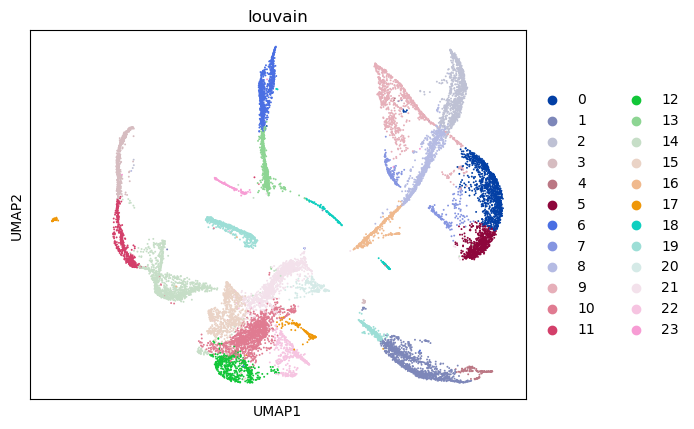

UMAP leiden


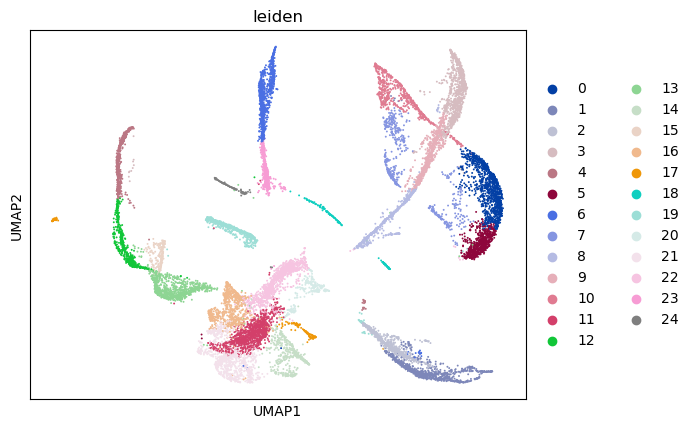

calc drug response
clz selective cells
# of clz selective cells: is_clz_selective
False    15540
True       219
Name: count, dtype: int64


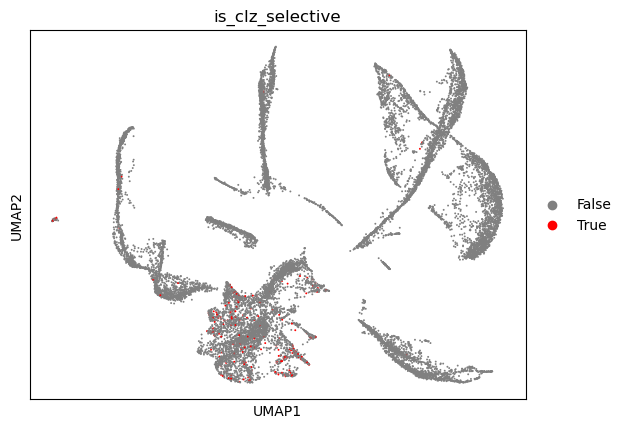

In [3]:
import calculation_tool as ct
#file_path="/data/mouse_PFC/combined_data.h5ad"
file_path="/data/mouse_PFC/WT_only_data.h5ad"
add_markers=["NEUN","CAMK2A","CAMK2B",    "CUX1", "CUX2", "RORB", "BCL6", "BCL11B", "FEZF2",
    "TLE4", "FOXP2", "PCP4", "PVALB", "SST", "GPR149", "THSD7A",
    "VIP", "HTR3A", "CRH", "ADARB2", "RELN", "LAMP5"]
adata,GPCR_df=ct.preprocess_adata_in_bulk(file_path,label=None,add_markers=add_markers)
#GPCR_df.to_csv("/data/mouse_PFC/combined_data_GPCR_df.csv")
GPCR_df.to_csv("/data/mouse_PFC/WT_only_data_GPCR_df.csv")

In [7]:
import calculation_tool as ct
D_R_mtx,GPCR_type_df,drug_list,GPCR_list=ct.load_parameters()
params=ct.set_parameters_for_preprocess(GPCR_list)

In [ ]:
file_path="/data/mouse_PFC/combined_data.h5ad"
adata = anndata.read_h5ad(file_path)

In [ ]:
GPCR_df=pd.read_csv("/data/mouse_PFC/combined_data_GPCR_df.csv")
#ct.drug_titeration(adata, GPCR_df, GPCR_type_df, drug_list, D_R_mtx)

clz selective cells
# of clz selective cells: is_clz_selective
False    15552
True       207
Name: count, dtype: int64


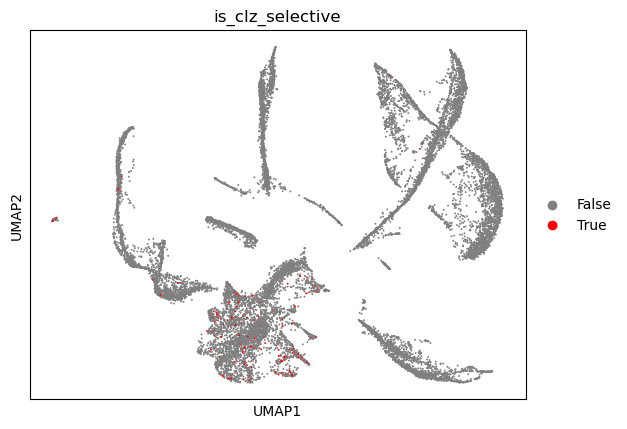

In [8]:
drug_conc=10**3
adata=ct.calc_drug_response(adata,GPCR_df,GPCR_type_df,drug_list,D_R_mtx,drug_conc)
selectivity_threshold=1.5
adata,num_clz_selective=ct.calc_clz_selective_cell(adata,drug_list,selectivity_threshold)

file_root, file_extension = os.path.splitext(file_path)
# Append '_processed' to the root and add the extension back
processed_file_path = f"{file_root}_processed{file_extension}"
adata.write(processed_file_path)

In [ ]:
file_path="/data/mouse_PFC/combined_data.h5ad"
file_root, file_extension = os.path.splitext(file_path)
# Append '_processed' to the root and add the extension back
processed_file_path = f"{file_root}_processed{file_extension}"
adata=anndata.read_h5ad(processed_file_path)

In [4]:
GPCR_adata=anndata.AnnData(X=GPCR_df)
GPCR_adata_norm=sc.pp.normalize_total(GPCR_adata,target_sum=1e4,inplace=False)['X']
GPCR_adata_norm_df=pd.DataFrame(GPCR_adata_norm,columns=GPCR_adata.var.index)


In [9]:
import calculation_tool as ct

drug_conc=10**4
results_df_sorted,all_responses=ct.sim_inhibit_pattern(adata,GPCR_adata_norm_df,GPCR_type_df,drug_conc,n_pattern=10000)

Pattern_1: {'HTR1A_raw': True, 'HTR1B_raw': False, 'HTR1D_raw': False, 'HTR2A_raw': False, 'HTR2B_raw': False, 'HTR2C_raw': True, 'HTR3A_raw': True, 'HTR4_raw': False, 'HTR5A_raw': True, 'HTR6_raw': True, 'HTR7_raw': True, 'DRD1_raw': False, 'DRD2_raw': False, 'DRD4_raw': True, 'DRD5_raw': True, 'HRH1_raw': True, 'HRH2_raw': False, 'HRH3_raw': True, 'CHRM1_raw': True, 'CHRM2_raw': False, 'CHRM3_raw': False, 'CHRM5_raw': True, 'ADRA1A_raw': False, 'ADRA1B_raw': False, 'ADRA2A_raw': False, 'ADRA2C_raw': False, 'ADRB1_raw': True, 'ADRB2_raw': True}
Pattern_2: {'HTR1A_raw': False, 'HTR1B_raw': False, 'HTR1D_raw': True, 'HTR2A_raw': False, 'HTR2B_raw': False, 'HTR2C_raw': True, 'HTR3A_raw': True, 'HTR4_raw': False, 'HTR5A_raw': True, 'HTR6_raw': True, 'HTR7_raw': True, 'DRD1_raw': True, 'DRD2_raw': False, 'DRD4_raw': True, 'DRD5_raw': False, 'HRH1_raw': False, 'HRH2_raw': True, 'HRH3_raw': True, 'CHRM1_raw': False, 'CHRM2_raw': False, 'CHRM3_raw': True, 'CHRM5_raw': False, 'ADRA1A_raw': Tru

Simulating drug responses: 100%|██████████| 10000/10000 [02:04<00:00, 80.50it/s]

      pattern_name                                            pattern  \
4283  Pattern_4284  {'HTR1A_raw': True, 'HTR1B_raw': False, 'HTR1D...   
7410  Pattern_7411  {'HTR1A_raw': True, 'HTR1B_raw': True, 'HTR1D_...   
7567  Pattern_7568  {'HTR1A_raw': False, 'HTR1B_raw': False, 'HTR1...   
4669  Pattern_4670  {'HTR1A_raw': True, 'HTR1B_raw': True, 'HTR1D_...   
3788  Pattern_3789  {'HTR1A_raw': False, 'HTR1B_raw': True, 'HTR1D...   

             diff  
4283  3127.361048  
7410  3116.902616  
7567  3108.250857  
4669  3099.436603  
3788  3098.919466  


In [5]:
dir="/data/mouse_PFC/WT_only"
results_df_sorted.to_csv(os.path.join(dir,"results_df_sorted.csv"))
all_responses.to_csv(os.path.join(dir,"all_responses.csv"))

NameError: name 'results_df_sorted' is not defined

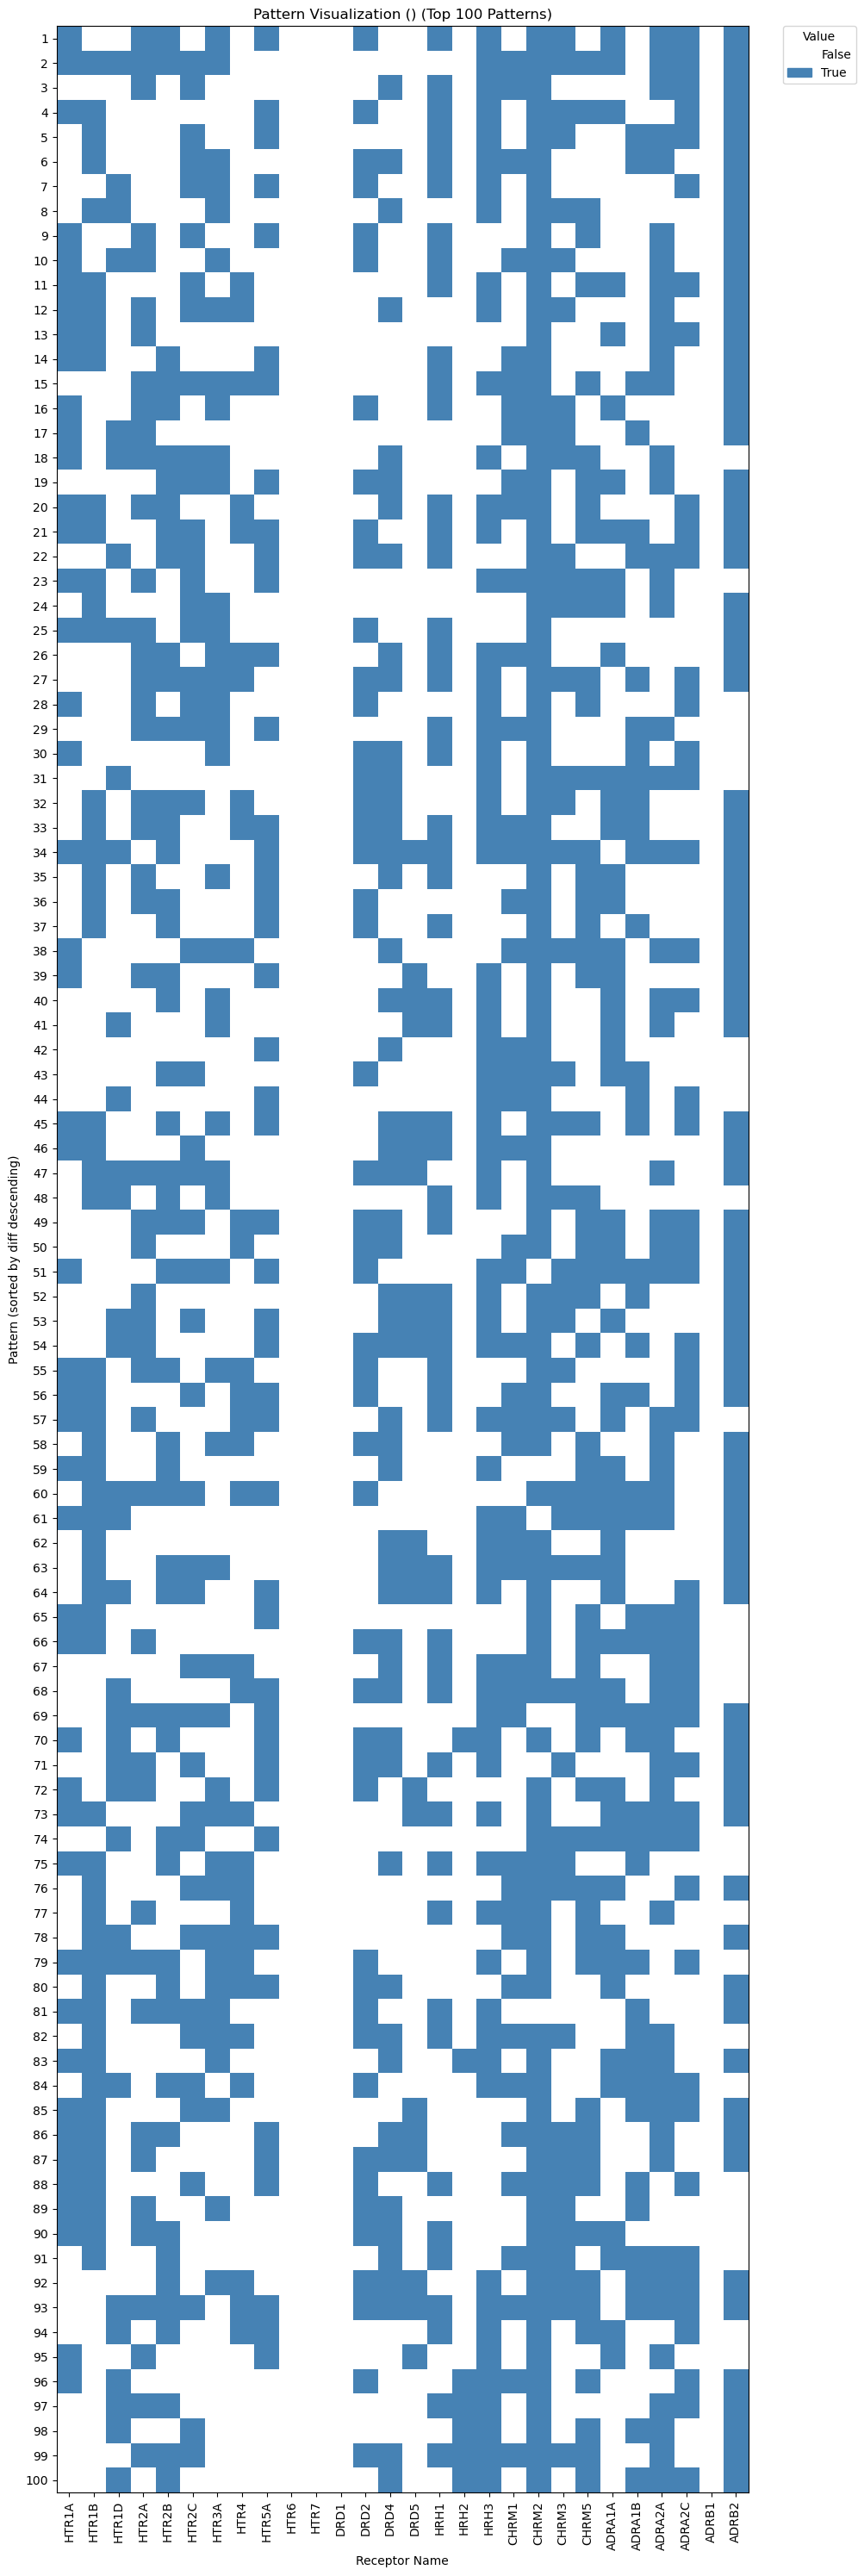

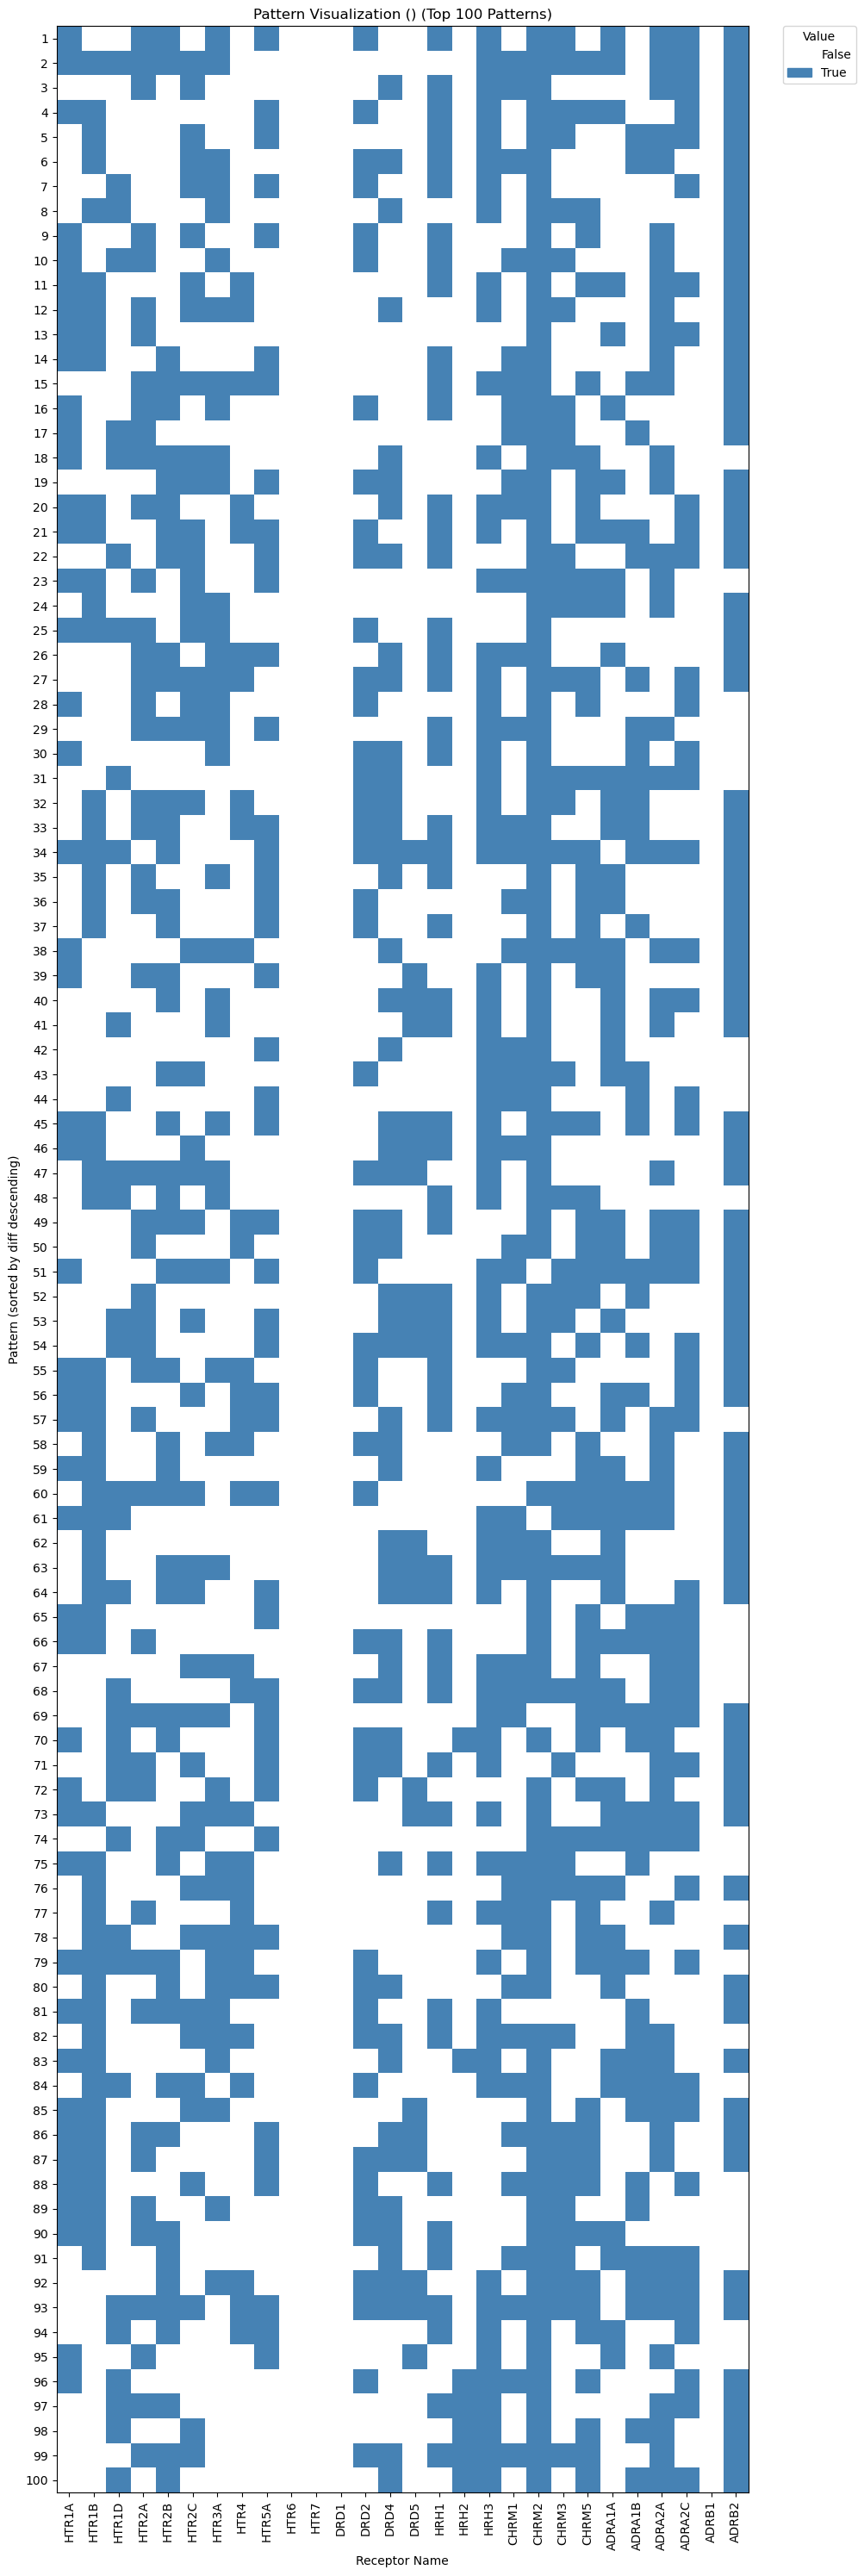

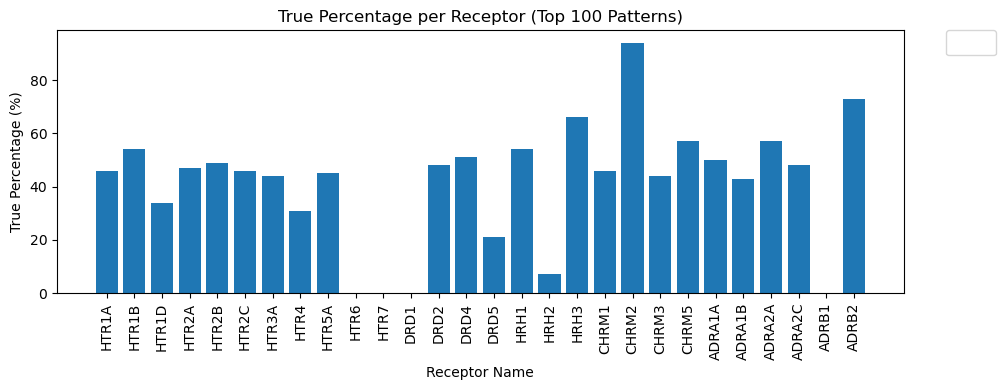

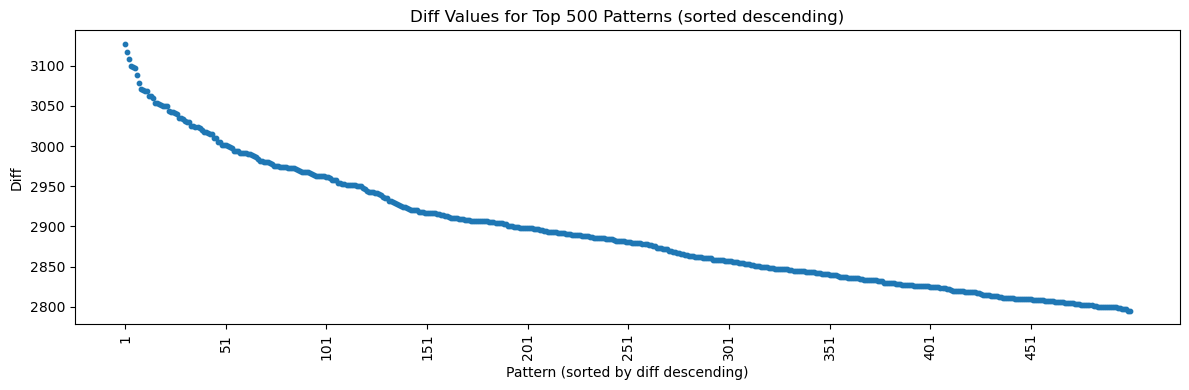

In [10]:
ct.visualize_patterns(results_df_sorted, top_n=100, top_n_for_heatmap=100, scatter_n=500)

Generating inhibition patterns: 100%|██████████| 3276/3276 [00:00<00:00, 172431.39it/s]


Pattern_1: {'HTR1A_raw': True, 'HTR1B_raw': True, 'HTR1D_raw': True, 'HTR2A_raw': False, 'HTR2B_raw': False, 'HTR2C_raw': False, 'HTR3A_raw': False, 'HTR4_raw': False, 'HTR5A_raw': False, 'HTR6_raw': False, 'HTR7_raw': False, 'DRD1_raw': False, 'DRD2_raw': False, 'DRD4_raw': False, 'DRD5_raw': False, 'HRH1_raw': False, 'HRH2_raw': False, 'HRH3_raw': False, 'CHRM1_raw': False, 'CHRM2_raw': False, 'CHRM3_raw': False, 'CHRM5_raw': False, 'ADRA1A_raw': False, 'ADRA1B_raw': False, 'ADRA2A_raw': False, 'ADRA2C_raw': False, 'ADRB1_raw': False, 'ADRB2_raw': False}
Pattern_2: {'HTR1A_raw': True, 'HTR1B_raw': True, 'HTR1D_raw': False, 'HTR2A_raw': True, 'HTR2B_raw': False, 'HTR2C_raw': False, 'HTR3A_raw': False, 'HTR4_raw': False, 'HTR5A_raw': False, 'HTR6_raw': False, 'HTR7_raw': False, 'DRD1_raw': False, 'DRD2_raw': False, 'DRD4_raw': False, 'DRD5_raw': False, 'HRH1_raw': False, 'HRH2_raw': False, 'HRH3_raw': False, 'CHRM1_raw': False, 'CHRM2_raw': False, 'CHRM3_raw': False, 'CHRM5_raw': False

Simulating drug responses: 100%|██████████| 3276/3276 [00:40<00:00, 81.49it/s]


      pattern_name                                            pattern  \
3127  Pattern_3128  {'HTR1A_raw': False, 'HTR1B_raw': False, 'HTR1...   
322    Pattern_323  {'HTR1A_raw': True, 'HTR1B_raw': False, 'HTR1D...   
3216  Pattern_3217  {'HTR1A_raw': False, 'HTR1B_raw': False, 'HTR1...   
297    Pattern_298  {'HTR1A_raw': True, 'HTR1B_raw': False, 'HTR1D...   
3218  Pattern_3219  {'HTR1A_raw': False, 'HTR1B_raw': False, 'HTR1...   

             diff  
3127  5620.062700  
322   5553.571292  
3216  5550.877423  
297   5519.831758  
3218  5518.422926  


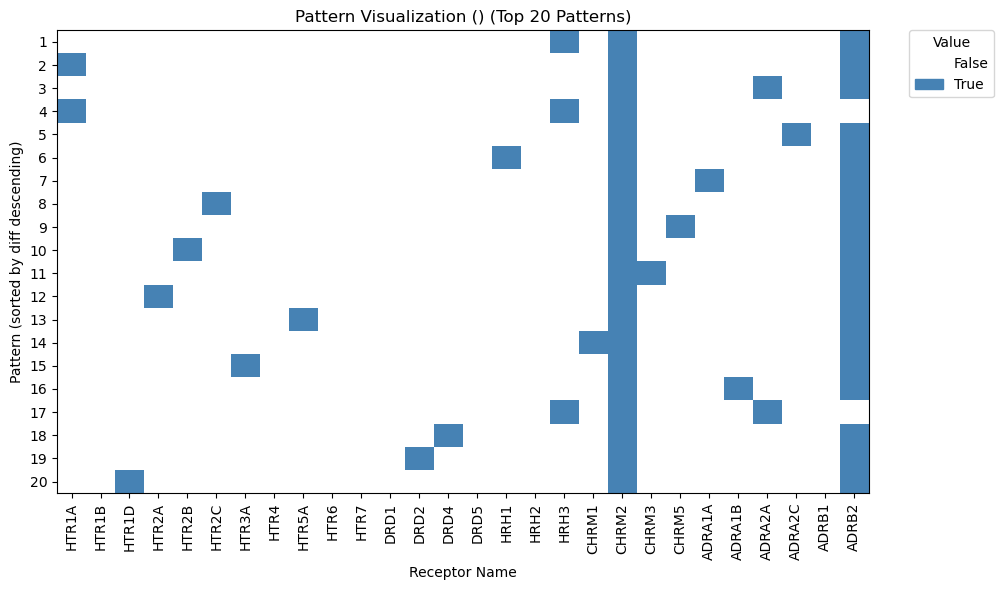

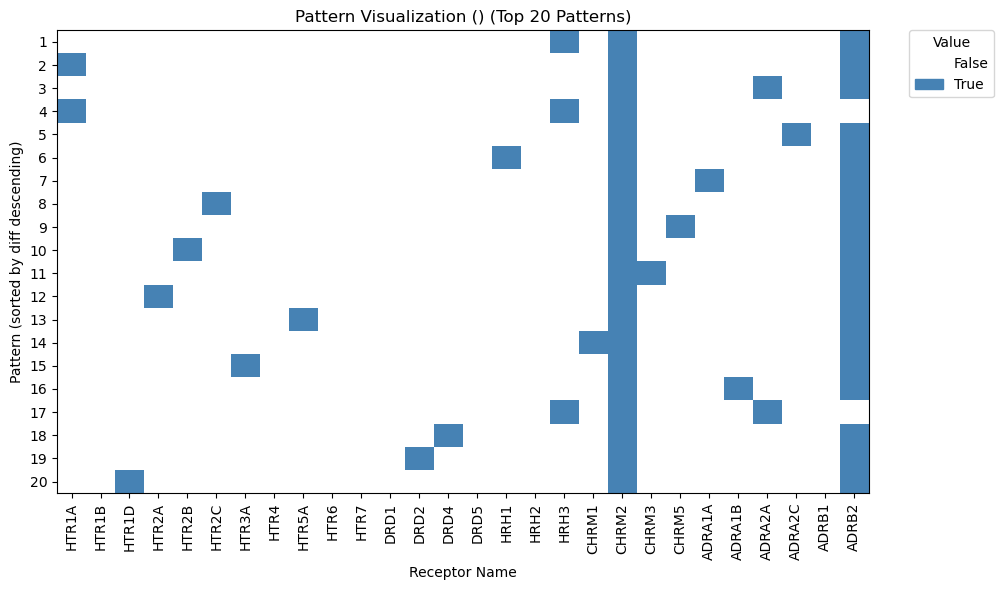

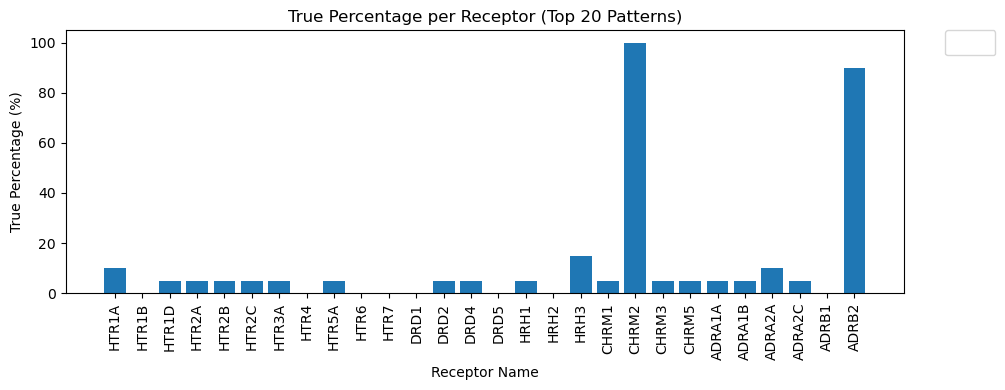

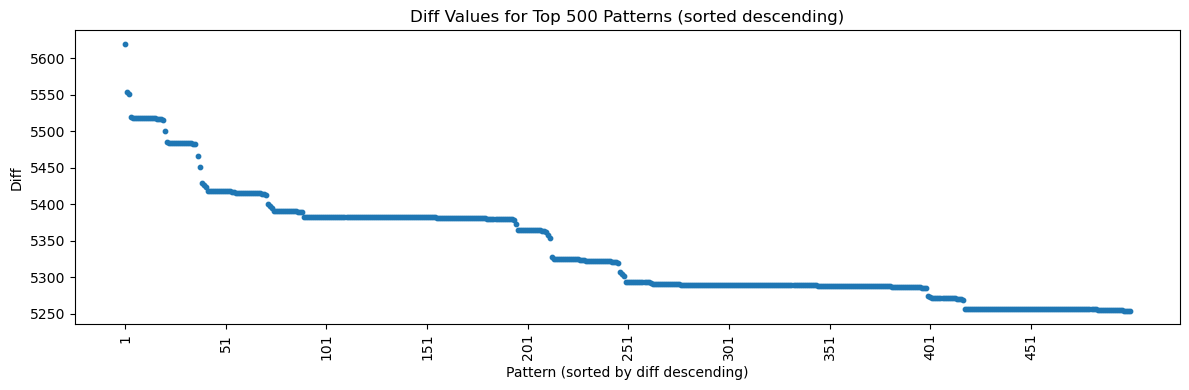

In [11]:
import calculation_tool as ct

drug_conc=10**3
results_df_sorted,all_responses=ct.sim_inhibit_pattern_3r(adata,GPCR_adata_norm_df,GPCR_type_df,drug_conc)
dir="/data/mouse_PFC/WT_only"
results_df_sorted.to_csv(os.path.join(dir,"results_df_sorted_3r.csv"))
all_responses.to_csv(os.path.join(dir,"all_responses_3r.csv"))
ct.visualize_patterns(results_df_sorted, top_n=20, top_n_for_heatmap=20, scatter_n=500)

In [ ]:
ct.visualize_patterns(results_df_sorted, top_n=40, top_n_for_heatmap=40, scatter_n=500)

category
is_clz_selective
False    15552
True       207
Name: count, dtype: int64


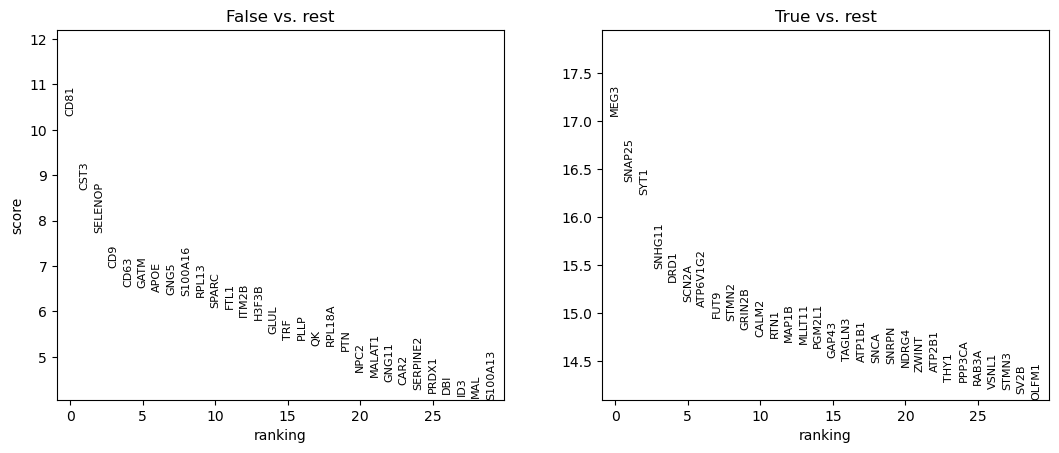

In [14]:
# is_clz_selective をカテゴリ型に変換
adata.obs["is_clz_selective"] = adata.obs["is_clz_selective"].astype("category")

# 念のため確認
print(adata.obs["is_clz_selective"].dtype)
print(adata.obs["is_clz_selective"].value_counts())

# その後で rank_genes_groups
sc.tl.rank_genes_groups(adata, 'is_clz_selective', method='wilcoxon',layer="lognorm",
    use_raw=False,
    pts=True)
sc.pl.rank_genes_groups(adata, n_genes=30, sharey=False)
df_deg = sc.get.rank_genes_groups_df(adata, group=None)
df_sig = df_deg[df_deg["pvals_adj"] < 0.05]
df_sig.to_csv("/data/mouse_PFC/WT_only/significant_DEG_is_clz_selective.csv", index=False)


In [15]:
def plot_volcano_from_deg(
    df_deg,
    group=True,
    adj_p_cutoff=0.05,
    log2fc_cutoff=0.25,
    top_n_labels=20,
    output_pdf=None,
    title=None,
    figsize=(7, 6),
):
    """
    Scanpy sc.get.rank_genes_groups_df() の結果から volcano plot を作成する関数。

    Parameters
    ----------
    df_deg : pandas.DataFrame
        sc.get.rank_genes_groups_df(adata, group=None) の出力
    group : bool or str
        プロットする group。例: True, False, "True", "False"
    adj_p_cutoff : float
        adjusted p-value のカットオフ
    log2fc_cutoff : float
        absolute log2 fold change のカットオフ
    top_n_labels : int
        ラベル表示する有意遺伝子数
    output_pdf : str or None
        PDF保存先。Noneなら保存しない
    title : str or None
        プロットタイトル
    figsize : tuple
        図のサイズ
    """

    df = df_deg.copy()

    # groupで絞り込み
    if "group" in df.columns:
        df["group"] = df["group"].astype(str)
        df = df[df["group"] == str(group)].copy()

    if df.empty:
        raise ValueError(f"No rows found for group={group}")

    # logfoldchangesをlog2foldchangeとして扱う
    if "logfoldchanges" in df.columns:
        df["log2foldchange"] = df["logfoldchanges"]
    elif "log2foldchange" not in df.columns:
        raise ValueError("df_deg must contain 'logfoldchanges' or 'log2foldchange'.")

    # adjusted p-value列
    if "pvals_adj" in df.columns:
        p_col = "pvals_adj"
    elif "adj_p_val" in df.columns:
        p_col = "adj_p_val"
    else:
        raise ValueError("df_deg must contain 'pvals_adj' or 'adj_p_val'.")

    # p=0対策
    min_positive_p = df.loc[df[p_col] > 0, p_col].min()
    if pd.isna(min_positive_p):
        min_positive_p = 1e-300

    df[p_col] = df[p_col].replace(0, min_positive_p)
    df["minus_log10_adj_p"] = -np.log10(df[p_col])

    # 有意判定
    df["significant"] = (
        (df[p_col] < adj_p_cutoff)
        & (df["log2foldchange"].abs() >= log2fc_cutoff)
    )

    df["direction"] = "Not significant"
    df.loc[
        df["significant"] & (df["log2foldchange"] > 0),
        "direction"
    ] = "Up"

    df.loc[
        df["significant"] & (df["log2foldchange"] < 0),
        "direction"
    ] = "Down"

    # plot
    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(
        df.loc[df["direction"] == "Not significant", "log2foldchange"],
        df.loc[df["direction"] == "Not significant", "minus_log10_adj_p"],
        s=8,
        alpha=0.4,
        color="lightgray",
        label="Not significant",
    )

    ax.scatter(
        df.loc[df["direction"] == "Up", "log2foldchange"],
        df.loc[df["direction"] == "Up", "minus_log10_adj_p"],
        s=12,
        alpha=0.8,
        color="crimson",
        label="Up",
    )

    ax.scatter(
        df.loc[df["direction"] == "Down", "log2foldchange"],
        df.loc[df["direction"] == "Down", "minus_log10_adj_p"],
        s=12,
        alpha=0.8,
        color="royalblue",
        label="Down",
    )

    # cutoff lines
    ax.axhline(
        -np.log10(adj_p_cutoff),
        linestyle="--",
        linewidth=1,
        color="black",
    )
    ax.axvline(
        log2fc_cutoff,
        linestyle="--",
        linewidth=1,
        color="black",
    )
    ax.axvline(
        -log2fc_cutoff,
        linestyle="--",
        linewidth=1,
        color="black",
    )

    # gene labels
    if "names" in df.columns and top_n_labels > 0:
        label_df = (
            df[df["significant"]]
            .sort_values(p_col)
            .head(top_n_labels)
        )

        for _, row in label_df.iterrows():
            ax.text(
                row["log2foldchange"],
                row["minus_log10_adj_p"],
                row["names"],
                fontsize=8,
                ha="center",
                va="bottom",
            )

    ax.set_xlabel("log2 fold change")
    ax.set_ylabel("-log10 adjusted p-value")

    if title is None:
        title = f"Volcano plot: group={group}"

    ax.set_title(title)
    ax.legend(frameon=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    if output_pdf is not None:
        plt.savefig(output_pdf, format="pdf", bbox_inches="tight")
        print(f"Saved: {output_pdf}")

    plt.show()

    print("Total genes:", len(df))
    print("Significant genes:", df["significant"].sum())
    print("Up:", (df["direction"] == "Up").sum())
    print("Down:", (df["direction"] == "Down").sum())

    return df

Saved: /data/mouse_PFC/WT_only/volcano_is_clz_selective_groupTrue.pdf


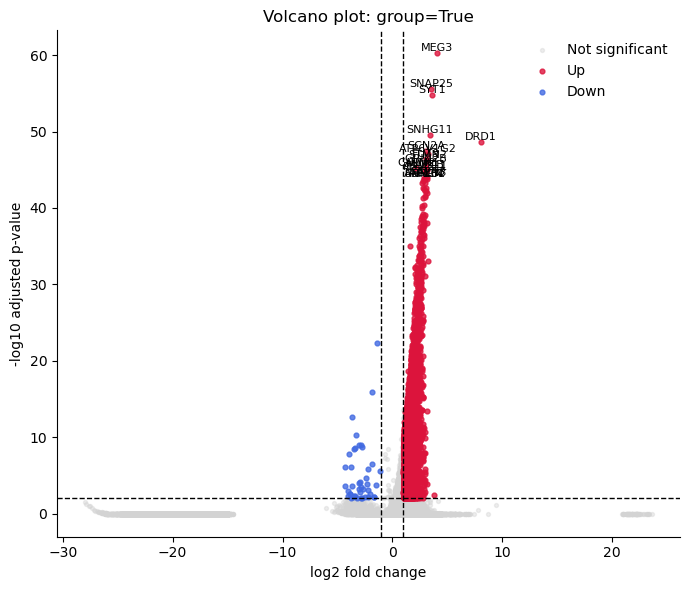

Total genes: 20789
Significant genes: 3323
Up: 3280
Down: 43


In [16]:
volcano_df = plot_volcano_from_deg(
    df_deg,
    group=True,
    adj_p_cutoff=0.01,
    log2fc_cutoff=1,
    top_n_labels=20,
    output_pdf="/data/mouse_PFC/WT_only/volcano_is_clz_selective_groupTrue.pdf",
)

In [ ]:
drug_conc=10**3
adata=ct.calc_drug_response(adata,GPCR_df,GPCR_type_df,drug_list,D_R_mtx,drug_conc)
selectivity_threshold=1.5
adata,num_clz_selective=ct.calc_clz_selective_cell(adata,drug_list,selectivity_threshold)

Group counts:
_clz_group
FALSE    15552
TRUE       207
Name: count, dtype: int64
adata.layers['lognorm'] already exists.
Found genes: {'5HT1A': 'HTR1A', 'M2': 'CHRM2', 'H3': 'HRH3'}
stats_df:


,gene_label,gene,group_FALSE,group_TRUE,n_FALSE,n_TRUE,mean_FALSE_lognorm,mean_TRUE_lognorm,delta_mean_TRUE_minus_FALSE,median_FALSE_lognorm,...,delta_median_TRUE_minus_FALSE,pct_expr_FALSE,pct_expr_TRUE,delta_pct_TRUE_minus_FALSE,mannwhitneyu_stat,p_value_expression,fisher_odds_ratio_positive,p_value_positive_fraction,q_value_expression_FDR,q_value_positive_fraction_FDR
0,5HT1A,HTR1A,FALSE,TRUE,15552,207,0.010843,0.036399,0.025556,0.0,...,0.0,0.970936,3.864734,2.893798,1656090.5,3.666168e-05,4.100236,1.207205e-03,3.666168e-05,1.207205e-03
1,M2,CHRM2,FALSE,TRUE,15552,207,0.022812,0.126626,0.103814,0.0,...,0.0,1.504630,10.144928,8.640298,1748285.0,1.720809e-22,7.390819,2.191744e-11,5.162428e-22,6.575232e-11
2,H3,HRH3,FALSE,TRUE,15552,207,0.052989,0.108253,0.055264,0.0,...,0.0,3.587963,11.594203,8.006240,1735057.0,3.553386e-09,3.524061,7.136191e-07,5.330079e-09,1.070429e-06


summary_pct:


,gene_label,gene,group,pct_expressing,mean_lognorm_expression,median_lognorm_expression,n_cells
0,5HT1A,HTR1A,FALSE,0.970936,0.010843,0.0,15552
1,5HT1A,HTR1A,TRUE,3.864734,0.036399,0.0,207
2,H3,HRH3,FALSE,3.587963,0.052989,0.0,15552
3,H3,HRH3,TRUE,11.594203,0.108253,0.0,207
4,M2,CHRM2,FALSE,1.504630,0.022812,0.0,15552
5,M2,CHRM2,TRUE,10.144928,0.126626,0.0,207


saved: /data/mouse_PFC/WT_only/clz_receptor_expression_analysis/receptor_lognorm_expression_violin_TRUE_vs_FALSE.pdf
saved: /data/mouse_PFC/WT_only/clz_receptor_expression_analysis/receptor_mean_lognorm_expression_TRUE_vs_FALSE.pdf
saved: /data/mouse_PFC/WT_only/clz_receptor_expression_analysis/receptor_positive_fraction_TRUE_vs_FALSE.pdf
saved: /data/mouse_PFC/WT_only/clz_receptor_expression_analysis/receptor_delta_mean_expression_TRUE_minus_FALSE.pdf
saved: /data/mouse_PFC/WT_only/clz_receptor_expression_analysis/scanpy_dotplot_receptors_TRUE_vs_FALSE.pdf
saved: /data/mouse_PFC/WT_only/clz_receptor_expression_analysis/scanpy_violin_receptors_TRUE_vs_FALSE.pdf
Done.
All outputs saved to: /data/mouse_PFC/WT_only/clz_receptor_expression_analysis


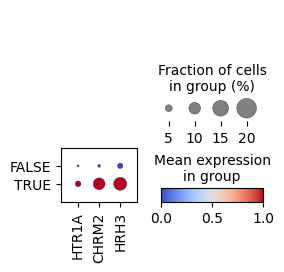

In [17]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.stats import mannwhitneyu, fisher_exact
from statsmodels.stats.multitest import multipletests

# =========================
# settings
# =========================
OUTDIR = "/data/mouse_PFC/WT_only/clz_receptor_expression_analysis"
# OUTDIRが既に定義されていればそれを使う
try:
    OUTDIR
except NameError:
    OUTDIR = "/data/mouse_PFC/WT_only/clz_receptor_expression_analysis"

os.makedirs(OUTDIR, exist_ok=True)

GROUPBY = "is_clz_selective"
LAYER = "lognorm"
RAW_LAYER = "raw_counts"

# Illustrator編集用PDF設定
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 12

gene_aliases = {
    "5HT1A": ["Htr1a", "HTR1A"],
    "M2":    ["Chrm2", "CHRM2"],
    "H3":    ["Hrh3", "HRH3"],
}

# 比較順
GROUP_ORDER = ["FALSE", "TRUE"]
GROUP_LABELS = {
    "FALSE": "Non-responsive",
    "TRUE": "Clozapine-responsive",
}


# =========================
# helper functions
# =========================

def save_pdf(fig, filename):
    path = os.path.join(OUTDIR, filename)
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    plt.close(fig)
    print("saved:", path)


def ensure_clz_group(adata, groupby=GROUPBY):
    """
    TRUE/FALSEを安定して扱うための列を作る。
    """
    adata.obs["_clz_group"] = (
        adata.obs[groupby]
        .astype(str)
        .str.upper()
        .replace({
            "1": "TRUE",
            "0": "FALSE",
            "TRUE": "TRUE",
            "FALSE": "FALSE",
            "True": "TRUE",
            "False": "FALSE",
        })
        .astype("category")
    )

    print("Group counts:")
    print(adata.obs["_clz_group"].value_counts())

    valid = adata.obs["_clz_group"].isin(["TRUE", "FALSE"])
    return valid


def ensure_lognorm_layer(adata, layer=LAYER, raw_layer=RAW_LAYER):
    """
    lognorm layerがなければraw_countsから作成。
    """
    if layer in adata.layers:
        print(f"adata.layers['{layer}'] already exists.")
        return

    if raw_layer not in adata.layers:
        raise ValueError(
            f"adata.layers['{layer}'] not found, and "
            f"adata.layers['{raw_layer}'] is also missing."
        )

    print(f"Creating adata.layers['{layer}'] from adata.layers['{raw_layer}']...")

    adata.layers[layer] = adata.layers[raw_layer].copy()

    sc.pp.normalize_total(
        adata,
        target_sum=1e4,
        layer=layer
    )
    sc.pp.log1p(
        adata,
        layer=layer
    )

    adata.layers[layer] = adata.layers[layer].astype("float32")
    print("done.")


def resolve_gene_aliases(adata, gene_aliases):
    """
    mouse/human両対応。
    adata.var_names上の実際のgene名を探す。
    大文字小文字の違いも吸収する。
    """
    var_map = {str(g).upper(): str(g) for g in adata.var_names}

    found_genes = {}
    missing = {}

    for label, aliases in gene_aliases.items():
        hit = None

        for g in aliases:
            gu = str(g).upper()
            if gu in var_map:
                hit = var_map[gu]
                break

        if hit is None:
            missing[label] = aliases
            print(f"Warning: {label} not found. tried: {aliases}")
        else:
            found_genes[label] = hit

    print("Found genes:", found_genes)

    if len(found_genes) == 0:
        raise ValueError("No target genes were found in adata.var_names.")

    return found_genes, missing


def get_expr_vector(adata, gene, layer):
    """
    指定layerからgene expression vectorを取得。
    """
    idx = adata.var_names.get_loc(gene)
    x = adata.layers[layer][:, idx]

    if sparse.issparse(x):
        x = x.toarray()

    return np.asarray(x).ravel()


def add_gene_vectors_to_obs(adata, found_genes, layer=LAYER, raw_layer=RAW_LAYER):
    """
    lognorm expressionとraw positiveをobsに追加。
    """
    for label, gene in found_genes.items():
        expr = get_expr_vector(adata, gene, layer=layer)
        adata.obs[f"{label}_gene"] = gene
        adata.obs[f"{label}_lognorm"] = expr

        if raw_layer in adata.layers:
            raw = get_expr_vector(adata, gene, layer=raw_layer)
            adata.obs[f"{label}_raw"] = raw
            adata.obs[f"{label}_positive"] = raw > 0
        else:
            adata.obs[f"{label}_positive"] = expr > 0

    return adata


def build_long_expression_df(adata, found_genes, valid_mask):
    records = []

    for label, gene in found_genes.items():
        tmp = pd.DataFrame({
            "cell": adata.obs_names[valid_mask],
            "group": adata.obs.loc[valid_mask, "_clz_group"].astype(str).values,
            "gene_label": label,
            "gene": gene,
            "lognorm_expression": adata.obs.loc[valid_mask, f"{label}_lognorm"].values,
            "expressed": adata.obs.loc[valid_mask, f"{label}_positive"].values,
        })

        if f"{label}_raw" in adata.obs.columns:
            tmp["raw_counts"] = adata.obs.loc[valid_mask, f"{label}_raw"].values

        records.append(tmp)

    return pd.concat(records, axis=0, ignore_index=True)


def compute_stats(df_expr):
    stats = []

    groups = [g for g in GROUP_ORDER if g in df_expr["group"].unique()]
    if len(groups) != 2:
        raise ValueError(f"Expected 2 groups, got: {groups}")

    g_false, g_true = groups[0], groups[1]

    for label in df_expr["gene_label"].unique():
        d = df_expr[df_expr["gene_label"] == label].copy()

        x_false = d.loc[d["group"] == g_false, "lognorm_expression"].values
        x_true = d.loc[d["group"] == g_true, "lognorm_expression"].values

        u, p_expr = mannwhitneyu(
            x_true,
            x_false,
            alternative="two-sided"
        )

        pos_false = d.loc[d["group"] == g_false, "expressed"].values.astype(bool)
        pos_true = d.loc[d["group"] == g_true, "expressed"].values.astype(bool)

        table = [
            [pos_true.sum(), len(pos_true) - pos_true.sum()],
            [pos_false.sum(), len(pos_false) - pos_false.sum()],
        ]

        odds, p_pos = fisher_exact(table)

        stats.append({
            "gene_label": label,
            "gene": d["gene"].iloc[0],

            "group_FALSE": g_false,
            "group_TRUE": g_true,

            "n_FALSE": len(x_false),
            "n_TRUE": len(x_true),

            "mean_FALSE_lognorm": np.mean(x_false),
            "mean_TRUE_lognorm": np.mean(x_true),
            "delta_mean_TRUE_minus_FALSE": np.mean(x_true) - np.mean(x_false),

            "median_FALSE_lognorm": np.median(x_false),
            "median_TRUE_lognorm": np.median(x_true),
            "delta_median_TRUE_minus_FALSE": np.median(x_true) - np.median(x_false),

            "pct_expr_FALSE": np.mean(pos_false) * 100,
            "pct_expr_TRUE": np.mean(pos_true) * 100,
            "delta_pct_TRUE_minus_FALSE": (np.mean(pos_true) - np.mean(pos_false)) * 100,

            "mannwhitneyu_stat": u,
            "p_value_expression": p_expr,

            "fisher_odds_ratio_positive": odds,
            "p_value_positive_fraction": p_pos,
        })

    stats_df = pd.DataFrame(stats)

    stats_df["q_value_expression_FDR"] = multipletests(
        stats_df["p_value_expression"],
        method="fdr_bh"
    )[1]

    stats_df["q_value_positive_fraction_FDR"] = multipletests(
        stats_df["p_value_positive_fraction"],
        method="fdr_bh"
    )[1]

    return stats_df


# =========================
# plotting functions
# =========================

def plot_lognorm_violin(df_expr, stats_df):
    genes = list(df_expr["gene_label"].unique())
    n_genes = len(genes)

    fig, ax = plt.subplots(figsize=(max(5.5, 1.4 * n_genes), 4.5))

    positions = []
    data = []
    xticks = []

    width_offset = 0.18

    for i, label in enumerate(genes):
        for j, group in enumerate(GROUP_ORDER):
            vals = df_expr.loc[
                (df_expr["gene_label"] == label) &
                (df_expr["group"] == group),
                "lognorm_expression"
            ].values

            pos = i + (-width_offset if group == "FALSE" else width_offset)
            positions.append(pos)
            data.append(vals)

        xticks.append(i)

    parts = ax.violinplot(
        data,
        positions=positions,
        widths=0.28,
        showmeans=False,
        showmedians=True,
        showextrema=False,
    )

    # jitter points
    rng = np.random.default_rng(0)
    for pos, vals in zip(positions, data):
        if len(vals) > 3000:
            vals_plot = rng.choice(vals, size=3000, replace=False)
        else:
            vals_plot = vals

        jitter = rng.normal(loc=pos, scale=0.025, size=len(vals_plot))
        ax.scatter(
            jitter,
            vals_plot,
            s=4,
            alpha=0.25,
            linewidths=0,
        )

    ax.set_xticks(xticks)
    ax.set_xticklabels(genes)
    ax.set_ylabel("Expression\nlog-normalized")
    ax.set_xlabel("")
    ax.set_title("Receptor mRNA expression")

    # 凡例用ダミー
    ax.scatter([], [], label="Non-responsive", alpha=0.7)
    ax.scatter([], [], label="Clozapine-responsive", alpha=0.7)
    ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1))

    # p値アノテーション
    y_max = df_expr["lognorm_expression"].max()
    y_text = y_max * 1.05 if y_max > 0 else 0.1

    for i, label in enumerate(genes):
        row = stats_df[stats_df["gene_label"] == label].iloc[0]
        ax.text(
            i,
            y_text,
            f"q={row['q_value_expression_FDR']:.1e}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    save_pdf(fig, "receptor_lognorm_expression_violin_TRUE_vs_FALSE.pdf")


def plot_mean_expression_bar(stats_df):
    genes = stats_df["gene_label"].tolist()
    x = np.arange(len(genes))
    width = 0.35

    fig, ax = plt.subplots(figsize=(max(5, 1.2 * len(genes)), 4))

    ax.bar(
        x - width / 2,
        stats_df["mean_FALSE_lognorm"],
        width,
        label="Non-responsive",
    )
    ax.bar(
        x + width / 2,
        stats_df["mean_TRUE_lognorm"],
        width,
        label="Clozapine-responsive",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(genes)
    ax.set_ylabel("Mean expression\nlog-normalized")
    ax.set_xlabel("")
    ax.set_title("Mean receptor expression")
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

    for i, row in stats_df.iterrows():
        ymax = max(row["mean_FALSE_lognorm"], row["mean_TRUE_lognorm"])
        ax.text(
            i,
            ymax * 1.05 if ymax > 0 else 0.05,
            f"q={row['q_value_expression_FDR']:.1e}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    save_pdf(fig, "receptor_mean_lognorm_expression_TRUE_vs_FALSE.pdf")


def plot_positive_fraction_bar(stats_df):
    genes = stats_df["gene_label"].tolist()
    x = np.arange(len(genes))
    width = 0.35

    fig, ax = plt.subplots(figsize=(max(5, 1.2 * len(genes)), 4))

    ax.bar(
        x - width / 2,
        stats_df["pct_expr_FALSE"],
        width,
        label="Non-responsive",
    )
    ax.bar(
        x + width / 2,
        stats_df["pct_expr_TRUE"],
        width,
        label="Clozapine-responsive",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(genes)
    ax.set_ylabel("% expressing cells\nraw count > 0")
    ax.set_xlabel("")
    ax.set_ylim(0, 100)
    ax.set_title("Fraction of receptor-expressing cells")
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

    for i, row in stats_df.iterrows():
        ymax = max(row["pct_expr_FALSE"], row["pct_expr_TRUE"])
        ax.text(
            i,
            min(ymax + 4, 98),
            f"q={row['q_value_positive_fraction_FDR']:.1e}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    save_pdf(fig, "receptor_positive_fraction_TRUE_vs_FALSE.pdf")


def plot_delta_summary(stats_df):
    genes = stats_df["gene_label"].tolist()
    x = np.arange(len(genes))

    fig, ax = plt.subplots(figsize=(max(5, 1.2 * len(genes)), 4))

    ax.bar(
        x,
        stats_df["delta_mean_TRUE_minus_FALSE"],
    )

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(genes)
    ax.set_ylabel("Delta mean expression\nTRUE - FALSE")
    ax.set_title("Expression enrichment in clozapine-responsive cells")

    for i, row in stats_df.iterrows():
        y = row["delta_mean_TRUE_minus_FALSE"]
        ax.text(
            i,
            y,
            f"q={row['q_value_expression_FDR']:.1e}",
            ha="center",
            va="bottom" if y >= 0 else "top",
            fontsize=9,
        )

    save_pdf(fig, "receptor_delta_mean_expression_TRUE_minus_FALSE.pdf")


def plot_scanpy_dotplot(adata, genes_for_plot):
    """
    Scanpy dotplotもPDF保存。
    """
    dp = sc.pl.dotplot(
        adata,
        var_names=genes_for_plot,
        groupby="_clz_group",
        layer=LAYER,
        use_raw=False,
        standard_scale="var",
        color_map="coolwarm",
        return_fig=True,
        show=False,
    )

    path = os.path.join(OUTDIR, "scanpy_dotplot_receptors_TRUE_vs_FALSE.pdf")
    dp.savefig(path)
    print("saved:", path)


def plot_scanpy_violin(adata, genes_for_plot):
    """
    Scanpy violinもPDF保存。
    """
    sc.pl.violin(
        adata,
        keys=genes_for_plot,
        groupby="_clz_group",
        layer=LAYER,
        use_raw=False,
        stripplot=False,
        jitter=False,
        rotation=45,
        show=False,
    )

    path = os.path.join(OUTDIR, "scanpy_violin_receptors_TRUE_vs_FALSE.pdf")
    plt.savefig(path, bbox_inches="tight")
    plt.close()
    print("saved:", path)


# =========================
# main
# =========================

valid_mask = ensure_clz_group(adata, GROUPBY)
ensure_lognorm_layer(adata, layer=LAYER, raw_layer=RAW_LAYER)

found_genes, missing_genes = resolve_gene_aliases(adata, gene_aliases)

adata = add_gene_vectors_to_obs(
    adata,
    found_genes,
    layer=LAYER,
    raw_layer=RAW_LAYER,
)

df_expr = build_long_expression_df(
    adata,
    found_genes,
    valid_mask=valid_mask,
)

df_expr = df_expr[df_expr["group"].isin(GROUP_ORDER)].copy()
df_expr["group"] = pd.Categorical(
    df_expr["group"],
    categories=GROUP_ORDER,
    ordered=True,
)

stats_df = compute_stats(df_expr)

# =========================
# save tables
# =========================

df_expr.to_csv(
    os.path.join(OUTDIR, "receptor_expression_long_format.csv"),
    index=False,
)

stats_df.to_csv(
    os.path.join(OUTDIR, "receptor_expression_TRUE_vs_FALSE_stats.csv"),
    index=False,
)

summary_pct = (
    df_expr
    .groupby(["gene_label", "gene", "group"], observed=True)
    .agg(
        pct_expressing=("expressed", lambda x: np.mean(x) * 100),
        mean_lognorm_expression=("lognorm_expression", "mean"),
        median_lognorm_expression=("lognorm_expression", "median"),
        n_cells=("lognorm_expression", "size"),
    )
    .reset_index()
)

summary_pct.to_csv(
    os.path.join(OUTDIR, "receptor_expression_summary_by_group.csv"),
    index=False,
)

print("stats_df:")
display(stats_df)

print("summary_pct:")
display(summary_pct)

# =========================
# save figures as Illustrator-editable PDF
# =========================

genes_for_plot = list(found_genes.values())

plot_lognorm_violin(df_expr, stats_df)
plot_mean_expression_bar(stats_df)
plot_positive_fraction_bar(stats_df)
plot_delta_summary(stats_df)

plot_scanpy_dotplot(adata[valid_mask].copy(), genes_for_plot)
plot_scanpy_violin(adata[valid_mask].copy(), genes_for_plot)

print("Done.")
print("All outputs saved to:", OUTDIR)

In [22]:
from itertools import combinations
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# =========================
# settings
# =========================

# 前半コードで定義済みならそれを使う
OUTDIR = "/data/mouse_mPFC/WT_only/clz_receptor_expression_analysis"
try:
    OUTDIR
except NameError:
    OUTDIR = "/data/mouse_mPFC/WT_only/clz_receptor_expression_analysis"

os.makedirs(OUTDIR, exist_ok=True)

try:
    GROUPBY
except NameError:
    GROUPBY = "is_clz_selective"

try:
    GROUP_ORDER
except NameError:
    GROUP_ORDER = ["FALSE", "TRUE"]

try:
    GROUP_LABELS
except NameError:
    GROUP_LABELS = {
        "FALSE": "Non-responsive",
        "TRUE": "Clozapine-responsive",
    }

# Illustrator編集用PDF設定
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 12


# =========================
# helper
# =========================

def save_pdf(fig, filename):
    path = os.path.join(OUTDIR, filename)
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    plt.close(fig)
    print("saved:", path)


def add_percent_labels(ax, bars, fmt="{:.1f}", y_offset=1.5):
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + y_offset,
            fmt.format(h),
            ha="center",
            va="bottom",
            fontsize=9,
        )


# =========================
# 9. receptor positive matrixを作成
# =========================
# df_expr columns:
# cell, group, gene_label, gene, lognorm_expression, expressed, raw_counts(optional)

required_cols = {"cell", "group", "gene_label", "expressed"}
missing_cols = required_cols - set(df_expr.columns)
if missing_cols:
    raise ValueError(f"df_expr is missing columns: {missing_cols}")

df_pos = (
    df_expr
    .pivot_table(
        index=["cell", "group"],
        columns="gene_label",
        values="expressed",
        aggfunc="first"
    )
    .reset_index()
)

# found_genesがある場合はその順序を使う
try:
    gene_labels = list(found_genes.keys())
except NameError:
    gene_labels = [
        c for c in df_pos.columns
        if c not in ["cell", "group"]
    ]

# boolean化
for g in gene_labels:
    if g not in df_pos.columns:
        df_pos[g] = False
    df_pos[g] = df_pos[g].fillna(False).astype(bool)

# group order整理
df_pos = df_pos[df_pos["group"].isin(GROUP_ORDER)].copy()
df_pos["group"] = pd.Categorical(
    df_pos["group"],
    categories=GROUP_ORDER,
    ordered=True
)

print(df_pos.head())


# =========================
# 10. double positive / triple positiveを定義
# =========================

combo_cols = []

# double positive
for g1, g2 in combinations(gene_labels, 2):
    col = f"{g1}+{g2}"
    df_pos[col] = df_pos[g1] & df_pos[g2]
    combo_cols.append(col)

# triple or higher positive
if len(gene_labels) >= 3:
    all_col = "+".join(gene_labels)
    df_pos[all_col] = df_pos[gene_labels].all(axis=1)
    combo_cols.append(all_col)

if len(combo_cols) == 0:
    raise ValueError("Need at least 2 genes to compute double-positive combinations.")

df_pos.to_csv(
    os.path.join(OUTDIR, "receptor_positive_matrix_per_cell.csv"),
    index=False,
)

print(df_pos[["cell", "group"] + gene_labels + combo_cols].head())


# =========================
# 11. 群ごとのdouble/triple positive率
# =========================

summary_combo_long = []

for group_name, d in df_pos.groupby("group", observed=True):
    for col in combo_cols:
        summary_combo_long.append({
            "group": str(group_name),
            "group_label": GROUP_LABELS.get(str(group_name), str(group_name)),
            "combination": col,
            "fraction": d[col].mean(),
            "percent": d[col].mean() * 100,
            "n_cells": len(d),
            "n_positive": int(d[col].sum()),
        })

summary_combo_long = pd.DataFrame(summary_combo_long)

summary_combo_long.to_csv(
    os.path.join(OUTDIR, "receptor_combo_positive_fraction_by_group.csv"),
    index=False,
)

print(summary_combo_long)


# =========================
# 12. Fisher's exact testで2群比較
# =========================

available_groups = [g for g in GROUP_ORDER if g in df_pos["group"].astype(str).unique()]

if len(available_groups) != 2:
    raise ValueError(f"group should have exactly 2 groups, but got: {available_groups}")

g_false, g_true = available_groups[0], available_groups[1]

stats_combo = []

for col in combo_cols:
    x_false = df_pos.loc[df_pos["group"].astype(str) == g_false, col].astype(bool)
    x_true = df_pos.loc[df_pos["group"].astype(str) == g_true, col].astype(bool)

    # contingency table
    #          positive  negative
    # TRUE
    # FALSE
    table = np.array([
        [x_true.sum(),  (~x_true).sum()],
        [x_false.sum(), (~x_false).sum()],
    ])

    oddsratio, p = fisher_exact(table, alternative="two-sided")

    stats_combo.append({
        "combination": col,

        "group_FALSE": g_false,
        "group_TRUE": g_true,

        "n_FALSE": len(x_false),
        "n_TRUE": len(x_true),

        "positive_FALSE": int(x_false.sum()),
        "positive_TRUE": int(x_true.sum()),

        "percent_FALSE": x_false.mean() * 100,
        "percent_TRUE": x_true.mean() * 100,
        "delta_percent_TRUE_minus_FALSE": (x_true.mean() - x_false.mean()) * 100,

        "odds_ratio_TRUE_enrichment": oddsratio,
        "p_value": p,
    })

stats_combo_df = pd.DataFrame(stats_combo)

stats_combo_df["q_value_FDR"] = multipletests(
    stats_combo_df["p_value"],
    method="fdr_bh"
)[1]

stats_combo_df = stats_combo_df.sort_values(
    ["q_value_FDR", "delta_percent_TRUE_minus_FALSE"],
    ascending=[True, False]
)

stats_combo_df.to_csv(
    os.path.join(OUTDIR, "receptor_combo_positive_TRUE_vs_FALSE_stats.csv"),
    index=False,
)

print(stats_combo_df)


# =========================
# 13. 可視化1：double/triple positive細胞率
# =========================

def plot_combo_positive_fraction(summary_combo_long, stats_combo_df):
    combos = combo_cols
    x = np.arange(len(combos))
    width = 0.35

    fig, ax = plt.subplots(figsize=(max(6, 1.4 * len(combos)), 4.5))

    false_vals = []
    true_vals = []

    for combo in combos:
        d_false = summary_combo_long[
            (summary_combo_long["combination"] == combo) &
            (summary_combo_long["group"] == g_false)
        ]
        d_true = summary_combo_long[
            (summary_combo_long["combination"] == combo) &
            (summary_combo_long["group"] == g_true)
        ]

        false_vals.append(float(d_false["percent"].iloc[0]) if len(d_false) else 0)
        true_vals.append(float(d_true["percent"].iloc[0]) if len(d_true) else 0)

    bars_false = ax.bar(
        x - width / 2,
        false_vals,
        width,
        label=GROUP_LABELS.get(g_false, g_false),
    )

    bars_true = ax.bar(
        x + width / 2,
        true_vals,
        width,
        label=GROUP_LABELS.get(g_true, g_true),
    )

    ax.set_xticks(x)
    ax.set_xticklabels(combos, rotation=45, ha="right")
    ax.set_ylabel("% positive cells\nraw count > 0")
    ax.set_xlabel("")
    ax.set_ylim(0, max(max(false_vals), max(true_vals)) * 1.35 + 1)
    ax.set_title("Double-/triple-positive receptor-expressing cells")
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

    # q値 annotation
    for i, combo in enumerate(combos):
        row = stats_combo_df[stats_combo_df["combination"] == combo]
        if len(row) == 0:
            continue

        q = row["q_value_FDR"].iloc[0]
        ymax = max(false_vals[i], true_vals[i])

        ax.text(
            i,
            ymax + max(max(false_vals), max(true_vals)) * 0.06 + 0.5,
            f"q={q:.1e}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    save_pdf(fig, "receptor_combo_positive_fraction_TRUE_vs_FALSE.pdf")


plot_combo_positive_fraction(summary_combo_long, stats_combo_df)


# =========================
# 14. 可視化2：TRUE - FALSE の差分
# =========================

def plot_combo_delta(stats_combo_df):
    d = stats_combo_df.copy()
    d = d.sort_values("delta_percent_TRUE_minus_FALSE", ascending=False)

    fig, ax = plt.subplots(figsize=(max(6, 1.3 * len(d)), 4.2))

    x = np.arange(len(d))

    bars = ax.bar(
        x,
        d["delta_percent_TRUE_minus_FALSE"].values,
    )

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(d["combination"], rotation=45, ha="right")
    ax.set_ylabel("Delta % positive cells\nTRUE - FALSE")
    ax.set_title("Enrichment of receptor co-expression\nin clozapine-responsive cells")

    for i, row in enumerate(d.itertuples()):
        y = row.delta_percent_TRUE_minus_FALSE
        ax.text(
            i,
            y,
            f"q={row.q_value_FDR:.1e}",
            ha="center",
            va="bottom" if y >= 0 else "top",
            fontsize=9,
        )

    save_pdf(fig, "receptor_combo_delta_percent_TRUE_minus_FALSE.pdf")


plot_combo_delta(stats_combo_df)


# =========================
# 15. 可視化3：Odds ratio
# =========================
def plot_combo_odds_ratio(stats_combo_df):
    d = stats_combo_df.copy()
    d = d.replace([np.inf, -np.inf], np.nan)

    # odds ratioの表示用カラムを作る
    finite_or = d["odds_ratio_TRUE_enrichment"].replace([np.inf, -np.inf], np.nan)
    finite_max = finite_or.max()

    if pd.isna(finite_max) or finite_max <= 0:
        finite_max = 10

    d["plot_odds_ratio"] = d["odds_ratio_TRUE_enrichment"].copy()
    d["plot_odds_ratio"] = d["plot_odds_ratio"].replace(np.inf, finite_max * 1.5)
    d["plot_odds_ratio"] = d["plot_odds_ratio"].replace(-np.inf, 0)
    d["plot_odds_ratio"] = d["plot_odds_ratio"].fillna(0)

    d = d.sort_values("plot_odds_ratio", ascending=False)

    fig, ax = plt.subplots(figsize=(max(6, 1.3 * len(d)), 4.2))

    x = np.arange(len(d))

    ax.bar(
        x,
        d["plot_odds_ratio"].values,
    )

    ax.axhline(1, linestyle="--", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(d["combination"], rotation=45, ha="right")
    ax.set_ylabel("Odds ratio\nTRUE enrichment")
    ax.set_title("Co-expression enrichment odds ratio")

    ymax = d["plot_odds_ratio"].max()
    offset = ymax * 0.04 if ymax > 0 else 0.2

    # itertuplesではなくiterrowsを使う
    for i, (_, row) in enumerate(d.iterrows()):
        ax.text(
            i,
            row["plot_odds_ratio"] + offset,
            f"q={row['q_value_FDR']:.1e}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    ax.set_ylim(0, ymax + offset * 4)

    save_pdf(fig, "receptor_combo_odds_ratio_TRUE_enrichment.pdf")


plot_combo_odds_ratio(stats_combo_df)


# =========================
# 16. 可視化4：co-expression pattern composition
# =========================
# 各細胞がどの受容体陽性パターンかを分類してTRUE/FALSEで比較

def make_pattern(row, labels):
    pos = [g for g in labels if bool(row[g])]
    if len(pos) == 0:
        return "none"
    return "+".join(pos)

df_pos["receptor_pattern"] = df_pos.apply(
    lambda row: make_pattern(row, gene_labels),
    axis=1
)

pattern_summary = (
    df_pos
    .groupby(["group", "receptor_pattern"], observed=True)
    .size()
    .reset_index(name="n_cells")
)

pattern_summary["percent"] = (
    pattern_summary
    .groupby("group", observed=True)["n_cells"]
    .transform(lambda x: x / x.sum() * 100)
)

pattern_summary.to_csv(
    os.path.join(OUTDIR, "receptor_pattern_composition_by_group.csv"),
    index=False,
)

def plot_pattern_composition(pattern_summary):
    patterns = sorted(
        pattern_summary["receptor_pattern"].unique(),
        key=lambda x: (x.count("+"), x)
    )

    groups = [g for g in GROUP_ORDER if g in pattern_summary["group"].astype(str).unique()]
    x = np.arange(len(groups))

    fig, ax = plt.subplots(figsize=(6.2, 4.5))

    bottom = np.zeros(len(groups))

    for pat in patterns:
        vals = []
        for g in groups:
            d = pattern_summary[
                (pattern_summary["group"].astype(str) == g) &
                (pattern_summary["receptor_pattern"] == pat)
            ]
            vals.append(float(d["percent"].iloc[0]) if len(d) else 0)

        ax.bar(
            x,
            vals,
            bottom=bottom,
            label=pat,
        )
        bottom += np.asarray(vals)

    ax.set_xticks(x)
    ax.set_xticklabels([GROUP_LABELS.get(g, g) for g in groups], rotation=20, ha="right")
    ax.set_ylabel("Composition (%)")
    ax.set_ylim(0, 100)
    ax.set_title("Receptor co-expression pattern composition")
    ax.legend(
        frameon=False,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        title="Pattern",
    )

    save_pdf(fig, "receptor_pattern_composition_TRUE_vs_FALSE.pdf")


plot_pattern_composition(pattern_summary)


# =========================
# 17. optional: patternごとのFisher test
# =========================

stats_pattern = []

for pat in sorted(df_pos["receptor_pattern"].unique()):
    in_pat = df_pos["receptor_pattern"] == pat
    is_true = df_pos["group"].astype(str) == g_true
    is_false = df_pos["group"].astype(str) == g_false

    x_true = in_pat & is_true
    x_false = in_pat & is_false

    table = np.array([
        [x_true.sum(),  is_true.sum() - x_true.sum()],
        [x_false.sum(), is_false.sum() - x_false.sum()],
    ])

    odds, p = fisher_exact(table, alternative="two-sided")

    stats_pattern.append({
        "pattern": pat,
        "n_TRUE": int(is_true.sum()),
        "n_FALSE": int(is_false.sum()),
        "positive_TRUE": int(x_true.sum()),
        "positive_FALSE": int(x_false.sum()),
        "percent_TRUE": x_true.sum() / is_true.sum() * 100 if is_true.sum() > 0 else np.nan,
        "percent_FALSE": x_false.sum() / is_false.sum() * 100 if is_false.sum() > 0 else np.nan,
        "delta_percent_TRUE_minus_FALSE": (
            x_true.sum() / is_true.sum() - x_false.sum() / is_false.sum()
        ) * 100 if is_true.sum() > 0 and is_false.sum() > 0 else np.nan,
        "odds_ratio_TRUE_enrichment": odds,
        "p_value": p,
    })

stats_pattern_df = pd.DataFrame(stats_pattern)

stats_pattern_df["q_value_FDR"] = multipletests(
    stats_pattern_df["p_value"],
    method="fdr_bh"
)[1]

stats_pattern_df = stats_pattern_df.sort_values(
    ["q_value_FDR", "delta_percent_TRUE_minus_FALSE"],
    ascending=[True, False]
)

stats_pattern_df.to_csv(
    os.path.join(OUTDIR, "receptor_pattern_TRUE_vs_FALSE_stats.csv"),
    index=False,
)

print("stats_pattern_df:")
print(stats_pattern_df)

print("Done.")
print("All combo outputs saved to:", OUTDIR)

gene_label                  cell  group  5HT1A     H3     M2
0           AAACCTGAGAATGTGT-1-1  FALSE  False  False  False
1           AAACCTGAGATCCCGC-1-0  FALSE  False  False  False
2           AAACCTGAGCTAAGAT-1-0  FALSE  False  False  False
3           AAACCTGAGGATTCGG-1-1  FALSE  False  False  False
4           AAACCTGAGTGTTAGA-1-1  FALSE  False  False  False
gene_label                  cell  group  5HT1A     M2     H3  5HT1A+M2  \
0           AAACCTGAGAATGTGT-1-1  FALSE  False  False  False     False   
1           AAACCTGAGATCCCGC-1-0  FALSE  False  False  False     False   
2           AAACCTGAGCTAAGAT-1-0  FALSE  False  False  False     False   
3           AAACCTGAGGATTCGG-1-1  FALSE  False  False  False     False   
4           AAACCTGAGTGTTAGA-1-1  FALSE  False  False  False     False   

gene_label  5HT1A+H3  M2+H3  5HT1A+M2+H3  
0              False  False        False  
1              False  False        False  
2              False  False        False  
3              Fa

In [20]:
import numpy as np
import pandas as pd
from scipy import sparse

def matrix_basic_stats(x, name="matrix", n_sample=200000):
    """
    Check whether a matrix looks like raw counts.
    Works for dense and sparse matrices.
    """

    # sparseの場合は非ゼロ要素だけを見る
    if sparse.issparse(x):
        data = x.data
        shape = x.shape
        nnz = x.nnz
        total = shape[0] * shape[1]
        zero_fraction = 1 - nnz / total

        if len(data) == 0:
            vals = np.array([0])
        else:
            vals = data

    else:
        shape = x.shape
        arr = np.asarray(x)
        total = arr.size
        nnz = np.count_nonzero(arr)
        zero_fraction = 1 - nnz / total
        vals = arr.ravel()

    # 大きすぎる場合はサンプリング
    if len(vals) > n_sample:
        rng = np.random.default_rng(0)
        vals_sample = rng.choice(vals, size=n_sample, replace=False)
    else:
        vals_sample = vals

    vals_sample = np.asarray(vals_sample)

    min_val = np.min(vals_sample)
    max_val = np.max(vals_sample)
    mean_val = np.mean(vals_sample)
    median_val = np.median(vals_sample)

    # integer-like判定
    integer_like = np.allclose(vals_sample, np.round(vals_sample), atol=1e-8)

    # non-negative判定
    non_negative = min_val >= 0

    # log-normalizedっぽいか
    has_decimal = not integer_like
    has_negative = min_val < 0

    # 小さい値の例
    unique_preview = np.unique(vals_sample[:min(10000, len(vals_sample))])
    unique_preview = unique_preview[:20]

    # raw countっぽさの判定
    if non_negative and integer_like and max_val > 1:
        guess = "likely raw counts"
    elif non_negative and integer_like and max_val <= 1:
        guess = "possibly binary/counts but unusual"
    elif non_negative and has_decimal:
        guess = "likely normalized/log-normalized expression"
    elif has_negative:
        guess = "likely scaled/z-scored data"
    else:
        guess = "unclear"

    return {
        "name": name,
        "shape": shape,
        "min": min_val,
        "max": max_val,
        "mean_nonzero_or_all": mean_val,
        "median_nonzero_or_all": median_val,
        "zero_fraction": zero_fraction,
        "integer_like": integer_like,
        "non_negative": non_negative,
        "guess": guess,
        "unique_preview": unique_preview,
    }


def inspect_adata_matrices(adata):
    results = []

    # adata.X
    results.append(matrix_basic_stats(adata.X, "adata.X"))

    # adata.raw.X
    if adata.raw is not None:
        results.append(matrix_basic_stats(adata.raw.X, "adata.raw.X"))
    else:
        print("adata.raw is None")

    # layers
    if len(adata.layers.keys()) > 0:
        for layer_name in adata.layers.keys():
            results.append(matrix_basic_stats(adata.layers[layer_name], f"adata.layers['{layer_name}']"))
    else:
        print("No layers found.")

    df = pd.DataFrame([
        {k: v for k, v in r.items() if k != "unique_preview"}
        for r in results
    ])

    display(df)

    print("\nUnique value previews:")
    for r in results:
        print(f"\n--- {r['name']} ---")
        print(r["unique_preview"])

    return df, results


df_matrix_check, matrix_check_results = inspect_adata_matrices(adata)

adata.raw is None


,name,shape,min,max,mean_nonzero_or_all,median_nonzero_or_all,zero_fraction,integer_like,non_negative,guess
0,adata.X,"(15759, 20789)",-6.950635,10.000000,-0.011508,-0.048772,0.000000,False,False,likely scaled/z-scored data
1,adata.layers['raw_counts'],"(15759, 20789)",1.000000,2062.000000,2.169435,1.000000,0.953908,True,True,likely raw counts
2,adata.layers['lognorm'],"(15759, 20789)",0.361435,8.495487,1.868066,1.821536,0.953908,False,True,likely normalized/log-normalized expression



Unique value previews:

--- adata.X ---
[-3.4354405 -2.8037102 -2.7859733 -2.700135  -2.671662  -2.5119934
 -2.4933546 -2.438336  -2.4188435 -2.41657   -2.3774064 -2.3617609
 -2.3591821 -2.3022454 -2.2872624 -2.2495906 -2.189432  -2.1840389
 -2.1783795 -2.1776323]

--- adata.layers['raw_counts'] ---
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20.]

--- adata.layers['lognorm'] ---
[0.36143547 0.36325395 0.36977386 0.3707167  0.4004781  0.40762675
 0.4076941  0.41728798 0.42166248 0.42943835 0.43266508 0.43451744
 0.43710303 0.4446083  0.4540099  0.45539814 0.455567   0.45560926
 0.46086565 0.4666679 ]


In [23]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import os

# 出力ディレクトリ
outdir = "/data/mouse_PFC/WT_only/figures"
os.makedirs(outdir, exist_ok=True)

# フォント / PDF 設定（イラレ編集用）
rcParams["pdf.fonttype"] = 42
rcParams["ps.fonttype"] = 42
rcParams["font.family"] = "DejaVu Sans"
rcParams["font.size"] = 10
rcParams["axes.unicode_minus"] = False

# is_clz_selective をカテゴリ型にしておく（Scanpy必須）
adata.obs["is_clz_selective"] = adata.obs["is_clz_selective"].astype("category")

print(adata.obs["is_clz_selective"].value_counts())

# クロザピン反応細胞（True） vs それ以外（rest）
sc.tl.rank_genes_groups(
    adata,
    groupby="is_clz_selective",
    method="wilcoxon",       # t-testでもOK。wilcoxonはノンパラ
    reference="rest",        # True vs rest という形になる
    use_raw=False,           # 必要に応じて raw を使うなら True
    key_added="rg_clz"       # 結果を保存するキー名
)

is_clz_selective
False    15552
True       207
Name: count, dtype: int64


In [24]:
rg = adata.uns["rg_clz"]

# グループ名の一覧を確認
group_names = rg["names"].dtype.names
print("groups in rank_genes_groups:", group_names)

# ここで実際のグループ名を確認して、使いたい方を選ぶ
# 例: is_clz_selective が True/False の場合はだいたい 'True' or 'False'
target_group = "True"   # 必要ならここを group_names[0] とかに変える

if target_group not in group_names:
    raise ValueError(f"{target_group} is not in group_names: {group_names}")

# ---- ここがポイント：フィールド名でアクセスする ----
genes      = np.array(rg["names"][target_group],           dtype=str)
scores     = np.array(rg["scores"][target_group],          dtype=float)
logfc      = np.array(rg["logfoldchanges"][target_group],  dtype=float)
pvals_adj  = np.array(rg["pvals_adj"][target_group],       dtype=float)

# DataFrame にまとめる
de_df = pd.DataFrame({
    "gene": genes,
    "score": scores,
    "logFC": logfc,          # ln(FC)
    "p_adj": pvals_adj,
})

# -log10(p) を追加
eps = 1e-300
de_df["neg_log10_p"] = -np.log10(de_df["p_adj"] + eps)

# log2FC を追加
de_df["log2FC"] = de_df["logFC"] / np.log(2)

groups in rank_genes_groups: ('False', 'True')


## Clozapine-responsive cells: BDNF / GPCR expression comparison

クロザピン反応細胞（`is_clz_selective == True`）と非反応細胞で、BDNF、受容体親和性マトリックス内GPCR、マトリックス外も含めた検出GPCRの発現差を検定し、CSVとPDF図を出力する。



In [25]:
from clz_response_expression_analysis import run_clz_response_expression_analysis

# 解析対象:
#   - BDNF expression
#   - D_R_mtx.columns に含まれる受容体親和性マトリックス内GPCR
#   - adata 内で検出できるGPCR-like genes（マトリックス外GPCRも含む）
#
# 注意: BDNF が processed adata に無い場合は、preprocess時の add_markers に "BDNF" を追加して
#       raw expression を adata.obs["BDNF_raw"] として保持してから再実行してください。
clz_expr_results = run_clz_response_expression_analysis(
    adata=adata,
    D_R_mtx=D_R_mtx,
    group_col="is_clz_selective",
    positive_label=True,
    output_dir="/data/mouse_PFC/WT_only/figures/clz_response_expression",
    top_n_plot=30,
)

# 結果テーブルの確認
display(clz_expr_results.bdnf_stats)
display(clz_expr_results.matrix_gpcr_stats.head(20))
display(clz_expr_results.all_gpcr_stats.head(20))
display(clz_expr_results.outside_matrix_gpcr_stats.head(20))



Saved clozapine-response expression analysis to: /data/mouse_PFC/WT_only/figures/clz_response_expression
BDNF:
   gene  n_clz_responsive  n_non_responsive  mean_clz_responsive  \
0  BDNF               207             15552            -0.183311   

   mean_non_responsive  median_clz_responsive  median_non_responsive  \
0            -0.006948              -0.417189              -0.003472   

   pct_expr_clz_responsive  pct_expr_non_responsive  mean_diff  log2FC_mean  \
0                30.434783                49.466307  -0.176363     4.721461   

   mannwhitneyu       p_value      p_adj_bh  
0     1070394.0  1.103797e-16  1.103797e-16  
Affinity-matrix GPCRs:
    gene  n_clz_responsive  n_non_responsive  mean_clz_responsive  \
0   DRD1             207.0           15552.0             0.681159   
1   HTR6             207.0           15552.0             0.096618   
2   HTR7             207.0           15552.0             0.062802   
3   HRH2             207.0           15552.0             

,gene,n_clz_responsive,n_non_responsive,mean_clz_responsive,mean_non_responsive,median_clz_responsive,median_non_responsive,pct_expr_clz_responsive,pct_expr_non_responsive,mean_diff,log2FC_mean,mannwhitneyu,p_value,p_adj_bh
0,BDNF,207,15552,-0.183311,-0.006948,-0.417189,-0.003472,30.434783,49.466307,-0.176363,4.721461,1070394.0,1.103797e-16,1.103797e-16


,gene,n_clz_responsive,n_non_responsive,mean_clz_responsive,mean_non_responsive,median_clz_responsive,median_non_responsive,pct_expr_clz_responsive,pct_expr_non_responsive,mean_diff,log2FC_mean,mannwhitneyu,p_value,p_adj_bh,in_affinity_matrix,status
0,DRD1,207.0,15552.0,0.681159,0.005594,1.0,0.0,62.318841,0.507973,0.675565,6.927933,2604517.5,0.000000e+00,0.000000e+00,True,NaN
1,HTR6,207.0,15552.0,0.096618,0.000322,0.0,0.0,9.661836,0.032150,0.096297,8.231321,1764634.5,4.713092e-262,6.598328e-261,True,NaN
2,HTR7,207.0,15552.0,0.062802,0.000514,0.0,0.0,6.280193,0.051440,0.062288,6.931762,1709892.0,1.588953e-131,1.483023e-130,True,NaN
3,HRH2,207.0,15552.0,0.125604,0.005080,0.0,0.0,12.077295,0.488683,0.120524,4.627984,1796166.5,1.095700e-95,7.669897e-95,True,NaN
4,ADRB1,207.0,15552.0,0.144928,0.008359,0.0,0.0,14.492754,0.810185,0.136568,4.115848,1829811.0,8.442937e-87,4.728045e-86,True,NaN
5,HTR4,207.0,15552.0,0.024155,0.000257,0.0,0.0,2.415459,0.025720,0.023897,6.553248,1648098.0,2.320207e-46,1.082763e-45,True,NaN
6,CHRM1,207.0,15552.0,0.333333,0.054720,0.0,0.0,24.637681,4.365998,0.278614,2.606835,1937559.5,1.258887e-43,5.035549e-43,True,NaN
7,DRD5,207.0,15552.0,0.072464,0.004244,0.0,0.0,6.280193,0.411523,0.068220,4.093822,1704152.5,2.300252e-33,8.050884e-33,True,NaN
8,HTR2A,207.0,15552.0,0.202899,0.037809,0.0,0.0,15.458937,2.713477,0.165090,2.423971,1814477.0,1.551544e-27,4.827026e-27,True,NaN
9,CHRM2,207.0,15552.0,0.130435,0.019162,0.0,0.0,10.144928,1.504630,0.111273,2.767044,1748880.0,1.135423e-22,3.179185e-22,True,NaN


,gene,n_clz_responsive,n_non_responsive,mean_clz_responsive,mean_non_responsive,median_clz_responsive,median_non_responsive,pct_expr_clz_responsive,pct_expr_non_responsive,mean_diff,log2FC_mean,mannwhitneyu,p_value,p_adj_bh,in_affinity_matrix,status
0,DRD1,207.0,15552.0,0.681159,0.005594,1.000000,0.000000,62.318841,0.507973,0.675565,6.927933,2604517.5,0.000000e+00,0.000000e+00,True,NaN
1,HTR6,207.0,15552.0,0.096618,0.000322,0.000000,0.000000,9.661836,0.032150,0.096297,8.231321,1764634.5,4.713092e-262,5.113704e-260,True,NaN
2,HTR7,207.0,15552.0,0.062802,0.000514,0.000000,0.000000,6.280193,0.051440,0.062288,6.931762,1709892.0,1.588953e-131,1.149343e-129,True,NaN
3,HRH2,207.0,15552.0,0.125604,0.005080,0.000000,0.000000,12.077295,0.488683,0.120524,4.627984,1796166.5,1.095700e-95,5.944170e-94,True,NaN
4,ADRB1,207.0,15552.0,0.144928,0.008359,0.000000,0.000000,14.492754,0.810185,0.136568,4.115848,1829811.0,8.442937e-87,3.664235e-85,True,NaN
5,GPR37,207.0,15552.0,-0.344809,0.003277,-0.360808,-0.245420,1.449275,9.915123,-0.348086,NaN,547672.5,5.834191e-60,2.110033e-58,False,NaN
6,LPAR1,207.0,15552.0,-0.352886,0.000939,-0.357958,-0.201108,1.449275,8.198302,-0.353825,NaN,560081.5,1.308459e-58,4.056222e-57,False,NaN
7,ADGRL4,207.0,15552.0,-0.390643,0.002555,-0.427170,-0.200263,1.449275,8.918467,-0.393198,NaN,563935.0,3.412137e-58,9.255420e-57,False,NaN
8,GPR17,207.0,15552.0,-0.252875,-0.007852,-0.249509,-0.125847,0.483092,4.102366,-0.245023,5.009217,566920.0,7.152005e-58,1.724428e-56,False,NaN
9,CALCRL,207.0,15552.0,-0.271108,0.001264,-0.295333,-0.184746,0.966184,4.803241,-0.272372,NaN,569224.5,1.264553e-57,2.744081e-56,False,NaN


,gene,n_clz_responsive,n_non_responsive,mean_clz_responsive,mean_non_responsive,median_clz_responsive,median_non_responsive,pct_expr_clz_responsive,pct_expr_non_responsive,mean_diff,log2FC_mean,mannwhitneyu,p_value,p_adj_bh,in_affinity_matrix,status
5,GPR37,207.0,15552.0,-0.344809,0.003277,-0.360808,-0.245420,1.449275,9.915123,-0.348086,NaN,547672.5,5.834191e-60,2.110033e-58,False,NaN
6,LPAR1,207.0,15552.0,-0.352886,0.000939,-0.357958,-0.201108,1.449275,8.198302,-0.353825,NaN,560081.5,1.308459e-58,4.056222e-57,False,NaN
7,ADGRL4,207.0,15552.0,-0.390643,0.002555,-0.427170,-0.200263,1.449275,8.918467,-0.393198,NaN,563935.0,3.412137e-58,9.255420e-57,False,NaN
8,GPR17,207.0,15552.0,-0.252875,-0.007852,-0.249509,-0.125847,0.483092,4.102366,-0.245023,5.009217,566920.0,7.152005e-58,1.724428e-56,False,NaN
9,CALCRL,207.0,15552.0,-0.271108,0.001264,-0.295333,-0.184746,0.966184,4.803241,-0.272372,NaN,569224.5,1.264553e-57,2.744081e-56,False,NaN
10,S1PR5,207.0,15552.0,-0.215546,-0.002687,-0.208308,-0.093244,0.000000,1.331019,-0.212859,6.325983,571232.0,2.075408e-57,4.094214e-56,False,NaN
11,GPR160,207.0,15552.0,-0.184029,-0.002829,-0.179447,-0.106622,0.000000,1.504630,-0.181199,6.023325,571785.5,2.378790e-57,4.301646e-56,False,NaN
12,ADGRF5,207.0,15552.0,-0.434198,-0.000566,-0.446793,-0.162082,1.932367,9.047068,-0.433632,9.582660,572283.5,2.689315e-57,4.489087e-56,False,NaN
13,GPER1,207.0,15552.0,-0.250681,-0.002941,-0.254997,-0.123927,0.483092,2.829218,-0.247740,6.413250,572887.5,3.120551e-57,4.836854e-56,False,NaN
14,LPAR4,207.0,15552.0,-0.157771,-0.001844,-0.154406,-0.100971,0.000000,1.253858,-0.155927,6.418597,574112.5,4.218129e-57,6.102226e-56,False,NaN


In [26]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.stats import mannwhitneyu
import scanpy as sc

# =========================
# settings
# =========================

OUTDIR = "/data/mouse_PFC/WT_only/clz_marker_based_analysis"
FIGDIR = os.path.join(OUTDIR, "figures")
os.makedirs(FIGDIR, exist_ok=True)

CLZ_COL = "is_clz_selective"
LAYER = "lognorm"
RAW_LAYER = "raw_counts"
GENE = "BDNF"

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 12


# =========================
# helper
# =========================

def resolve_gene(adata, gene):
    var_map = {str(g).upper(): str(g) for g in adata.var_names}
    gene_upper = gene.upper()
    if gene_upper not in var_map:
        raise ValueError(
            f"{gene} not found in adata.var_names. "
            f"Examples: {list(adata.var_names[:10])}"
        )
    return var_map[gene_upper]


def extract_gene_expression(adata, gene, layer=None):
    gene_resolved = resolve_gene(adata, gene)
    idx = adata.var_names.get_loc(gene_resolved)

    if layer is None:
        X = adata.X[:, idx]
    else:
        X = adata.layers[layer][:, idx]

    if sp.issparse(X):
        vals = X.toarray().ravel()
    else:
        vals = np.asarray(X).ravel()

    return vals, gene_resolved


def make_clz_group(adata, clz_col=CLZ_COL):
    if "_clz_group" not in adata.obs.columns:
        adata.obs["_clz_group"] = (
            adata.obs[clz_col]
            .astype(str)
            .str.upper()
            .replace({"1": "TRUE", "0": "FALSE"})
            .astype("category")
        )

    return adata.obs["_clz_group"].isin(["TRUE", "FALSE"])


# =========================
# prepare
# =========================

valid = make_clz_group(adata, CLZ_COL)

if LAYER not in adata.layers:
    raise ValueError(f"adata.layers['{LAYER}'] not found. Please create lognorm layer first.")

bdnf_lognorm, gene_name = extract_gene_expression(
    adata,
    GENE,
    layer=LAYER
)

adata.obs[f"{gene_name}_lognorm"] = bdnf_lognorm

if RAW_LAYER in adata.layers:
    bdnf_raw, _ = extract_gene_expression(
        adata,
        GENE,
        layer=RAW_LAYER
    )
    adata.obs[f"{gene_name}_raw"] = bdnf_raw
    adata.obs[f"{gene_name}_positive"] = bdnf_raw > 0
else:
    print(f"Warning: adata.layers['{RAW_LAYER}'] not found. Positive fraction will be skipped.")


# =========================
# comparison: all valid cells
# =========================

df_bdnf = adata.obs.loc[
    valid,
    ["_clz_group", f"{gene_name}_lognorm"]
].copy()

if f"{gene_name}_raw" in adata.obs.columns:
    df_bdnf[f"{gene_name}_raw"] = adata.obs.loc[valid, f"{gene_name}_raw"]
    df_bdnf[f"{gene_name}_positive"] = adata.obs.loc[valid, f"{gene_name}_positive"]

df_bdnf = df_bdnf[df_bdnf["_clz_group"].isin(["TRUE", "FALSE"])]

x = df_bdnf.loc[df_bdnf["_clz_group"] == "TRUE", f"{gene_name}_lognorm"]
y = df_bdnf.loc[df_bdnf["_clz_group"] == "FALSE", f"{gene_name}_lognorm"]

stat, pval = mannwhitneyu(x, y, alternative="two-sided")

summary = pd.DataFrame([{
    "gene": gene_name,
    "comparison": "clz_TRUE_vs_FALSE",
    "layer": LAYER,
    "n_TRUE": len(x),
    "n_FALSE": len(y),
    "mean_TRUE": x.mean(),
    "mean_FALSE": y.mean(),
    "median_TRUE": x.median(),
    "median_FALSE": y.median(),
    "delta_mean_TRUE_minus_FALSE": x.mean() - y.mean(),
    "mannwhitneyu_stat": stat,
    "pval": pval,
}])

if f"{gene_name}_positive" in df_bdnf.columns:
    pos_summary = (
        df_bdnf
        .groupby("_clz_group")[f"{gene_name}_positive"]
        .agg(["mean", "sum", "count"])
        .rename(columns={
            "mean": "positive_fraction",
            "sum": "positive_count",
            "count": "n_cells"
        })
    )

    pos_summary.to_csv(
        os.path.join(OUTDIR, f"{gene_name}_raw_positive_fraction_TRUE_FALSE.csv")
    )

summary.to_csv(
    os.path.join(OUTDIR, f"{gene_name}_expression_TRUE_FALSE_summary.csv"),
    index=False
)

df_bdnf.to_csv(
    os.path.join(OUTDIR, f"{gene_name}_expression_per_cell_TRUE_FALSE.csv"),
    index=False
)

print(summary)

if f"{gene_name}_positive" in df_bdnf.columns:
    print(pos_summary)


# =========================
# visualization 1: violin + jitter
# =========================

groups = ["FALSE", "TRUE"]
data = [
    df_bdnf.loc[df_bdnf["_clz_group"] == g, f"{gene_name}_lognorm"].values
    for g in groups
]

plt.figure(figsize=(4.2, 4.5))

parts = plt.violinplot(
    data,
    positions=np.arange(len(groups)),
    showmeans=False,
    showmedians=True,
    showextrema=False
)

# jitter points
rng = np.random.default_rng(0)
for i, vals in enumerate(data):
    jitter = rng.normal(loc=i, scale=0.045, size=len(vals))
    plt.scatter(
        jitter,
        vals,
        s=8,
        alpha=0.35,
        linewidths=0
    )

plt.xticks(np.arange(len(groups)), ["Non-responsive", "Clozapine-responsive"])
plt.ylabel(f"{gene_name} expression\nlog-normalized")
plt.title(f"{gene_name} expression")
plt.text(
    0.5,
    max(np.concatenate(data)) * 1.03 if max(np.concatenate(data)) > 0 else 0.1,
    f"Mann-Whitney U p = {pval:.2e}",
    ha="center",
    va="bottom",
    fontsize=10
)

plt.tight_layout()
plt.savefig(
    os.path.join(FIGDIR, f"{gene_name}_violin_jitter_TRUE_FALSE.pdf"),
    bbox_inches="tight"
)
plt.savefig(
    os.path.join(FIGDIR, f"{gene_name}_violin_jitter_TRUE_FALSE.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()


# =========================
# visualization 2: mean ± SEM bar
# =========================

plot_df = (
    df_bdnf
    .groupby("_clz_group")[f"{gene_name}_lognorm"]
    .agg(["mean", "sem", "count"])
    .loc[groups]
)

plt.figure(figsize=(3.8, 4.2))
xpos = np.arange(len(groups))

plt.bar(
    xpos,
    plot_df["mean"].values,
    yerr=plot_df["sem"].values,
    capsize=4
)

plt.xticks(xpos, ["Non-responsive", "Clozapine-responsive"], rotation=20, ha="right")
plt.ylabel(f"{gene_name} expression\nlog-normalized")
plt.title(f"{gene_name} mean expression")
plt.text(
    0.5,
    plot_df["mean"].max() + plot_df["sem"].max() * 1.5,
    f"p = {pval:.2e}",
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.savefig(
    os.path.join(FIGDIR, f"{gene_name}_mean_sem_TRUE_FALSE.pdf"),
    bbox_inches="tight"
)
plt.savefig(
    os.path.join(FIGDIR, f"{gene_name}_mean_sem_TRUE_FALSE.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()


# =========================
# visualization 3: raw positive fraction
# =========================

if f"{gene_name}_positive" in df_bdnf.columns:
    pos_plot = (
        df_bdnf
        .groupby("_clz_group")[f"{gene_name}_positive"]
        .mean()
        .loc[groups]
    )

    plt.figure(figsize=(3.8, 4.2))
    xpos = np.arange(len(groups))

    plt.bar(xpos, pos_plot.values)
    plt.xticks(xpos, ["Non-responsive", "Clozapine-responsive"], rotation=20, ha="right")
    plt.ylabel(f"{gene_name}+ fraction\nraw count > 0")
    plt.ylim(0, 1)
    plt.title(f"{gene_name} detection rate")

    for i, v in enumerate(pos_plot.values):
        plt.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=10)

    plt.tight_layout()
    plt.savefig(
        os.path.join(FIGDIR, f"{gene_name}_raw_positive_fraction_TRUE_FALSE.pdf"),
        bbox_inches="tight"
    )
    plt.savefig(
        os.path.join(FIGDIR, f"{gene_name}_raw_positive_fraction_TRUE_FALSE.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.close()


# =========================
# visualization 4: UMAP
# =========================

if "X_umap" in adata.obsm:
    sc.pl.umap(
        adata,
        color=[f"{gene_name}_lognorm", "_clz_group"],
        layer=None,
        frameon=False,
        cmap="viridis",
        show=False
    )

    plt.savefig(
        os.path.join(FIGDIR, f"{gene_name}_umap_lognorm_and_clz_group.pdf"),
        bbox_inches="tight"
    )
    plt.savefig(
        os.path.join(FIGDIR, f"{gene_name}_umap_lognorm_and_clz_group.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.close()


print("Saved figures to:", FIGDIR)

   gene         comparison    layer  n_TRUE  n_FALSE  mean_TRUE  mean_FALSE  \
0  BDNF  clz_TRUE_vs_FALSE  lognorm     207    15552   0.244183    0.062703   

   median_TRUE  median_FALSE  delta_mean_TRUE_minus_FALSE  mannwhitneyu_stat  \
0          0.0           0.0                     0.181479          1863419.0   

           pval  
0  2.655132e-27  
            positive_fraction  positive_count  n_cells
_clz_group                                            
FALSE                0.043274             673    15552
TRUE                 0.202899              42      207
Saved figures to: /data/mouse_PFC/WT_only/clz_marker_based_analysis/figures


In [27]:
outdir

'/data/mouse_PFC/WT_only/figures'

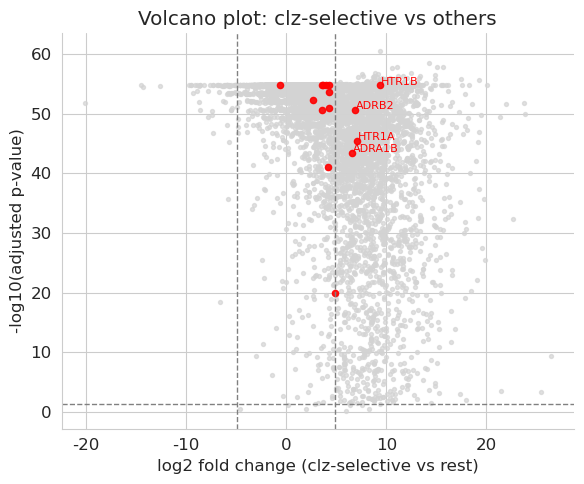

In [28]:
gpcr_genes = [
    'HTR1A','HTR1B','HTR1D','HTR1E',
    'HTR2A','HTR2B','HTR2C','HTR3A','HTR4',
    'HTR5A','HTR6','HTR7',
    'DRD1','DRD2','DRD3','DRD4','DRD5',
    'HRH1','HRH2','HRH3',
    'CHRM1','CHRM2','CHRM3','CHRM4','CHRM5',
    'ADRA1A','ADRA1B','ADRA2A','ADRA2B','ADRA2C',
    'ADRB1','ADRB2'
]

de_df["is_gpcr"] = de_df["gene"].isin(gpcr_genes)

log2fc_thr = np.log2(30)
p_thr = 0.05

fig, ax = plt.subplots(figsize=(6, 5))

# 背景（非 GPCR）
bg = de_df[~de_df["is_gpcr"]]
ax.scatter(
    bg["log2FC"],
    bg["neg_log10_p"],
    s=8,
    color="lightgray",
    alpha=0.7,
    label="other genes"
)

# GPCR
gp = de_df[de_df["is_gpcr"]]
ax.scatter(
    gp["log2FC"],
    gp["neg_log10_p"],
    s=20,
    color="red",
    alpha=0.9,
    label="GPCR genes"
)

# 閾値ライン
ax.axvline(log2fc_thr,  color="gray", linestyle="--", linewidth=1)
ax.axvline(-log2fc_thr, color="gray", linestyle="--", linewidth=1)
ax.axhline(-np.log10(p_thr), color="gray", linestyle="--", linewidth=1)

# GPCR ラベル（全部だときつければ条件絞る）
gp_label = gp[(gp["p_adj"] < p_thr) & (gp["log2FC"].abs() > log2fc_thr)]
#for _, row in gp.iterrows():
for _, row in gp_label.iterrows():
    ax.text(
        row["log2FC"] + 0.05,
        row["neg_log10_p"] + 0.1,
        row["gene"],
        fontsize=8,
        color="red"
    )

ax.set_xlabel("log2 fold change (clz-selective vs rest)")
ax.set_ylabel("-log10(adjusted p-value)")
ax.set_title("Volcano plot: clz-selective vs others")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
#ax.legend(frameon=False, loc="upper right")

plt.tight_layout()
out_pdf = os.path.join(outdir, "volcano_clz_selective_log2FC_GPCRhighlight.pdf")
fig.savefig(out_pdf, bbox_inches="tight")

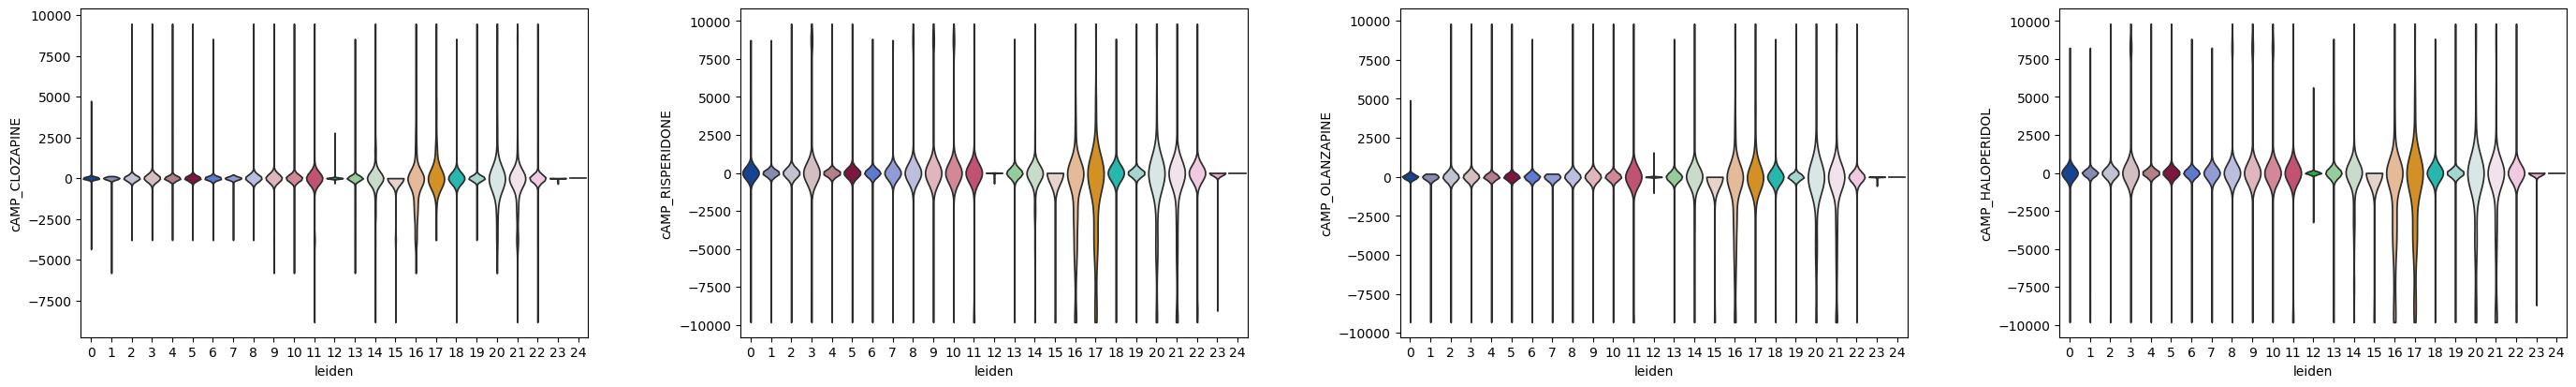

In [12]:
sc.pl.violin(
    adata,
    keys=['cAMP_CLOZAPINE',"cAMP_RISPERIDONE","cAMP_OLANZAPINE","cAMP_HALOPERIDOL"],  # Y軸に表示する変数
    groupby='leiden',       # X軸に leiden クラスタを使用
    jitter=True,            # データ点のばらつきを表示（オプション）
    stripplot=False,         # ストリッププロットを追加（オプション）
    legend=False
    
)

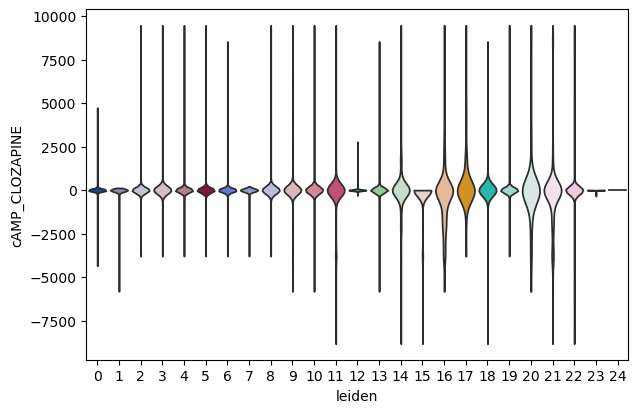

In [13]:
sc.pl.violin(
    adata,
    keys=['cAMP_CLOZAPINE'],  # Y軸に表示する変数
    groupby='leiden',       # X軸に leiden クラスタを使用
    jitter=True,            # データ点のばらつきを表示（オプション）
    stripplot=False,         # ストリッププロットを追加（オプション）
    legend=False
    
)

In [ ]:
sc.pl.umap(adata,color=["leiden"])
sc.pl.umap(adata,color=["is_clz_selective"])

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.backends.backend_pdf import PdfPages

# ============================
# フォント設定（Illustratorで文字編集可）
# ============================
rcParams["font.family"] = "Arial"          # ない場合は "DejaVu Sans"
rcParams["pdf.fonttype"] = 42              # TrueTypeフォントを埋め込み（Illustratorで編集可）
rcParams["ps.fonttype"] = 42
rcParams["axes.unicode_minus"] = False

sns.set_context("talk")
sns.set_style("whitegrid")

# ============================
# 設定
# ============================
keys = [
    "cAMP_CLOZAPINE",
    "cAMP_OLANZAPINE",
    "cAMP_RISPERIDONE",
    "cAMP_HALOPERIDOL",
]

# leiden カテゴリ化とパレット作成
if not pd.api.types.is_categorical_dtype(adata.obs["leiden"]):
    adata.obs["leiden"] = adata.obs["leiden"].astype("category")

leiden_cats   = adata.obs["leiden"].cat.categories
leiden_colors = adata.uns["leiden_colors"]
palette = {cat: col for cat, col in zip(leiden_cats, leiden_colors)}

# ============================
# 複数図を1つのPDFに保存
# ============================
pdf_name = "/data/mouse_PFC/WT_only/figures/boxplots_cAMP_all.pdf"

with PdfPages(pdf_name) as pdf:
    for key in keys:
        if key not in adata.obs.columns:
            print(f"⚠️ {key} not found in adata.obs. Skipped.")
            continue

        # ---- データ準備 ----
        df = adata.obs[["leiden", key]].copy().dropna()
        if not pd.api.types.is_categorical_dtype(df["leiden"]):
            df["leiden"] = df["leiden"].astype("category")

        # ---- プロット ----
        fig, ax = plt.subplots(figsize=(10, 4))
        sns.boxplot(
            data=df,
            x="leiden",
            y=key,
            palette=palette,
            showfliers=False,
            ax=ax
        )

        ax.set_xlabel("Leiden cluster")
        ax.set_ylabel(key)
        ax.set_title(f"{key} by Leiden cluster", pad=15)
        plt.tight_layout()

        # ---- PDFに追加 ----
        pdf.savefig(fig)
        plt.close(fig)

print(f"✅ Saved all boxplots into one Illustrator-editable PDF: {pdf_name}")

✅ Saved all boxplots into one Illustrator-editable PDF: /data/mouse_PFC/WT_only/figures/boxplots_cAMP_all.pdf


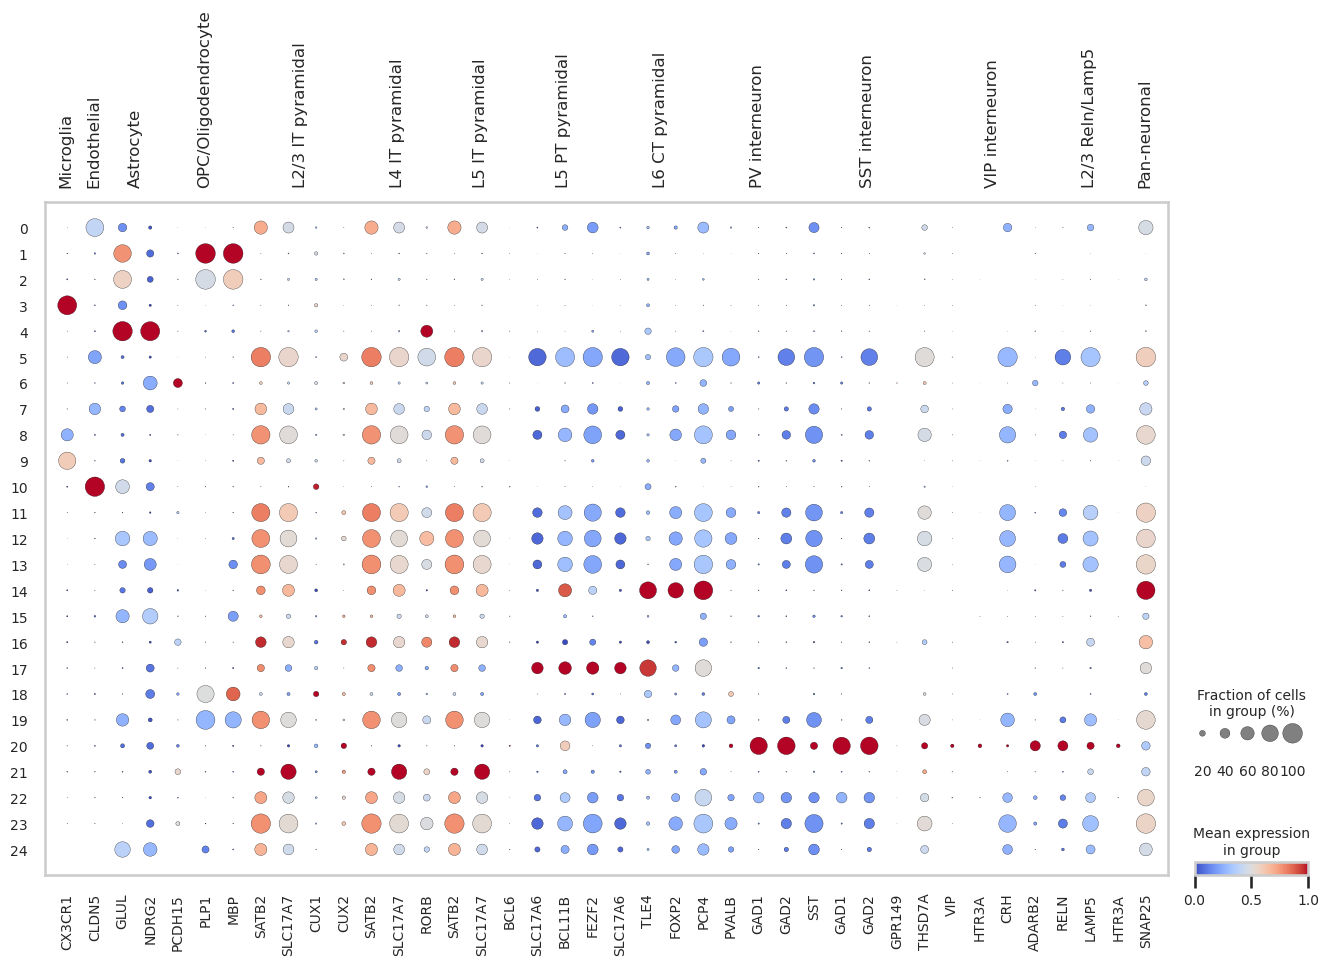

<Figure size 640x480 with 0 Axes>

In [30]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams["pdf.fonttype"] = 42  # TrueTypeフォントで保存（AIで編集可能）
rcParams["ps.fonttype"] = 42
rcParams["font.family"] = "DejaVu Sans"  # 読みやすくAI互換性の高いフォント
rcParams["axes.unicode_minus"] = False
rcParams["font.size"] = 12 
marker_dict_extended = {
    # グリア・その他
    "Microglia": ["CX3CR1"],
    "Endothelial": ["CLDN5"],
    "Astrocyte": ["GLUL", "NDRG2"],
    "OPC/Oligodendrocyte": ["PCDH15", "PLP1", "MBP"],

    # 興奮性ニューロン層別
    "L2/3 IT pyramidal": ["SATB2", "SLC17A7", "CUX1", "CUX2"],
    "L4 IT pyramidal": ["SATB2", "SLC17A7", "RORB"],
    "L5 IT pyramidal": ["SATB2", "SLC17A7", "BCL6"],
    "L5 PT pyramidal": ["SLC17A6", "BCL11B", "FEZF2"],
    "L6 CT pyramidal": ["SLC17A6", "TLE4", "FOXP2", "PCP4"],

    # インターニューロン
    "PV interneuron": ["PVALB", "GAD1", "GAD2"],
    "SST interneuron": ["SST", "GAD1", "GAD2", "GPR149", "THSD7A"],
    "VIP interneuron": ["VIP", "HTR3A", "CRH", "ADARB2"],
    "L2/3 Reln/Lamp5": ["RELN", "LAMP5", "HTR3A"],

    # 汎ニューロン
    "Pan-neuronal": ["SNAP25"]
}
sc.pl.dotplot(
    adata,
    var_names=marker_dict_extended,
    groupby="leiden",
    standard_scale="var",
    color_map="coolwarm"
)
plt.savefig("/data/mouse_PFC/WT_only/figures/dotplot_marker.pdf", bbox_inches="tight")
#plt.savefig("/data/figures/dotplot_marker.pdf")

In [31]:
import os
import re
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
from scipy.stats import fisher_exact, mannwhitneyu

# =========================
# settings
# =========================

OUTDIR = "/data/mouse_PFC/WT_only/clz_marker_based_analysis"
os.makedirs(OUTDIR, exist_ok=True)

CLZ_COL = "is_clz_selective"
LAYER = "lognorm"
RAW_LAYER = "raw_counts"

marker_dict_extended = {
    # グリア・その他
    "Microglia": ["CX3CR1"],
    "Endothelial": ["CLDN5"],
    "Astrocyte": ["GLUL", "NDRG2"],
    "OPC/Oligodendrocyte": ["PCDH15", "PLP1", "MBP"],

    # 興奮性ニューロン層別
    "L2/3 IT pyramidal": ["SATB2", "SLC17A7", "CUX1", "CUX2"],
    "L4 IT pyramidal": ["SATB2", "SLC17A7", "RORB"],
    "L5 IT pyramidal": ["SATB2", "SLC17A7", "BCL6"],
    "L5 PT pyramidal": ["SLC17A6", "BCL11B", "FEZF2"],
    "L6 CT pyramidal": ["SLC17A6", "TLE4", "FOXP2", "PCP4"],

    # インターニューロン
    "PV interneuron": ["PVALB", "GAD1", "GAD2"],
    "SST interneuron": ["SST", "GAD1", "GAD2", "GPR149", "THSD7A"],
    "VIP interneuron": ["VIP", "HTR3A", "CRH", "ADARB2"],
    "L2/3 Reln/Lamp5": ["RELN", "LAMP5", "HTR3A"],

    # 汎ニューロン
    "Pan-neuronal": ["SNAP25"]
}

GLIA_TYPES = [
    "Microglia",
    "Endothelial",
    "Astrocyte",
    "OPC/Oligodendrocyte"
]

EXC_TYPES = [
    "L2/3 IT pyramidal",
    "L4 IT pyramidal",
    "L5 IT pyramidal",
    "L5 PT pyramidal",
    "L6 CT pyramidal"
]

INH_TYPES = [
    "PV interneuron",
    "SST interneuron",
    "VIP interneuron",
    "L2/3 Reln/Lamp5"
]

PAN_TYPES = [
    "Pan-neuronal"
]


# =========================
# helper functions
# =========================

def sanitize_name(x):
    x = str(x)
    x = re.sub(r"[^\w]+", "_", x)
    x = re.sub(r"_+", "_", x)
    return x.strip("_")


def ensure_clz_group(adata, clz_col=CLZ_COL):
    adata.obs["_clz_group"] = (
        adata.obs[clz_col]
        .astype(str)
        .str.upper()
        .replace({"1": "TRUE", "0": "FALSE"})
        .astype("category")
    )
    print(adata.obs["_clz_group"].value_counts())
    return adata.obs["_clz_group"].isin(["TRUE", "FALSE"])


def ensure_lognorm_layer(adata, layer=LAYER, raw_layer=RAW_LAYER):
    if layer in adata.layers:
        print(f"adata.layers['{layer}'] already exists.")
        return

    if raw_layer not in adata.layers:
        raise ValueError(f"adata.layers['{raw_layer}'] not found.")

    print(f"Creating adata.layers['{layer}'] from adata.layers['{raw_layer}']...")
    adata.layers[layer] = adata.layers[raw_layer].copy()

    sc.pp.normalize_total(
        adata,
        target_sum=1e4,
        layer=layer
    )
    sc.pp.log1p(
        adata,
        layer=layer
    )

    adata.layers[layer] = adata.layers[layer].astype("float32")
    print("done.")


def resolve_genes(adata, genes):
    """
    大文字小文字を吸収して、adata.var_names中の正式名に戻す。
    """
    var_map = {str(g).upper(): str(g) for g in adata.var_names}
    found = []
    missing = []

    for g in genes:
        gu = str(g).upper()
        if gu in var_map:
            found.append(var_map[gu])
        else:
            missing.append(g)

    return found, missing


def get_matrix_values(adata, genes, layer=LAYER):
    found, missing = resolve_genes(adata, genes)

    if len(found) == 0:
        return None, found, missing

    idx = [adata.var_names.get_loc(g) for g in found]

    if layer is None:
        X = adata.X[:, idx]
    else:
        X = adata.layers[layer][:, idx]

    if sp.issparse(X):
        X = X.toarray()

    return np.asarray(X), found, missing


def add_marker_scores(adata, marker_dict, layer=LAYER):
    """
    各marker setの平均lognorm発現を adata.obs に追加。
    """
    marker_info = []

    for label, genes in marker_dict.items():
        X, found, missing = get_matrix_values(adata, genes, layer=layer)
        col = f"score_{sanitize_name(label)}"

        if X is None:
            adata.obs[col] = np.nan
        else:
            adata.obs[col] = X.mean(axis=1)

        marker_info.append({
            "marker_set": label,
            "score_col": col,
            "found_genes": ",".join(found),
            "missing_genes": ",".join(missing),
            "n_found": len(found),
            "n_missing": len(missing),
        })

    marker_info = pd.DataFrame(marker_info)
    marker_info.to_csv(
        os.path.join(OUTDIR, "marker_set_gene_check.csv"),
        index=False
    )

    return marker_info


def bh_fdr(pvals):
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    q = ranked * n / (np.arange(n) + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty(n)
    out[order] = np.minimum(q, 1.0)
    return out


def category_enrichment(obs, category_col, group_col="_clz_group"):
    """
    各categoryにclz TRUEが濃縮しているかFisher exact test。
    """
    df = obs[[category_col, group_col]].copy()
    df = df[df[group_col].isin(["TRUE", "FALSE"])]
    df[category_col] = df[category_col].astype(str)

    rows = []

    for cat in sorted(df[category_col].unique()):
        in_cat = df[category_col] == cat
        is_true = df[group_col] == "TRUE"

        a = int((in_cat & is_true).sum())
        b = int((in_cat & ~is_true).sum())
        c = int((~in_cat & is_true).sum())
        d = int((~in_cat & ~is_true).sum())

        odds, p = fisher_exact([[a, b], [c, d]])

        rows.append({
            "category": cat,
            "n_TRUE_in_category": a,
            "n_FALSE_in_category": b,
            "n_TRUE_outside": c,
            "n_FALSE_outside": d,
            "clz_fraction_in_category": a / (a + b) if (a + b) > 0 else np.nan,
            "clz_fraction_outside": c / (c + d) if (c + d) > 0 else np.nan,
            "odds_ratio": odds,
            "pval": p,
        })

    out = pd.DataFrame(rows)

    if len(out) > 0:
        out["pval_adj"] = bh_fdr(out["pval"].values)
        out = out.sort_values(
            ["pval_adj", "odds_ratio"],
            ascending=[True, False]
        )

    return out


def compare_scores_true_vs_false(adata, score_cols, group_col="_clz_group"):
    rows = []

    for col in score_cols:
        x = adata.obs.loc[adata.obs[group_col] == "TRUE", col].dropna()
        y = adata.obs.loc[adata.obs[group_col] == "FALSE", col].dropna()

        if len(x) == 0 or len(y) == 0:
            continue

        stat, p = mannwhitneyu(x, y, alternative="two-sided")

        rows.append({
            "score_col": col,
            "marker_set": col.replace("score_", ""),
            "mean_TRUE": x.mean(),
            "mean_FALSE": y.mean(),
            "median_TRUE": x.median(),
            "median_FALSE": y.median(),
            "delta_mean_TRUE_minus_FALSE": x.mean() - y.mean(),
            "pval": p,
            "n_TRUE": len(x),
            "n_FALSE": len(y),
        })

    out = pd.DataFrame(rows)

    if len(out) > 0:
        out["pval_adj"] = bh_fdr(out["pval"].values)
        out = out.sort_values(
            ["pval_adj", "delta_mean_TRUE_minus_FALSE"],
            ascending=[True, False]
        )

    return out


def run_deg(adata_sub, prefix, layer=LAYER):
    adata_sub = adata_sub[
        adata_sub.obs["_clz_group"].isin(["TRUE", "FALSE"])
    ].copy()

    adata_sub.obs["_clz_group"] = adata_sub.obs["_clz_group"].astype("category")

    print(prefix)
    print(adata_sub.obs["_clz_group"].value_counts())

    sc.tl.rank_genes_groups(
        adata_sub,
        groupby="_clz_group",
        groups=["TRUE"],
        reference="FALSE",
        method="wilcoxon",
        layer=layer,
        use_raw=False,
        pts=True
    )

    df = sc.get.rank_genes_groups_df(adata_sub, group="TRUE")
    path = os.path.join(OUTDIR, f"{prefix}_DEG_TRUE_vs_FALSE.csv")
    df.to_csv(path, index=False)

    print("saved:", path)
    return df


# =========================
# prepare
# =========================

ensure_lognorm_layer(adata, layer=LAYER, raw_layer=RAW_LAYER)
valid_clz = ensure_clz_group(adata, CLZ_COL)

marker_info = add_marker_scores(
    adata,
    marker_dict_extended,
    layer=LAYER
)

print(marker_info)


# =========================
# marker score columns
# =========================

glia_score_cols = [f"score_{sanitize_name(x)}" for x in GLIA_TYPES]
exc_score_cols = [f"score_{sanitize_name(x)}" for x in EXC_TYPES]
inh_score_cols = [f"score_{sanitize_name(x)}" for x in INH_TYPES]
pan_score_cols = [f"score_{sanitize_name(x)}" for x in PAN_TYPES]

all_marker_score_cols = (
    glia_score_cols + exc_score_cols + inh_score_cols + pan_score_cols
)

# major score
adata.obs["_glia_score"] = adata.obs[glia_score_cols].max(axis=1)
adata.obs["_exc_score"] = adata.obs[exc_score_cols].max(axis=1)
adata.obs["_inh_score"] = adata.obs[inh_score_cols].max(axis=1)
adata.obs["_pan_neuronal_score"] = adata.obs[pan_score_cols].max(axis=1)

# best detailed marker type
detail_cols = glia_score_cols + exc_score_cols + inh_score_cols
score_to_label = {
    f"score_{sanitize_name(k)}": k
    for k in GLIA_TYPES + EXC_TYPES + INH_TYPES
}

adata.obs["_best_marker_score_col"] = adata.obs[detail_cols].idxmax(axis=1)
adata.obs["_best_marker_type"] = adata.obs["_best_marker_score_col"].map(score_to_label)

# major class
def assign_major_class(row):
    scores = {
        "glia_or_other": row["_glia_score"],
        "excitatory": row["_exc_score"],
        "inhibitory": row["_inh_score"],
    }
    return max(scores, key=scores.get)

adata.obs["_major_marker_class"] = adata.obs.apply(assign_major_class, axis=1)

# neuronal限定でexc/inhを決めたい場合
def assign_neuron_class(row, margin=0.02):
    if row["_exc_score"] > row["_inh_score"] + margin:
        return "excitatory_like"
    elif row["_inh_score"] > row["_exc_score"] + margin:
        return "inhibitory_like"
    else:
        return "ambiguous"

adata.obs["_exc_inh_marker_class"] = adata.obs.apply(assign_neuron_class, axis=1)


# =========================
# 1) glia以外で、clz反応細胞は興奮性 or 抑制性か
# =========================

adata_valid = adata[valid_clz].copy()

# marker scoreでglia_or_otherがbestの細胞を除外
adata_nonglia = adata_valid[
    adata_valid.obs["_major_marker_class"] != "glia_or_other"
].copy()

print("valid cells:", adata_valid.n_obs)
print("non-glia marker-based cells:", adata_nonglia.n_obs)

# excitatory / inhibitory / ambiguous のクロス集計
tab_exc_inh = pd.crosstab(
    adata_nonglia.obs["_exc_inh_marker_class"],
    adata_nonglia.obs["_clz_group"]
)

tab_exc_inh["clz_TRUE_fraction"] = (
    tab_exc_inh.get("TRUE", 0) / tab_exc_inh.sum(axis=1)
)

tab_exc_inh.to_csv(
    os.path.join(OUTDIR, "01_nonglia_exc_inh_clz_fraction.csv")
)

enrich_exc_inh = category_enrichment(
    adata_nonglia.obs,
    category_col="_exc_inh_marker_class",
    group_col="_clz_group"
)

enrich_exc_inh.to_csv(
    os.path.join(OUTDIR, "01_nonglia_exc_inh_enrichment.csv"),
    index=False
)

# 詳細marker typeごとの濃縮
tab_detail = pd.crosstab(
    adata_nonglia.obs["_best_marker_type"],
    adata_nonglia.obs["_clz_group"]
)

tab_detail["clz_TRUE_fraction"] = (
    tab_detail.get("TRUE", 0) / tab_detail.sum(axis=1)
)

tab_detail.to_csv(
    os.path.join(OUTDIR, "01_nonglia_best_marker_type_clz_fraction.csv")
)

enrich_detail = category_enrichment(
    adata_nonglia.obs,
    category_col="_best_marker_type",
    group_col="_clz_group"
)

enrich_detail.to_csv(
    os.path.join(OUTDIR, "01_nonglia_best_marker_type_enrichment.csv"),
    index=False
)

# score自体のTRUE vs FALSE比較
df_score_all = compare_scores_true_vs_false(
    adata_nonglia,
    score_cols=exc_score_cols + inh_score_cols + pan_score_cols,
    group_col="_clz_group"
)

df_score_all.to_csv(
    os.path.join(OUTDIR, "01_nonglia_marker_scores_TRUE_vs_FALSE.csv"),
    index=False
)

# non-glia内 DEG
df_deg_nonglia = run_deg(
    adata_nonglia,
    prefix="01_nonglia",
    layer=LAYER
)


# =========================
# 2) 興奮性の中でのサブタイプ解析
# =========================

adata_exc = adata_nonglia[
    adata_nonglia.obs["_exc_inh_marker_class"] == "excitatory_like"
].copy()

print("excitatory-like cells:", adata_exc.n_obs)
print(adata_exc.obs["_clz_group"].value_counts())

# 興奮性サブタイプのbest marker type
adata_exc.obs["_best_exc_subtype_col"] = adata_exc.obs[exc_score_cols].idxmax(axis=1)

exc_score_to_label = {
    f"score_{sanitize_name(k)}": k
    for k in EXC_TYPES
}

adata_exc.obs["_best_exc_subtype"] = adata_exc.obs["_best_exc_subtype_col"].map(exc_score_to_label)

# subtypeごとのclz fraction
tab_exc_subtype = pd.crosstab(
    adata_exc.obs["_best_exc_subtype"],
    adata_exc.obs["_clz_group"]
)

tab_exc_subtype["clz_TRUE_fraction"] = (
    tab_exc_subtype.get("TRUE", 0) / tab_exc_subtype.sum(axis=1)
)

tab_exc_subtype.to_csv(
    os.path.join(OUTDIR, "02_excitatory_subtype_clz_fraction.csv")
)

# subtype enrichment
enrich_exc_subtype = category_enrichment(
    adata_exc.obs,
    category_col="_best_exc_subtype",
    group_col="_clz_group"
)

enrich_exc_subtype.to_csv(
    os.path.join(OUTDIR, "02_excitatory_subtype_enrichment.csv"),
    index=False
)

# subtype marker scoreのTRUE vs FALSE比較
df_exc_score_test = compare_scores_true_vs_false(
    adata_exc,
    score_cols=exc_score_cols,
    group_col="_clz_group"
)

df_exc_score_test.to_csv(
    os.path.join(OUTDIR, "02_excitatory_subtype_scores_TRUE_vs_FALSE.csv"),
    index=False
)

# 興奮性細胞内DEG
df_deg_exc = run_deg(
    adata_exc,
    prefix="02_excitatory_only",
    layer=LAYER
)


# =========================
# Optional: marker positive rate using raw_counts
# =========================

def raw_positive_fraction_by_group(adata, marker_dict, raw_layer=RAW_LAYER, group_col="_clz_group"):
    if raw_layer not in adata.layers:
        print(f"{raw_layer} not found. skip raw positive fraction.")
        return None

    rows = []

    for marker_set, genes in marker_dict.items():
        X, found, missing = get_matrix_values(adata, genes, layer=raw_layer)

        if X is None:
            continue

        positive_any = (X > 0).any(axis=1)

        tmp = pd.DataFrame({
            "group": adata.obs[group_col].values,
            "positive_any_marker": positive_any
        })

        rates = tmp.groupby("group")["positive_any_marker"].mean()
        counts = tmp.groupby("group")["positive_any_marker"].sum()
        ns = tmp.groupby("group")["positive_any_marker"].count()

        row = {
            "marker_set": marker_set,
            "found_genes": ",".join(found),
            "missing_genes": ",".join(missing),
        }

        for g in rates.index:
            row[f"positive_fraction_{g}"] = rates.loc[g]
            row[f"positive_count_{g}"] = counts.loc[g]
            row[f"n_{g}"] = ns.loc[g]

        rows.append(row)

    return pd.DataFrame(rows)


df_raw_pos_nonglia = raw_positive_fraction_by_group(
    adata_nonglia,
    marker_dict_extended,
    raw_layer=RAW_LAYER,
    group_col="_clz_group"
)

if df_raw_pos_nonglia is not None:
    df_raw_pos_nonglia.to_csv(
        os.path.join(OUTDIR, "01_nonglia_raw_positive_fraction_by_marker_set.csv"),
        index=False
    )

df_raw_pos_exc = raw_positive_fraction_by_group(
    adata_exc,
    {k: marker_dict_extended[k] for k in EXC_TYPES},
    raw_layer=RAW_LAYER,
    group_col="_clz_group"
)

if df_raw_pos_exc is not None:
    df_raw_pos_exc.to_csv(
        os.path.join(OUTDIR, "02_excitatory_raw_positive_fraction_by_subtype_marker_set.csv"),
        index=False
    )


# =========================
# save obs with scores
# =========================

adata.obs.to_csv(
    os.path.join(OUTDIR, "adata_obs_with_marker_scores_all_cells.csv")
)

adata_nonglia.obs.to_csv(
    os.path.join(OUTDIR, "adata_obs_with_marker_scores_nonglia.csv")
)

adata_exc.obs.to_csv(
    os.path.join(OUTDIR, "adata_obs_with_marker_scores_excitatory.csv")
)

print("Done.")
print("Output dir:", OUTDIR)

adata.layers['lognorm'] already exists.
_clz_group
FALSE    15552
TRUE       207
Name: count, dtype: int64
             marker_set                  score_col  \
0             Microglia            score_Microglia   
1           Endothelial          score_Endothelial   
2             Astrocyte            score_Astrocyte   
3   OPC/Oligodendrocyte  score_OPC_Oligodendrocyte   
4     L2/3 IT pyramidal    score_L2_3_IT_pyramidal   
5       L4 IT pyramidal      score_L4_IT_pyramidal   
6       L5 IT pyramidal      score_L5_IT_pyramidal   
7       L5 PT pyramidal      score_L5_PT_pyramidal   
8       L6 CT pyramidal      score_L6_CT_pyramidal   
9        PV interneuron       score_PV_interneuron   
10      SST interneuron      score_SST_interneuron   
11      VIP interneuron      score_VIP_interneuron   
12      L2/3 Reln/Lamp5      score_L2_3_Reln_Lamp5   
13         Pan-neuronal         score_Pan_neuronal   

                    found_genes missing_genes  n_found  n_missing  
0             

In [32]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc

# =========================
# figure settings
# =========================
OUTDIR = "/data/mouse_PFC/WT_only/clz_marker_based_analysis"
FIGDIR = os.path.join(OUTDIR, "figures")
os.makedirs(FIGDIR, exist_ok=True)

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 12


# =========================
# helper plot functions
# =========================

def savefig(name):
    path_pdf = os.path.join(FIGDIR, f"{name}.pdf")
    path_png = os.path.join(FIGDIR, f"{name}.png")
    plt.tight_layout()
    plt.savefig(path_pdf, bbox_inches="tight")
    plt.savefig(path_png, dpi=300, bbox_inches="tight")
    plt.close()
    print("saved:", path_pdf)


def plot_clz_fraction(tab, title, filename):
    """
    crosstabに clz_TRUE_fraction が入っている前提
    """
    df = tab.copy()
    df = df.sort_values("clz_TRUE_fraction", ascending=False)

    plt.figure(figsize=(6, max(3, 0.45 * len(df))))
    y = np.arange(len(df))

    plt.barh(y, df["clz_TRUE_fraction"])
    plt.yticks(y, df.index)
    plt.xlabel("Fraction of clozapine-responsive cells")
    plt.xlim(0, 1)
    plt.title(title)
    plt.gca().invert_yaxis()

    for i, v in enumerate(df["clz_TRUE_fraction"]):
        plt.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=10)

    savefig(filename)


def plot_enrichment(df, title, filename, top_n=20):
    """
    Fisher enrichment result:
    category, odds_ratio, pval_adj を想定
    """
    if df is None or len(df) == 0:
        print("skip:", filename)
        return

    d = df.copy()
    d = d.replace([np.inf, -np.inf], np.nan)
    d["minus_log10_fdr"] = -np.log10(d["pval_adj"].clip(lower=1e-300))
    d = d.sort_values("odds_ratio", ascending=False).head(top_n)

    plt.figure(figsize=(7, max(3, 0.45 * len(d))))
    y = np.arange(len(d))

    plt.barh(y, d["odds_ratio"])
    plt.yticks(y, d["category"])
    plt.xlabel("Odds ratio for clozapine-responsive enrichment")
    plt.title(title)
    plt.axvline(1, linestyle="--", linewidth=1)
    plt.gca().invert_yaxis()

    for i, row in enumerate(d.itertuples()):
        plt.text(
            row.odds_ratio + 0.05,
            i,
            f"FDR={row.pval_adj:.1e}",
            va="center",
            fontsize=9
        )

    savefig(filename)


def plot_score_delta(df, title, filename, top_n=20):
    """
    marker score TRUE vs FALSE:
    marker_set/score_col, delta_mean_TRUE_minus_FALSE, pval_adj を想定
    """
    if df is None or len(df) == 0:
        print("skip:", filename)
        return

    d = df.copy()
    label_col = "marker_set" if "marker_set" in d.columns else "score_col"
    d = d.sort_values("delta_mean_TRUE_minus_FALSE", ascending=False).head(top_n)

    plt.figure(figsize=(7, max(3, 0.45 * len(d))))
    y = np.arange(len(d))

    plt.barh(y, d["delta_mean_TRUE_minus_FALSE"])
    plt.yticks(y, d[label_col])
    plt.xlabel("Mean marker score difference\n(TRUE - FALSE)")
    plt.title(title)
    plt.axvline(0, linestyle="--", linewidth=1)
    plt.gca().invert_yaxis()

    for i, row in enumerate(d.itertuples()):
        if hasattr(row, "pval_adj"):
            plt.text(
                row.delta_mean_TRUE_minus_FALSE,
                i,
                f"  FDR={row.pval_adj:.1e}",
                va="center",
                fontsize=9
            )

    savefig(filename)


def plot_stacked_composition(obs, category_col, group_col="_clz_group", title="", filename="composition"):
    """
    TRUE/FALSEごとのcategory構成比をstacked barで表示
    """
    df = obs[[category_col, group_col]].copy()
    df = df[df[group_col].isin(["TRUE", "FALSE"])]
    df[category_col] = df[category_col].astype(str)

    tab = pd.crosstab(df[group_col], df[category_col])
    prop = tab.div(tab.sum(axis=1), axis=0)

    plt.figure(figsize=(8, 4))
    bottom = np.zeros(len(prop))

    x = np.arange(len(prop.index))

    for col in prop.columns:
        vals = prop[col].values
        plt.bar(x, vals, bottom=bottom, label=col)
        bottom += vals

    plt.xticks(x, prop.index)
    plt.ylabel("Proportion")
    plt.ylim(0, 1)
    plt.title(title)
    plt.legend(
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        frameon=False
    )

    savefig(filename)


def plot_deg_volcano(df, title, filename, lfc_col="logfoldchanges", p_col="pvals_adj"):
    """
    DEG resultの簡易volcano
    """
    if df is None or len(df) == 0:
        print("skip:", filename)
        return

    d = df.copy()
    d = d.replace([np.inf, -np.inf], np.nan)
    d = d.dropna(subset=[lfc_col, p_col])
    d["minus_log10_fdr"] = -np.log10(d[p_col].clip(lower=1e-300))

    plt.figure(figsize=(5, 4))
    plt.scatter(
        d[lfc_col],
        d["minus_log10_fdr"],
        s=8,
        alpha=0.5
    )
    plt.axvline(0, linestyle="--", linewidth=1)
    plt.xlabel("log fold change")
    plt.ylabel("-log10(FDR)")
    plt.title(title)

    # 上位遺伝子をラベル
    top = d.sort_values(p_col).head(10)
    for _, row in top.iterrows():
        plt.text(
            row[lfc_col],
            row["minus_log10_fdr"],
            str(row["names"]),
            fontsize=8
        )

    savefig(filename)


# =========================
# 1) non-glia: excitatory vs inhibitory
# =========================

# Fraction plot
tab_exc_inh = pd.crosstab(
    adata_nonglia.obs["_exc_inh_marker_class"],
    adata_nonglia.obs["_clz_group"]
)
tab_exc_inh["clz_TRUE_fraction"] = (
    tab_exc_inh.get("TRUE", 0) / tab_exc_inh.sum(axis=1)
)

plot_clz_fraction(
    tab_exc_inh,
    title="Clozapine-responsive fraction by excitatory/inhibitory class",
    filename="01_nonglia_clz_fraction_exc_inh"
)

# Composition plot
plot_stacked_composition(
    adata_nonglia.obs,
    category_col="_exc_inh_marker_class",
    group_col="_clz_group",
    title="Excitatory/Inhibitory composition in clozapine-responsive vs non-responsive cells",
    filename="01_nonglia_exc_inh_composition_TRUE_FALSE"
)

# Enrichment plot
plot_enrichment(
    enrich_exc_inh,
    title="Excitatory/Inhibitory enrichment of clozapine-responsive cells",
    filename="01_nonglia_exc_inh_enrichment"
)

# Marker score delta plot
plot_score_delta(
    df_score_all,
    title="Marker score difference in non-glia cells",
    filename="01_nonglia_marker_score_delta_TRUE_minus_FALSE"
)


# =========================
# 2) non-glia detailed marker type
# =========================

tab_detail = pd.crosstab(
    adata_nonglia.obs["_best_marker_type"],
    adata_nonglia.obs["_clz_group"]
)
tab_detail["clz_TRUE_fraction"] = (
    tab_detail.get("TRUE", 0) / tab_detail.sum(axis=1)
)

plot_clz_fraction(
    tab_detail,
    title="Clozapine-responsive fraction by best marker type",
    filename="01_nonglia_clz_fraction_best_marker_type"
)

plot_stacked_composition(
    adata_nonglia.obs,
    category_col="_best_marker_type",
    group_col="_clz_group",
    title="Best marker type composition in TRUE vs FALSE",
    filename="01_nonglia_best_marker_type_composition_TRUE_FALSE"
)

plot_enrichment(
    enrich_detail,
    title="Best marker type enrichment of clozapine-responsive cells",
    filename="01_nonglia_best_marker_type_enrichment"
)


# =========================
# 3) excitatory subtype
# =========================

tab_exc_subtype = pd.crosstab(
    adata_exc.obs["_best_exc_subtype"],
    adata_exc.obs["_clz_group"]
)
tab_exc_subtype["clz_TRUE_fraction"] = (
    tab_exc_subtype.get("TRUE", 0) / tab_exc_subtype.sum(axis=1)
)

plot_clz_fraction(
    tab_exc_subtype,
    title="Clozapine-responsive fraction by excitatory subtype",
    filename="02_excitatory_clz_fraction_by_subtype"
)

plot_stacked_composition(
    adata_exc.obs,
    category_col="_best_exc_subtype",
    group_col="_clz_group",
    title="Excitatory subtype composition in TRUE vs FALSE",
    filename="02_excitatory_subtype_composition_TRUE_FALSE"
)

plot_enrichment(
    enrich_exc_subtype,
    title="Excitatory subtype enrichment of clozapine-responsive cells",
    filename="02_excitatory_subtype_enrichment"
)

plot_score_delta(
    df_exc_score_test,
    title="Excitatory subtype marker score difference",
    filename="02_excitatory_subtype_score_delta_TRUE_minus_FALSE"
)


# =========================
# 4) DEG volcano
# =========================

plot_deg_volcano(
    df_deg_nonglia,
    title="DEG in non-glia cells: clozapine-responsive vs non-responsive",
    filename="01_nonglia_DEG_volcano"
)

plot_deg_volcano(
    df_deg_exc,
    title="DEG in excitatory-like cells: clozapine-responsive vs non-responsive",
    filename="02_excitatory_DEG_volcano"
)


# =========================
# 5) Scanpy UMAP visualization
# =========================
# adataにX_umapがある場合のみ実行

if "X_umap" in adata.obsm:
    sc.pl.umap(
        adata,
        color=[
            "_clz_group",
            "_major_marker_class",
            "_exc_inh_marker_class",
            "_best_marker_type",
        ],
        frameon=False,
        wspace=0.4,
        show=False
    )
    plt.savefig(
        os.path.join(FIGDIR, "03_umap_clz_and_marker_classes.pdf"),
        bbox_inches="tight"
    )
    plt.savefig(
        os.path.join(FIGDIR, "03_umap_clz_and_marker_classes.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.close()

if "X_umap" in adata_exc.obsm:
    sc.pl.umap(
        adata_exc,
        color=[
            "_clz_group",
            "_best_exc_subtype",
            "_exc_score",
            "_inh_score",
        ],
        frameon=False,
        wspace=0.4,
        show=False
    )
    plt.savefig(
        os.path.join(FIGDIR, "03_umap_excitatory_subtypes.pdf"),
        bbox_inches="tight"
    )
    plt.savefig(
        os.path.join(FIGDIR, "03_umap_excitatory_subtypes.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.close()


# =========================
# 6) Dotplot: marker expression by clz group / subtype
# =========================

# TRUE vs FALSEでmarker expression
sc.pl.dotplot(
    adata_nonglia,
    var_names=marker_dict_extended,
    groupby="_clz_group",
    layer=LAYER,
    standard_scale="var",
    color_map="coolwarm",
    show=False
)
plt.savefig(
    os.path.join(FIGDIR, "04_dotplot_marker_expression_TRUE_FALSE_nonglia.pdf"),
    bbox_inches="tight"
)
plt.savefig(
    os.path.join(FIGDIR, "04_dotplot_marker_expression_TRUE_FALSE_nonglia.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()

# excitatory subtypeごとのmarker expression
sc.pl.dotplot(
    adata_exc,
    var_names={k: marker_dict_extended[k] for k in EXC_TYPES},
    groupby="_best_exc_subtype",
    layer=LAYER,
    standard_scale="var",
    color_map="coolwarm",
    show=False
)
plt.savefig(
    os.path.join(FIGDIR, "04_dotplot_exc_marker_expression_by_subtype.pdf"),
    bbox_inches="tight"
)
plt.savefig(
    os.path.join(FIGDIR, "04_dotplot_exc_marker_expression_by_subtype.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()


# =========================
# 7) Heatmap-like plot of marker scores
# =========================

def plot_score_heatmap(obs, score_cols, group_col, filename, title):
    d = obs[[group_col] + score_cols].copy()
    d = d[d[group_col].notna()]

    mean_df = d.groupby(group_col)[score_cols].mean()

    # z-score by marker score
    z = mean_df.copy()
    z = (z - z.mean(axis=0)) / z.std(axis=0).replace(0, np.nan)
    z = z.fillna(0)

    plt.figure(figsize=(max(6, 0.35 * len(score_cols)), 3))
    im = plt.imshow(z.values, aspect="auto")
    plt.colorbar(im, label="Z-scored mean marker score")

    plt.yticks(np.arange(z.shape[0]), z.index)
    plt.xticks(
        np.arange(z.shape[1]),
        [c.replace("score_", "") for c in z.columns],
        rotation=90
    )

    plt.title(title)
    savefig(filename)


plot_score_heatmap(
    adata_nonglia.obs,
    score_cols=exc_score_cols + inh_score_cols + pan_score_cols,
    group_col="_clz_group",
    filename="05_heatmap_marker_scores_TRUE_FALSE_nonglia",
    title="Mean marker scores in TRUE vs FALSE non-glia cells"
)

plot_score_heatmap(
    adata_exc.obs,
    score_cols=exc_score_cols,
    group_col="_clz_group",
    filename="05_heatmap_exc_subtype_scores_TRUE_FALSE",
    title="Mean excitatory subtype scores in TRUE vs FALSE cells"
)

print("All figures saved in:", FIGDIR)

saved: /data/mouse_PFC/WT_only/clz_marker_based_analysis/figures/01_nonglia_clz_fraction_exc_inh.pdf
saved: /data/mouse_PFC/WT_only/clz_marker_based_analysis/figures/01_nonglia_exc_inh_composition_TRUE_FALSE.pdf
saved: /data/mouse_PFC/WT_only/clz_marker_based_analysis/figures/01_nonglia_exc_inh_enrichment.pdf
saved: /data/mouse_PFC/WT_only/clz_marker_based_analysis/figures/01_nonglia_marker_score_delta_TRUE_minus_FALSE.pdf
saved: /data/mouse_PFC/WT_only/clz_marker_based_analysis/figures/01_nonglia_clz_fraction_best_marker_type.pdf
saved: /data/mouse_PFC/WT_only/clz_marker_based_analysis/figures/01_nonglia_best_marker_type_composition_TRUE_FALSE.pdf
saved: /data/mouse_PFC/WT_only/clz_marker_based_analysis/figures/01_nonglia_best_marker_type_enrichment.pdf
saved: /data/mouse_PFC/WT_only/clz_marker_based_analysis/figures/02_excitatory_clz_fraction_by_subtype.pdf
saved: /data/mouse_PFC/WT_only/clz_marker_based_analysis/figures/02_excitatory_subtype_composition_TRUE_FALSE.pdf
saved: /data/m

saved: /data/mouse_PFC/WT_only/figures/dotplot_marker_with_group_line.pdf


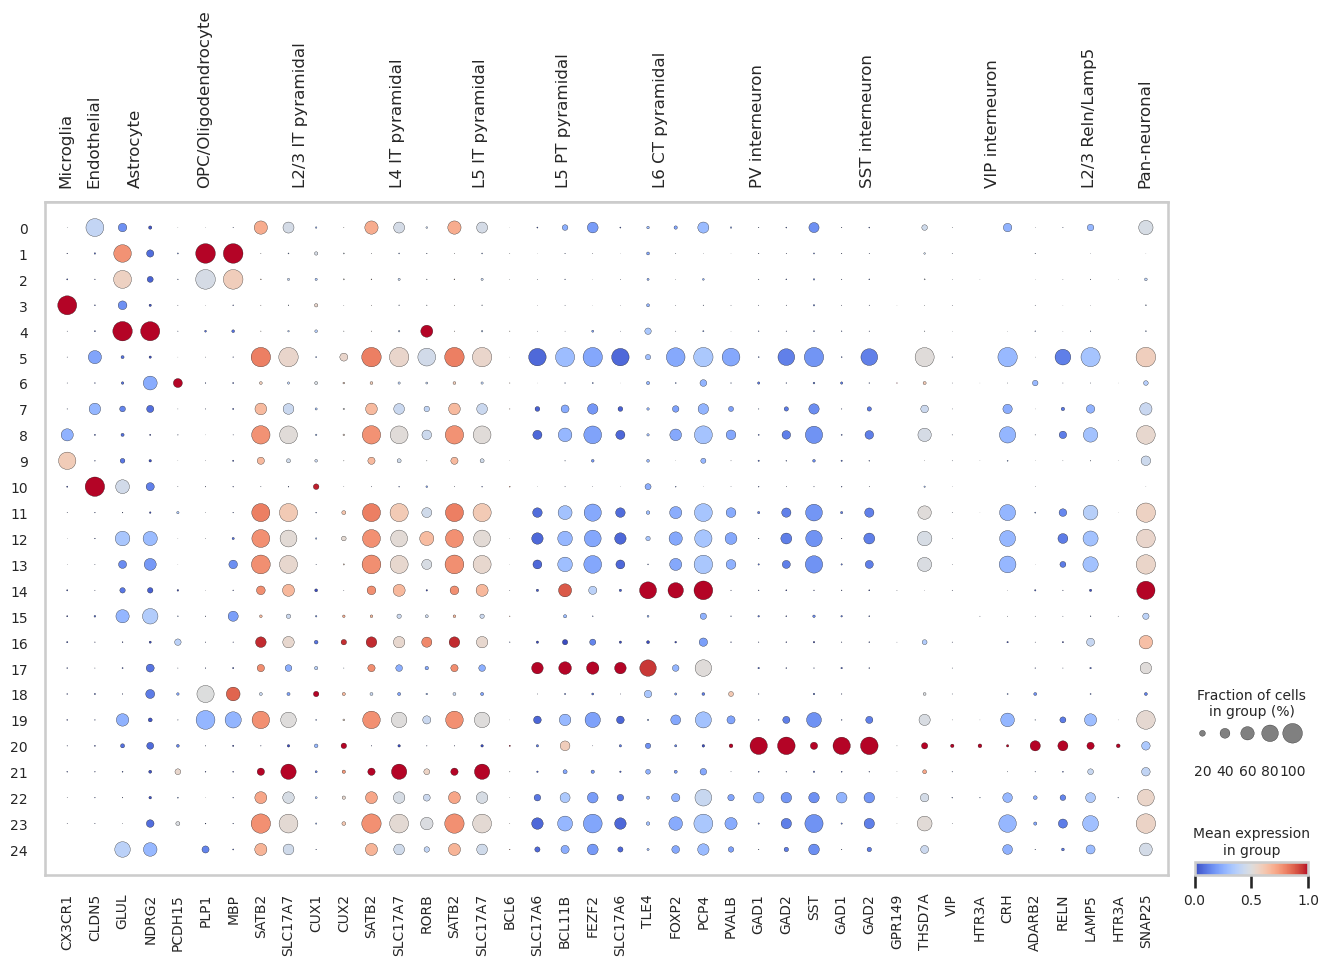

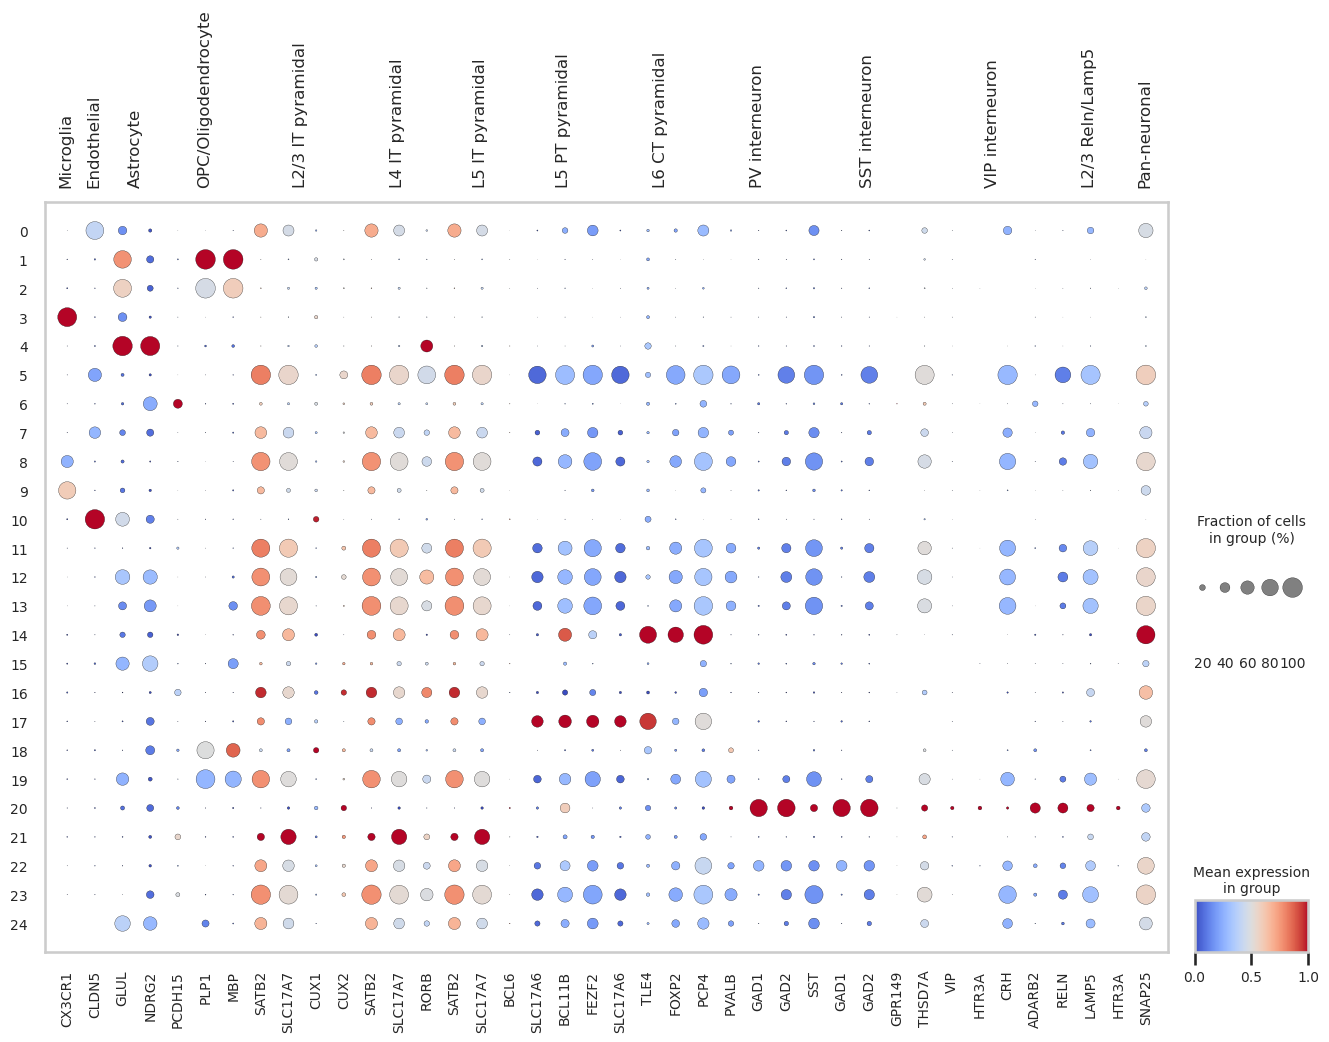

In [33]:
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib import rcParams

# フォントなど（必要なら）
rcParams["pdf.fonttype"] = 42
rcParams["ps.fonttype"] = 42
rcParams["font.family"] = "DejaVu Sans"
rcParams["font.size"] = 12
rcParams["axes.unicode_minus"] = False

# --- dotplot を作る（マーカー複数・dict指定版） ---
dp = sc.pl.dotplot(
    adata,
    var_names=marker_dict_extended,  # {"celltype": [genes...], ...}
    groupby="leiden",
    standard_scale="var",
    color_map="coolwarm",
    show=True,
    return_fig=True
)

# --- 軸オブジェクトを取る ---
axes = dp.get_axes()
gax = axes["gene_group_ax"]   # ← セルタイプラベルの軸

# --- 下線（spine）を復活させる ---
gax.spines["bottom"].set_visible(True)
gax.spines["bottom"].set_linewidth(1.0)
gax.spines["bottom"].set_color("black")
gax.axhline(0, color="black", lw=1)
# 必要なら全スパインをONにしてもOK
# for side in ["bottom", "left", "right", "top"]:
#     gax.spines[side].set_visible(True)
#     gax.spines[side].set_linewidth(1.0)
#     gax.spines[side].set_color("black")

# --- PDF保存（Illustratorで編集可能） ---
out_pdf = "/data/mouse_PFC/WT_only/figures/dotplot_marker_with_group_line.pdf"
dp.savefig(out_pdf, bbox_inches="tight")
print("saved:", out_pdf)


In [ ]:
import scanpy as sc
import pandas as pd

# ===== 1. マーカー辞書の定義 =====
marker_dict_extended = {
    "Microglia": ["CX3CR1"],
    "Endothelial": ["CLDN5"],
    "Astrocyte": ["GLUL", "NDRG2"],
    "OPC/Oligodendrocyte": ["PCDH15", "PLP1", "MBP"],

    "L2/3 IT pyramidal": ["SATB2", "SLC17A7", "CUX1", "CUX2"],
    "L4 IT pyramidal": ["SATB2", "SLC17A7", "RORB"],
    "L5 IT pyramidal": ["SATB2", "SLC17A7", "BCL6"],
    "L5 PT pyramidal": ["SLC17A6", "BCL11B", "FEZF2"],
    "L6 CT pyramidal": ["SLC17A6", "TLE4", "FOXP2", "PCP4"],

    "PV interneuron": ["PVALB", "GAD1", "GAD2"],
    "SST interneuron": ["SST", "GAD1", "GAD2", "GPR149", "THSD7A"],
    "VIP interneuron": ["VIP", "HTR3A", "CRH", "ADARB2"],
    "L2/3 Reln/Lamp5": ["RELN", "LAMP5", "HTR3A"],

    "Pan-neuronal": ["SNAP25"],
}

# ===== 2. 各細胞に cell-type スコアを付ける =====
for ct_name, genes in marker_dict_extended.items():
    sc.tl.score_genes(
        adata,
        gene_list=genes,
        score_name=f"score_{ct_name}",
        use_raw=False,      # 必要に応じて True に
    )

# ===== 3. leiden クラスタごとの平均スコアを計算 =====
score_cols = [c for c in adata.obs.columns if c.startswith("score_")]

cluster_scores = (
    adata.obs
    .groupby("leiden")[score_cols]
    .mean()
)

print("Cluster × cell-type score (mean per leiden):")
print(cluster_scores.round(2))

# ===== 4. 各クラスタで最大スコアの cell-type を自動候補として取得 =====
best_label_per_cluster = cluster_scores.idxmax(axis=1)             # "score_xxx"
best_label_per_cluster = best_label_per_cluster.str.replace(
    "^score_", "", regex=True
)  # "score_" プレフィックスを削除

print("\nAuto-suggested cell type per leiden cluster:")
print(best_label_per_cluster)

# （オプション）各細胞に予測 celltype を付与したい場合：
cluster2celltype = best_label_per_cluster.to_dict()
adata.obs["celltype_pred"] = adata.obs["leiden"].map(cluster2celltype)


# ===== フォント・PDF設定（Illustrator編集しやすく） =====
rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.unicode_minus": False,
})

# 1) score_◯◯ の列をピックアップ
score_cols = [c for c in adata.obs.columns if c.startswith("score_")]

# 2) クラスタごと × celltypeごとの平均スコア
cluster_scores = (
    adata.obs
    .groupby("leiden")[score_cols]
    .mean()
)

# 表示用に "score_" を外した列名に
cluster_scores.columns = [c.replace("score_", "") for c in cluster_scores.columns]

# 3) 小さめのヒートマップ
plt.figure(figsize=(12, 8))  # コンパクトなサイズ
sns.heatmap(
    cluster_scores.T,    # 行: celltype, 列: cluster にしたいので転置
    cmap="viridis",
    cbar_kws={"label": "mean score"},
    annot=False
)

plt.xlabel("Leiden cluster")
plt.ylabel("Cell-type score")
plt.tight_layout()

out_pdf = "/data/mouse_PFC/WT_only/figures/cluster_celltype_score_heatmap.pdf"
plt.savefig(out_pdf)

print("saved:", out_pdf)

Cluster × cell-type score (mean per leiden):
        score_Microglia  score_Endothelial  score_Astrocyte  \
leiden                                                        
0                 -0.33               1.02            -0.23   
1                 -0.26              -0.24             0.87   
2                 -0.25              -0.24             0.48   
3                  2.85              -0.29            -0.19   
4                 -0.18              -0.33             2.89   
5                 -0.36               0.29            -0.40   
6                 -0.37              -0.29            -0.00   
7                 -0.29               0.49            -0.17   
8                  0.49              -0.20            -0.39   
9                  1.58              -0.27            -0.30   
10                -0.09               3.23             0.51   
11                -0.33              -0.23            -0.45   
12                -0.33              -0.24             0.50   
13        

In [101]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ===== フォント・PDF設定 =====
rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.unicode_minus": False,
})

sns.set_context("talk")
sns.set_style("white")

# ===== 1. マーカー辞書の定義 =====
marker_dict_extended = {
    "Microglia": ["CX3CR1"],
    "Endothelial": ["CLDN5"],
    "Astrocyte": ["GLUL", "NDRG2"],
    "OPC/Oligodendrocyte": ["PCDH15", "PLP1", "MBP"],

    "L2/3 IT pyramidal": ["SATB2", "SLC17A7", "CUX1", "CUX2"],
    "L4 IT pyramidal": ["SATB2", "SLC17A7", "RORB"],
    "L5 IT pyramidal": ["SATB2", "SLC17A7", "BCL6"],
    "L5 PT pyramidal": ["SLC17A6", "BCL11B", "FEZF2"],
    "L6 CT pyramidal": ["SLC17A6", "TLE4", "FOXP2", "PCP4"],

    "PV interneuron": ["PVALB", "GAD1", "GAD2"],
    "SST interneuron": ["SST", "GAD1", "GAD2", "GPR149", "THSD7A"],
    "VIP interneuron": ["VIP", "HTR3A", "CRH", "ADARB2"],
    "L2/3 Reln/Lamp5": ["RELN", "LAMP5", "HTR3A"],

    "Pan-neuronal": ["SNAP25"],
}

# ===== 2. 今回専用prefixを定義 =====
# 既存の score_ カラムと混ざらないようにする
score_prefix = "ctscore_extended__"

# 同じprefixの古いカラムだけ削除してから再計算
old_cols = [c for c in adata.obs.columns if c.startswith(score_prefix)]
if len(old_cols) > 0:
    adata.obs.drop(columns=old_cols, inplace=True)
    print(f"Removed old columns with prefix {score_prefix}: {len(old_cols)}")

# ===== 3. gene name matching =====
# adata.var_namesが大文字化されている前提にも対応
varname_map = {str(g).upper(): g for g in adata.var_names}

used_marker_dict = {}

for ct_name, genes in marker_dict_extended.items():
    matched = []
    missing = []

    for g in genes:
        g_upper = str(g).upper()
        if g_upper in varname_map:
            matched.append(varname_map[g_upper])
        else:
            missing.append(g)

    if len(matched) == 0:
        print(f"[SKIP] {ct_name}: no marker genes found. missing={missing}")
        continue

    used_marker_dict[ct_name] = matched

    score_name = f"{score_prefix}{ct_name}"

    sc.tl.score_genes(
        adata,
        gene_list=matched,
        score_name=score_name,
        use_raw=False,
    )

    print(f"{ct_name}: used={matched}, missing={missing}")

# ===== 4. 今回新しく定義したcelltype scoreのみ取得 =====
score_cols = [
    f"{score_prefix}{ct_name}"
    for ct_name in used_marker_dict.keys()
    if f"{score_prefix}{ct_name}" in adata.obs.columns
]

print("\nScore columns used for heatmap:")
print(score_cols)

# ===== 5. leidenをcategoryにする =====
if not pd.api.types.is_categorical_dtype(adata.obs["leiden"]):
    adata.obs["leiden"] = adata.obs["leiden"].astype("category")

# ===== 6. クラスタごとの平均スコア =====
cluster_scores = (
    adata.obs
    .groupby("leiden", observed=False)[score_cols]
    .mean()
)

# 表示用にprefixを外す
cluster_scores_display = cluster_scores.copy()
cluster_scores_display.columns = [
    c.replace(score_prefix, "")
    for c in cluster_scores_display.columns
]

print("Cluster × newly defined cell-type score:")
print(cluster_scores_display.round(2))

# ===== 7. 各クラスタで最大スコアのcell typeを自動候補として取得 =====
best_label_per_cluster = cluster_scores_display.idxmax(axis=1)

print("\nAuto-suggested cell type per leiden cluster:")
print(best_label_per_cluster)

# 各細胞に予測celltypeを付与
cluster2celltype = best_label_per_cluster.to_dict()
adata.obs["celltype_pred_extended"] = adata.obs["leiden"].map(cluster2celltype).astype("category")

# ===== 8. heatmap =====
plt.figure(figsize=(14, 8))

sns.heatmap(
    cluster_scores_display.T,
    cmap="viridis",
    cbar_kws={"label": "mean marker score"},
    annot=False,
)

plt.xlabel("Leiden cluster")
plt.ylabel("Newly defined cell-type score")
plt.tight_layout()

out_dir = "/data/mouse_PFC/WT_only/figures"
os.makedirs(out_dir, exist_ok=True)

out_pdf = os.path.join(out_dir, "cluster_celltype_score_heatmap_extended_only.pdf")
plt.savefig(out_pdf, bbox_inches="tight")
plt.close()

print("saved:", out_pdf)

# ===== 9. CSVも保存 =====
out_csv = os.path.join(out_dir, "cluster_celltype_score_heatmap_extended_only.csv")
cluster_scores_display.to_csv(out_csv)

out_label_csv = os.path.join(out_dir, "cluster_celltype_pred_extended.csv")
best_label_per_cluster.to_csv(out_label_csv, header=["celltype_pred_extended"])

print("saved:", out_csv)
print("saved:", out_label_csv)

Removed old columns with prefix ctscore_extended__: 14
Microglia: used=['CX3CR1'], missing=[]
Endothelial: used=['CLDN5'], missing=[]
Astrocyte: used=['GLUL', 'NDRG2'], missing=[]
OPC/Oligodendrocyte: used=['PCDH15', 'PLP1', 'MBP'], missing=[]
L2/3 IT pyramidal: used=['SATB2', 'SLC17A7', 'CUX1', 'CUX2'], missing=[]
L4 IT pyramidal: used=['SATB2', 'SLC17A7', 'RORB'], missing=[]
L5 IT pyramidal: used=['SATB2', 'SLC17A7', 'BCL6'], missing=[]
L5 PT pyramidal: used=['SLC17A6', 'BCL11B', 'FEZF2'], missing=[]
L6 CT pyramidal: used=['SLC17A6', 'TLE4', 'FOXP2', 'PCP4'], missing=[]
PV interneuron: used=['PVALB', 'GAD1', 'GAD2'], missing=[]
SST interneuron: used=['SST', 'GAD1', 'GAD2', 'GPR149', 'THSD7A'], missing=[]
VIP interneuron: used=['VIP', 'HTR3A', 'CRH', 'ADARB2'], missing=[]
L2/3 Reln/Lamp5: used=['RELN', 'LAMP5', 'HTR3A'], missing=[]
Pan-neuronal: used=['SNAP25'], missing=[]

Score columns used for heatmap:
['ctscore_extended__Microglia', 'ctscore_extended__Endothelial', 'ctscore_extend

In [99]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ===== フォント・PDF設定（Illustrator編集しやすく） =====
rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.unicode_minus": False,
})

# 1) score_◯◯ の列をピックアップ
score_cols = [c for c in adata.obs.columns if c.startswith("score_")]

# 2) クラスタごと × celltypeごとの平均スコア
cluster_scores = (
    adata.obs
    .groupby("leiden")[score_cols]
    .mean()
)

# 表示用に "score_" を外した列名に
cluster_scores.columns = [c.replace("score_", "") for c in cluster_scores.columns]

# 3) 小さめのヒートマップ
plt.figure(figsize=(12, 8))  # コンパクトなサイズ
sns.heatmap(
    cluster_scores.T,    # 行: celltype, 列: cluster にしたいので転置
    cmap="viridis",
    cbar_kws={"label": "mean score"},
    annot=False
)

plt.xlabel("Leiden cluster")
plt.ylabel("Cell-type score")
plt.tight_layout()

out_pdf = "/data/mouse_PFC/WT_only/figures/cluster_celltype_score_heatmap.pdf"
plt.savefig(out_pdf)

print("saved:", out_pdf)

saved: /data/mouse_PFC/WT_only/figures/cluster_celltype_score_heatmap.pdf


Saved grouped bar plot to: /data/mouse_PFC/WT_only/figures/bar_cAMP_by_cluster_4drugs.pdf


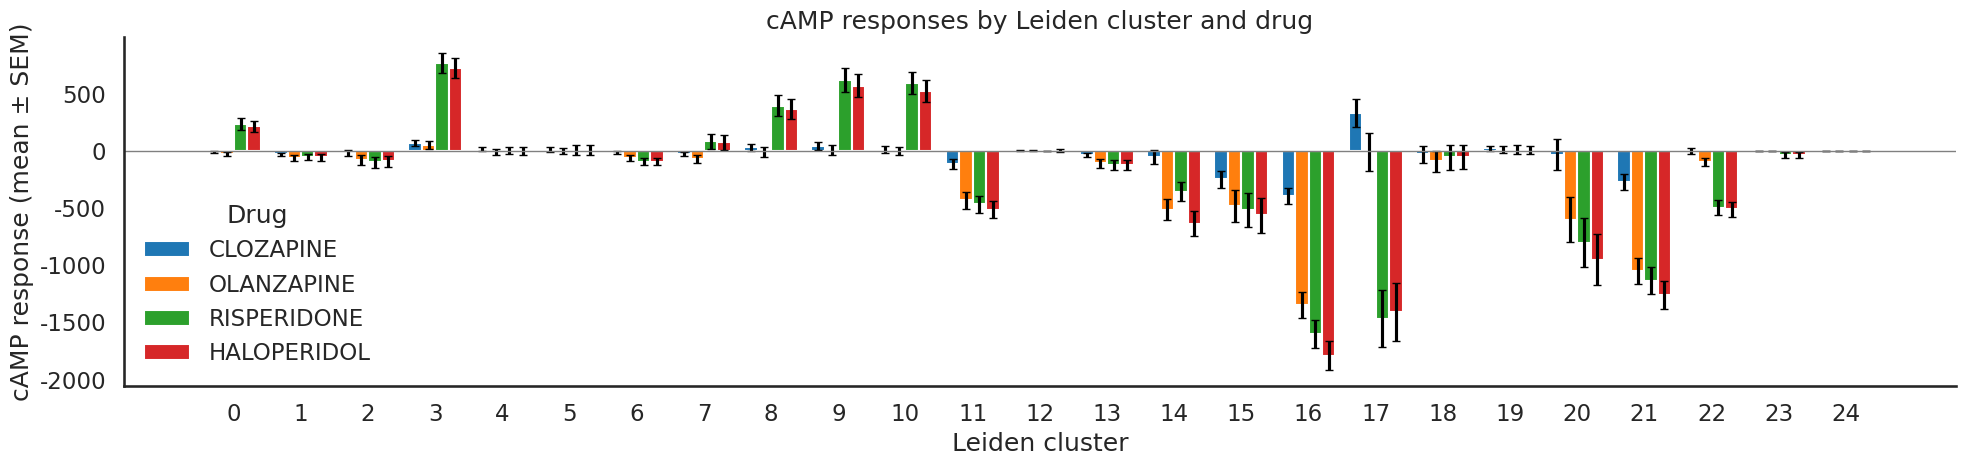

In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ============================
# フォント設定（Illustratorで編集しやすい）
# ============================
rcParams["font.family"] = "DejaVu Sans"  # Arialがない環境でも代用OK
rcParams["pdf.fonttype"] = 42            # Illustratorで文字編集可能
rcParams["ps.fonttype"] = 42
rcParams["axes.unicode_minus"] = False

sns.set_context("talk")
sns.set_style("white")  # 背景グリッドなし（whitegrid → white に変更）

# ============================
# 1. 対象の列・ラベル定義
# ============================
keys = [
    "cAMP_CLOZAPINE",
    "cAMP_OLANZAPINE",
    "cAMP_RISPERIDONE",
    "cAMP_HALOPERIDOL",
]

drug_labels = {
    "cAMP_CLOZAPINE":   "CLOZAPINE",
    "cAMP_OLANZAPINE":  "OLANZAPINE",
    "cAMP_RISPERIDONE": "RISPERIDONE",
    "cAMP_HALOPERIDOL": "HALOPERIDOL",
}

# ============================
# 2. データ準備（long形式）
# ============================
if not pd.api.types.is_categorical_dtype(adata.obs["leiden"]):
    adata.obs["leiden"] = adata.obs["leiden"].astype("category")

df = adata.obs[["leiden"] + keys].copy()
df_long = df.melt(id_vars="leiden", value_vars=keys, var_name="drug", value_name="response").dropna()

# ============================
# 3. クラスタ × 薬剤ごとの mean, SEM
# ============================
def sem(x):
    return x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan

summary = (
    df_long.groupby(["leiden", "drug"])["response"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)

clusters = adata.obs["leiden"].cat.categories.tolist()
mean_pivot = summary.pivot(index="leiden", columns="drug", values="mean").loc[clusters]
sem_pivot  = summary.pivot(index="leiden", columns="drug", values="sem").loc[clusters]

# ============================
# 4. プロット
# ============================
n_clusters = len(clusters)
n_drugs = len(keys)
x = np.arange(n_clusters)
width = 0.2

fig, ax = plt.subplots(figsize=(20, 5))

for i, key in enumerate(keys):
    offset = (i - (n_drugs - 1) / 2) * width
    y = mean_pivot[key].values
    yerr = sem_pivot[key].values
    ax.bar(
        x + offset,
        y,
        width,
        label=drug_labels[key],
        yerr=yerr,
        capsize=3,
    )

# ===== 背景グリッド削除 & y=0 ラインを残す =====
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(True)
ax.spines["bottom"].set_visible(True)
ax.yaxis.grid(False)         # グリッド線をすべてOFF
ax.axhline(0, color="gray", lw=1, linestyle="-")  # y=0線だけ明示的に描く

# ===== 軸とラベル =====
ax.set_xticks(x)
ax.set_xticklabels(clusters)
ax.set_xlabel("Leiden cluster")
ax.set_ylabel("cAMP response (mean ± SEM)")
ax.set_title("cAMP responses by Leiden cluster and drug")
ax.legend(title="Drug", frameon=False)

plt.tight_layout()


# ============================
# 5. Illustratorで編集可能なPDFとして保存
# ============================
out_pdf = "/data/mouse_PFC/WT_only/figures/bar_cAMP_by_cluster_4drugs.pdf"
plt.savefig(out_pdf)   # ベクターPDF

print(f"Saved grouped bar plot to: {out_pdf}")


Saved summary to: /data/mouse_PFC/WT_only/figures/summary_Ca_by_cluster_4drugs.csv


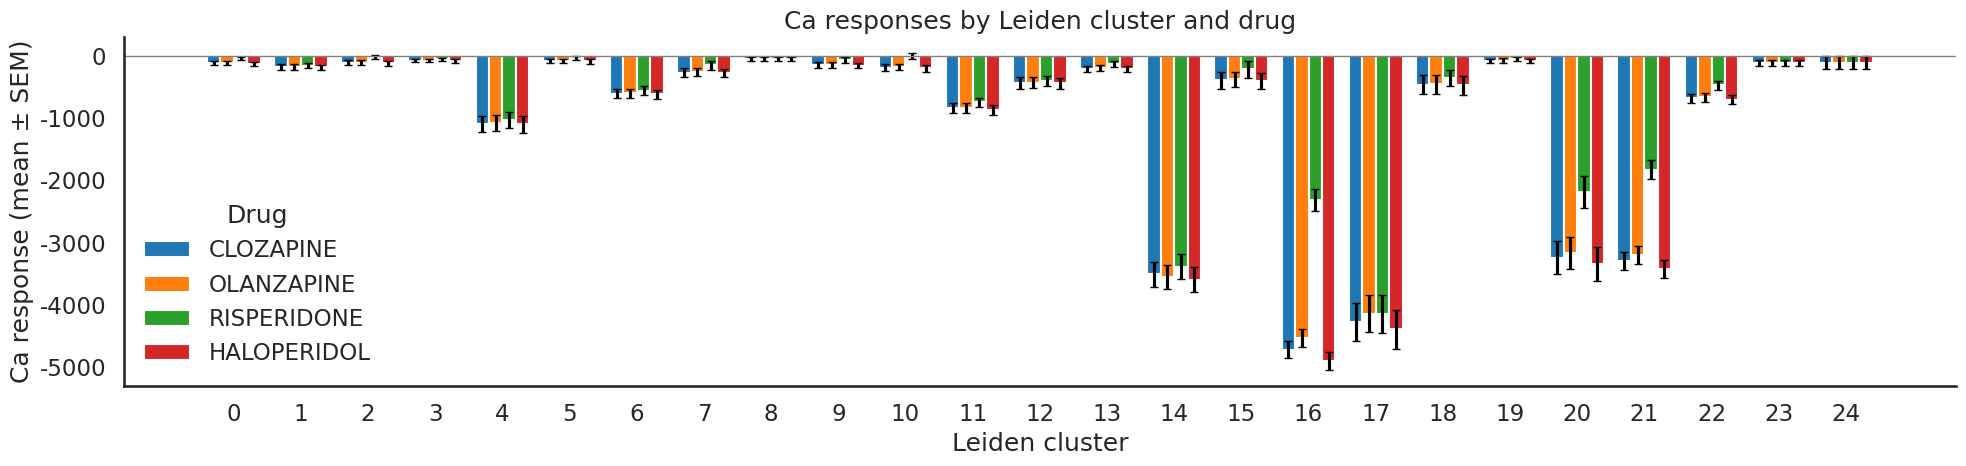

Saved grouped bar plot to: /data/mouse_PFC/WT_only/figures/bar_Ca_by_cluster_4drugs.pdf


In [35]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ============================
# フォント設定（Illustratorで編集しやすい）
# ============================
rcParams["font.family"] = "DejaVu Sans"
rcParams["pdf.fonttype"] = 42
rcParams["ps.fonttype"] = 42
rcParams["axes.unicode_minus"] = False

sns.set_context("talk")
sns.set_style("white")

# ============================
# 1. 対象の列・ラベル定義
# ============================
keys = [
    "Ca_CLOZAPINE",
    "Ca_OLANZAPINE",
    "Ca_RISPERIDONE",
    "Ca_HALOPERIDOL",
]

drug_labels = {
    "Ca_CLOZAPINE":   "CLOZAPINE",
    "Ca_OLANZAPINE":  "OLANZAPINE",
    "Ca_RISPERIDONE": "RISPERIDONE",
    "Ca_HALOPERIDOL": "HALOPERIDOL",
}

# 存在チェック
missing_keys = [k for k in keys if k not in adata.obs.columns]
if len(missing_keys) > 0:
    raise ValueError(f"These columns are missing in adata.obs: {missing_keys}")

# ============================
# 2. データ準備（long形式）
# ============================
if not pd.api.types.is_categorical_dtype(adata.obs["leiden"]):
    adata.obs["leiden"] = adata.obs["leiden"].astype("category")

df = adata.obs[["leiden"] + keys].copy()

df_long = (
    df.melt(
        id_vars="leiden",
        value_vars=keys,
        var_name="drug",
        value_name="response",
    )
    .dropna()
)

# ============================
# 3. クラスタ × 薬剤ごとの mean, SEM
# ============================
def sem(x):
    return x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan

summary = (
    df_long.groupby(["leiden", "drug"], observed=False)["response"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)

clusters = adata.obs["leiden"].cat.categories.tolist()

mean_pivot = (
    summary.pivot(index="leiden", columns="drug", values="mean")
    .loc[clusters, keys]
)

sem_pivot = (
    summary.pivot(index="leiden", columns="drug", values="sem")
    .loc[clusters, keys]
)

# summaryも保存しておくと便利
out_dir = "/data/mouse_PFC/WT_only/figures"
os.makedirs(out_dir, exist_ok=True)

summary_csv = os.path.join(out_dir, "summary_Ca_by_cluster_4drugs.csv")
summary.to_csv(summary_csv, index=False)
print(f"Saved summary to: {summary_csv}")

# ============================
# 4. プロット
# ============================
n_clusters = len(clusters)
n_drugs = len(keys)

x = np.arange(n_clusters)
width = 0.2

fig, ax = plt.subplots(figsize=(20, 5))

for i, key in enumerate(keys):
    offset = (i - (n_drugs - 1) / 2) * width

    y = mean_pivot[key].values
    yerr = sem_pivot[key].values

    ax.bar(
        x + offset,
        y,
        width,
        label=drug_labels[key],
        yerr=yerr,
        capsize=3,
    )

# ===== 背景グリッド削除 & y=0 ラインを残す =====
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(True)
ax.spines["bottom"].set_visible(True)

ax.yaxis.grid(False)
ax.axhline(0, color="gray", lw=1, linestyle="-")

# ===== 軸とラベル =====
ax.set_xticks(x)
ax.set_xticklabels(clusters)
ax.set_xlabel("Leiden cluster")
ax.set_ylabel("Ca response (mean ± SEM)")
ax.set_title("Ca responses by Leiden cluster and drug")
ax.legend(title="Drug", frameon=False)

plt.tight_layout()

# ============================
# 5. Illustratorで編集可能なPDFとして保存
# ============================
out_pdf = os.path.join(out_dir, "bar_Ca_by_cluster_4drugs.pdf")
plt.savefig(out_pdf)
plt.show()

print(f"Saved grouped bar plot to: {out_pdf}")

In [43]:
#statics for cAMP and Ca response between leiden clusters
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests


# ============================================================
# 0. long format 作成
# ============================================================

def make_response_long_df(
    adata,
    drugs,
    response_prefix="cAMP",
    cluster_col="leiden",
    ca_offset_correction=False,
    ca_offset=1e-4,
):
    """
    adata.obs から long format dataframe を作る。

    output columns:
        cluster_col, drug, response, model
    """

    keys = [f"{response_prefix}_{drug}" for drug in drugs]

    missing = [k for k in keys if k not in adata.obs.columns]
    if len(missing) > 0:
        raise ValueError(f"Missing columns in adata.obs: {missing}")

    if cluster_col not in adata.obs.columns:
        raise ValueError(f"{cluster_col} is not found in adata.obs")

    df = adata.obs[[cluster_col] + keys].copy()

    # Caの +1e-4 補正を除く
    if response_prefix == "Ca" and ca_offset_correction:
        for key in keys:
            df[key] = df[key].astype(float) - ca_offset

    if not pd.api.types.is_categorical_dtype(df[cluster_col]):
        df[cluster_col] = df[cluster_col].astype("category")

    df_long = (
        df.melt(
            id_vars=cluster_col,
            value_vars=keys,
            var_name="drug",
            value_name="response",
        )
        .dropna()
        .copy()
    )

    # cAMP_CLOZAPINE -> CLOZAPINE
    df_long["drug"] = df_long["drug"].str.replace(
        f"{response_prefix}_",
        "",
        regex=False,
    )

    df_long["drug"] = pd.Categorical(df_long["drug"], categories=list(drugs), ordered=True)
    df_long[cluster_col] = df_long[cluster_col].astype("category")
    df_long["model"] = response_prefix

    return df_long


# ============================================================
# 1. ANOVA tableに効果量を追加
# ============================================================

def add_anova_effect_sizes(anova_table):
    """
    eta_sq と partial_eta_sq を追加。
    """
    out = anova_table.copy()

    if "sum_sq" not in out.columns:
        return out

    total_ss = out["sum_sq"].sum()
    resid_ss = out.loc["Residual", "sum_sq"] if "Residual" in out.index else np.nan

    out["eta_sq"] = out["sum_sq"] / total_ss

    if np.isfinite(resid_ss):
        out["partial_eta_sq"] = out["sum_sq"] / (out["sum_sq"] + resid_ss)
    else:
        out["partial_eta_sq"] = np.nan

    return out


# ============================================================
# 2. 1モデル分のANOVA
# ============================================================

def run_cluster_drug_anova_single_model(
    df_long,
    output_dir,
    response_prefix="cAMP",
    cluster_col="leiden",
):
    """
    1つのresponse model、つまり cAMP または Ca について、
    1. two-way ANOVA: response ~ cluster * drug
    2. per-cluster one-way ANOVA: response ~ drug
    を実行してCSV保存。
    """

    os.makedirs(output_dir, exist_ok=True)

    df = df_long.dropna().copy()
    df[cluster_col] = df[cluster_col].astype("category")
    df["drug"] = df["drug"].astype("category")

    # statsmodels formula用に cluster_col を leiden に揃える
    # cluster_colがleiden以外でも動くようにする
    if cluster_col != "leiden":
        df = df.rename(columns={cluster_col: "leiden"})
        formula_cluster_col = "leiden"
    else:
        formula_cluster_col = cluster_col

    # ===============================
    # 1. 全体の2要因ANOVA
    # ===============================
    model = ols(
        f"response ~ C({formula_cluster_col}) * C(drug)",
        data=df,
    ).fit()

    anova_table = sm.stats.anova_lm(model, typ=2)
    anova_table = add_anova_effect_sizes(anova_table)

    anova_csv = os.path.join(
        output_dir,
        f"{response_prefix}_two_way_ANOVA_drug_x_cluster.csv",
    )
    anova_table.to_csv(anova_csv)

    print(f"\n=== {response_prefix}: Two-way ANOVA drug × cluster ===")
    print(anova_table)
    print("saved:", anova_csv)

    interaction_term = f"C({formula_cluster_col}):C(drug)"
    interaction_p = anova_table.loc[interaction_term, "PR(>F)"]

    if interaction_p < 0.05:
        print(f"\n✅ {response_prefix}: Significant interaction detected (p = {interaction_p:.3e})")
    else:
        print(f"\n❌ {response_prefix}: No significant interaction (p = {interaction_p:.3e})")

    # ===============================
    # 2. 各クラスタごとの薬剤効果
    # ===============================
    results = []

    for cluster in df[formula_cluster_col].cat.categories:
        sub = df[df[formula_cluster_col] == cluster].copy()

        if sub["drug"].nunique() < 2:
            continue

        try:
            model_sub = ols("response ~ C(drug)", data=sub).fit()
            anova_sub = sm.stats.anova_lm(model_sub, typ=2)
            anova_sub = add_anova_effect_sizes(anova_sub)

            pval = anova_sub.loc["C(drug)", "PR(>F)"]
            fval = anova_sub.loc["C(drug)", "F"]
            eta_sq = anova_sub.loc["C(drug)", "eta_sq"]
            partial_eta_sq = anova_sub.loc["C(drug)", "partial_eta_sq"]

            results.append({
                "cluster": cluster,
                "model": response_prefix,
                "n_cells": sub[formula_cluster_col].shape[0] // sub["drug"].nunique(),
                "n_observations": len(sub),
                "n_drugs": sub["drug"].nunique(),
                "F": fval,
                "pval": pval,
                "eta_sq": eta_sq,
                "partial_eta_sq": partial_eta_sq,
            })

        except Exception as e:
            print(f"[WARN] {response_prefix}, cluster {cluster}: {type(e).__name__}: {e}")

    cluster_anova_df = pd.DataFrame(results)

    if len(cluster_anova_df) > 0:
        cluster_anova_df["pval_adj_FDR"] = multipletests(
            cluster_anova_df["pval"],
            method="fdr_bh",
        )[1]

        cluster_anova_df = cluster_anova_df.sort_values("pval_adj_FDR")

    cluster_csv = os.path.join(
        output_dir,
        f"{response_prefix}_per_cluster_drug_ANOVA_FDR.csv",
    )
    cluster_anova_df.to_csv(cluster_csv, index=False)

    print(f"\n=== {response_prefix}: Per-cluster drug effect ===")
    print(cluster_anova_df.round(4))
    print("saved:", cluster_csv)

    sig_clusters = cluster_anova_df[
        cluster_anova_df["pval_adj_FDR"] < 0.05
    ].copy()

    if len(sig_clusters) > 0:
        print(f"\n✅ {response_prefix}: Significant clusters after FDR correction:")
        print(sig_clusters[["cluster", "pval", "pval_adj_FDR", "eta_sq", "partial_eta_sq"]].round(4))
    else:
        print(f"\n❌ {response_prefix}: No clusters show significant drug effects after FDR correction.")

    return {
        "df_long": df_long,
        "two_way_anova": anova_table,
        "per_cluster_anova": cluster_anova_df,
    }


# ============================================================
# 3. cAMP と Ca をまとめて実行
# ============================================================

def run_cluster_drug_anova_camp_and_ca(
    adata,
    drugs,
    output_dir="/data/mouse_PFC/WT_only/figures/anova_cAMP_vs_Ca",
    cluster_col="leiden",
    ca_offset_correction=True,
    ca_offset=1e-4,
):
    """
    cAMP と Ca の両方で同じANOVA解析を実行。
    """

    os.makedirs(output_dir, exist_ok=True)

    all_results = {}
    summary_rows = []
    per_cluster_all = []

    for response_prefix in ["cAMP", "Ca"]:
        print("\n" + "=" * 80)
        print(f"Running ANOVA for {response_prefix}")
        print("=" * 80)

        df_long = make_response_long_df(
            adata,
            drugs=drugs,
            response_prefix=response_prefix,
            cluster_col=cluster_col,
            ca_offset_correction=ca_offset_correction,
            ca_offset=ca_offset,
        )

        long_csv = os.path.join(output_dir, f"{response_prefix}_df_long.csv")
        df_long.to_csv(long_csv, index=False)
        print("saved:", long_csv)

        res = run_cluster_drug_anova_single_model(
            df_long=df_long,
            output_dir=output_dir,
            response_prefix=response_prefix,
            cluster_col=cluster_col,
        )

        all_results[response_prefix] = res

        anova = res["two_way_anova"]

        cluster_term = f"C({cluster_col})"
        drug_term = "C(drug)"
        interaction_term = f"C({cluster_col}):C(drug)"

        # cluster_colがleiden以外だった場合、内部でleidenにrenameしているので補正
        if cluster_col != "leiden":
            cluster_term = "C(leiden)"
            interaction_term = "C(leiden):C(drug)"

        for term in [cluster_term, drug_term, interaction_term]:
            if term in anova.index:
                summary_rows.append({
                    "model": response_prefix,
                    "term": term,
                    "F": anova.loc[term, "F"],
                    "pval": anova.loc[term, "PR(>F)"],
                    "eta_sq": anova.loc[term, "eta_sq"],
                    "partial_eta_sq": anova.loc[term, "partial_eta_sq"],
                })

        per_cluster_all.append(res["per_cluster_anova"])

    # ===============================
    # summary保存
    # ===============================
    summary_df = pd.DataFrame(summary_rows)

    summary_csv = os.path.join(output_dir, "summary_two_way_ANOVA_cAMP_vs_Ca.csv")
    summary_df.to_csv(summary_csv, index=False)
    print("\nSaved summary:", summary_csv)

    per_cluster_all_df = pd.concat(per_cluster_all, axis=0, ignore_index=True)

    per_cluster_all_csv = os.path.join(output_dir, "summary_per_cluster_ANOVA_cAMP_vs_Ca.csv")
    per_cluster_all_df.to_csv(per_cluster_all_csv, index=False)
    print("Saved per-cluster summary:", per_cluster_all_csv)

    all_results["summary_two_way"] = summary_df
    all_results["summary_per_cluster"] = per_cluster_all_df

    return all_results

In [45]:
drug_list_selected = [
    "HALOPERIDOL",
    "RISPERIDONE",
    "OLANZAPINE",
    "CLOZAPINE",
]

anova_results = run_cluster_drug_anova_camp_and_ca(
    adata,
    drugs=drug_list_selected,
    output_dir="/data/mouse_PFC/WT_only/figures/anova_cAMP_vs_Ca_4drugs",
    cluster_col="leiden",
    ca_offset_correction=False
)


Running ANOVA for cAMP
saved: /data/mouse_PFC/WT_only/figures/anova_cAMP_vs_Ca_4drugs/cAMP_df_long.csv

=== cAMP: Two-way ANOVA drug × cluster ===
                         sum_sq       df           F         PR(>F)    eta_sq  \
C(leiden)          9.691349e+09     24.0  138.899615   0.000000e+00  0.049444   
C(drug)            2.470346e+08      3.0   28.324657   2.703341e-18  0.001260   
C(leiden):C(drug)  3.103025e+09     72.0   14.824526  2.460674e-175  0.015831   
Residual           1.829663e+11  62936.0         NaN            NaN  0.933465   

                   partial_eta_sq  
C(leiden)                0.050303  
C(drug)                  0.001348  
C(leiden):C(drug)        0.016677  
Residual                 0.500000  
saved: /data/mouse_PFC/WT_only/figures/anova_cAMP_vs_Ca_4drugs/cAMP_two_way_ANOVA_drug_x_cluster.csv

✅ cAMP: Significant interaction detected (p = 2.461e-175)


/opt/conda/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 0
  warnings.warn('covariance of constraints does not have full '



=== cAMP: Per-cluster drug effect ===
   cluster model  n_cells  n_observations  n_drugs        F    pval  eta_sq  \
0        0  cAMP     1100            4400        4  16.1089  0.0000  0.0109   
1        1  cAMP      876            3504        4   0.3516  0.7880  0.0003   
2        2  cAMP      633            2532        4   0.8458  0.4687  0.0010   
3        3  cAMP      911            3644        4  37.5995  0.0000  0.0301   
4        4  cAMP      542            2168        4   0.1703  0.9165  0.0002   
5        5  cAMP      683            2732        4   0.0358  0.9909  0.0000   
6        6  cAMP     1038            4152        4   1.6784  0.1694  0.0012   
7        7  cAMP      513            2052        4   2.3810  0.0678  0.0035   
8        8  cAMP      607            2428        4   9.9349  0.0000  0.0121   
9        9  cAMP      649            2596        4  18.4984  0.0000  0.0210   
10      10  cAMP      629            2516        4  19.8275  0.0000  0.0231   
11      11  c

In [47]:
#posthoc analysis for leiden based cAMP and Ca response
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.multicomp import pairwise_tukeyhsd

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
from matplotlib.backends.backend_pdf import PdfPages

# ====================================
# フォント設定
# ====================================
rcParams["font.family"] = "DejaVu Sans"
rcParams["pdf.fonttype"] = 42
rcParams["ps.fonttype"] = 42
rcParams["axes.unicode_minus"] = False

sns.set_context("talk")
sns.set_style("white")


# ============================================================
# 0. Utility
# ============================================================

def p_to_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"


def make_response_long_df(
    adata,
    drugs,
    response_prefix="cAMP",
    cluster_col="leiden",
    ca_offset_correction=True,
    ca_offset=1e-4,
):
    """
    adata.obs から long形式 dataframe を作成。
    output columns:
        leiden, drug, response, model
    """

    keys = [f"{response_prefix}_{drug}" for drug in drugs]

    missing = [k for k in keys if k not in adata.obs.columns]
    if len(missing) > 0:
        raise ValueError(f"Missing columns in adata.obs: {missing}")

    if cluster_col not in adata.obs.columns:
        raise ValueError(f"{cluster_col} is not found in adata.obs")

    df = adata.obs[[cluster_col] + keys].copy()

    # Ca に足していた 1e-4 を補正
    if response_prefix == "Ca" and ca_offset_correction:
        for key in keys:
            df[key] = df[key].astype(float) - ca_offset

    if not pd.api.types.is_categorical_dtype(df[cluster_col]):
        df[cluster_col] = df[cluster_col].astype("category")

    df_long = (
        df.melt(
            id_vars=cluster_col,
            value_vars=keys,
            var_name="drug",
            value_name="response",
        )
        .dropna()
        .copy()
    )

    df_long["drug"] = df_long["drug"].str.replace(
        f"{response_prefix}_",
        "",
        regex=False,
    )

    df_long["drug"] = pd.Categorical(
        df_long["drug"],
        categories=list(drugs),
        ordered=True,
    )

    # formulaで扱いやすいようにleiden列へ統一
    if cluster_col != "leiden":
        df_long = df_long.rename(columns={cluster_col: "leiden"})

    df_long["leiden"] = df_long["leiden"].astype("category")
    df_long["model"] = response_prefix

    return df_long


def add_anova_effect_sizes(anova_table):
    """
    eta_sq, partial_eta_sq を追加。
    """
    out = anova_table.copy()

    if "sum_sq" not in out.columns:
        return out

    total_ss = out["sum_sq"].sum()
    resid_ss = out.loc["Residual", "sum_sq"] if "Residual" in out.index else np.nan

    out["eta_sq"] = out["sum_sq"] / total_ss

    if np.isfinite(resid_ss):
        out["partial_eta_sq"] = out["sum_sq"] / (out["sum_sq"] + resid_ss)
    else:
        out["partial_eta_sq"] = np.nan

    return out


def tukey_to_dataframe(tukey_result):
    """
    pairwise_tukeyhsd の結果をDataFrame化。
    """
    tbl = tukey_result.summary()
    data = tbl.data[1:]
    cols = tbl.data[0]

    res = pd.DataFrame(data, columns=cols)

    for c in ["meandiff", "p-adj", "lower", "upper"]:
        res[c] = pd.to_numeric(res[c], errors="coerce")

    # "True"/"False" 文字列対策
    res["reject"] = res["reject"].astype(str).str.lower().map(
        {"true": True, "false": False}
    )

    res["stars"] = res["p-adj"].apply(p_to_stars)

    return res


# ============================================================
# 1. One model: ANOVA + Tukey posthoc
# ============================================================

def run_anova_posthoc_single_model(
    df_long,
    response_prefix,
    output_dir,
    fdr_alpha=0.05,
    tukey_alpha=0.05,
):
    """
    cAMP または Ca の1モデルについて、
    2-way ANOVA、clusterごとの1-way ANOVA、Tukey posthocを実行。
    """

    os.makedirs(output_dir, exist_ok=True)

    df_long = df_long.dropna().copy()
    df_long["leiden"] = df_long["leiden"].astype("category")
    df_long["drug"] = df_long["drug"].astype("category")

    # ====================================
    # 1. 全体 2-way ANOVA
    # ====================================
    model = ols("response ~ C(leiden) * C(drug)", data=df_long).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    anova_table = add_anova_effect_sizes(anova_table)

    anova_csv = os.path.join(
        output_dir,
        f"{response_prefix}_two_way_ANOVA_drug_x_cluster.csv",
    )
    anova_table.to_csv(anova_csv)

    print(f"\n=== {response_prefix}: Two-way ANOVA drug × cluster ===")
    print(anova_table)
    print("saved:", anova_csv)

    interaction_p = anova_table.loc["C(leiden):C(drug)", "PR(>F)"]

    if interaction_p < 0.05:
        print(f"\n✅ {response_prefix}: Significant interaction detected (p = {interaction_p:.3e})")
    else:
        print(f"\n❌ {response_prefix}: No significant interaction (p = {interaction_p:.3e})")

    # ====================================
    # 2. 各clusterごとの1-way ANOVA
    # ====================================
    cluster_results = []

    for cluster in df_long["leiden"].cat.categories:
        sub = df_long[df_long["leiden"] == cluster].copy()

        if sub["drug"].nunique() < 2:
            continue

        try:
            model_sub = ols("response ~ C(drug)", data=sub).fit()
            anova_sub = sm.stats.anova_lm(model_sub, typ=2)
            anova_sub = add_anova_effect_sizes(anova_sub)

            cluster_results.append({
                "model": response_prefix,
                "cluster": cluster,
                "n_observations": len(sub),
                "n_drugs": sub["drug"].nunique(),
                "F": anova_sub.loc["C(drug)", "F"],
                "pval": anova_sub.loc["C(drug)", "PR(>F)"],
                "eta_sq": anova_sub.loc["C(drug)", "eta_sq"],
                "partial_eta_sq": anova_sub.loc["C(drug)", "partial_eta_sq"],
            })

        except Exception as e:
            print(f"[WARN] {response_prefix}, cluster {cluster}: {type(e).__name__}: {e}")

    cluster_anova_df = pd.DataFrame(cluster_results)

    if len(cluster_anova_df) > 0:
        cluster_anova_df["pval_adj_FDR"] = multipletests(
            cluster_anova_df["pval"],
            method="fdr_bh",
        )[1]

        cluster_anova_df = cluster_anova_df.sort_values("pval_adj_FDR")

    cluster_csv = os.path.join(
        output_dir,
        f"{response_prefix}_per_cluster_drug_ANOVA_FDR.csv",
    )
    cluster_anova_df.to_csv(cluster_csv, index=False)

    print(f"\n=== {response_prefix}: Per-cluster drug effect ANOVA + FDR ===")
    print(cluster_anova_df.round(4))
    print("saved:", cluster_csv)

    sig_clusters = cluster_anova_df[
        cluster_anova_df["pval_adj_FDR"] < fdr_alpha
    ].copy()

    if len(sig_clusters) > 0:
        print(f"\n✅ {response_prefix}: Significant clusters after FDR correction:")
        print(sig_clusters[["cluster", "pval", "pval_adj_FDR", "eta_sq", "partial_eta_sq"]].round(4))
    else:
        print(f"\n❌ {response_prefix}: No significant clusters after FDR correction.")

    # ====================================
    # 3. Tukey HSD posthoc
    # ====================================
    posthoc_results = []

    for cluster in sig_clusters["cluster"]:
        sub = df_long[df_long["leiden"] == cluster].copy()

        if sub["drug"].nunique() < 2:
            continue

        try:
            tukey = pairwise_tukeyhsd(
                endog=sub["response"],
                groups=sub["drug"],
                alpha=tukey_alpha,
            )

            res = tukey_to_dataframe(tukey)
            res["model"] = response_prefix
            res["cluster"] = cluster
            posthoc_results.append(res)

        except Exception as e:
            print(f"[WARN] Tukey failed: {response_prefix}, cluster {cluster}: {type(e).__name__}: {e}")

    if len(posthoc_results) > 0:
        posthoc_df = pd.concat(posthoc_results, ignore_index=True)

        # 全posthoc比較をまたいだFDRも追加
        posthoc_df["p_adj_global_FDR"] = multipletests(
            posthoc_df["p-adj"],
            method="fdr_bh",
        )[1]
        posthoc_df["stars_global_FDR"] = posthoc_df["p_adj_global_FDR"].apply(p_to_stars)

        posthoc_csv = os.path.join(
            output_dir,
            f"{response_prefix}_posthoc_TukeyHSD_by_cluster.csv",
        )
        posthoc_df.to_csv(posthoc_csv, index=False)

        print(f"\n=== {response_prefix}: Tukey HSD posthoc ===")
        print("saved:", posthoc_csv)

        for cluster in sig_clusters["cluster"]:
            sub_ph = posthoc_df[posthoc_df["cluster"] == cluster]
            if sub_ph.empty:
                continue

            print(f"\n--- {response_prefix}: Cluster {cluster} ---")
            print(
                sub_ph[["group1", "group2", "meandiff", "p-adj", "stars", "p_adj_global_FDR", "stars_global_FDR"]]
                .to_string(index=False, float_format=lambda x: f"{x:.3e}")
            )

    else:
        posthoc_df = pd.DataFrame()
        print(f"\n❌ {response_prefix}: No significant clusters for Tukey posthoc.")

    return {
        "df_long": df_long,
        "two_way_anova": anova_table,
        "cluster_anova": cluster_anova_df,
        "sig_clusters": sig_clusters,
        "posthoc": posthoc_df,
    }


# ============================================================
# 2. Plot posthoc bars
# ============================================================

def plot_posthoc_bars_by_cluster(
    df_long,
    sig_clusters,
    posthoc_df,
    response_prefix,
    output_pdf,
    drugs=None,
    annotate_reference_drug=None,
    max_pairs_per_cluster=8,
    max_clusters_per_page=6,
    use_global_fdr_for_stars=False,
):
    """
    有意clusterについて、薬剤bar plot + Tukey有意ペアの星をPDF保存。

    annotate_reference_drug:
        Noneなら全有意ペアを表示。
        "CLOZAPINE" などを指定すると、その薬剤との比較だけ表示。
    """

    if sig_clusters is None or len(sig_clusters) == 0:
        print(f"No significant clusters to plot for {response_prefix}.")
        return None

    if posthoc_df is None or len(posthoc_df) == 0:
        print(f"No posthoc results to plot for {response_prefix}.")
        return None

    sig_cluster_list = sig_clusters["cluster"].astype(str).tolist()

    if drugs is None:
        drugs = list(df_long["drug"].cat.categories)
    else:
        drugs = list(drugs)

    with PdfPages(output_pdf) as pdf:
        for start in range(0, len(sig_cluster_list), max_clusters_per_page):
            clusters_page = sig_cluster_list[start:start + max_clusters_per_page]

            n = len(clusters_page)
            ncols = min(3, n)
            nrows = int(np.ceil(n / ncols))

            fig, axes = plt.subplots(
                nrows,
                ncols,
                figsize=(5.5 * ncols, 5.2 * nrows),
                squeeze=False,
                sharey=False,
            )

            axes = axes.ravel()

            for ax_i, cluster in enumerate(clusters_page):
                ax = axes[ax_i]

                sub = df_long[df_long["leiden"].astype(str) == str(cluster)].copy()
                sub["drug"] = pd.Categorical(sub["drug"], categories=drugs, ordered=True)

                summary = (
                    sub.groupby("drug", observed=False)["response"]
                    .agg(["mean", "std", "count"])
                    .assign(sem=lambda d: d["std"] / np.sqrt(d["count"]))
                    .reindex(drugs)
                )

                x_pos = np.arange(len(summary))

                ax.bar(
                    x_pos,
                    summary["mean"].values,
                    yerr=summary["sem"].values,
                    capsize=3,
                    edgecolor="black",
                    linewidth=0.8,
                )

                ax.axhline(0, color="gray", lw=1)

                ax.set_title(f"{response_prefix} cluster {cluster}")
                ax.set_ylabel(f"{response_prefix} response")
                ax.set_xlabel("Drug")
                ax.set_xticks(x_pos)
                ax.set_xticklabels(summary.index, rotation=45, ha="right")

                ax.spines["top"].set_visible(False)
                ax.spines["right"].set_visible(False)
                ax.yaxis.grid(False)

                # ----------------------------
                # significance annotation
                # ----------------------------
                sig_pairs = posthoc_df[
                    (posthoc_df["cluster"].astype(str) == str(cluster))
                    & (posthoc_df["p-adj"] < 0.05)
                ].copy()

                if annotate_reference_drug is not None:
                    ref = str(annotate_reference_drug)
                    sig_pairs = sig_pairs[
                        (sig_pairs["group1"].astype(str) == ref)
                        | (sig_pairs["group2"].astype(str) == ref)
                    ].copy()

                if len(sig_pairs) > 0:
                    sig_pairs = sig_pairs.sort_values("p-adj").head(max_pairs_per_cluster)

                    y_top = np.nanmax(summary["mean"].values + summary["sem"].values)
                    y_bottom = np.nanmin(summary["mean"].values - summary["sem"].values)
                    y_range = y_top - y_bottom

                    if not np.isfinite(y_range) or y_range == 0:
                        y_range = 1.0

                    y = y_top + 0.08 * y_range
                    step = 0.12 * y_range

                    for _, row in sig_pairs.iterrows():
                        drug1 = str(row["group1"])
                        drug2 = str(row["group2"])

                        if drug1 not in summary.index or drug2 not in summary.index:
                            continue

                        idx1 = list(summary.index).index(drug1)
                        idx2 = list(summary.index).index(drug2)

                        if idx1 > idx2:
                            idx1, idx2 = idx2, idx1

                        ax.plot(
                            [idx1, idx1, idx2, idx2],
                            [y, y + 0.02 * y_range, y + 0.02 * y_range, y],
                            color="black",
                            lw=1,
                        )

                        if use_global_fdr_for_stars:
                            star_text = row.get("stars_global_FDR", p_to_stars(row["p_adj_global_FDR"]))
                        else:
                            star_text = row.get("stars", p_to_stars(row["p-adj"]))

                        ax.text(
                            (idx1 + idx2) / 2,
                            y + 0.025 * y_range,
                            star_text,
                            ha="center",
                            va="bottom",
                            fontsize=13,
                        )

                        y += step

                    ax.set_ylim(
                        y_bottom - 0.08 * y_range,
                        y + 0.10 * y_range,
                    )

            # 余ったsubplotを消す
            for j in range(len(clusters_page), len(axes)):
                axes[j].axis("off")

            plt.tight_layout()
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)

    print("saved:", output_pdf)
    return output_pdf


# ============================================================
# 3. cAMP and Ca wrapper
# ============================================================

def run_anova_posthoc_camp_and_ca(
    adata,
    drugs,
    output_dir="/data/mouse_PFC/WT_only/figures/anova_posthoc_cAMP_vs_Ca",
    cluster_col="leiden",
    ca_offset_correction=True,
    ca_offset=1e-4,
    fdr_alpha=0.05,
    tukey_alpha=0.05,
    annotate_reference_drug=None,
    max_pairs_per_cluster=8,
    max_clusters_per_page=6,
    use_global_fdr_for_stars=False,
):
    """
    cAMP と Ca の両方について、
    ANOVA + Tukey posthoc + barplot PDFを一括実行。
    """

    os.makedirs(output_dir, exist_ok=True)

    all_results = {}
    all_cluster_anova = []
    all_posthoc = []
    all_two_way_summary = []

    for response_prefix in ["cAMP", "Ca"]:
        print("\n" + "=" * 90)
        print(f"Running ANOVA + posthoc for {response_prefix}")
        print("=" * 90)

        model_dir = os.path.join(output_dir, response_prefix)
        os.makedirs(model_dir, exist_ok=True)

        df_long = make_response_long_df(
            adata,
            drugs=drugs,
            response_prefix=response_prefix,
            cluster_col=cluster_col,
            ca_offset_correction=ca_offset_correction,
            ca_offset=ca_offset,
        )

        df_long_csv = os.path.join(model_dir, f"{response_prefix}_df_long.csv")
        df_long.to_csv(df_long_csv, index=False)
        print("saved:", df_long_csv)

        res = run_anova_posthoc_single_model(
            df_long=df_long,
            response_prefix=response_prefix,
            output_dir=model_dir,
            fdr_alpha=fdr_alpha,
            tukey_alpha=tukey_alpha,
        )

        # bar plot
        out_pdf = os.path.join(
            model_dir,
            f"{response_prefix}_bar_by_cluster_TukeyHSD_posthoc.pdf",
        )

        plot_posthoc_bars_by_cluster(
            df_long=res["df_long"],
            sig_clusters=res["sig_clusters"],
            posthoc_df=res["posthoc"],
            response_prefix=response_prefix,
            output_pdf=out_pdf,
            drugs=drugs,
            annotate_reference_drug=annotate_reference_drug,
            max_pairs_per_cluster=max_pairs_per_cluster,
            max_clusters_per_page=max_clusters_per_page,
            use_global_fdr_for_stars=use_global_fdr_for_stars,
        )

        all_results[response_prefix] = res

        # summary tables
        anova = res["two_way_anova"]
        for term in ["C(leiden)", "C(drug)", "C(leiden):C(drug)"]:
            if term in anova.index:
                all_two_way_summary.append({
                    "model": response_prefix,
                    "term": term,
                    "F": anova.loc[term, "F"],
                    "pval": anova.loc[term, "PR(>F)"],
                    "eta_sq": anova.loc[term, "eta_sq"],
                    "partial_eta_sq": anova.loc[term, "partial_eta_sq"],
                })

        if len(res["cluster_anova"]) > 0:
            all_cluster_anova.append(res["cluster_anova"])

        if len(res["posthoc"]) > 0:
            all_posthoc.append(res["posthoc"])

    # ========================================================
    # Combined summary
    # ========================================================

    two_way_summary_df = pd.DataFrame(all_two_way_summary)
    two_way_summary_csv = os.path.join(output_dir, "summary_two_way_ANOVA_cAMP_vs_Ca.csv")
    two_way_summary_df.to_csv(two_way_summary_csv, index=False)
    print("saved:", two_way_summary_csv)

    if len(all_cluster_anova) > 0:
        cluster_all_df = pd.concat(all_cluster_anova, ignore_index=True)
    else:
        cluster_all_df = pd.DataFrame()

    cluster_all_csv = os.path.join(output_dir, "summary_per_cluster_ANOVA_cAMP_vs_Ca.csv")
    cluster_all_df.to_csv(cluster_all_csv, index=False)
    print("saved:", cluster_all_csv)

    if len(all_posthoc) > 0:
        posthoc_all_df = pd.concat(all_posthoc, ignore_index=True)
    else:
        posthoc_all_df = pd.DataFrame()

    posthoc_all_csv = os.path.join(output_dir, "summary_TukeyHSD_posthoc_cAMP_vs_Ca.csv")
    posthoc_all_df.to_csv(posthoc_all_csv, index=False)
    print("saved:", posthoc_all_csv)

    all_results["summary_two_way"] = two_way_summary_df
    all_results["summary_per_cluster"] = cluster_all_df
    all_results["summary_posthoc"] = posthoc_all_df

    return all_results

In [48]:
posthoc_results = run_anova_posthoc_camp_and_ca(
    adata,
    drugs=drug_list_selected,
    output_dir="/data/mouse_PFC/WT_only/figures/anova_posthoc_cAMP_vs_Ca_8drugs",
    cluster_col="leiden",

    # Caに足していた1e-4を引く
    ca_offset_correction=True,
    ca_offset=1e-4,

    fdr_alpha=0.05,
    tukey_alpha=0.05,

    # Noneなら全有意ペアを表示
    annotate_reference_drug=None,

    # CLOZAPINEとの比較だけ星を出したい場合はこちら
    # annotate_reference_drug="CLOZAPINE",

    max_pairs_per_cluster=8,
    max_clusters_per_page=6,

    # TrueにするとTukey p-adjを全比較でさらにFDRした星を使う
    use_global_fdr_for_stars=False,
)


Running ANOVA + posthoc for cAMP
saved: /data/mouse_PFC/WT_only/figures/anova_posthoc_cAMP_vs_Ca_8drugs/cAMP/cAMP_df_long.csv

=== cAMP: Two-way ANOVA drug × cluster ===
                         sum_sq       df           F         PR(>F)    eta_sq  \
C(leiden)          9.691349e+09     24.0  138.899615   0.000000e+00  0.049444   
C(drug)            2.470346e+08      3.0   28.324657   2.703341e-18  0.001260   
C(leiden):C(drug)  3.103025e+09     72.0   14.824526  2.460674e-175  0.015831   
Residual           1.829663e+11  62936.0         NaN            NaN  0.933465   

                   partial_eta_sq  
C(leiden)                0.050303  
C(drug)                  0.001348  
C(leiden):C(drug)        0.016677  
Residual                 0.500000  
saved: /data/mouse_PFC/WT_only/figures/anova_posthoc_cAMP_vs_Ca_8drugs/cAMP/cAMP_two_way_ANOVA_drug_x_cluster.csv

✅ cAMP: Significant interaction detected (p = 2.461e-175)


/opt/conda/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 0
  warnings.warn('covariance of constraints does not have full '



=== cAMP: Per-cluster drug effect ANOVA + FDR ===
   model cluster  n_observations  n_drugs        F    pval  eta_sq  \
0   cAMP       0            4400        4  16.1089  0.0000  0.0109   
1   cAMP       1            3504        4   0.3516  0.7880  0.0003   
2   cAMP       2            2532        4   0.8458  0.4687  0.0010   
3   cAMP       3            3644        4  37.5995  0.0000  0.0301   
4   cAMP       4            2168        4   0.1703  0.9165  0.0002   
5   cAMP       5            2732        4   0.0358  0.9909  0.0000   
6   cAMP       6            4152        4   1.6784  0.1694  0.0012   
7   cAMP       7            2052        4   2.3810  0.0678  0.0035   
8   cAMP       8            2428        4   9.9349  0.0000  0.0121   
9   cAMP       9            2596        4  18.4984  0.0000  0.0210   
10  cAMP      10            2516        4  19.8275  0.0000  0.0231   
11  cAMP      11            4644        4   6.9844  0.0001  0.0045   
12  cAMP      12            2008       

In [52]:
#post hoc paired t
import os
import itertools
import numpy as np
import pandas as pd
from scipy.stats import ttest_rel, wilcoxon
from statsmodels.stats.multitest import multipletests


def p_to_stars_safe(p):
    """
    FDR補正後p値を星に変換。
    NaNの場合はNA。
    """
    if pd.isna(p):
        return "NA"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"


def add_fdr_correction_safe(
    df,
    p_col="pval",
    out_col="pval_adj_FDR",
    fdr_scope="global",
    cluster_col="cluster",
):
    """
    NaNを除外して安全にBH-FDR補正する。
    
    fdr_scope:
        "global"         : 全cluster × 全comparisonで補正
        "within_cluster" : clusterごとに補正
    """

    out = df.copy()
    out[out_col] = np.nan

    pvals = pd.to_numeric(out[p_col], errors="coerce")

    if fdr_scope == "global":
        valid = np.isfinite(pvals.values)

        if valid.sum() > 0:
            out.loc[valid, out_col] = multipletests(
                pvals.loc[valid],
                method="fdr_bh",
            )[1]

    elif fdr_scope == "within_cluster":
        for cluster in out[cluster_col].unique():
            m_cluster = out[cluster_col] == cluster
            p_cluster = pvals[m_cluster]
            valid = np.isfinite(p_cluster.values)

            if valid.sum() > 0:
                idx_valid = p_cluster.index[valid]
                out.loc[idx_valid, out_col] = multipletests(
                    p_cluster.loc[idx_valid],
                    method="fdr_bh",
                )[1]

    else:
        raise ValueError("fdr_scope must be 'global' or 'within_cluster'")

    return out


def paired_drug_posthoc_by_cluster(
    adata,
    drugs,
    response_prefix="cAMP",
    cluster_col="leiden",
    output_csv=None,
    reference_drug="CLOZAPINE",
    test="ttest",
    fdr_scope="global",
    ca_offset_correction=True,
    ca_offset=1e-4,
    min_cells=3,
):
    """
    同じ細胞に対する薬剤応答をpaired comparisonする。

    Parameters
    ----------
    adata : AnnData
        adata.obs に response_prefix_DRUG 列がある前提。
        例: cAMP_CLOZAPINE, cAMP_OLANZAPINE など。

    drugs : list
        比較する薬剤名リスト。
        例: ["CLOZAPINE", "OLANZAPINE", "RISPERIDONE", "HALOPERIDOL"]

    response_prefix : str
        "cAMP" or "Ca"

    cluster_col : str
        cluster列名。通常 "leiden"。

    output_csv : str or None
        保存先。Noneなら保存しない。

    reference_drug : str or None
        "CLOZAPINE"なら CLOZAPINE vs others のみ。
        Noneなら全薬剤ペア。

    test : str
        "ttest" or "wilcoxon"

    fdr_scope : str
        "global"         : 全cluster × 全pairでBH-FDR補正
        "within_cluster" : clusterごとにBH-FDR補正

    ca_offset_correction : bool
        response_prefix=="Ca" のとき、既存の +1e-4 offset を引くかどうか。

    ca_offset : float
        Ca offset補正値。

    min_cells : int
        paired testに必要な最小細胞数。

    Returns
    -------
    pandas.DataFrame
    """

    # ----------------------------
    # 入力チェック
    # ----------------------------
    keys = [f"{response_prefix}_{drug}" for drug in drugs]

    missing = [k for k in keys if k not in adata.obs.columns]
    if len(missing) > 0:
        raise ValueError(f"Missing columns in adata.obs: {missing}")

    if cluster_col not in adata.obs.columns:
        raise ValueError(f"{cluster_col} is not found in adata.obs")

    # ----------------------------
    # データ準備
    # ----------------------------
    df = adata.obs[[cluster_col] + keys].copy()

    # Caに足したoffsetを補正
    if response_prefix == "Ca" and ca_offset_correction:
        for key in keys:
            df[key] = df[key].astype(float) - ca_offset

    if not pd.api.types.is_categorical_dtype(df[cluster_col]):
        df[cluster_col] = df[cluster_col].astype("category")

    clusters = df[cluster_col].cat.categories.tolist()

    # ----------------------------
    # 比較ペア設定
    # ----------------------------
    if reference_drug is None:
        pairs = list(itertools.combinations(drugs, 2))
    else:
        if reference_drug not in drugs:
            raise ValueError(f"reference_drug={reference_drug} is not in drugs")
        pairs = [(reference_drug, drug) for drug in drugs if drug != reference_drug]

    # ----------------------------
    # paired comparison
    # ----------------------------
    rows = []

    for cluster in clusters:
        sub = df[df[cluster_col] == cluster].copy()

        for drug1, drug2 in pairs:
            col1 = f"{response_prefix}_{drug1}"
            col2 = f"{response_prefix}_{drug2}"

            x = sub[col1].astype(float).values
            y = sub[col2].astype(float).values

            mask = np.isfinite(x) & np.isfinite(y)
            x = x[mask]
            y = y[mask]

            n = len(x)

            if n < min_cells:
                rows.append({
                    "model": response_prefix,
                    "cluster": cluster,
                    "drug1": drug1,
                    "drug2": drug2,
                    "comparison": f"{drug1} - {drug2}",
                    "n_cells": n,
                    "mean_drug1": np.nan,
                    "mean_drug2": np.nan,
                    "mean_diff": np.nan,
                    "median_diff": np.nan,
                    "sd_diff": np.nan,
                    "cohens_dz": np.nan,
                    "stat": np.nan,
                    "pval": np.nan,
                    "note": f"too_few_cells_n<{min_cells}",
                })
                continue

            diff = x - y
            sd_diff = np.std(diff, ddof=1)

            mean_diff = np.mean(diff)
            median_diff = np.median(diff)

            if np.allclose(diff, 0):
                # 全差分が0なら有意差なし
                stat = 0.0
                pval = 1.0
                cohens_dz = 0.0
                note = "all_differences_zero"

            else:
                if test == "ttest":
                    stat, pval = ttest_rel(x, y, nan_policy="omit")

                elif test == "wilcoxon":
                    try:
                        stat, pval = wilcoxon(x, y)
                    except ValueError as e:
                        stat = np.nan
                        pval = np.nan
                        note = f"wilcoxon_error: {e}"

                else:
                    raise ValueError("test must be 'ttest' or 'wilcoxon'")

                if sd_diff > 0 and np.isfinite(sd_diff):
                    cohens_dz = mean_diff / sd_diff
                else:
                    cohens_dz = np.nan

                if "note" not in locals():
                    note = ""

            rows.append({
                "model": response_prefix,
                "cluster": cluster,
                "drug1": drug1,
                "drug2": drug2,
                "comparison": f"{drug1} - {drug2}",
                "n_cells": n,
                "mean_drug1": np.mean(x),
                "mean_drug2": np.mean(y),
                "mean_diff": mean_diff,
                "median_diff": median_diff,
                "sd_diff": sd_diff,
                "cohens_dz": cohens_dz,
                "stat": stat,
                "pval": pval,
                "note": note,
            })

            # noteが次ループに残らないように削除
            if "note" in locals():
                del note

    out = pd.DataFrame(rows)

    if len(out) == 0:
        print("No comparison results.")
        return out

    # ----------------------------
    # FDR補正
    # ----------------------------
    out = add_fdr_correction_safe(
        out,
        p_col="pval",
        out_col="pval_adj_FDR",
        fdr_scope=fdr_scope,
        cluster_col="cluster",
    )

    out["stars"] = out["pval_adj_FDR"].apply(p_to_stars_safe)

    # 見やすい順番にソート
    out = out.sort_values(
        ["cluster", "pval_adj_FDR", "comparison"],
        na_position="last",
    ).reset_index(drop=True)

    # ----------------------------
    # 保存
    # ----------------------------
    if output_csv is not None:
        out_dir = os.path.dirname(output_csv)
        if out_dir != "":
            os.makedirs(out_dir, exist_ok=True)

        out.to_csv(output_csv, index=False)
        print("saved:", output_csv)

    # ----------------------------
    # 簡易サマリ
    # ----------------------------
    n_valid = np.isfinite(pd.to_numeric(out["pval"], errors="coerce")).sum()
    n_sig = (out["pval_adj_FDR"] < 0.05).sum()

    print(f"model: {response_prefix}")
    print(f"test: {test}")
    print(f"FDR scope: {fdr_scope}")
    print(f"valid tests: {n_valid}")
    print(f"significant tests after FDR: {n_sig}")

    return out

In [56]:
posthoc_camp_paired = paired_drug_posthoc_by_cluster(
    adata,
    drugs=drug_list_selected,
    response_prefix="cAMP",
    cluster_col="leiden",
    reference_drug="CLOZAPINE",
    test="ttest",
    fdr_scope="global",
    output_csv="/data/mouse_PFC/WT_only/figures/paired_posthoc_cAMP_clozapine_vs_others.csv",
)

saved: /data/mouse_PFC/WT_only/figures/paired_posthoc_cAMP_clozapine_vs_others.csv
model: cAMP
test: ttest
FDR scope: global
valid tests: 75
significant tests after FDR: 44


In [55]:
posthoc_camp_paired = paired_drug_posthoc_by_cluster(
    adata,
    drugs=drug_list_selected,
    response_prefix="Ca",
    cluster_col="leiden",
    reference_drug="CLOZAPINE",
    test="ttest",
    fdr_scope="global",
    output_csv="/data/mouse_PFC/WT_only/figures/paired_posthoc_Ca_clozapine_vs_others.csv",
)

saved: /data/mouse_PFC/WT_only/figures/paired_posthoc_Ca_clozapine_vs_others.csv
model: Ca
test: ttest
FDR scope: global
valid tests: 75
significant tests after FDR: 31


✅ Saved:
  - umap_leiden.pdf
  - umap_is_clz_selective.pdf
  - pie_clz_selective_by_cluster.pdf
  - bar_fraction_clz_selective_by_cluster.pdf


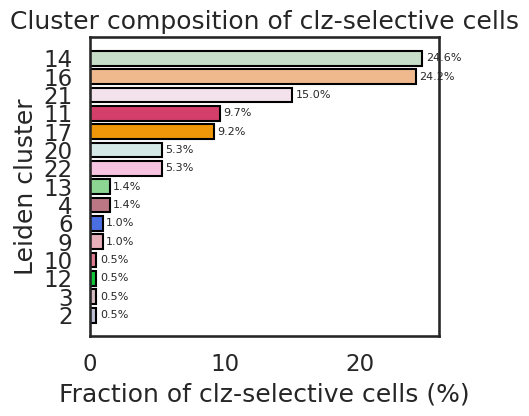

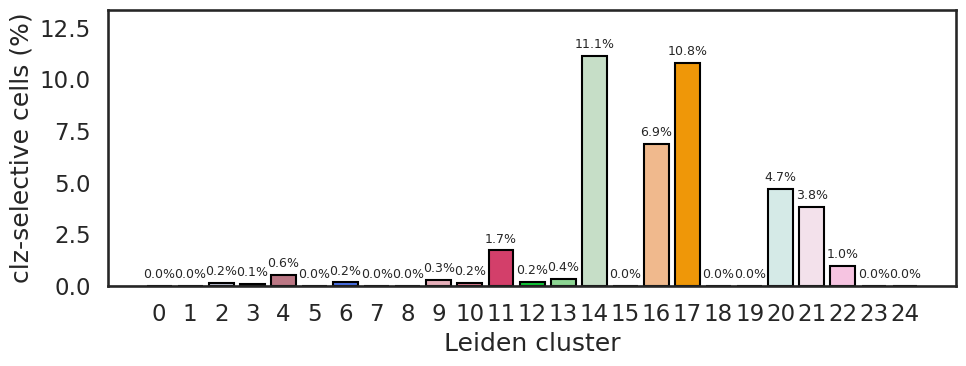

In [57]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

# ============================
# 出力ディレクトリ
# ============================
outdir = "/data/mouse_PFC/WT_only/figures"
os.makedirs(outdir, exist_ok=True)

# ============================
# フォント / PDF 設定（イラレ対応）
# ============================
rcParams["pdf.fonttype"] = 42   # TrueTypeとして埋め込み → Illustratorで編集可
rcParams["ps.fonttype"] = 42
rcParams["font.family"] = "DejaVu Sans"
rcParams["font.size"] = 11
rcParams["axes.unicode_minus"] = False

sns.set_context("talk")
sns.set_style("white")

# ============================
# 基本情報
# ============================
# leiden をカテゴリ化（まだなら）
adata.obs["leiden"] = adata.obs["leiden"].astype("category")

# is_clz_selective を bool に揃える（0/1でも動くように）
adata.obs["is_clz_selective"] = adata.obs["is_clz_selective"].astype(bool)

# UMAP と同じクラスタ色を使う（あれば）
leiden_cats = adata.obs["leiden"].cat.categories
if "leiden_colors" in adata.uns:
    leiden_colors = adata.uns["leiden_colors"]
    cluster_palette = {cat: col for cat, col in zip(leiden_cats, leiden_colors)}
else:
    palette = sns.color_palette("tab20", n_colors=len(leiden_cats))
    cluster_palette = {cat: col for cat, col in zip(leiden_cats, palette)}


# ============================
# 1) UMAP (leiden)
# ============================
fig1 = sc.pl.umap(
    adata,
    color="leiden",
    show=False,
    return_fig=True
)
fig1.savefig(os.path.join(outdir, "umap_leiden.pdf"),
             bbox_inches="tight")
plt.close(fig1)

# ============================
# 2) UMAP (is_clz_selective)
# ============================
fig2 = sc.pl.umap(
    adata,
    color="is_clz_selective",
    show=False,
    return_fig=True
)
fig2.savefig(os.path.join(outdir, "umap_is_clz_selective.pdf"),
             bbox_inches="tight")
plt.close(fig2)


# ============================
# 3-1) is_clz_selective な細胞のうち、
#      各 leiden クラスターの割合（横棒グラフ）
# ============================
sel = adata.obs[adata.obs["is_clz_selective"]]

# 各クラスターのカウント
sel_counts = sel["leiden"].value_counts().reindex(leiden_cats, fill_value=0)

# 0 個のクラスターは落としてよければ除外
sel_counts = sel_counts[sel_counts > 0]

# 割合（%）に変換して、見やすいように小さい方からソート
sel_pct = (sel_counts / sel_counts.sum() * 100).sort_values(ascending=True)

fig3, ax3 = plt.subplots(
    figsize=(5, max(3, 0.3 * len(sel_pct)))  # クラスター数に応じて縦サイズ少し伸ばす
)

colors = [cluster_palette[c] for c in sel_pct.index]

y_pos = np.arange(len(sel_pct))

ax3.barh(
    y_pos,
    sel_pct.values,
    color=colors,
    edgecolor="black"
)

ax3.set_yticks(y_pos)
ax3.set_yticklabels(sel_pct.index)
ax3.set_xlabel("Fraction of clz-selective cells (%)")
ax3.set_ylabel("Leiden cluster")
ax3.set_title("Cluster composition of clz-selective cells")

# 棒の右端に % ラベルを表示（混み具合で邪魔なら消してOK）
max_val = sel_pct.values.max() if len(sel_pct) > 0 else 0
for y, pct in zip(y_pos, sel_pct.values):
    ax3.text(
        pct + max_val * 0.01,  # 右にちょっとずらす
        y,
        f"{pct:.1f}%",
        va="center",
        ha="left",
        fontsize=8
    )

plt.tight_layout()
fig3.savefig(os.path.join(outdir, "barh_clz_selective_by_cluster.pdf"),
             bbox_inches="tight")
#plt.close(fig3)


# ============================
# 3-2) 各 leinden クラスターのうち、
#      is_clz_selective な割合の棒グラフ
#      （横軸: leiden, 縦軸: %）
# ============================
# クラスターごとに total / selective を集計
group = (
    adata.obs
    .groupby("leiden")["is_clz_selective"]
    .agg(total="size", sel="sum")
    .reindex(leiden_cats)
)

group["percent"] = group["sel"] / group["total"] * 100

fig4, ax4 = plt.subplots(figsize=(10, 4))

x = np.arange(len(leiden_cats))
heights = group["percent"].values
bar_colors = [cluster_palette[c] for c in leiden_cats]

ax4.bar(
    x,
    heights,
    color=bar_colors,
    edgecolor="black"
)

ax4.set_xticks(x)
ax4.set_xticklabels(leiden_cats, rotation=0)
ax4.set_ylabel("clz-selective cells (%)")
ax4.set_xlabel("Leiden cluster")

ax4.axhline(0, color="black", linewidth=1)
ax4.set_ylim(0, max(heights) * 1.2 if np.any(~np.isnan(heights)) else 1.0)

# （任意）バーの上に値を書きたい場合
for xi, h in zip(x, heights):
    ax4.text(
        xi,
        h + max(heights) * 0.02,
        f"{h:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

fig4.tight_layout()
fig4.savefig(os.path.join(outdir, "bar_fraction_clz_selective_by_cluster.pdf"),
             bbox_inches="tight")
#plt.close(fig4)

print("✅ Saved:")
print("  - umap_leiden.pdf")
print("  - umap_is_clz_selective.pdf")
print("  - pie_clz_selective_by_cluster.pdf")
print("  - bar_fraction_clz_selective_by_cluster.pdf")


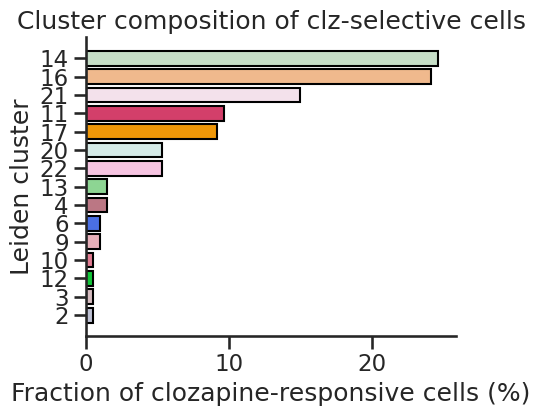

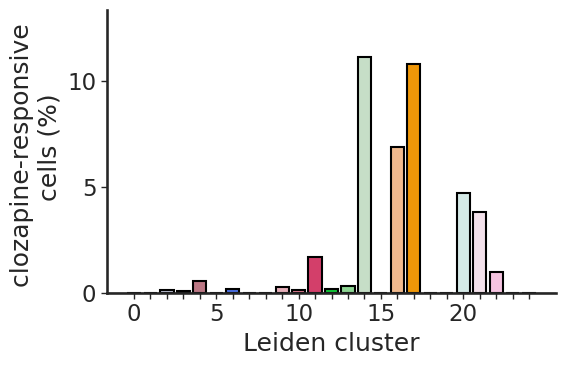

In [58]:
# ============================
# 3-1) is_clz_selective な細胞のうち、
#      各 leiden クラスターの割合（横棒グラフ）
# ============================
sel = adata.obs[adata.obs["is_clz_selective"]]

# 各クラスターのカウント
sel_counts = sel["leiden"].value_counts().reindex(leiden_cats, fill_value=0)

# 0 個のクラスターは落としてよければ除外
sel_counts = sel_counts[sel_counts > 0]

# 割合（%）に変換して、見やすいように小さい方からソート
sel_pct = (sel_counts / sel_counts.sum() * 100).sort_values(ascending=True)

fig3, ax3 = plt.subplots(
    figsize=(5, max(3, 0.3 * len(sel_pct)))  # クラスター数に応じて縦サイズ少し伸ばす
)

colors = [cluster_palette[c] for c in sel_pct.index]
y_pos = np.arange(len(sel_pct))

ax3.barh(
    y_pos,
    sel_pct.values,
    color=colors,
    edgecolor="black"
)

ax3.set_yticks(y_pos)
ax3.set_yticklabels(sel_pct.index)
ax3.set_xlabel("Fraction of clozapine-responsive cells (%)")
ax3.set_ylabel("Leiden cluster")
ax3.set_title("Cluster composition of clz-selective cells")

# ---- グリッドとスパイン設定 ----
ax3.spines["right"].set_visible(False)
ax3.spines["top"].set_visible(False)
ax3.xaxis.set_ticks_position("bottom")
ax3.yaxis.set_ticks_position("left")

# x軸に目盛り線（ticks）を追加
#ax3.xaxis.grid(True, linestyle="--", alpha=0.6)
ax3.tick_params(axis='x', which='both', direction='out')

# 棒の右端に % ラベルを表示
#max_val = sel_pct.values.max() if len(sel_pct) > 0 else 0
#for y, pct in zip(y_pos, sel_pct.values):
#    ax3.text(
#        pct + max_val * 0.01,  # 右に少しずらす
#        y,
#        f"{pct:.1f}%",
#        va="center",
#        ha="left",
#        fontsize=8
#    )

plt.tight_layout()
fig3.savefig(os.path.join(outdir, "barh_clz_selective_by_cluster.pdf"),
             bbox_inches="tight")

# ============================
# 3-2) 各 leinden クラスターのうち、
#      is_clz_selective な割合の棒グラフ
# ============================
group = (
    adata.obs
    .groupby("leiden")["is_clz_selective"]
    .agg(total="size", sel="sum")
    .reindex(leiden_cats)
)
group["percent"] = group["sel"] / group["total"] * 100

fig4, ax4 = plt.subplots(figsize=(6, 4))

x = np.arange(len(leiden_cats))
heights = group["percent"].values
bar_colors = [cluster_palette[c] for c in leiden_cats]

ax4.bar(
    x,
    heights,
    color=bar_colors,
    edgecolor="black"
)

ax4.set_xticks(x)
ax4.set_xticklabels(
    [str(i) if i % 5 == 0 else "" for i in range(len(leiden_cats))]
)
#ax4.set_xticklabels(leiden_cats, rotation=0)
ax4.set_ylabel("clozapine-responsive \n cells (%)")
ax4.set_xlabel("Leiden cluster")


ax4.axhline(0, color="black", linewidth=1)
ax4.set_ylim(0, max(heights) * 1.2 if np.any(~np.isnan(heights)) else 1.0)
ax4.set_yticks([0,5,10])
ax4.set_yticklabels([0,5,10])

# ---- 枠線とグリッド調整 ----
ax4.spines["right"].set_visible(False)
ax4.spines["top"].set_visible(False)
#ax4.yaxis.grid(True, linestyle="--", alpha=0.6)
ax4.tick_params(
    axis='both',
    which='both',
    direction='out',
    length=4,
    width=1,
    bottom=True,
    top=False,
    left=True,
    right=False,
    labelbottom=True,
    labelleft=True
)


# バー上にラベル
#for xi, h in zip(x, heights):
###    ax4.text(
#        xi,
#        h + max(heights) * 0.02,
#        f"{h:.1f}%",
#        ha="center",
#        va="bottom",
#        fontsize=9
#    )

fig4.tight_layout()
fig4.savefig(os.path.join(outdir, "bar_fraction_clz_selective_by_cluster.pdf"),
             bbox_inches="tight")

In [ ]:
dir="/data/mouse_PFC/CZPengram-3r"
results_df_sorted=pd.read_pickle(os.path.join(dir,"results_df_sorted_3r.pkl"))
all_responses=pd.read_pickle(os.path.join(dir,"all_responses_3r.pkl"))
#ct.visualize_patterns(results_df_sorted, top_n=20, top_n_for_heatmap=20, scatter_n=500)

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import matplotlib as mpl

# Illustratorで文字編集可能にする設定
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

def visualize_patterns(results_df_sorted, top_n=None, top_n_for_heatmap=None, scatter_n=None,
                       save_prefix=None, save_dir=None):
    """
    Parameters:
      results_df_sorted: DataFrame with columns 'pattern_name', 'pattern', 'diff'
      top_n: ヒートマップ・棒グラフで表示する上位パターン数
      top_n_for_heatmap: 拡大版ヒートマップで表示する上位パターン数
      scatter_n: 散布図で表示するパターン数
      save_prefix: 保存ファイル名のプレフィックス（例: 'patterns'）
      save_dir: 保存先ディレクトリ（例: 'figures'）
    """
    # 保存ディレクトリの準備
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    # 保存パスを組み立てるヘルパー関数
    def save_figure(fig, filename):
        if save_prefix is not None:
            if save_dir:
                filepath = os.path.join(save_dir, f"{save_prefix}_{filename}.pdf")
            else:
                filepath = f"{save_prefix}_{filename}.pdf"
            fig.savefig(filepath, bbox_inches="tight")
            print(f"Saved: {filepath}")

    # top_nの処理
    df_subset = results_df_sorted.head(top_n).reset_index(drop=True) if top_n else results_df_sorted.copy().reset_index(drop=True)
    n_patterns_subset = df_subset.shape[0]
    
    # ---- Heatmap ----
    def plot_heatmap(df, label):
        n_patterns = df.shape[0]
        first_pattern = df.iloc[0]['pattern']
        receptor_keys = list(first_pattern.keys())
        receptors = [key.replace('_raw', '') for key in receptor_keys]
        
        # True/False行列
        mat = np.array([[1 if pat.get(key, False) else 0 for key in receptor_keys] for pat in df['pattern']])
        cmap = ListedColormap(['white', 'steelblue'])
        fig, ax = plt.subplots(figsize=(12, max(6, n_patterns * 0.3)))
        im = ax.imshow(mat, aspect='auto', cmap=cmap)
        
        ax.set_xticks(np.arange(len(receptors)))
        ax.set_xticklabels(receptors, rotation=90)
        ax.set_yticks(np.arange(n_patterns))
        ax.set_yticklabels([str(i+1) for i in range(n_patterns)])
        ax.set_xlabel('Receptor Name')
        ax.set_ylabel('Pattern (sorted by diff descending)')
        ax.set_title(f'Pattern Visualization ({label}) (Top {n_patterns} Patterns)')
        ax.tick_params(
        axis='both',
        which='both',
        direction='out',
        length=4,
        width=1,
        bottom=True,
        top=False,
        left=True,
        right=False,
        labelbottom=True,
        labelleft=True
    )
        
        # Legend
        patches = [mpatches.Patch(color=cmap(0), label='False'),
                   mpatches.Patch(color=cmap(1), label='True')]
        ax.legend(handles=patches, title='Value',
                  bbox_to_anchor=(1.05, 1), loc='upper left')
        
        plt.tight_layout(rect=[0, 0, 0.85, 1])
        save_figure(fig, f"heatmap_{label or 'all'}")
        plt.show()
        plt.close(fig)

    # 通常ヒートマップ
    plot_heatmap(df_subset, label="all")

    # 拡大ヒートマップ
    if top_n_for_heatmap is not None:
        df_enlarge = results_df_sorted.head(top_n_for_heatmap).reset_index(drop=True)
        plot_heatmap(df_enlarge, label=f"top{top_n_for_heatmap}")
    
    # ---- Bar plot ----
    first_pattern = df_subset.iloc[0]['pattern']
    receptor_keys = list(first_pattern.keys())
    receptors = [key.replace('_raw', '') for key in receptor_keys]
    mat = np.array([[1 if pat.get(key, False) else 0 for key in receptor_keys] for pat in df_subset['pattern']])
    true_percentage = mat.mean(axis=0) * 100

    fig2, ax2 = plt.subplots(figsize=(12, 4))
    ax2.bar(np.arange(len(receptors)), true_percentage)
    ax2.set_xticks(np.arange(len(receptors)))
    ax2.set_xticklabels(receptors, rotation=90)
    ax2.set_xlabel('Receptor Name')
    ax2.set_ylabel('True Percentage (%)')
    ax2.set_title(f'True Percentage per Receptor (Top {n_patterns_subset} Patterns)')
    ax2.legend(handles=[mpatches.Patch(color='none', label='')],
               bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.tick_params(
    axis='both',
    which='both',
    direction='out',
    length=4,
    width=1,
    bottom=True,
    top=False,
    left=True,
    right=False,
    labelbottom=True,
    labelleft=True
)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    save_figure(fig2, "bar_true_percentage")
    plt.show()
    plt.close(fig2)
    
    # ---- Scatter plot ----
    df_scatter = results_df_sorted.head(scatter_n).reset_index(drop=True) if scatter_n else results_df_sorted.copy().reset_index(drop=True)
    total_patterns = df_scatter.shape[0]
    ticks = np.arange(0, total_patterns, 50)
    tick_labels = [str(t + 1) for t in ticks]
    
    fig3, ax3 = plt.subplots(figsize=(8, 4))
    ax3.scatter(np.arange(total_patterns), df_scatter['diff'], s=10)
    ax3.set_xlabel('Pattern (sorted by diff descending)')
    ax3.set_ylabel('Diff')
    ax3.set_title(f'Diff Values for Top {total_patterns} Patterns (sorted descending)')
    ax3.set_xticks(ticks)
    ax3.set_xticklabels(tick_labels, rotation=90)
    ax3.tick_params(
    axis='both',
    which='both',
    direction='out',
    length=4,
    width=1,
    bottom=True,
    top=False,
    left=True,
    right=False,
    labelbottom=True,
    labelleft=True
)
    plt.tight_layout()
    save_figure(fig3, "scatter_diff")
    plt.show()
    plt.close(fig3)


In [ ]:
visualize_patterns(
    results_df_sorted,
    top_n=10,
    top_n_for_heatmap=10,
    scatter_n=300,
    save_prefix="mouse_PFC_patterns",
    save_dir="/data/figures"
)

In [ ]:
D_R_mtx,GPCR_type_df,drug_list,GPCR_list=ct.load_parameters()

In [59]:
import pandas as pd
import numpy as np

def compute_camp_response_for_pattern(
    adata,
    GPCR_adata_norm_df,
    GPCR_type_df,
    drug_conc,
    pattern,
    group_col="is_clz_selective",
    selected_label=True,
    Ki_inhibited=0.01,
    Ki_not_inhibited=10000,
):
    """
    特定のGPCR阻害パターンを指定したときの cAMP response を計算し、
    - clz_selective / non_clz_selective の response
    - Leiden クラスター情報
    をまとめた DataFrame を返す。

    pattern:
        キー: 'HTR1A_raw' などの GPCR 列名
        値: True (阻害) / False (非阻害)
    """

    # ---- 0. 形を揃える（位置ベースで合わせる）----
    n_cells_expr = GPCR_adata_norm_df.shape[0]

    # adata.obs のフラグを取り出して、長さだけ揃える（RangeIndex ベース）
    if group_col not in adata.obs.columns:
        raise ValueError(f"{group_col} が adata.obs にありません。")
    group_values = adata.obs[group_col].values
    if len(group_values) < n_cells_expr:
        raise ValueError("GPCR_adata_norm_df の行数の方が adata.obs より多いです。対応するセル数が足りない。")
    group_values = group_values[:n_cells_expr]
    selective_mask = pd.Series(group_values == selected_label,
                               index=pd.RangeIndex(n_cells_expr))

    # Leiden クラスタも同様に取り出し（あれば）
    if "leiden" in adata.obs.columns:
        leiden_values = adata.obs["leiden"].astype(str).values
        if len(leiden_values) < n_cells_expr:
            raise ValueError("GPCR_adata_norm_df の行数の方が adata.obs より多いです（leiden列）。")
        leiden_values = leiden_values[:n_cells_expr]
    else:
        leiden_values = np.array(["NA"] * n_cells_expr)

    # ---- 1. GPCR 発現行列の準備 ----
    GPCR_list2 = [col for col in GPCR_adata_norm_df.columns if col != "Unnamed: 0"]
    all_expr = GPCR_adata_norm_df[GPCR_list2].copy()
    # index を RangeIndex にしておく（元コードと同じノリ）
    all_expr.index = pd.RangeIndex(n_cells_expr)

    # ---- 2. Gs / Gi リスト作成 ----
    Gs = GPCR_type_df[GPCR_type_df.type == "Gs"]["receptor_name"].values
    Gi = GPCR_type_df[GPCR_type_df.type == "Gi"]["receptor_name"].values

    Gs_filtered = [gene for gene in Gs if (gene + "_raw" in all_expr.columns)]
    Gi_filtered = [gene for gene in Gi if (gene + "_raw" in all_expr.columns)]

    Gs_cols = [gene + "_raw" for gene in Gs_filtered]
    Gi_cols = [gene + "_raw" for gene in Gi_filtered]

    # ---- 3. 1パターンで cAMP response を計算 ----
    def simulate_response_all(expression_df, pattern, drug_conc, Gs_cols, Gi_cols):
        # pattern に無いキーは阻害しない(False)
        effective_Ki = pd.Series(
            {
                receptor: (Ki_inhibited if pattern.get(receptor, False) else Ki_not_inhibited)
                for receptor in expression_df.columns
            }
        )

        gs_effect = (expression_df[Gs_cols].divide(1 + drug_conc / effective_Ki[Gs_cols])).sum(axis=1)
        gi_effect = (expression_df[Gi_cols].divide(1 + drug_conc / effective_Ki[Gi_cols])).sum(axis=1)
        basal_cAMP = (expression_df[Gs_cols] - expression_df[Gi_cols]).sum(axis=1)

        cAMPmod = (gs_effect - gi_effect) - basal_cAMP  # Series(index = cell)
        return cAMPmod

    all_responses = simulate_response_all(all_expr, pattern, drug_conc, Gs_cols, Gi_cols)

    # ---- 4. plot 用 DataFrame ----
    df_plot = pd.DataFrame(index=all_responses.index)
    df_plot["cAMP_response"] = all_responses.values
    df_plot["is_clz_selective"] = selective_mask.values
    df_plot["leiden"] = leiden_values
    df_plot["group"] = np.where(df_plot["is_clz_selective"],
                                "clz_selective",
                                "non_clz_selective")

    # ---- 5. サマリー ----
    selective_mean = df_plot.loc[df_plot["is_clz_selective"], "cAMP_response"].mean()
    nonselective_mean = df_plot.loc[~df_plot["is_clz_selective"], "cAMP_response"].mean()
    diff = selective_mean - nonselective_mean

    summary = {
        "selective_mean": selective_mean,
        "nonselective_mean": nonselective_mean,
        "diff": diff,
        "n_clz_selective": int(df_plot["is_clz_selective"].sum()),
        "n_nonselective": int((~df_plot["is_clz_selective"]).sum()),
    }

    print("n_clz_selective:", summary["n_clz_selective"])
    print("n_nonselective:", summary["n_nonselective"])

    return df_plot, summary



In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Illustratorで文字編集可能にする設定
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# === 静的閾値 ===
THRESHOLD_CLZ_CELLS = 2   # ← ここを変更すれば閾値変更できる

def save_figure(fig, filename, outdir="/data/mouse_PFC/WT_only/figures"):
    """図をPDFで保存（イラレ編集可）"""
    os.makedirs(outdir, exist_ok=True)
    filepath = os.path.join(outdir, filename)
    if not filepath.lower().endswith(".pdf"):
        filepath += ".pdf"
    fig.savefig(filepath, bbox_inches="tight")
    print(f"✅ Saved: {filepath}")


def plot_camp_responses(df_plot, summary, pattern_name="pattern", outdir="/data/"):
    """
    clz_selective vs non_clz_selective / Leiden別のcAMP反応を可視化しPDF保存。
    外れ値非表示、上右スパイン非表示、clz_selectiveを赤、その他を黒で描画。
    clz_selective細胞が THRESHOLD_CLZ_CELLS 未満のクラスタは非表示。
    """
    # === 1. clz_selective vs non_clz_selective ===
    fig1, ax1 = plt.subplots(figsize=(4, 6))
    groups = ["clz_selective", "non_clz_selective"]
    colors = ["red", "black"]

    data = [df_plot.loc[df_plot["group"] == g, "cAMP_response"].values for g in groups]
    ax1.boxplot(data, labels=groups, showfliers=False, patch_artist=True,
                boxprops=dict(facecolor='white', edgecolor='black'))
    ax1.set_ylabel("cAMP response (Δ)")
    ax1.set_title("cAMP response by clozapine selectivity")

    # 上・右スパインを非表示
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)

    # scatter overlay
    #for i, grp in enumerate(groups, start=1):
    #    y = df_plot.loc[df_plot["group"] == grp, "cAMP_response"].values
    #    x = np.random.normal(loc=i, scale=0.05, size=len(y))
    #    ax1.scatter(x, y, s=6, alpha=0.5, color=colors[i - 1])

    plt.tight_layout()
    save_figure(fig1, f"{pattern_name}_cAMP_clz_vs_nonclz.pdf", outdir)
    plt.close(fig1)

    # === 2. LeidenクラスタごとのcAMP反応 ===
    clusters = sorted(df_plot["leiden"].unique(), key=lambda x: int(x) if str(x).isdigit() else str(x))
    fig2, ax2 = plt.subplots(figsize=(max(6, len(clusters) * 0.4), 6))
    data = [df_plot.loc[df_plot["leiden"] == cl, "cAMP_response"].values for cl in clusters]
    labels = [str(cl) for cl in clusters]
    ax2.boxplot(data, labels=labels, showfliers=False)
    ax2.set_ylabel("cAMP response (Δ)")
    ax2.set_title("cAMP response by Leiden cluster")
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    plt.xticks(rotation=90)
    plt.tight_layout()
    save_figure(fig2, f"{pattern_name}_cAMP_by_leiden.pdf", outdir)
    plt.close(fig2)

    # === 3. Leiden × clz_selective / non_clz_selective ===
    fig3, ax3 = plt.subplots(figsize=(max(6, len(clusters) * 0.8), 6))
    positions, data, tick_pos, tick_labels = [], [], [], []

    for cl in clusters:
        # 各クラスタでclz_selective細胞数をチェック
        n_clz = df_plot.loc[(df_plot["leiden"] == cl) & (df_plot["group"] == "clz_selective")].shape[0]
        if n_clz < THRESHOLD_CLZ_CELLS:
            print(f"⚠️ Skipped Leiden {cl}: clz_selective cells < threshold ({n_clz} < {THRESHOLD_CLZ_CELLS})")
            continue

        # ここで「採用済みクラスタ数」から base を決める → 歯抜け防止
        base = len(tick_pos) * 3

        vals_sel = df_plot.loc[(df_plot["leiden"] == cl) & (df_plot["group"] == "clz_selective"),
                               "cAMP_response"].values
        vals_non = df_plot.loc[(df_plot["leiden"] == cl) & (df_plot["group"] == "non_clz_selective"),
                               "cAMP_response"].values

        positions.extend([base - 0.5, base + 0.5])
        data.extend([vals_sel, vals_non])
        tick_pos.append(base)
        tick_labels.append(str(cl))

    if data:
        bp = ax3.boxplot(data, positions=positions, showfliers=False, patch_artist=True)
        for j, box in enumerate(bp['boxes']):
            box.set(facecolor='white',
                    edgecolor='red' if j % 2 == 0 else 'black',
                    linewidth=1.2)

        ax3.set_xticks(tick_pos)
        ax3.set_xticklabels(tick_labels, rotation=90)
        ax3.set_ylabel("cAMP response (Δ)")
        ax3.set_title("cAMP response by Leiden cluster × clozapine selectivity")

        # 上右スパインを非表示
        ax3.spines["top"].set_visible(False)
        ax3.spines["right"].set_visible(False)

        plt.tight_layout()
        save_figure(fig3, f"{pattern_name}_cAMP_by_leiden_and_clz_old.pdf", outdir)
    else:
        print(f"⚠️ No clusters with ≥{THRESHOLD_CLZ_CELLS} clz_selective cells to plot.")
    plt.close(fig3)

    print(f"🎨 Figures saved to '{outdir}' (threshold={THRESHOLD_CLZ_CELLS}, clz=red, others=black)")


In [ ]:
import pandas as pd
import numpy as np

def compute_camp_response_for_pattern(
    adata,
    GPCR_adata_norm_df,
    GPCR_type_df,
    drug_conc,
    pattern,
    group_col="is_clz_selective",
    selected_label=True,
    Ki_inhibited=0.01,
    Ki_not_inhibited=10000,
):
    """
    特定のGPCR阻害パターンを指定したときの cAMP response を計算し、
    - clz_selective / non_clz_selective の response
    - Leiden クラスター情報
    をまとめた DataFrame を返す。

    pattern:
        キー: 'HTR1A_raw' などの GPCR 列名
        値: True (阻害) / False (非阻害)
    """

    # ---- 0. 形を揃える（位置ベースで合わせる）----
    n_cells_expr = GPCR_adata_norm_df.shape[0]

    # adata.obs のフラグを取り出して、長さだけ揃える（RangeIndex ベース）
    if group_col not in adata.obs.columns:
        raise ValueError(f"{group_col} が adata.obs にありません。")
    group_values = adata.obs[group_col].values
    if len(group_values) < n_cells_expr:
        raise ValueError("GPCR_adata_norm_df の行数の方が adata.obs より多いです。対応するセル数が足りない。")
    group_values = group_values[:n_cells_expr]
    selective_mask = pd.Series(group_values == selected_label,
                               index=pd.RangeIndex(n_cells_expr))

    # Leiden クラスタも同様に取り出し（あれば）
    if "leiden" in adata.obs.columns:
        leiden_values = adata.obs["leiden"].astype(str).values
        if len(leiden_values) < n_cells_expr:
            raise ValueError("GPCR_adata_norm_df の行数の方が adata.obs より多いです（leiden列）。")
        leiden_values = leiden_values[:n_cells_expr]
    else:
        leiden_values = np.array(["NA"] * n_cells_expr)

    # ---- 1. GPCR 発現行列の準備 ----
    GPCR_list2 = [col for col in GPCR_adata_norm_df.columns if col != "Unnamed: 0"]
    all_expr = GPCR_adata_norm_df[GPCR_list2].copy()
    # index を RangeIndex にしておく（元コードと同じノリ）
    all_expr.index = pd.RangeIndex(n_cells_expr)

    # ---- 2. Gs / Gi リスト作成 ----
    Gs = GPCR_type_df[GPCR_type_df.type == "Gs"]["receptor_name"].values
    Gi = GPCR_type_df[GPCR_type_df.type == "Gi"]["receptor_name"].values

    Gs_filtered = [gene for gene in Gs if (gene + "_raw" in all_expr.columns)]
    Gi_filtered = [gene for gene in Gi if (gene + "_raw" in all_expr.columns)]

    Gs_cols = [gene + "_raw" for gene in Gs_filtered]
    Gi_cols = [gene + "_raw" for gene in Gi_filtered]

    # ---- 3. 1パターンで cAMP response を計算 ----
    def simulate_response_all(expression_df, pattern, drug_conc, Gs_cols, Gi_cols):
        # pattern に無いキーは阻害しない(False)
        effective_Ki = pd.Series(
            {
                receptor: (Ki_inhibited if pattern.get(receptor, False) else Ki_not_inhibited)
                for receptor in expression_df.columns
            }
        )

        gs_effect = (expression_df[Gs_cols].divide(1 + drug_conc / effective_Ki[Gs_cols])).sum(axis=1)
        gi_effect = (expression_df[Gi_cols].divide(1 + drug_conc / effective_Ki[Gi_cols])).sum(axis=1)
        basal_cAMP = (expression_df[Gs_cols] - expression_df[Gi_cols]).sum(axis=1)

        cAMPmod = (gs_effect - gi_effect) - basal_cAMP  # Series(index = cell)
        return cAMPmod

    all_responses = simulate_response_all(all_expr, pattern, drug_conc, Gs_cols, Gi_cols)

    # ---- 4. plot 用 DataFrame ----
    df_plot = pd.DataFrame(index=all_responses.index)
    df_plot["cAMP_response"] = all_responses.values
    df_plot["is_clz_selective"] = selective_mask.values
    df_plot["leiden"] = leiden_values
    df_plot["group"] = np.where(df_plot["is_clz_selective"],
                                "clz_selective",
                                "non_clz_selective")

    # ---- 5. サマリー ----
    selective_mean = df_plot.loc[df_plot["is_clz_selective"], "cAMP_response"].mean()
    nonselective_mean = df_plot.loc[~df_plot["is_clz_selective"], "cAMP_response"].mean()
    diff = selective_mean - nonselective_mean

    summary = {
        "selective_mean": selective_mean,
        "nonselective_mean": nonselective_mean,
        "diff": diff,
        "n_clz_selective": int(df_plot["is_clz_selective"].sum()),
        "n_nonselective": int((~df_plot["is_clz_selective"]).sum()),
    }

    print("n_clz_selective:", summary["n_clz_selective"])
    print("n_nonselective:", summary["n_nonselective"])

    return df_plot, summary



In [134]:
cocktail_pattern={'HTR1A_raw': True,
 'HTR1B_raw': False,
 'HTR1D_raw': False,
 'HTR2A_raw': False,
 'HTR2B_raw': False,
 'HTR2C_raw': False,
 'HTR3A_raw': False,
 'HTR4_raw': False,
 'HTR5A_raw': False,
 'HTR6_raw': False,
 'HTR7_raw': False,
 'DRD1_raw': False,
 'DRD2_raw': False,
 'DRD4_raw': False,
 'DRD5_raw': False,
 'HRH1_raw': False,
 'HRH2_raw': False,
 'HRH3_raw': True,
 'CHRM1_raw': False,
 'CHRM2_raw': True,
 'CHRM3_raw': False,
 'CHRM5_raw': False,
 'ADRA1A_raw': False,
 'ADRA1B_raw': False,
 'ADRA2A_raw': False,
 'ADRA2C_raw': False,
 'ADRB1_raw': False,
 'ADRB2_raw': False}

In [137]:
# 例: diff が最大のパターン
best_pattern = results_df_sorted.iloc[1]["pattern"]

THRESHOLD_CLZ_CELLS = 4
# cAMP反応の計算済みデータを利用
df_plot, summary = compute_camp_response_for_pattern(
    adata=adata,
    GPCR_adata_norm_df=GPCR_adata_norm_df,
    GPCR_type_df=GPCR_type_df,
    drug_conc=drug_conc,
    pattern=cocktail_pattern,
    group_col="is_clz_selective",
    selected_label=True,
)

# プロットして保存
plot_camp_responses(df_plot, summary, pattern_name="best_pattern")

n_clz_selective: 207
n_nonselective: 15552
✅ Saved: /data/mouse_PFC/WT_only/figures/best_pattern_cAMP_clz_vs_nonclz.pdf
✅ Saved: /data/mouse_PFC/WT_only/figures/best_pattern_cAMP_by_leiden.pdf
⚠️ Skipped Leiden 0: clz_selective cells < threshold (0 < 4)
⚠️ Skipped Leiden 1: clz_selective cells < threshold (0 < 4)
⚠️ Skipped Leiden 2: clz_selective cells < threshold (1 < 4)
⚠️ Skipped Leiden 3: clz_selective cells < threshold (1 < 4)
⚠️ Skipped Leiden 4: clz_selective cells < threshold (3 < 4)
⚠️ Skipped Leiden 5: clz_selective cells < threshold (0 < 4)
⚠️ Skipped Leiden 6: clz_selective cells < threshold (2 < 4)
⚠️ Skipped Leiden 7: clz_selective cells < threshold (0 < 4)
⚠️ Skipped Leiden 8: clz_selective cells < threshold (0 < 4)
⚠️ Skipped Leiden 9: clz_selective cells < threshold (2 < 4)
⚠️ Skipped Leiden 10: clz_selective cells < threshold (1 < 4)
⚠️ Skipped Leiden 12: clz_selective cells < threshold (1 < 4)
⚠️ Skipped Leiden 13: clz_selective cells < threshold (3 < 4)
⚠️ Skipped 

In [133]:
best_pattern

{'HTR1A_raw': True,
 'HTR1B_raw': False,
 'HTR1D_raw': False,
 'HTR2A_raw': False,
 'HTR2B_raw': False,
 'HTR2C_raw': False,
 'HTR3A_raw': False,
 'HTR4_raw': False,
 'HTR5A_raw': False,
 'HTR6_raw': False,
 'HTR7_raw': False,
 'DRD1_raw': False,
 'DRD2_raw': False,
 'DRD4_raw': False,
 'DRD5_raw': False,
 'HRH1_raw': False,
 'HRH2_raw': False,
 'HRH3_raw': False,
 'CHRM1_raw': False,
 'CHRM2_raw': True,
 'CHRM3_raw': False,
 'CHRM5_raw': False,
 'ADRA1A_raw': False,
 'ADRA1B_raw': False,
 'ADRA2A_raw': False,
 'ADRA2C_raw': False,
 'ADRB1_raw': False,
 'ADRB2_raw': True}

In [68]:
def plot_camp_responses(df_plot, summary, adata, pattern_name="pattern", outdir="/data/mouse_PFC/WT_only/figures"):
    """
    Leidenクラスタカラーを adata.uns['leiden_colors'] から取得。
    clz_selective枠線を赤、non_clzを黒に。
    スキップクラスタ分を詰めて配置し、図幅も自動調整。
    """
    clusters_all = sorted(df_plot["leiden"].unique(), key=lambda x: int(x) if str(x).isdigit() else str(x))

    # --- Scanpy UMAPのクラスタカラーを使用 ---
    if "leiden_colors" in adata.uns:
        leiden_colors = adata.uns["leiden_colors"]
        print(f"🎨 Using {len(leiden_colors)} Leiden colors from adata.uns['leiden_colors']")
    else:
        import matplotlib.cm as cm
        cmap = cm.get_cmap("tab10", len(clusters_all))
        leiden_colors = [cmap(i) for i in range(len(clusters_all))]
        print("⚠️ adata.uns['leiden_colors'] not found. Using tab10 fallback palette.")

    # === プロット対象クラスタを抽出 ===
    clusters_valid = []
    for cl in clusters_all:
        n_clz = df_plot.loc[(df_plot["leiden"] == cl) & (df_plot["group"] == "clz_selective")].shape[0]
        if n_clz >= THRESHOLD_CLZ_CELLS:
            clusters_valid.append(cl)
        else:
            print(f"⚠️ Skipped Leiden {cl}: clz_selective cells < threshold ({n_clz} < {THRESHOLD_CLZ_CELLS})")

    if len(clusters_valid) == 0:
        print(f"⚠️ No clusters with ≥{THRESHOLD_CLZ_CELLS} clz_selective cells to plot.")
        return

    # --- 有効クラスタ数に基づいて図の横幅を調整 ---
    fig_width = max(8, len(clusters_valid) * 1)
    fig3, ax3 = plt.subplots(figsize=(fig_width, 6))

    positions, data, tick_pos, tick_labels, colors_used = [], [], [], [], []

    # === データと色をまとめる ===
    for cl in clusters_valid:
        base = len(tick_pos) * 3  # 歯抜け防止

        vals_sel = df_plot.loc[(df_plot["leiden"] == cl) & (df_plot["group"] == "clz_selective"), "cAMP_response"].values
        vals_non = df_plot.loc[(df_plot["leiden"] == cl) & (df_plot["group"] == "non_clz_selective"), "cAMP_response"].values

        positions.extend([base - 0.5, base + 0.5])
        data.extend([vals_sel, vals_non])
        tick_pos.append(base)
        tick_labels.append(str(cl))

        # Leiden カラーを adata.uns['leiden_colors'] から取得
        try:
            colors_used.append(leiden_colors[int(cl)])
        except Exception:
            colors_used.append(leiden_colors[len(colors_used) % len(leiden_colors)])

    # === ボックスプロット描画 ===
    bp = ax3.boxplot(data, positions=positions, showfliers=False, patch_artist=True)
    for j, box in enumerate(bp['boxes']):
        cluster_idx = j // 2
        cluster_color = colors_used[cluster_idx]
        if j % 2 == 0:
            # clz_selective
            box.set(facecolor=cluster_color, edgecolor='red', linewidth=1.5)
        else:
            # non_clz_selective
            box.set(facecolor=cluster_color, edgecolor='black', linewidth=1.2)

    # 軸ラベル設定
    ax3.set_xticks(tick_pos)
    ax3.set_xticklabels(tick_labels, rotation=90)
    ax3.set_ylabel("cAMP response (Δ)")
    ax3.set_title(f"cAMP response by Leiden cluster × clozapine selectivity\n(threshold={THRESHOLD_CLZ_CELLS})")

    # スパイン非表示
    ax3.spines["top"].set_visible(False)
    ax3.spines["right"].set_visible(False)

    plt.tight_layout()
    save_figure(fig3, f"{pattern_name}_cAMP_by_leiden_and_clz.pdf", outdir)
    plt.close(fig3)

    print(f"🎨 Finished plotting {len(clusters_valid)} clusters → width adjusted to {fig_width:.1f}")

In [69]:
THRESHOLD_CLZ_CELLS = 4  # 閾値設定（例）
plot_camp_responses(df_plot, summary, adata=adata, pattern_name="best_pattern")

🎨 Using 25 Leiden colors from adata.uns['leiden_colors']
⚠️ Skipped Leiden 0: clz_selective cells < threshold (0 < 4)
⚠️ Skipped Leiden 1: clz_selective cells < threshold (0 < 4)
⚠️ Skipped Leiden 2: clz_selective cells < threshold (1 < 4)
⚠️ Skipped Leiden 3: clz_selective cells < threshold (1 < 4)
⚠️ Skipped Leiden 4: clz_selective cells < threshold (3 < 4)
⚠️ Skipped Leiden 5: clz_selective cells < threshold (0 < 4)
⚠️ Skipped Leiden 6: clz_selective cells < threshold (2 < 4)
⚠️ Skipped Leiden 7: clz_selective cells < threshold (0 < 4)
⚠️ Skipped Leiden 8: clz_selective cells < threshold (0 < 4)
⚠️ Skipped Leiden 9: clz_selective cells < threshold (2 < 4)
⚠️ Skipped Leiden 10: clz_selective cells < threshold (1 < 4)
⚠️ Skipped Leiden 12: clz_selective cells < threshold (1 < 4)
⚠️ Skipped Leiden 13: clz_selective cells < threshold (3 < 4)
⚠️ Skipped Leiden 15: clz_selective cells < threshold (0 < 4)
⚠️ Skipped Leiden 18: clz_selective cells < threshold (0 < 4)
⚠️ Skipped Leiden 19: c

In [138]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind

def ttest_clz_vs_nonclz(df_plot):
    """
    clz_selective vs non_clz_selective で cAMP_response の t検定（Welch）を実行
    """
    df = df_plot.copy()
    df = df.dropna(subset=["cAMP_response", "group"])  # 念のため

    clz_vals = df.loc[df["group"] == "clz_selective", "cAMP_response"].values
    non_vals = df.loc[df["group"] == "non_clz_selective", "cAMP_response"].values

    res = ttest_ind(clz_vals, non_vals, equal_var=False, nan_policy="omit")

    result_dict = {
        "n_clz": int(np.sum(~np.isnan(clz_vals))),
        "n_nonclz": int(np.sum(~np.isnan(non_vals))),
        "t_stat": res.statistic,
        "p_value": res.pvalue,
    }
    return result_dict
tt_res = ttest_clz_vs_nonclz(df_plot)
print(tt_res)

{'n_clz': 207, 'n_nonclz': 15552, 't_stat': 26.548614930680035, 'p_value': 1.1683449948291064e-68}


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import ttest_ind

def anova_and_posthoc_camp(df_plot):
    """
    2因子ANOVA (group × leiden) と、
    各Leidenクラスター内での clz vs non-clz の posthoc t検定を行う。
    
    Returns
    -------
    anova_table : pd.DataFrame
        2因子 ANOVA の分散分析表
    posthoc_df : pd.DataFrame
        各 Leiden 内での t検定結果（pをBonferroni補正したものも含む）
    """
    df = df_plot.copy()
    df = df.dropna(subset=["cAMP_response", "group", "leiden"])

    # カテゴリ型にしておく
    df["group"] = df["group"].astype("category")
    df["leiden"] = df["leiden"].astype("category")

    # ---- 2因子ANOVA ----
    model = ols("cAMP_response ~ C(group) * C(leiden)", data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)  # typ=2 か 3 は好みで

    # ---- posthoc: 各Leiden内でclz vs non-clz を t検定 ----
    posthoc_results = []
    clusters = sorted(df["leiden"].cat.categories, key=lambda x: int(x) if str(x).isdigit() else str(x))

    for cl in clusters:
        sub = df[df["leiden"] == cl]
        vals_clz = sub.loc[sub["group"] == "clz_selective", "cAMP_response"].values
        vals_non = sub.loc[sub["group"] == "non_clz_selective", "cAMP_response"].values

        # 両群にデータがない/1例以下ならスキップ
        if np.sum(~np.isnan(vals_clz)) < 2 or np.sum(~np.isnan(vals_non)) < 2:
            t_stat, p_val = np.nan, np.nan
        else:
            t_res = ttest_ind(vals_clz, vals_non, equal_var=False, nan_policy="omit")
            t_stat, p_val = t_res.statistic, t_res.pvalue

        posthoc_results.append({
            "leiden": cl,
            "n_clz": int(np.sum(~np.isnan(vals_clz))),
            "n_nonclz": int(np.sum(~np.isnan(vals_non))),
            "t_stat": t_stat,
            "p_raw": p_val,
        })

    posthoc_df = pd.DataFrame(posthoc_results)

    # Bonferroni補正（Leidenの数で割る）
    m = posthoc_df["p_raw"].notna().sum()
    if m > 0:
        posthoc_df["p_bonferroni"] = np.minimum(posthoc_df["p_raw"] * m, 1.0)
    else:
        posthoc_df["p_bonferroni"] = np.nan

    return anova_table, posthoc_df

anova_table, posthoc_df = anova_and_posthoc_camp(df_plot)

print("=== 2-way ANOVA (group × leiden) ===")
print(anova_table)

print("\n=== Posthoc: clz vs non-clz within each Leiden (t-test, Bonferroni corrected) ===")
print(posthoc_df)

n_clz_selective: 207
n_nonselective: 15552
{'selective_mean': 5381.1624708694635, 'nonselective_mean': -172.40882112196476, 'diff': 5553.571291991429, 'n_clz_selective': 207, 'n_nonselective': 15552}


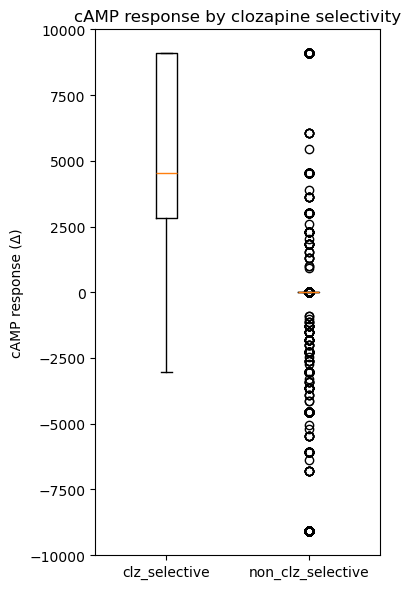

In [74]:
# 例: diff が最大のパターン
best_pattern = results_df_sorted.iloc[1]["pattern"]

import matplotlib.pyplot as plt
import numpy as np
mpl.rcParams.update(mpl.rcParamsDefault)
df_plot, summary = compute_camp_response_for_pattern(
    adata=adata,
    GPCR_adata_norm_df=GPCR_adata_norm_df,
    GPCR_type_df=GPCR_type_df,
    drug_conc=drug_conc,
    pattern=best_pattern,          # 使いたいパターン
    group_col="is_clz_selective",
    selected_label=True,
)

print(summary)

# clz_selective vs non_clz_selective boxplot
fig, ax = plt.subplots(figsize=(4, 6))

data = [
    df_plot.loc[df_plot["group"] == "clz_selective", "cAMP_response"].values,
    df_plot.loc[df_plot["group"] == "non_clz_selective", "cAMP_response"].values,
]
labels = ["clz_selective", "non_clz_selective"]

ax.boxplot(data, labels=labels)
ax.set_ylabel("cAMP response (Δ)")
ax.set_title("cAMP response by clozapine selectivity")

plt.tight_layout()
plt.show()

In [72]:
best_pattern

{'HTR1A_raw': True,
 'HTR1B_raw': False,
 'HTR1D_raw': False,
 'HTR2A_raw': False,
 'HTR2B_raw': False,
 'HTR2C_raw': False,
 'HTR3A_raw': False,
 'HTR4_raw': False,
 'HTR5A_raw': False,
 'HTR6_raw': False,
 'HTR7_raw': False,
 'DRD1_raw': False,
 'DRD2_raw': False,
 'DRD4_raw': False,
 'DRD5_raw': False,
 'HRH1_raw': False,
 'HRH2_raw': False,
 'HRH3_raw': False,
 'CHRM1_raw': False,
 'CHRM2_raw': True,
 'CHRM3_raw': False,
 'CHRM5_raw': False,
 'ADRA1A_raw': False,
 'ADRA1B_raw': False,
 'ADRA2A_raw': False,
 'ADRA2C_raw': False,
 'ADRB1_raw': False,
 'ADRB2_raw': True}

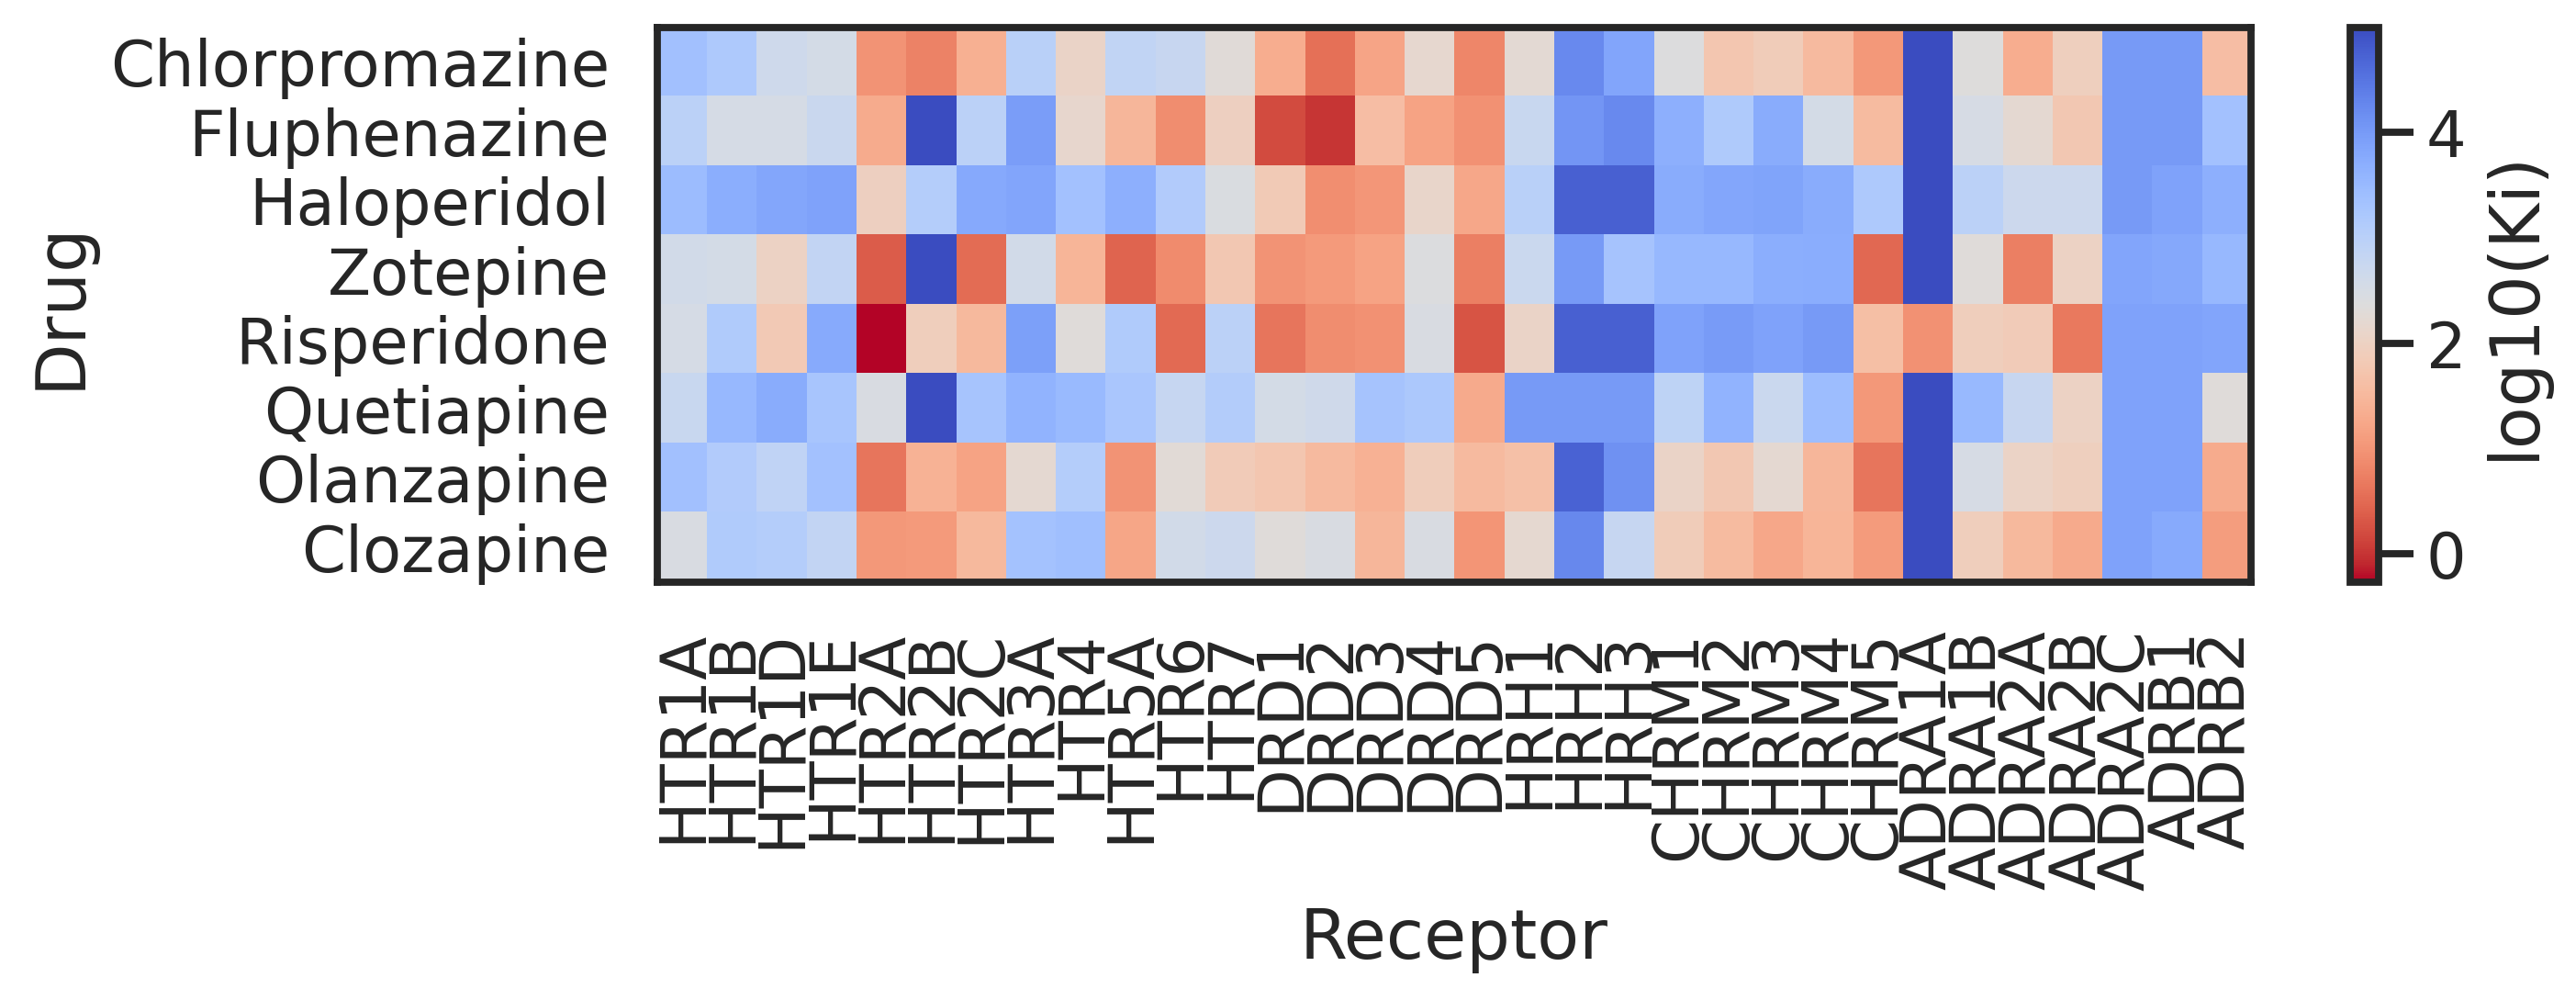

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===== Illustrator で編集しやすい PDF 設定 =====
plt.rcParams["pdf.fonttype"] = 42   # フォントをアウトライン化しない（TrueType）
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["figure.dpi"] = 300    # 表示用。PDF自体はベクターなのでここはお好み
plt.rcParams["font.size"] = 16
# ===== データ読み込み =====
# 例: タブ区切りの場合（質問の表っぽい形式）
df = D_R_mtx
# CSVなら↓
# 薬剤名（index）を頭文字のみ大文字に統一
df.index = [name.capitalize() for name in df.index]
# 行: drug（Ligand）, 列: 受容体名 になっている前提
# 値のダイナミックレンジが大きいので log10 にして可視化した方が見やすい場合が多い
data = df.astype(float)
log_data = np.log10(data)

# ===== ヒートマップ描画 =====
fig, ax = plt.subplots(figsize=(10, 4))  # サイズはお好みで

# imshow でヒートマップを描く（ベクター PDF で保存される）
im = ax.imshow(
    log_data.values,
    aspect="auto",      # 行数・列数に応じて自動調整
    cmap="coolwarm_r",     # カラーマップ（お好みで変更）
    interpolation="nearest"
)

# 軸ラベル・目盛
ax.set_xticks(np.arange(log_data.shape[1]))
ax.set_xticklabels(log_data.columns, rotation=90)

ax.set_yticks(np.arange(log_data.shape[0]))
ax.set_yticklabels(log_data.index)

ax.set_xlabel("Receptor")
ax.set_ylabel("Drug")



# カラーバー（log10[affinity] であることを明記）
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("log10(Ki)")

plt.tight_layout()


# ===== PDF 保存（Illustrator で編集可能） =====
output_path = "/data/mouse_PFC/WT_only/figures/drug_receptor_affinity_heatmap.pdf"
plt.savefig(output_path, format="pdf")  # ベクター形式で保存
plt.show(fig)


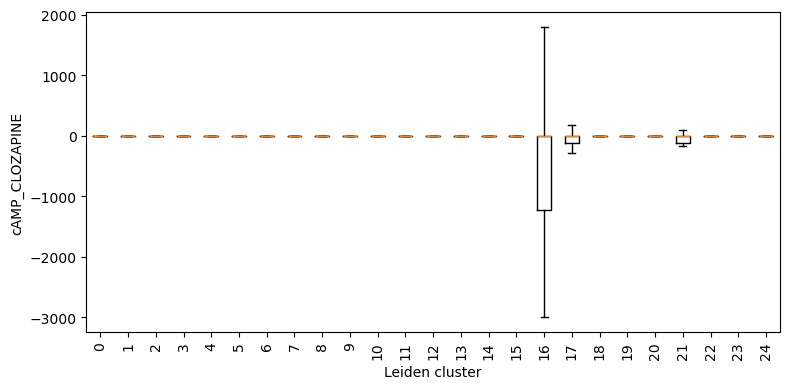

In [75]:
import numpy as np
import matplotlib.pyplot as plt

# cAMP_clozapine のカラム名判定
if "cAMP_CLOZAPINE" in adata.obs.columns:
    camp_key = "cAMP_CLOZAPINE"
elif "cAMP_clozapine" in adata.obs.columns:
    camp_key = "cAMP_clozapine"
else:
    raise KeyError("adata.obs に cAMP_CLOZAPINE / cAMP_clozapine が見つからないよ")

adata.obs["leiden"] = adata.obs["leiden"].astype("category")

# クラスターのリスト（文字列としてソート）
clusters = sorted(adata.obs["leiden"].cat.categories, key=lambda x: int(x))

# 各クラスターの値をリストにまとめる
data_per_cluster = [
    adata.obs.loc[adata.obs["leiden"] == cl, camp_key].values
    for cl in clusters
]

plt.figure(figsize=(8, 4))
plt.boxplot(data_per_cluster, showfliers=False)  # 外れ値を非表示にするなら showfliers=False

plt.xticks(np.arange(1, len(clusters) + 1), clusters, rotation=90)
plt.xlabel("Leiden cluster")
plt.ylabel(camp_key)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

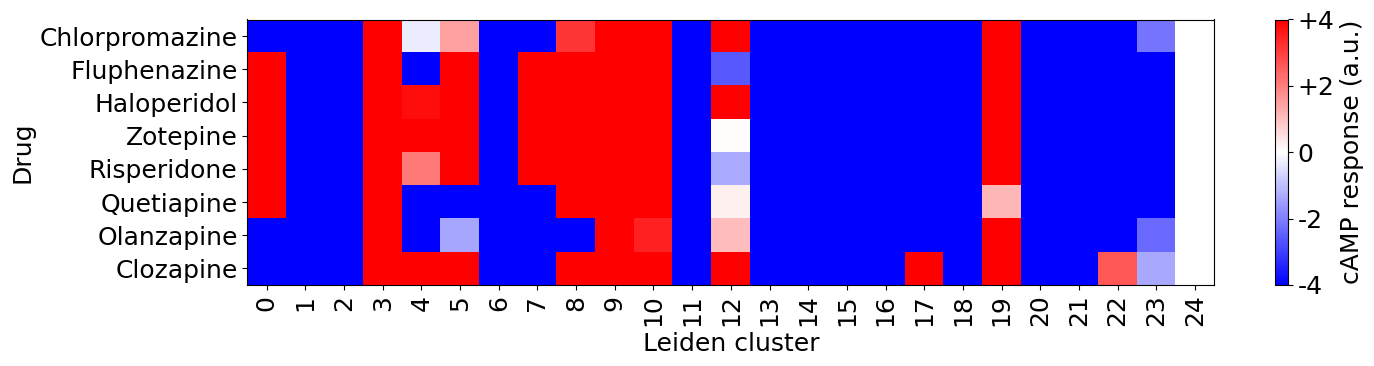

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Illustrator で編集しやすい PDF 設定（必要なら）
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["font.size"] = 18
plt.rcParams["font.family"] = "DejaVu Sans"
# 使う薬剤リスト
drug_list = [
    'CHLORPROMAZINE',
    'FLUPHENAZINE',
    'HALOPERIDOL',
    'ZOTEPINE',
    'RISPERIDONE',
    'QUETIAPINE',
    'OLANZAPINE',
    'CLOZAPINE'
]

# ===== 前提：adata には既に以下が入っている =====
#  - adata.obs["leiden"] : クラスターラベル（文字列）
#  - adata.obs["cAMP_<DRUG>"] : 各薬剤の cAMP 反応

# leiden をカテゴリに統一
adata.obs["leiden"] = adata.obs["leiden"].astype("category")

# クラスターを数値順にソート（"0","1","2",... を想定）
clusters = sorted(adata.obs["leiden"].cat.categories, key=lambda x: int(x))

# ヒートマップ用の行列 (行: drug, 列: leiden cluster)
heatmap = np.zeros((len(drug_list), len(clusters)), dtype=float)

for i, drug in enumerate(drug_list):
    col_name = f"cAMP_{drug}"
    if col_name not in adata.obs.columns:
        raise KeyError(f"{col_name} が adata.obs に見つからない")

    # クラスターごとの平均 cAMP 反応
    mean_per_cluster = (
        adata.obs
        .groupby("leiden")[col_name]
        .mean()
        .reindex(clusters)   # クラスター順を揃える
    )
    heatmap[i, :] = mean_per_cluster.values

# 表示用の薬剤名（頭文字だけ大文字）
drug_labels = [d.capitalize() for d in drug_list]

# === ヒートマップ描画 ===
fig, ax = plt.subplots(
    figsize=(max(6, len(clusters) * 0.6), max(4, len(drug_list) * 0.5))
)

# 0 を中心にしたいので vmin/vmax を対称に設定（任意で調整）
vmax = np.nanmax(np.abs(heatmap))
vmin = -vmax

im = ax.imshow(
    heatmap,
    aspect="auto",
    cmap="bwr",   # 負: 青, 正: 赤（cAMP 上昇/低下を直感的に）
    vmin=-4,
    vmax=4,
    interpolation="nearest"
)

# 軸ラベル・目盛り
ax.set_xticks(np.arange(len(clusters)))
ax.set_xticklabels(clusters, rotation=90)
ax.set_xlabel("Leiden cluster")

ax.set_yticks(np.arange(len(drug_list)))
ax.set_yticklabels(drug_labels)
ax.set_ylabel("Drug")

# カラーバー
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("cAMP response (a.u.)")
cbar.set_ticks([-4, -2, 0, 2, 4])
cbar.set_ticklabels(["-4", "-2", "0", "+2", "+4"])
plt.tight_layout()

# 画面表示
plt.show()

# Illustrator で編集可能な PDF として保存したい場合
plt.savefig("/data/mouse_PFC/WT_only/figures/cAMP_response_by_cluster.pdf", format="pdf")
# plt.close(fig)


<Figure size 640x480 with 0 Axes>

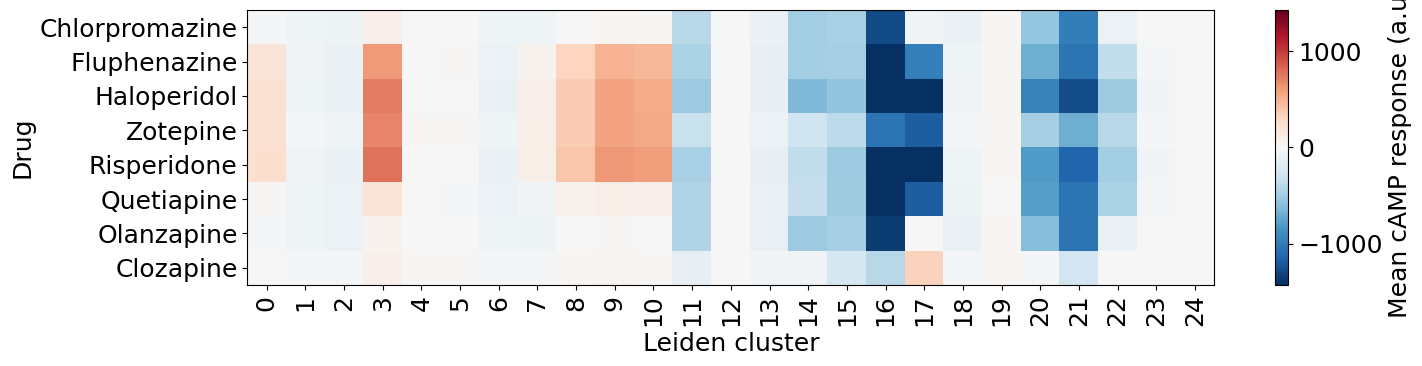

In [ ]:
#8drug cAMP heatmap
from matplotlib.colors import TwoSlopeNorm
import matplotlib.pyplot as plt
import numpy as np

# 外れ値で色がつぶれないように robust に vmax を決める
vmax = np.nanpercentile(np.abs(heatmap), 98)
vmax = max(vmax, 1e-9)

norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

fig, ax = plt.subplots(
    figsize=(max(6, len(clusters) * 0.6), max(4, len(drug_list) * 0.5))
)

im = ax.imshow(
    heatmap,
    aspect="auto",
    cmap="RdBu_r",   # 負: 青, 正: 赤
    norm=norm,
    interpolation="nearest"
)

ax.set_xticks(np.arange(len(clusters)))
ax.set_xticklabels(clusters, rotation=90)
ax.set_xlabel("Leiden cluster")

ax.set_yticks(np.arange(len(drug_list)))
ax.set_yticklabels(drug_labels)
ax.set_ylabel("Drug")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Mean cAMP response (a.u.)")

plt.tight_layout()
plt.savefig("/data/mouse_PFC/WT_only/figures/cAMP_response_by_cluster.pdf", format="pdf")
plt.show()

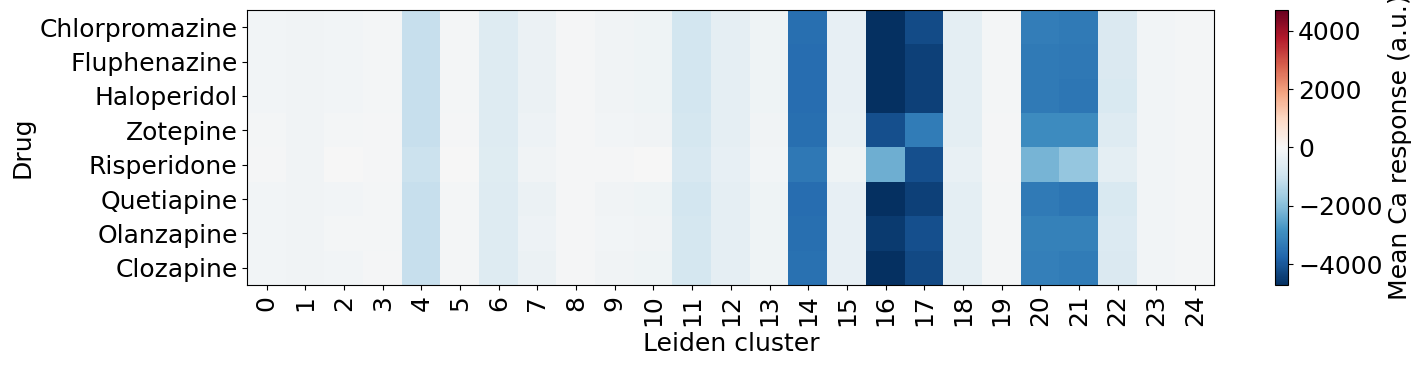

In [87]:
#8drug Ca heatmap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# ====================================
# PDF / font settings
# ====================================
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["font.size"] = 18
plt.rcParams["font.family"] = "DejaVu Sans"

# ====================================
# Drug list
# ====================================
drug_list = [
    'CHLORPROMAZINE',
    'FLUPHENAZINE',
    'HALOPERIDOL',
    'ZOTEPINE',
    'RISPERIDONE',
    'QUETIAPINE',
    'OLANZAPINE',
    'CLOZAPINE'
]

# ====================================
# Leiden clusters
# ====================================
adata.obs["leiden"] = adata.obs["leiden"].astype("category")
clusters = sorted(adata.obs["leiden"].cat.categories, key=lambda x: int(x))

# ====================================
# Heatmap matrix: row = drug, col = cluster
# ====================================
heatmap = np.zeros((len(drug_list), len(clusters)), dtype=float)

for i, drug in enumerate(drug_list):
    col_name = f"Ca_{drug}"

    if col_name not in adata.obs.columns:
        raise KeyError(f"{col_name} が adata.obs に見つからない")

    mean_per_cluster = (
        adata.obs
        .groupby("leiden", observed=False)[col_name]
        .mean()
        .reindex(clusters)
    )

    heatmap[i, :] = mean_per_cluster.values

# 表示用の薬剤名
drug_labels = [d.capitalize() for d in drug_list]

# ====================================
# Plot
# ====================================
fig, ax = plt.subplots(
    figsize=(max(6, len(clusters) * 0.6), max(4, len(drug_list) * 0.5))
)

# robust color scaling
vmax = np.nanpercentile(np.abs(heatmap), 98)
vmax = max(vmax, 1e-9)

norm = TwoSlopeNorm(
    vmin=-vmax,
    vcenter=0,
    vmax=vmax
)

im = ax.imshow(
    heatmap,
    aspect="auto",
    cmap="RdBu_r",   # negative: blue, positive: red
    norm=norm,
    interpolation="nearest"
)

# x/y labels
ax.set_xticks(np.arange(len(clusters)))
ax.set_xticklabels(clusters, rotation=90)
ax.set_xlabel("Leiden cluster")

ax.set_yticks(np.arange(len(drug_list)))
ax.set_yticklabels(drug_labels)
ax.set_ylabel("Drug")

# colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Mean Ca response (a.u.)")

plt.tight_layout()

# save before show
plt.savefig(
    "/data/mouse_PFC/WT_only/figures/Ca_response_by_cluster.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

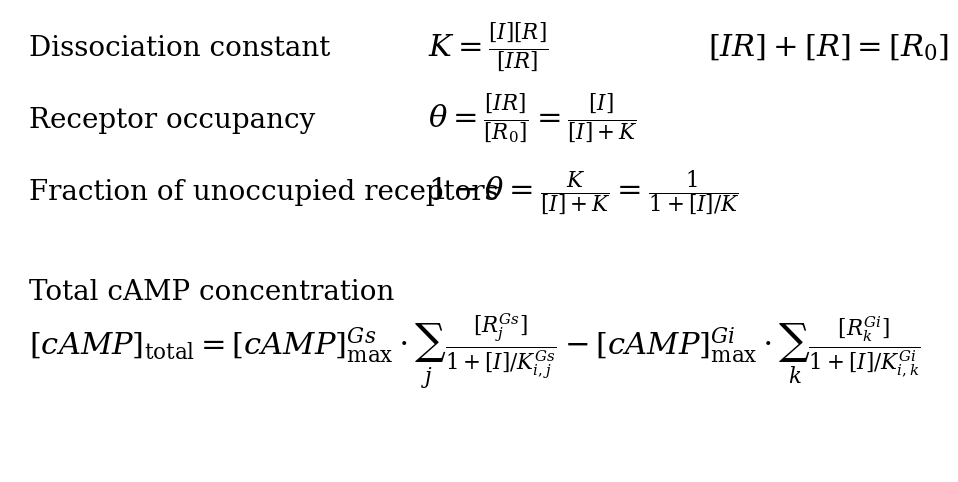

In [77]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

# LaTeX は使わず mathtext だけで描画
rcParams["text.usetex"] = False
rcParams["font.family"] = "serif"
rcParams["mathtext.fontset"] = "dejavuserif"   # 好きに変えてOK

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis("off")

y = 0.9
dy = 0.12

# 1. Dissociation constant
ax.text(0.02, y, "Dissociation constant",
        fontsize=20, transform=ax.transAxes)
ax.text(0.45, y,
        r"$K = \frac{[I][R]}{[IR]}$",
        fontsize=22, transform=ax.transAxes)
ax.text(0.75, y,
        r"$[IR] + [R] = [R_0]$",
        fontsize=22, transform=ax.transAxes)

# 2. Receptor occupancy
y -= dy * 1.3
ax.text(0.02, y, "Receptor occupancy",
        fontsize=20, transform=ax.transAxes)
ax.text(0.45, y,
        r"$\theta = \frac{[IR]}{[R_0]} = \frac{[I]}{[I]+K}$",
        fontsize=22, transform=ax.transAxes)

# 3. Fraction of unoccupied receptors
y -= dy * 1.3
ax.text(0.02, y, "Fraction of unoccupied receptors",
        fontsize=20, transform=ax.transAxes)
ax.text(0.45, y,
        r"$1-\theta = \frac{K}{[I]+K} = \frac{1}{1+[I]/K}$",
        fontsize=22, transform=ax.transAxes)

# 4. Total cAMP concentration
y -= dy * 1.8
ax.text(0.02, y, "Total cAMP concentration",
        fontsize=20, transform=ax.transAxes)

ax.text(
    0.02, y-0.12,
    r"$[cAMP]_{\mathrm{total}}"
    r" = [cAMP]^{Gs}_{\mathrm{max}} \cdot"
    r" \sum_j \frac{[R^{Gs}_j]}{1 + [I]/K^{Gs}_{i,j}}"
    r" - [cAMP]^{Gi}_{\mathrm{max}} \cdot"
    r" \sum_k \frac{[R^{Gi}_k]}{1 + [I]/K^{Gi}_{i,k}}$",
    fontsize=22,
    transform=ax.transAxes
)

# 保存パスは好きなパスに変えてOK
plt.savefig("/data/mouse_PFC/WT_only/figures/receptor_model_equations.pdf", bbox_inches="tight")
plt.show()

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_volcano_from_deg(
    df_deg,
    group=True,
    adj_p_cutoff=0.05,
    log2fc_cutoff=0.25,
    top_n_labels=20,
    output_pdf=None,
    title=None,
    figsize=(7, 6),
):
    """
    Scanpy sc.get.rank_genes_groups_df() の結果から volcano plot を作成する関数。

    Parameters
    ----------
    df_deg : pandas.DataFrame
        sc.get.rank_genes_groups_df(adata, group=None) の出力
    group : bool or str
        プロットする group。例: True, False, "True", "False"
    adj_p_cutoff : float
        adjusted p-value のカットオフ
    log2fc_cutoff : float
        absolute log2 fold change のカットオフ
    top_n_labels : int
        ラベル表示する有意遺伝子数
    output_pdf : str or None
        PDF保存先。Noneなら保存しない
    title : str or None
        プロットタイトル
    figsize : tuple
        図のサイズ
    """

    df = df_deg.copy()

    # groupで絞り込み
    if "group" in df.columns:
        df["group"] = df["group"].astype(str)
        df = df[df["group"] == str(group)].copy()

    if df.empty:
        raise ValueError(f"No rows found for group={group}")

    # logfoldchangesをlog2foldchangeとして扱う
    if "logfoldchanges" in df.columns:
        df["log2foldchange"] = df["logfoldchanges"]
    elif "log2foldchange" not in df.columns:
        raise ValueError("df_deg must contain 'logfoldchanges' or 'log2foldchange'.")

    # adjusted p-value列
    if "pvals_adj" in df.columns:
        p_col = "pvals_adj"
    elif "adj_p_val" in df.columns:
        p_col = "adj_p_val"
    else:
        raise ValueError("df_deg must contain 'pvals_adj' or 'adj_p_val'.")

    # p=0対策
    min_positive_p = df.loc[df[p_col] > 0, p_col].min()
    if pd.isna(min_positive_p):
        min_positive_p = 1e-300

    df[p_col] = df[p_col].replace(0, min_positive_p)
    df["minus_log10_adj_p"] = -np.log10(df[p_col])

    # 有意判定
    df["significant"] = (
        (df[p_col] < adj_p_cutoff)
        & (df["log2foldchange"].abs() >= log2fc_cutoff)
    )

    df["direction"] = "Not significant"
    df.loc[
        df["significant"] & (df["log2foldchange"] > 0),
        "direction"
    ] = "Up"

    df.loc[
        df["significant"] & (df["log2foldchange"] < 0),
        "direction"
    ] = "Down"

    # plot
    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(
        df.loc[df["direction"] == "Not significant", "log2foldchange"],
        df.loc[df["direction"] == "Not significant", "minus_log10_adj_p"],
        s=8,
        alpha=0.4,
        color="lightgray",
        label="Not significant",
    )

    ax.scatter(
        df.loc[df["direction"] == "Up", "log2foldchange"],
        df.loc[df["direction"] == "Up", "minus_log10_adj_p"],
        s=12,
        alpha=0.8,
        color="crimson",
        label="Up",
    )

    ax.scatter(
        df.loc[df["direction"] == "Down", "log2foldchange"],
        df.loc[df["direction"] == "Down", "minus_log10_adj_p"],
        s=12,
        alpha=0.8,
        color="royalblue",
        label="Down",
    )

    # cutoff lines
    ax.axhline(
        -np.log10(adj_p_cutoff),
        linestyle="--",
        linewidth=1,
        color="black",
    )
    ax.axvline(
        log2fc_cutoff,
        linestyle="--",
        linewidth=1,
        color="black",
    )
    ax.axvline(
        -log2fc_cutoff,
        linestyle="--",
        linewidth=1,
        color="black",
    )

    # gene labels
    if "names" in df.columns and top_n_labels > 0:
        label_df = (
            df[df["significant"]]
            .sort_values(p_col)
            .head(top_n_labels)
        )

        for _, row in label_df.iterrows():
            ax.text(
                row["log2foldchange"],
                row["minus_log10_adj_p"],
                row["names"],
                fontsize=8,
                ha="center",
                va="bottom",
            )

    ax.set_xlabel("log2 fold change")
    ax.set_ylabel("-log10 adjusted p-value")

    if title is None:
        title = f"Volcano plot: group={group}"

    ax.set_title(title)
    ax.legend(frameon=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    if output_pdf is not None:
        plt.savefig(output_pdf, format="pdf", bbox_inches="tight")
        print(f"Saved: {output_pdf}")

    plt.show()

    print("Total genes:", len(df))
    print("Significant genes:", df["significant"].sum())
    print("Up:", (df["direction"] == "Up").sum())
    print("Down:", (df["direction"] == "Down").sum())

    return df

Saved: /data/mouse_PFC/WT_only/volcano_is_clz_selective_groupTrue.pdf


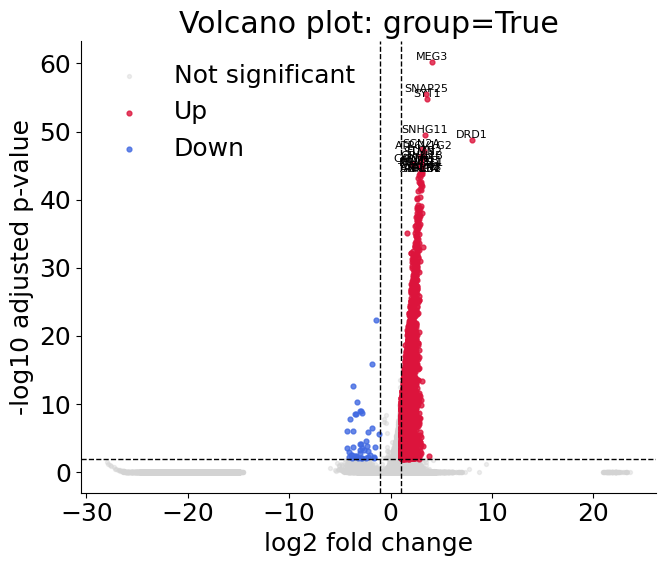

Total genes: 20789
Significant genes: 3323
Up: 3280
Down: 43


In [91]:
volcano_df = plot_volcano_from_deg(
    df_deg,
    group=True,
    adj_p_cutoff=0.01,
    log2fc_cutoff=1,
    top_n_labels=20,
    output_pdf="/data/mouse_PFC/WT_only/volcano_is_clz_selective_groupTrue.pdf",
)

In [130]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_volcano_from_deg(
    df_deg,
    output_pdf,
    group=None,
    adj_p_cutoff=0.01,
    log2fc_cutoff=1,
    top_n_labels=20,
    title="Volcano plot",
    label_genes=None,
    label_only_cutoff=True,
    max_label_genes=40,
    gene_col="names",
):
    """
    DEG tableからvolcano plotを作成。

    group:
        df_degに"group"列がある場合、そのgroupだけに絞る。
        例: group=True, group="True", group="clz_selective"
    """

    df = df_deg.copy()

    # ----------------------------
    # group filter
    # ----------------------------
    if group is not None and "group" in df.columns:
        before = len(df)

        # bool / str どちらでもマッチするようにする
        group_str = str(group).lower()
        mask = df["group"].astype(str).str.lower() == group_str

        df = df[mask].copy()

        print(f"Filtered group={group}: {before} -> {len(df)} rows")

        if len(df) == 0:
            raise ValueError(
                f"No rows left after filtering group={group}. "
                f"Available groups: {df_deg['group'].unique()}"
            )

    elif group is not None and "group" not in df.columns:
        print("[WARN] group was specified, but df_deg has no 'group' column. No filtering applied.")

    # ----------------------------
    # column check
    # ----------------------------
    if gene_col not in df.columns:
        raise ValueError(f"{gene_col} column is not found.")

    if "log2foldchange" not in df.columns:
        if "logfoldchanges" in df.columns:
            df["log2foldchange"] = df["logfoldchanges"]
        else:
            raise ValueError("df_deg must contain logfoldchanges or log2foldchange.")

    if "pvals_adj" in df.columns:
        p_col = "pvals_adj"
    elif "adj_p_val" in df.columns:
        p_col = "adj_p_val"
    else:
        raise ValueError("df_deg must contain pvals_adj or adj_p_val.")

    # ----------------------------
    # clean numeric
    # ----------------------------
    df["log2foldchange"] = pd.to_numeric(df["log2foldchange"], errors="coerce")
    df[p_col] = pd.to_numeric(df[p_col], errors="coerce")

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=[gene_col, "log2foldchange", p_col]).copy()

    # 同じ遺伝子が複数ある場合は、p値が小さいものだけ残す
    before_dup = len(df)
    df = (
        df.sort_values(p_col, ascending=True)
        .drop_duplicates(subset=gene_col, keep="first")
        .copy()
    )
    after_dup = len(df)

    if before_dup != after_dup:
        print(f"Removed duplicated genes: {before_dup} -> {after_dup}")

    # p=0対策
    min_pos_p = df.loc[df[p_col] > 0, p_col].min()
    if pd.isna(min_pos_p):
        min_pos_p = 1e-300

    df[p_col] = df[p_col].replace(0, min_pos_p)
    df["minus_log10_adj_p"] = -np.log10(df[p_col])

    # ----------------------------
    # significance
    # ----------------------------
    df["pass_cutoff"] = (
        (df[p_col] < adj_p_cutoff)
        & (df["log2foldchange"].abs() >= log2fc_cutoff)
    )

    df["direction"] = "Not significant"
    df.loc[
        df["pass_cutoff"] & (df["log2foldchange"] > 0),
        "direction"
    ] = "Up"

    df.loc[
        df["pass_cutoff"] & (df["log2foldchange"] < 0),
        "direction"
    ] = "Down"

    # ----------------------------
    # plot
    # ----------------------------
    fig, ax = plt.subplots(figsize=(7, 6))

    for direction, size, alpha in [
        ("Not significant", 8, 0.25),
        ("Up", 14, 0.8),
        ("Down", 14, 0.8),
    ]:
        d = df[df["direction"] == direction]
        if len(d) == 0:
            continue

        ax.scatter(
            d["log2foldchange"],
            d["minus_log10_adj_p"],
            s=size,
            alpha=alpha,
            label=direction,
        )

    ax.axhline(
        -np.log10(adj_p_cutoff),
        linestyle="--",
        linewidth=1,
        color="black",
    )
    ax.axvline(
        log2fc_cutoff,
        linestyle="--",
        linewidth=1,
        color="black",
    )
    ax.axvline(
        -log2fc_cutoff,
        linestyle="--",
        linewidth=1,
        color="black",
    )

    # ----------------------------
    # label genes
    # ----------------------------
    if label_genes is not None:
        label_set = {str(g).upper() for g in label_genes}

        label_df = df[
            df[gene_col].astype(str).str.upper().isin(label_set)
        ].copy()

        if label_only_cutoff:
            label_df = label_df[label_df["pass_cutoff"]].copy()

        label_df = (
            label_df
            .sort_values([p_col, "log2foldchange"], ascending=[True, False])
            .head(max_label_genes)
        )

    else:
        label_df = (
            df[df["pass_cutoff"]]
            .sort_values(p_col)
            .head(top_n_labels)
            .copy()
        )

    for _, row in label_df.iterrows():
        ax.text(
            row["log2foldchange"],
            row["minus_log10_adj_p"],
            str(row[gene_col]),
            fontsize=8,
            ha="center",
            va="bottom",
        )

    ax.set_xlabel("log2 fold change")
    ax.set_ylabel("-log10 adjusted p-value")
    ax.set_title(title)

    ax.legend(frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    out_dir = os.path.dirname(output_pdf)
    if out_dir != "":
        os.makedirs(out_dir, exist_ok=True)

    plt.savefig(output_pdf, bbox_inches="tight")
    plt.close(fig)

    print("saved:", output_pdf)
    print("total plotted genes:", len(df))
    print("pass cutoff:", int(df["pass_cutoff"].sum()))
    print("up:", int((df["direction"] == "Up").sum()))
    print("down:", int((df["direction"] == "Down").sum()))
    print("labeled genes:", list(label_df[gene_col]))

    return df

synapse_plasticity_spine_genes = [
    # postsynaptic density / scaffold
    "DLG4", "DLG1", "DLG2", "DLG3",
    "SHANK1", "SHANK2", "SHANK3",
    "HOMER1", "HOMER2", "HOMER3",
    "DLGAP1", "DLGAP2", "DLGAP3", "DLGAP4",

    # glutamate receptors
    "GRIN1", "GRIN2A", "GRIN2B", "GRIN2C", "GRIN2D",
    "GRIA1", "GRIA2", "GRIA3", "GRIA4",
    "GRM1", "GRM2", "GRM3", "GRM5",

    # synaptic vesicle / presynapse
    "SYN1", "SYN2", "SYN3",
    "SYP", "SNAP25", "STX1A", "STX1B", "VAMP2",
    "SYT1", "SYT2", "RIMS1", "RIMS2", "BSN", "PCLO",

    # adhesion / synapse organization
    "NRXN1", "NRXN2", "NRXN3",
    "NLGN1", "NLGN2", "NLGN3",
    "LRRTM1", "LRRTM2", "LRRTM3", "LRRTM4",
    "CNTNAP2",

    # spine cytoskeleton / actin regulation
    "ACTB", "RAC1", "CDC42", "RHOA",
    "PAK1", "PAK2", "PAK3",
    "LIMK1", "LIMK2", "CFL1",
    "ARPC1A", "ARPC2", "ARPC3", "ARPC4", "ARPC5",
    "WASF1", "ABI1", "CYFIP1",
    "DBN1", "SYNPO", "MAP2",

    # plasticity / activity-dependent genes
    "CAMK2A", "CAMK2B", "CAMK2D", "CAMK2G",
    "CAMK4", "PPP3CA", "PPP3CB",
    "PRKACA", "PRKACB", "CREB1",
    "ARC", "EGR1", "FOS", "JUN", "NPAS4",
    "BDNF", "NTRK2",

    # schizophrenia / synaptic risk-related candidates
    "SYNGAP1", "FMR1", "DISC1", "RELN",
]

In [131]:
priority_genes_main = [
    "DLG4", "HOMER1", "DLGAP1","GRIN2A",
    "GRIN2B", "GRIA1", "GRIA2","GRIA3",
    "SNAP25", "SYT1", "STX1A",
    "CAMK2A", "PPP3CA", "NTRK2","BDNF",
    "CUL1","XPO7","TRIO","HERC1","RB1CC1"
]

volcano_df = plot_volcano_from_deg(
    df_deg,
    group=True,
    adj_p_cutoff=0.01,
    log2fc_cutoff=1,
    top_n_labels=20,
    #label_genes=synapse_plasticity_spine_genes,
    label_genes=priority_genes_main,
    label_only_cutoff=True,
    max_label_genes=40,
    title="clz-selective vs non-selective",
    output_pdf="/data/mouse_PFC/WT_only/volcano_is_clz_selective_synapse_genes_cutoff.pdf",
)

Filtered group=True: 41578 -> 20789 rows
saved: /data/mouse_PFC/WT_only/volcano_is_clz_selective_synapse_genes_cutoff.pdf
total plotted genes: 20789
pass cutoff: 3323
up: 3280
down: 43
labeled genes: ['SNAP25', 'SYT1', 'GRIN2B', 'PPP3CA', 'GRIA2', 'STX1A', 'DLGAP1', 'GRIA3', 'CAMK2A', 'GRIA1', 'HERC1', 'GRIN2A', 'HOMER1', 'NTRK2', 'DLG4', 'RB1CC1', 'CUL1', 'TRIO', 'BDNF']


In [132]:
schema_10 = [
    "SETD1A",
    "CACNA1G",
    "CUL1",
    "GRIA3",
    "GRIN2A",
    "HERC1",
    "RB1CC1",
    "SP4",
    "TRIO",
    "XPO7",
]
volcano_df = plot_volcano_from_deg(
    df_deg,
    group=True,
    adj_p_cutoff=0.05,
    log2fc_cutoff=0.25,
    top_n_labels=20,
    #label_genes=synapse_plasticity_spine_genes,
    label_genes=schema_10,
    label_only_cutoff=True,
    max_label_genes=40,
    title="clz-selective vs non-selective",
    output_pdf="/data/mouse_PFC/WT_only/volcano_is_clz_selective_schema10.pdf",
)

Filtered group=True: 41578 -> 20789 rows
saved: /data/mouse_PFC/WT_only/volcano_is_clz_selective_schema10.pdf
total plotted genes: 20789
pass cutoff: 5082
up: 4990
down: 92
labeled genes: ['GRIA3', 'HERC1', 'GRIN2A', 'RB1CC1', 'CUL1', 'TRIO', 'XPO7']


In [94]:
import traceback
import numpy as np
import scipy.sparse as sp
import scanpy as sc
import os


def run_deg_clz_selective(
    adata,
    output_dir,
    groupby="clz_group",
    case="clz_selective",
    control="non_selective",
    layer="lognorm",
    method="wilcoxon",
    dense_fallback=True,
    max_dense_gb=12,
):
    """
    scanpy rank_genes_groups wrapper.

    pydevd/debugger + numba sparse_mean_var のAssertionErrorが出た場合、
    一時的にlayerをdense化して再実行するfallback付き。
    """

    _ensure_dir(output_dir)

    use_layer = layer if layer in adata.layers else None

    def _run_rank_genes_groups(a):
        sc.tl.rank_genes_groups(
            a,
            groupby=groupby,
            groups=[case],
            reference=control,
            method=method,
            layer=use_layer if use_layer in a.layers else None,
            use_raw=False,
            pts=True,
        )
        return sc.get.rank_genes_groups_df(a, group=case)

    try:
        df_deg = _run_rank_genes_groups(adata)

    except AssertionError as e:
        tb = traceback.format_exc()

        is_pydevd_error = (
            "pydevd_sys_monitoring" in tb
            or "_pydevd" in tb
            or "sparse_mean_var_minor_axis" in tb
        )

        if not dense_fallback or not is_pydevd_error:
            raise

        print("[WARN] scanpy/numba sparse path failed, likely due to debugger/pydevd.")
        print("[WARN] Retry rank_genes_groups with dense temporary layer.")
        print("[WARN] Best fix is to restart kernel and run without Debug Cell.")

        adata_tmp = adata.copy()

        if use_layer is not None:
            X = adata_tmp.layers[use_layer]
            target = "layer"
        else:
            X = adata_tmp.X
            target = "X"

        if sp.issparse(X):
            est_gb = (
                adata_tmp.n_obs
                * adata_tmp.n_vars
                * np.dtype(np.float32).itemsize
                / 1024**3
            )

            print(f"Estimated dense matrix size: {est_gb:.2f} GB")

            if est_gb > max_dense_gb:
                raise MemoryError(
                    f"Dense fallback would require ~{est_gb:.2f} GB, "
                    f"which exceeds max_dense_gb={max_dense_gb}. "
                    "Restart kernel and run without debugger instead."
                )

            X_dense = X.toarray().astype(np.float32)

            if target == "layer":
                adata_tmp.layers[use_layer] = X_dense
            else:
                adata_tmp.X = X_dense.astype(np.float32)

        else:
            if target == "layer":
                adata_tmp.layers[use_layer] = np.asarray(X, dtype=np.float32)
            else:
                adata_tmp.X = np.asarray(X, dtype=np.float32)

        df_deg = _run_rank_genes_groups(adata_tmp)

        # 結果を元adataにもコピー
        adata.uns["rank_genes_groups"] = adata_tmp.uns["rank_genes_groups"]

    df_deg["log2foldchange"] = df_deg["logfoldchanges"]

    out_csv = os.path.join(output_dir, "05_DEG_clz_selective_vs_nonselective.csv")
    df_deg.to_csv(out_csv, index=False)

    print("saved:", out_csv)

    return df_deg

In [96]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_volcano_from_deg(
    df_deg,
    output_pdf,
    adj_p_cutoff=0.05,
    log2fc_cutoff=0.25,
    top_n_labels=20,
    title="clz_selective vs non_selective",
    label_genes=None,
    gene_col="names",
):
    """
    Scanpy rank_genes_groups の DEG table から volcano plot を作る。

    Parameters
    ----------
    df_deg : pandas.DataFrame
        sc.get.rank_genes_groups_df() の出力

    output_pdf : str
        保存先PDF

    adj_p_cutoff : float
        adjusted p-value cutoff

    log2fc_cutoff : float
        absolute log2 fold change cutoff

    top_n_labels : int
        label_genes=None の場合に、有意上位何個をラベルするか

    title : str
        plot title

    label_genes : list or None
        指定した遺伝子を優先的にラベルする。
        Noneなら有意上位遺伝子をラベル。

    gene_col : str
        遺伝子名の列名。scanpy標準は "names"。
    """

    df = df_deg.copy()

    # ----------------------------
    # 必須列チェック
    # ----------------------------
    if gene_col not in df.columns:
        raise ValueError(f"{gene_col} column is not found in df_deg.")

    if "log2foldchange" not in df.columns:
        if "logfoldchanges" in df.columns:
            df["log2foldchange"] = df["logfoldchanges"]
        else:
            raise ValueError("df_deg must contain logfoldchanges or log2foldchange.")

    if "pvals_adj" in df.columns:
        p_col = "pvals_adj"
    elif "adj_p_val" in df.columns:
        p_col = "adj_p_val"
    else:
        raise ValueError("df_deg must contain pvals_adj or adj_p_val.")

    # ----------------------------
    # 数値化
    # ----------------------------
    df["log2foldchange"] = pd.to_numeric(df["log2foldchange"], errors="coerce")
    df[p_col] = pd.to_numeric(df[p_col], errors="coerce")

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=["log2foldchange", p_col]).copy()

    if len(df) == 0:
        raise ValueError("No valid rows after removing NaN/inf.")

    # p=0対策
    min_positive_p = df.loc[df[p_col] > 0, p_col].min()
    if pd.isna(min_positive_p):
        min_positive_p = 1e-300

    df[p_col] = df[p_col].replace(0, min_positive_p)
    df["minus_log10_adj_p"] = -np.log10(df[p_col])

    # ----------------------------
    # significance分類
    # ----------------------------
    df["significant"] = (
        (df[p_col] < adj_p_cutoff)
        & (df["log2foldchange"].abs() >= log2fc_cutoff)
    )

    df["direction"] = "Not significant"
    df.loc[
        df["significant"] & (df["log2foldchange"] > 0),
        "direction"
    ] = "Up"

    df.loc[
        df["significant"] & (df["log2foldchange"] < 0),
        "direction"
    ] = "Down"

    # ----------------------------
    # plot
    # ----------------------------
    fig, ax = plt.subplots(figsize=(7, 6))

    plot_order = [
        ("Not significant", 8, 0.35),
        ("Up", 12, 0.8),
        ("Down", 12, 0.8),
    ]

    for direction, size, alpha in plot_order:
        d = df[df["direction"] == direction]
        if len(d) == 0:
            continue

        ax.scatter(
            d["log2foldchange"],
            d["minus_log10_adj_p"],
            s=size,
            alpha=alpha,
            label=direction,
        )

    # cutoff lines
    ax.axhline(
        -np.log10(adj_p_cutoff),
        linestyle="--",
        linewidth=1,
        color="black",
    )

    ax.axvline(
        log2fc_cutoff,
        linestyle="--",
        linewidth=1,
        color="black",
    )

    ax.axvline(
        -log2fc_cutoff,
        linestyle="--",
        linewidth=1,
        color="black",
    )

    # ----------------------------
    # labels
    # ----------------------------
    if label_genes is not None:
        label_set = {str(g).upper() for g in label_genes}

        label_df = df[
            df[gene_col].astype(str).str.upper().isin(label_set)
        ].copy()

        # 同じ遺伝子が複数ある場合に備えて有意度順
        label_df = label_df.sort_values(p_col)

    else:
        label_df = (
            df[df["significant"]]
            .sort_values(p_col)
            .head(top_n_labels)
            .copy()
        )

    for _, row in label_df.iterrows():
        ax.text(
            row["log2foldchange"],
            row["minus_log10_adj_p"],
            str(row[gene_col]),
            fontsize=8,
            ha="center",
            va="bottom",
        )

    ax.set_xlabel("log2 fold change")
    ax.set_ylabel("-log10 adjusted p-value")
    ax.set_title(title)

    if len(ax.get_legend_handles_labels()[0]) > 0:
        ax.legend(frameon=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    out_dir = os.path.dirname(output_pdf)
    if out_dir != "":
        os.makedirs(out_dir, exist_ok=True)

    plt.savefig(output_pdf, bbox_inches="tight")
    plt.close()

    print("saved:", output_pdf)
    print("total genes:", len(df))
    print("significant genes:", int(df["significant"].sum()))
    print("up:", int((df["direction"] == "Up").sum()))
    print("down:", int((df["direction"] == "Down").sum()))

    return df

In [111]:
#clz_feature_analysis
import os
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact


# ============================================================
# 0. Utility functions
# ============================================================

def _ensure_dir(path):
    os.makedirs(path, exist_ok=True)


def _get_X(adata, layer="lognorm"):
    if layer is not None and layer in adata.layers:
        return adata.layers[layer]
    return adata.X


def _to_bool_mask(series, positive_value=True):
    """
    adata.obs["is_clz_selective"] が bool/category/string どれでも動くようにする
    """
    s = pd.Series(series).astype(str).str.lower()

    if isinstance(positive_value, bool):
        if positive_value:
            return s.isin(["true", "1", "yes", "y", "t"])
        else:
            return s.isin(["false", "0", "no", "n", "f"])
    else:
        return s == str(positive_value).lower()


def _match_genes(adata, genes):
    """
    adata.var_names が uppercase 前提でも、入力geneが小文字混じりでも拾えるようにする
    """
    var_map = {str(g).upper(): g for g in adata.var_names}
    matched = []
    missing = []

    for g in genes:
        key = str(g).upper()
        if key in var_map:
            matched.append(var_map[key])
        else:
            missing.append(g)

    return matched, missing


def _extract_expr(adata, genes, layer="lognorm"):
    matched, missing = _match_genes(adata, genes)
    if len(matched) == 0:
        return None, matched, missing

    X = _get_X(adata, layer=layer)
    idx = [adata.var_names.get_loc(g) for g in matched]
    mat = X[:, idx]

    return mat, matched, missing


def _mean_expr_per_cell(adata, genes, layer="lognorm"):
    mat, matched, missing = _extract_expr(adata, genes, layer=layer)
    if mat is None:
        return np.full(adata.n_obs, np.nan), matched, missing

    mean_expr = np.asarray(mat.mean(axis=1)).ravel()
    return mean_expr, matched, missing


def _bh_fdr(pvals):
    """
    Benjamini-Hochberg FDR
    """
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]

    q = ranked * n / (np.arange(n) + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.minimum(q, 1.0)

    out = np.empty_like(q)
    out[order] = q
    return out


def add_clz_group_column(
    adata,
    group_col="is_clz_selective",
    positive_value=True,
    out_col="clz_group",
):
    if group_col not in adata.obs.columns:
        raise ValueError(f"{group_col} is not found in adata.obs")

    mask = _to_bool_mask(adata.obs[group_col], positive_value=positive_value)

    adata.obs[out_col] = pd.Categorical(
        np.where(mask, "clz_selective", "non_selective"),
        categories=["non_selective", "clz_selective"],
    )

    print(adata.obs[out_col].value_counts())
    return mask


# ============================================================
# 1. Marker sets
# ============================================================

CELLTYPE_MARKERS = {
    "Excitatory": [
        "SLC17A7", "SLC17A6", "CAMK2A", "SATB2", "NEUROD6",
        "TBR1", "RORB", "CUX2"
    ],
    "Inhibitory": [
        "GAD1", "GAD2", "SLC6A1", "DLX1", "DLX2"
    ],
    "Astrocyte": [
        "AQP4", "GFAP", "ALDH1L1", "SLC1A3", "GLUL", "NDRG2"
    ],
    "Oligodendrocyte": [
        "MBP", "PLP1", "MOG", "MOBP", "MAG"
    ],
    "OPC": [
        "PDGFRA", "CSPG4", "PCDH15", "OLIG1", "OLIG2"
    ],
    "Microglia": [
        "CX3CR1", "P2RY12", "C1QA", "AIF1", "TYROBP"
    ],
    "Endothelial": [
        "CLDN5", "FLT1", "PECAM1", "VWF"
    ],
}


LAYER_MARKERS = {
    "pan_excitatory": ["SLC17A7", "CAMK2A", "SATB2"],
    "L2_3_IT": ["CUX2", "LINC00507", "CALB1"],
    "L4_5_IT": ["RORB"],
    "L5_IT_PT": ["BCL11B", "FEZF2", "ETV1"],
    "L6_CT": ["FOXP2", "TLE4", "TBR1"],
    "inhibitory": ["GAD1", "GAD2", "SLC6A1"],
}


RECEPTOR_MARKERS = [
    "HTR1A", "HTR1B", "HRH3", "CHRM2",
    "HTR2A", "DRD2", "HRH1", "CHRM1", "CHRM3",
]


FUNCTIONAL_GENESETS = {
    "Synapse": [
        "SYN1", "SYN2", "SYN3", "SNAP25", "STX1A", "STXBP1",
        "SYT1", "VAMP2", "DLG4", "SHANK1", "SHANK2", "SHANK3"
    ],
    "Postsynaptic_density": [
        "DLG4", "DLGAP1", "DLGAP2", "HOMER1", "HOMER2",
        "SHANK1", "SHANK2", "SHANK3", "GRIN1", "GRIN2A", "GRIN2B"
    ],
    "Glutamatergic_synapse": [
        "SLC17A7", "SLC17A6", "GRIA1", "GRIA2", "GRIA3",
        "GRIN1", "GRIN2A", "GRIN2B", "GRID2"
    ],
    "Dendritic_spine_plasticity": [
        "BDNF", "NTRK2", "CAMK2A", "CAMK2B", "ARC", "FOS",
        "EGR1", "HOMER1", "DLG4", "RAC1", "CDC42", "PAK1"
    ],
    "cAMP_PKA_signaling": [
        "ADCY1", "ADCY5", "ADCY8", "PRKACA", "PRKACB",
        "PRKAR1A", "PRKAR2A", "CREB1", "PDE4A", "PDE4B", "PDE10A"
    ],
    "Activity_dependent_genes": [
        "FOS", "JUN", "JUNB", "EGR1", "EGR2", "ARC", "NPAS4", "BDNF"
    ],
}


# ============================================================
# 2. Module scores and inferred cell type
# ============================================================

def add_module_scores(
    adata,
    gene_sets,
    layer="lognorm",
    prefix="score_",
    verbose=True,
):
    """
    各gene setの平均lognorm発現をmodule scoreとしてadata.obsに追加
    """
    used_genes = {}

    for name, genes in gene_sets.items():
        score, matched, missing = _mean_expr_per_cell(adata, genes, layer=layer)
        col = f"{prefix}{name}"
        adata.obs[col] = score
        used_genes[name] = matched

        if verbose:
            print(f"{name}: used {len(matched)} genes -> {matched}")
            if len(matched) == 0:
                print(f"  WARNING: no genes found for {name}")

    return used_genes


def infer_celltype_by_marker_score(
    adata,
    marker_sets=CELLTYPE_MARKERS,
    layer="lognorm",
    out_col="celltype_inferred",
    min_score=0.02,
):
    """
    marker set平均発現が最大のcell typeを粗く割り当てる。
    既存のcelltype annotationがあるなら、そちらを使った方がよい。
    """
    add_module_scores(
        adata,
        marker_sets,
        layer=layer,
        prefix="score_celltype_",
        verbose=True,
    )

    score_cols = [f"score_celltype_{k}" for k in marker_sets.keys()]
    score_df = adata.obs[score_cols].copy()
    score_df.columns = list(marker_sets.keys())

    best_type = score_df.idxmax(axis=1)
    best_score = score_df.max(axis=1)

    best_type = best_type.astype(str)
    best_type[best_score < min_score] = "Unknown"

    adata.obs[out_col] = pd.Categorical(best_type)

    print(adata.obs[out_col].value_counts())
    return adata.obs[out_col]


# ============================================================
# 3. UMAP panels
# ============================================================

def save_umap_panels(
    adata,
    output_dir,
    layer="lognorm",
    extra_genes=None,
    basename="01_umap_clz_features.pdf",
):
    _ensure_dir(output_dir)

    colors = []

    for c in [
        "is_clz_selective",
        "clz_group",
        "cAMP_CLOZAPINE",
        "cAMP_clz_selectivity",
        "Ca_CLOZAPINE",
        "leiden",
        "celltype_inferred",
    ]:
        if c in adata.obs.columns:
            colors.append(c)

    if extra_genes is not None:
        matched, missing = _match_genes(adata, extra_genes)
        colors.extend(matched)
        if len(missing) > 0:
            print("UMAP missing genes:", missing)

    if len(colors) == 0:
        print("No UMAP features found.")
        return None

    sc.pl.umap(
        adata,
        color=colors,
        layer=layer if layer in adata.layers else None,
        use_raw=False,
        ncols=3,
        frameon=False,
        show=False,
    )

    out = os.path.join(output_dir, basename)
    plt.savefig(out, bbox_inches="tight")
    plt.close()
    print("saved:", out)
    return out


# ============================================================
# 4. Cell type / cluster enrichment
# ============================================================

def compute_category_enrichment(
    adata,
    category_col,
    group_col="is_clz_selective",
    positive_value=True,
):
    """
    clz_selective cellsが各カテゴリーにenrichしているかをFisher exact testで評価
    """
    if category_col not in adata.obs.columns:
        raise ValueError(f"{category_col} is not found in adata.obs")

    mask = _to_bool_mask(adata.obs[group_col], positive_value=positive_value)
    category = adata.obs[category_col].astype(str)

    rows = []
    all_categories = sorted(category.dropna().unique())

    for cat in all_categories:
        in_cat = category == cat

        a = int((mask & in_cat).sum())
        b = int((~mask & in_cat).sum())
        c = int((mask & ~in_cat).sum())
        d = int((~mask & ~in_cat).sum())

        oddsratio, pval = fisher_exact([[a, b], [c, d]])

        # Haldane-Anscombe correction for CI
        aa, bb, cc, dd = a + 0.5, b + 0.5, c + 0.5, d + 0.5
        log_or = np.log((aa * dd) / (bb * cc))
        se = np.sqrt(1 / aa + 1 / bb + 1 / cc + 1 / dd)
        ci_low = np.exp(log_or - 1.96 * se)
        ci_high = np.exp(log_or + 1.96 * se)
        or_corr = np.exp(log_or)

        rows.append({
            "category": cat,
            "n_clz_selective_in_category": a,
            "n_nonselective_in_category": b,
            "n_clz_selective_outside": c,
            "n_nonselective_outside": d,
            "fraction_clz_selective_in_category": a / max(a + b, 1),
            "odds_ratio": or_corr,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "pval": pval,
        })

    df = pd.DataFrame(rows)
    df["qval"] = _bh_fdr(df["pval"].values)
    df = df.sort_values("odds_ratio", ascending=False)

    return df


def plot_enrichment_forest(
    df_enrich,
    output_pdf,
    title="Enrichment of clozapine-selective cells",
    top_n=None,
):
    df = df_enrich.copy()

    if top_n is not None:
        df = df.head(top_n)

    df = df.sort_values("odds_ratio", ascending=True)

    fig, ax = plt.subplots(figsize=(6, max(4, 0.35 * len(df))))

    y = np.arange(len(df))
    x = df["odds_ratio"].values
    xerr_low = x - df["ci_low"].values
    xerr_high = df["ci_high"].values - x

    ax.errorbar(
        x,
        y,
        xerr=[xerr_low, xerr_high],
        fmt="o",
        capsize=3,
    )

    ax.axvline(1, linestyle="--", linewidth=1)
    ax.set_xscale("log")
    ax.set_yticks(y)
    ax.set_yticklabels(df["category"])
    ax.set_xlabel("Odds ratio for clz_selective enrichment")
    ax.set_title(title)

    plt.tight_layout()
    plt.savefig(output_pdf, bbox_inches="tight")
    plt.close()

    print("saved:", output_pdf)


# ============================================================
# 5. Dot plot for marker genes
# ============================================================

def summarize_gene_expression_by_group(
    adata,
    genes,
    groupby="clz_group",
    layer="lognorm",
):
    matched, missing = _match_genes(adata, genes)
    if len(missing) > 0:
        print("missing genes:", missing)

    if len(matched) == 0:
        raise ValueError("No marker genes found in adata.var_names")

    X = _get_X(adata, layer=layer)

    groups = adata.obs[groupby].astype(str)
    group_order = list(pd.Categorical(adata.obs[groupby]).categories) \
        if isinstance(adata.obs[groupby].dtype, pd.CategoricalDtype) \
        else sorted(groups.unique())

    rows = []

    for gene in matched:
        idx = adata.var_names.get_loc(gene)
        x = X[:, idx]

        if sp.issparse(x):
            vals = np.asarray(x.toarray()).ravel()
        else:
            vals = np.asarray(x).ravel()

        for g in group_order:
            m = groups.values == str(g)
            rows.append({
                "gene": gene,
                "group": g,
                "mean_expr": float(np.mean(vals[m])),
                "pct_expr": float(np.mean(vals[m] > 0) * 100),
            })

    return pd.DataFrame(rows)


def plot_marker_dotplot(
    adata,
    genes,
    output_pdf,
    groupby="clz_group",
    layer="lognorm",
    title="Marker expression",
    dot_scale=4.0,
):
    df = summarize_gene_expression_by_group(
        adata,
        genes=genes,
        groupby=groupby,
        layer=layer,
    )

    genes_order = list(dict.fromkeys(df["gene"].tolist()))[::-1]
    groups_order = list(dict.fromkeys(df["group"].tolist()))

    x_map = {g: i for i, g in enumerate(groups_order)}
    y_map = {g: i for i, g in enumerate(genes_order)}

    fig, ax = plt.subplots(figsize=(max(4, 1.6 * len(groups_order)), max(4, 0.35 * len(genes_order))))

    sca = ax.scatter(
        df["group"].map(x_map),
        df["gene"].map(y_map),
        s=df["pct_expr"] * dot_scale + 1,
        c=df["mean_expr"],
        alpha=0.85,
    )

    ax.set_xticks(range(len(groups_order)))
    ax.set_xticklabels(groups_order, rotation=45, ha="right")
    ax.set_yticks(range(len(genes_order)))
    ax.set_yticklabels(genes_order)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")

    cbar = plt.colorbar(sca, ax=ax)
    cbar.set_label("Mean expression")

    plt.tight_layout()
    plt.savefig(output_pdf, bbox_inches="tight")
    plt.close()

    csv_out = output_pdf.replace(".pdf", ".csv")
    df.to_csv(csv_out, index=False)

    print("saved:", output_pdf)
    print("saved:", csv_out)

    return df


# ============================================================
# 6. Violin plot for receptor / cAMP features
# ============================================================

def plot_feature_violin_by_group(
    adata,
    features,
    output_pdf,
    groupby="clz_group",
    max_points=1500,
):
    features = [f for f in features if f in adata.obs.columns]
    if len(features) == 0:
        print("No features found for violin plot.")
        return None

    groups = list(pd.Categorical(adata.obs[groupby]).categories) \
        if isinstance(adata.obs[groupby].dtype, pd.CategoricalDtype) \
        else sorted(adata.obs[groupby].astype(str).unique())

    n = len(features)
    fig, axes = plt.subplots(
        1,
        n,
        figsize=(max(4 * n, 5), 4),
        squeeze=False,
    )
    axes = axes.ravel()

    rng = np.random.default_rng(0)

    for ax, feat in zip(axes, features):
        data = []
        for g in groups:
            vals = adata.obs.loc[adata.obs[groupby].astype(str) == str(g), feat].astype(float).values
            vals = vals[np.isfinite(vals)]
            data.append(vals)

        ax.violinplot(data, showmeans=False, showmedians=True, showextrema=False)

        for i, vals in enumerate(data, start=1):
            if len(vals) > max_points:
                vals_plot = rng.choice(vals, size=max_points, replace=False)
            else:
                vals_plot = vals

            jitter = rng.normal(loc=i, scale=0.04, size=len(vals_plot))
            ax.scatter(jitter, vals_plot, s=3, alpha=0.15)

        ax.set_xticks(np.arange(1, len(groups) + 1))
        ax.set_xticklabels(groups, rotation=45, ha="right")
        ax.set_title(feat)

    plt.tight_layout()
    plt.savefig(output_pdf, bbox_inches="tight")
    plt.close()

    print("saved:", output_pdf)
    return output_pdf


# ============================================================
# 7. DEG and volcano plot
# ============================================================

def run_deg_clz_selective(
    adata,
    output_dir,
    groupby="clz_group",
    case="clz_selective",
    control="non_selective",
    layer="lognorm",
    method="wilcoxon",
):
    _ensure_dir(output_dir)

    sc.tl.rank_genes_groups(
        adata,
        groupby=groupby,
        groups=[case],
        reference=control,
        method=method,
        layer=layer if layer in adata.layers else None,
        use_raw=False,
        pts=True,
    )

    df_deg = sc.get.rank_genes_groups_df(adata, group=case)
    df_deg["log2foldchange"] = df_deg["logfoldchanges"]

    out_csv = os.path.join(output_dir, "05_DEG_clz_selective_vs_nonselective.csv")
    df_deg.to_csv(out_csv, index=False)
    print("saved:", out_csv)

    return df_deg


def plot_volcano_from_deg(
    df_deg,
    output_pdf,
    adj_p_cutoff=0.05,
    log2fc_cutoff=0.25,
    top_n_labels=20,
    title="clz_selective vs non_selective",
    label_genes=None,
):
    df = df_deg.copy()

    if "log2foldchange" not in df.columns:
        df["log2foldchange"] = df["logfoldchanges"]

    p_col = "pvals_adj"

    min_positive_p = df.loc[df[p_col] > 0, p_col].min()
    if pd.isna(min_positive_p):
        min_positive_p = 1e-300

    df[p_col] = df[p_col].replace(0, min_positive_p)
    df["minus_log10_adj_p"] = -np.log10(df[p_col])

    df["significant"] = (
        (df[p_col] < adj_p_cutoff)
        & (df["log2foldchange"].abs() >= log2fc_cutoff)
    )

    df["direction"] = "Not significant"
    df.loc[df["significant"] & (df["log2foldchange"] > 0), "direction"] = "Up"
    df.loc[df["significant"] & (df["log2foldchange"] < 0), "direction"] = "Down"

    fig, ax = plt.subplots(figsize=(7, 6))

    for direction, size, alpha in [
        ("Not significant", 8, 0.35),
        ("Up", 12, 0.8),
        ("Down", 12, 0.8),
    ]:
        d = df[df["direction"] == direction]
        ax.scatter(
            d["log2foldchange"],
            d["minus_log10_adj_p"],
            s=size,
            alpha=alpha,
            label=direction,
        )

    ax.axhline(-np.log10(adj_p_cutoff), linestyle="--", linewidth=1)
    ax.axvline(log2fc_cutoff, linestyle="--", linewidth=1)
    ax.axvline(-log2fc_cutoff, linestyle="--", linewidth=1)

    if label_genes is not None:
        label_set = {g.upper() for g in label_genes}
        label_df = df[df["names"].astype(str).str.upper().isin(label_set)].copy()
        label_df = label_df.sort_values(p_col)
    else:
        label_df = df[df["significant"]].sort_values(p_col).head(top_n_labels)

    for _, row in label_df.iterrows():
        ax.text(
            row["log2foldchange"],
            row["minus_log10_adj_p"],
            row["names"],
            fontsize=8,
            ha="center",
            va="bottom",
        )

    ax.set_xlabel("log2 fold change")
    ax.set_ylabel("-log10 adjusted p-value")
    ax.set_title(title)
    ax.legend(frameon=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(output_pdf, bbox_inches="tight")
    plt.close()

    print("saved:", output_pdf)
    return df


# ============================================================
# 8. Gene set enrichment from DEG
# ============================================================

def gene_set_enrichment_from_deg(
    df_deg,
    gene_sets,
    adj_p_cutoff=0.05,
    log2fc_cutoff=0.25,
    direction="up",
):
    df = df_deg.copy()

    if "log2foldchange" not in df.columns:
        df["log2foldchange"] = df["logfoldchanges"]

    df["gene_upper"] = df["names"].astype(str).str.upper()

    background = set(df["gene_upper"])
    if direction == "up":
        sig = set(df.loc[
            (df["pvals_adj"] < adj_p_cutoff)
            & (df["log2foldchange"] >= log2fc_cutoff),
            "gene_upper"
        ])
    elif direction == "down":
        sig = set(df.loc[
            (df["pvals_adj"] < adj_p_cutoff)
            & (df["log2foldchange"] <= -log2fc_cutoff),
            "gene_upper"
        ])
    else:
        sig = set(df.loc[
            (df["pvals_adj"] < adj_p_cutoff)
            & (df["log2foldchange"].abs() >= log2fc_cutoff),
            "gene_upper"
        ])

    rows = []

    for name, genes in gene_sets.items():
        gene_set = {g.upper() for g in genes} & background

        if len(gene_set) == 0:
            continue

        a = len(sig & gene_set)
        b = len(gene_set - sig)
        c = len(sig - gene_set)
        d = len(background - sig - gene_set)

        oddsratio, pval = fisher_exact([[a, b], [c, d]])

        aa, bb, cc, dd = a + 0.5, b + 0.5, c + 0.5, d + 0.5
        or_corr = (aa * dd) / (bb * cc)

        rows.append({
            "gene_set": name,
            "n_gene_set_in_background": len(gene_set),
            "n_sig_in_gene_set": a,
            "n_sig_total": len(sig),
            "odds_ratio": or_corr,
            "pval": pval,
            "genes_used": ",".join(sorted(gene_set)),
            "sig_genes_in_set": ",".join(sorted(sig & gene_set)),
        })

    out = pd.DataFrame(rows)

    if len(out) > 0:
        out["qval"] = _bh_fdr(out["pval"].values)
        out = out.sort_values("odds_ratio", ascending=False)

    return out


def plot_gene_set_enrichment(
    df_enrich,
    output_pdf,
    title="Gene set enrichment",
):
    if df_enrich is None or len(df_enrich) == 0:
        print("No enrichment result to plot.")
        return None

    df = df_enrich.copy().sort_values("odds_ratio", ascending=True)
    df["minus_log10_q"] = -np.log10(df["qval"].replace(0, 1e-300))

    fig, ax = plt.subplots(figsize=(6, max(4, 0.45 * len(df))))

    y = np.arange(len(df))
    sca = ax.scatter(
        df["odds_ratio"],
        y,
        s=df["n_sig_in_gene_set"] * 25 + 20,
        c=df["minus_log10_q"],
        alpha=0.85,
    )

    ax.axvline(1, linestyle="--", linewidth=1)
    ax.set_xscale("log")
    ax.set_yticks(y)
    ax.set_yticklabels(df["gene_set"])
    ax.set_xlabel("Odds ratio")
    ax.set_title(title)

    cbar = plt.colorbar(sca, ax=ax)
    cbar.set_label("-log10 FDR")

    plt.tight_layout()
    plt.savefig(output_pdf, bbox_inches="tight")
    plt.close()

    print("saved:", output_pdf)
    return output_pdf

# ============================================================
# 10. GO / Reactome / Hallmark enrichment analysis
# ============================================================

def make_ranked_gene_list_from_deg(
    df_deg,
    rank_by="scores",
):
    """
    GSEA prerank用のrankingを作成。
    基本は scanpy rank_genes_groups の scores を使う。
    """

    df = df_deg.copy()

    if "log2foldchange" not in df.columns:
        df["log2foldchange"] = df["logfoldchanges"]

    if rank_by == "scores" and "scores" in df.columns:
        df["rank_metric"] = pd.to_numeric(df["scores"], errors="coerce")
    else:
        p = pd.to_numeric(df["pvals_adj"], errors="coerce").replace(0, 1e-300)
        df["rank_metric"] = np.sign(df["log2foldchange"]) * (-np.log10(p))

    rnk = df[["names", "rank_metric"]].copy()
    rnk["names"] = rnk["names"].astype(str).str.upper()
    rnk = rnk.replace([np.inf, -np.inf], np.nan).dropna()

    # duplicated gene対策
    rnk["abs_rank"] = rnk["rank_metric"].abs()
    rnk = (
        rnk.sort_values("abs_rank", ascending=False)
        .drop_duplicates("names")
        .drop(columns="abs_rank")
    )

    rnk = rnk.sort_values("rank_metric", ascending=False)

    return rnk


def run_gsea_prerank_go_reactome_from_deg(
    df_deg,
    output_dir,
    prefix="clz_selective_vs_nonselective",
    organism="Human",
    libraries=None,
    min_size=5,
    max_size=500,
    permutation_num=1000,
    threads=4,
):
    """
    GO / Reactome / Hallmark の ranked GSEA。
    論文用の主解析として使いやすい。
    """

    import gseapy as gp

    _ensure_dir(output_dir)

    if libraries is None:
        libraries = [
            "GO_Biological_Process_2023",
            "GO_Cellular_Component_2023",
            "GO_Molecular_Function_2023",
            "Reactome_2022",
            "MSigDB_Hallmark_2020",
        ]

    rnk = make_ranked_gene_list_from_deg(df_deg, rank_by="scores")

    rnk_csv = os.path.join(output_dir, f"{prefix}_ranked_gene_list.csv")
    rnk.to_csv(rnk_csv, index=False)
    print("saved:", rnk_csv)

    all_results = []

    for lib in libraries:
        print("Running GSEA:", lib)

        try:
            gene_sets = gp.get_library(
                name=lib,
                organism=organism,
            )

            pre_res = gp.prerank(
                rnk=rnk,
                gene_sets=gene_sets,
                min_size=min_size,
                max_size=max_size,
                permutation_num=permutation_num,
                outdir=None,
                seed=0,
                threads=threads,
                verbose=True,
            )

            res = pre_res.res2d.copy()

            # gseapyのversion差対策
            if "Term" not in res.columns:
                res = res.reset_index().rename(columns={"index": "Term"})

            res["library"] = lib

            out_csv = os.path.join(output_dir, f"{prefix}_GSEA_{lib}.csv")
            res.to_csv(out_csv, index=False)
            print("saved:", out_csv)

            all_results.append(res)

        except Exception as e:
            print(f"[WARN] GSEA failed for {lib}: {type(e).__name__}: {e}")

    if len(all_results) == 0:
        return pd.DataFrame()

    df_all = pd.concat(all_results, axis=0, ignore_index=True)

    all_csv = os.path.join(output_dir, f"{prefix}_GSEA_all_libraries.csv")
    df_all.to_csv(all_csv, index=False)
    print("saved:", all_csv)

    return df_all


def plot_top_gsea_terms(
    df_gsea,
    output_pdf,
    fdr_cutoff=0.05,
    top_n=25,
    positive_only=True,
    title="Top GSEA terms",
):
    """
    GSEA結果をNESのbar plotとしてPDF保存。
    positive_only=Trueなら clz_selective側でenrichedなtermだけ表示。
    """

    if df_gsea is None or len(df_gsea) == 0:
        print("No GSEA results.")
        return None

    df = df_gsea.copy()

    fdr_col = "FDR q-val" if "FDR q-val" in df.columns else None
    nes_col = "NES" if "NES" in df.columns else None
    term_col = "Term" if "Term" in df.columns else None

    if fdr_col is None or nes_col is None or term_col is None:
        print("GSEA columns not found. columns=", df.columns.tolist())
        return None

    df[fdr_col] = pd.to_numeric(df[fdr_col], errors="coerce")
    df[nes_col] = pd.to_numeric(df[nes_col], errors="coerce")
    df = df.dropna(subset=[fdr_col, nes_col])

    if positive_only:
        df = df[(df[nes_col] > 0) & (df[fdr_col] < fdr_cutoff)].copy()
    else:
        df = df[df[fdr_col] < fdr_cutoff].copy()

    if len(df) == 0:
        print("No significant GSEA terms.")
        return None

    df_plot = df.sort_values(fdr_col).head(top_n).copy()
    df_plot = df_plot.sort_values(nes_col, ascending=True)

    fig, ax = plt.subplots(figsize=(8, max(4, 0.42 * len(df_plot))))

    y = np.arange(len(df_plot))
    ax.barh(y, df_plot[nes_col])
    ax.set_yticks(y)
    ax.set_yticklabels(df_plot[term_col])
    ax.set_xlabel("Normalized enrichment score")
    ax.set_title(title)

    plt.tight_layout()
    plt.savefig(output_pdf, bbox_inches="tight")
    plt.close()

    print("saved:", output_pdf)

    csv_out = output_pdf.replace(".pdf", ".csv")
    df_plot.to_csv(csv_out, index=False)
    print("saved:", csv_out)

    return df_plot


def run_ora_go_reactome_from_deg(
    df_deg,
    output_dir,
    prefix="clz_selective_vs_nonselective",
    organism="Human",
    libraries=None,
    adj_p_cutoff=0.05,
    log2fc_cutoff=0.25,
):
    """
    GO / Reactome ORA。
    有意上昇遺伝子だけを使うので Supplement向き。
    """

    import gseapy as gp

    _ensure_dir(output_dir)

    if libraries is None:
        libraries = [
            "GO_Biological_Process_2023",
            "GO_Cellular_Component_2023",
            "GO_Molecular_Function_2023",
            "Reactome_2022",
        ]

    df = df_deg.copy()

    if "log2foldchange" not in df.columns:
        df["log2foldchange"] = df["logfoldchanges"]

    background = (
        df["names"]
        .astype(str)
        .str.upper()
        .dropna()
        .unique()
        .tolist()
    )

    up_genes = (
        df.loc[
            (df["pvals_adj"] < adj_p_cutoff)
            & (df["log2foldchange"] >= log2fc_cutoff),
            "names",
        ]
        .astype(str)
        .str.upper()
        .dropna()
        .unique()
        .tolist()
    )

    print("n background genes:", len(background))
    print("n upregulated genes:", len(up_genes))

    up_csv = os.path.join(output_dir, f"{prefix}_up_genes_for_ORA.csv")
    pd.DataFrame({"gene": up_genes}).to_csv(up_csv, index=False)
    print("saved:", up_csv)

    if len(up_genes) == 0:
        print("[WARN] No upregulated genes for ORA.")
        return pd.DataFrame()

    all_results = []

    for lib in libraries:
        print("Running ORA:", lib)

        try:
            gene_sets = gp.get_library(
                name=lib,
                organism=organism,
            )

            enr = gp.enrich(
                gene_list=up_genes,
                gene_sets=gene_sets,
                background=background,
                outdir=None,
                verbose=True,
            )

            res = enr.results.copy()
            res["library"] = lib

            out_csv = os.path.join(output_dir, f"{prefix}_ORA_{lib}.csv")
            res.to_csv(out_csv, index=False)
            print("saved:", out_csv)

            all_results.append(res)

        except Exception as e:
            print(f"[WARN] ORA failed for {lib}: {type(e).__name__}: {e}")

    if len(all_results) == 0:
        return pd.DataFrame()

    df_all = pd.concat(all_results, axis=0, ignore_index=True)

    all_csv = os.path.join(output_dir, f"{prefix}_ORA_all_libraries.csv")
    df_all.to_csv(all_csv, index=False)
    print("saved:", all_csv)

    return df_all


def plot_top_ora_terms(
    df_ora,
    output_pdf,
    fdr_cutoff=0.05,
    top_n=25,
    title="Top ORA terms",
):
    """
    ORA結果を -log10 adjusted p-value のbar plotとしてPDF保存。
    """

    if df_ora is None or len(df_ora) == 0:
        print("No ORA results.")
        return None

    df = df_ora.copy()

    term_col = "Term" if "Term" in df.columns else None
    p_col = "Adjusted P-value" if "Adjusted P-value" in df.columns else None

    if term_col is None or p_col is None:
        print("ORA columns not found. columns=", df.columns.tolist())
        return None

    df[p_col] = pd.to_numeric(df[p_col], errors="coerce")
    df = df.dropna(subset=[p_col])
    df = df[df[p_col] < fdr_cutoff].copy()

    if len(df) == 0:
        print("No significant ORA terms.")
        return None

    df["minus_log10_fdr"] = -np.log10(df[p_col].replace(0, 1e-300))
    df_plot = df.sort_values(p_col).head(top_n).copy()
    df_plot = df_plot.sort_values("minus_log10_fdr", ascending=True)

    fig, ax = plt.subplots(figsize=(8, max(4, 0.42 * len(df_plot))))

    y = np.arange(len(df_plot))
    ax.barh(y, df_plot["minus_log10_fdr"])
    ax.set_yticks(y)
    ax.set_yticklabels(df_plot[term_col])
    ax.set_xlabel("-log10 adjusted p-value")
    ax.set_title(title)

    plt.tight_layout()
    plt.savefig(output_pdf, bbox_inches="tight")
    plt.close()

    print("saved:", output_pdf)

    csv_out = output_pdf.replace(".pdf", ".csv")
    df_plot.to_csv(csv_out, index=False)
    print("saved:", csv_out)

    return df_plot


# ============================================================
# 9. Main runner
# ============================================================

def run_clz_feature_analysis(
    adata,
    output_dir="/data/human_MDD_PFC/clz_feature_analysis",
    group_col="is_clz_selective",
    positive_value=True,
    layer="lognorm",
    celltype_col=None,
    adj_p_cutoff=0.05,
    log2fc_cutoff=0.25,

    # GO/GSEA options
    run_go_gsea=True,
    run_go_ora=True,
    organism="Human",
    gsea_libraries=None,
    ora_libraries=None,
    gsea_permutation_num=1000,
    gsea_threads=4,
):
    """
    preprocess_adata_in_bulk後のadataを入れるだけで、
    クロザピン反応細胞の特徴解析figureを一通り出す。

    追加：
    - GO / Reactome / Hallmark ranked GSEA
    - GO / Reactome ORA
    """

    _ensure_dir(output_dir)

    # ---- group column ----
    add_clz_group_column(
        adata,
        group_col=group_col,
        positive_value=positive_value,
        out_col="clz_group",
    )

    # ---- cell type inference if needed ----
    if celltype_col is None:
        infer_celltype_by_marker_score(
            adata,
            marker_sets=CELLTYPE_MARKERS,
            layer=layer,
            out_col="celltype_inferred",
        )
        celltype_col = "celltype_inferred"
    else:
        if celltype_col not in adata.obs.columns:
            raise ValueError(f"{celltype_col} is not found in adata.obs")

    # ---- module scores ----
    add_module_scores(
        adata,
        LAYER_MARKERS,
        layer=layer,
        prefix="score_layer_",
        verbose=True,
    )

    add_module_scores(
        adata,
        FUNCTIONAL_GENESETS,
        layer=layer,
        prefix="score_function_",
        verbose=True,
    )

    # ---- UMAP ----
    save_umap_panels(
        adata,
        output_dir=output_dir,
        layer=layer,
        extra_genes=[
            "SLC17A7", "GAD1", "GAD2", "SATB2",
            "CUX2", "RORB", "BCL11B", "FEZF2", "FOXP2",
            "HTR1A", "HRH3", "CHRM2",
        ],
        basename="01_umap_clz_features.pdf",
    )

    # ---- enrichment by inferred/annotated cell type ----
    df_celltype_enrich = compute_category_enrichment(
        adata,
        category_col=celltype_col,
        group_col=group_col,
        positive_value=positive_value,
    )

    celltype_csv = os.path.join(output_dir, "02_celltype_enrichment.csv")
    df_celltype_enrich.to_csv(celltype_csv, index=False)
    print("saved:", celltype_csv)

    plot_enrichment_forest(
        df_celltype_enrich,
        output_pdf=os.path.join(output_dir, "02_celltype_enrichment.pdf"),
        title=f"Enrichment by {celltype_col}",
    )

    # ---- enrichment by leiden cluster ----
    if "leiden" in adata.obs.columns:
        df_leiden_enrich = compute_category_enrichment(
            adata,
            category_col="leiden",
            group_col=group_col,
            positive_value=positive_value,
        )

        leiden_csv = os.path.join(output_dir, "02b_leiden_enrichment.csv")
        df_leiden_enrich.to_csv(leiden_csv, index=False)
        print("saved:", leiden_csv)

        plot_enrichment_forest(
            df_leiden_enrich,
            output_pdf=os.path.join(output_dir, "02b_leiden_enrichment.pdf"),
            title="Enrichment by Leiden cluster",
        )
    else:
        df_leiden_enrich = None

    # ---- layer marker dot plot ----
    layer_gene_list = []
    for genes in LAYER_MARKERS.values():
        layer_gene_list.extend(genes)
    layer_gene_list = list(dict.fromkeys(layer_gene_list))

    df_layer_dot = plot_marker_dotplot(
        adata,
        genes=layer_gene_list,
        output_pdf=os.path.join(output_dir, "03_layer_marker_dotplot.pdf"),
        groupby="clz_group",
        layer=layer,
        title="Layer / neuronal marker expression",
    )

    # ---- receptor marker dot plot ----
    df_receptor_dot = plot_marker_dotplot(
        adata,
        genes=RECEPTOR_MARKERS,
        output_pdf=os.path.join(output_dir, "04_receptor_marker_dotplot.pdf"),
        groupby="clz_group",
        layer=layer,
        title="Receptor marker expression",
    )

    # ---- cAMP / receptor raw feature violin ----
    candidate_features = [
        "cAMP_CLOZAPINE",
        "cAMP_clz_selectivity",
        "cAMP_mean_other_than_czp",
        "Ca_CLOZAPINE",
        "HTR1A_raw",
        "HTR1B_raw",
        "HRH3_raw",
        "CHRM2_raw",
        "HTR2A_raw",
        "DRD2_raw",
        "HRH1_raw",
        "CHRM1_raw",
        "CHRM3_raw",
    ]

    plot_feature_violin_by_group(
        adata,
        features=candidate_features,
        output_pdf=os.path.join(output_dir, "04b_camp_receptor_feature_violin.pdf"),
        groupby="clz_group",
    )

    # ---- DEG ----
    df_deg = run_deg_clz_selective(
        adata,
        output_dir=output_dir,
        groupby="clz_group",
        case="clz_selective",
        control="non_selective",
        layer=layer,
        method="wilcoxon",
    )

    # ---- volcano ----
    label_genes = (
        layer_gene_list
        + RECEPTOR_MARKERS
        + FUNCTIONAL_GENESETS["Synapse"]
        + FUNCTIONAL_GENESETS["Dendritic_spine_plasticity"]
        + FUNCTIONAL_GENESETS["cAMP_PKA_signaling"]
    )

    volcano_df = plot_volcano_from_deg(
        df_deg,
        output_pdf=os.path.join(output_dir, "06_volcano_clz_selective_vs_nonselective.pdf"),
        adj_p_cutoff=adj_p_cutoff,
        log2fc_cutoff=log2fc_cutoff,
        top_n_labels=25,
        title="clz_selective vs non_selective",
        label_genes=label_genes,
    )

    volcano_csv = os.path.join(output_dir, "06_volcano_plot_table.csv")
    volcano_df.to_csv(volcano_csv, index=False)
    print("saved:", volcano_csv)

    # ---- curated functional gene set enrichment ----
    df_func_enrich = gene_set_enrichment_from_deg(
        df_deg,
        gene_sets=FUNCTIONAL_GENESETS,
        adj_p_cutoff=adj_p_cutoff,
        log2fc_cutoff=log2fc_cutoff,
        direction="up",
    )

    func_csv = os.path.join(output_dir, "07_functional_gene_set_enrichment_up.csv")
    df_func_enrich.to_csv(func_csv, index=False)
    print("saved:", func_csv)

    plot_gene_set_enrichment(
        df_func_enrich,
        output_pdf=os.path.join(output_dir, "07_functional_gene_set_enrichment_up.pdf"),
        title="Curated gene set enrichment in clz_selective up genes",
    )

    # ========================================================
    # 追加：GO / Reactome / Hallmark GSEA
    # ========================================================

    if run_go_gsea:
        if gsea_libraries is None:
            gsea_libraries = [
                "GO_Biological_Process_2023",
                "GO_Cellular_Component_2023",
                "GO_Molecular_Function_2023",
                "Reactome_2022",
                "MSigDB_Hallmark_2020",
            ]

        df_gsea = run_gsea_prerank_go_reactome_from_deg(
            df_deg,
            output_dir=output_dir,
            prefix="all_cells_clz_selective_vs_nonselective",
            organism=organism,
            libraries=gsea_libraries,
            min_size=5,
            max_size=500,
            permutation_num=gsea_permutation_num,
            threads=gsea_threads,
        )

        top_gsea = plot_top_gsea_terms(
            df_gsea,
            output_pdf=os.path.join(output_dir, "08_GO_Reactome_GSEA_top_positive_terms.pdf"),
            fdr_cutoff=0.05,
            top_n=25,
            positive_only=True,
            title="All cells: GO/Reactome GSEA enriched in clz_selective cells",
        )
    else:
        df_gsea = None
        top_gsea = None

    # ========================================================
    # 追加：GO / Reactome ORA
    # ========================================================

    if run_go_ora:
        if ora_libraries is None:
            ora_libraries = [
                "GO_Biological_Process_2023",
                "GO_Cellular_Component_2023",
                "GO_Molecular_Function_2023",
                "Reactome_2022",
            ]

        df_ora = run_ora_go_reactome_from_deg(
            df_deg,
            output_dir=output_dir,
            prefix="all_cells_clz_selective_vs_nonselective",
            organism=organism,
            libraries=ora_libraries,
            adj_p_cutoff=adj_p_cutoff,
            log2fc_cutoff=log2fc_cutoff,
        )

        top_ora = plot_top_ora_terms(
            df_ora,
            output_pdf=os.path.join(output_dir, "09_GO_Reactome_ORA_top_up_terms.pdf"),
            fdr_cutoff=0.05,
            top_n=25,
            title="All cells: GO/Reactome ORA enriched in clz_selective up genes",
        )
    else:
        df_ora = None
        top_ora = None

    results = {
        "adata": adata,
        "celltype_enrichment": df_celltype_enrich,
        "leiden_enrichment": df_leiden_enrich,
        "layer_dotplot": df_layer_dot,
        "receptor_dotplot": df_receptor_dot,
        "deg": df_deg,
        "volcano": volcano_df,
        "functional_enrichment": df_func_enrich,
        "go_reactome_gsea": df_gsea,
        "go_reactome_gsea_top": top_gsea,
        "go_reactome_ora": df_ora,
        "go_reactome_ora_top": top_ora,
    }

    return results

In [97]:
results = run_clz_feature_analysis(
    adata,
    output_dir="/data/mouse_PFC/WT_only/clz_feature_analysis",
    group_col="is_clz_selective",
    positive_value=True,
    layer="lognorm",
    celltype_col=None,
    adj_p_cutoff=0.05,
    log2fc_cutoff=0.25,
)

clz_group
non_selective    15552
clz_selective      207
Name: count, dtype: int64
Excitatory: used 8 genes -> ['SLC17A7', 'SLC17A6', 'CAMK2A', 'SATB2', 'NEUROD6', 'TBR1', 'RORB', 'CUX2']
Inhibitory: used 5 genes -> ['GAD1', 'GAD2', 'SLC6A1', 'DLX1', 'DLX2']
Astrocyte: used 6 genes -> ['AQP4', 'GFAP', 'ALDH1L1', 'SLC1A3', 'GLUL', 'NDRG2']
Oligodendrocyte: used 5 genes -> ['MBP', 'PLP1', 'MOG', 'MOBP', 'MAG']
OPC: used 5 genes -> ['PDGFRA', 'CSPG4', 'PCDH15', 'OLIG1', 'OLIG2']
Microglia: used 5 genes -> ['CX3CR1', 'P2RY12', 'C1QA', 'AIF1', 'TYROBP']
Endothelial: used 4 genes -> ['CLDN5', 'FLT1', 'PECAM1', 'VWF']
celltype_inferred
Oligodendrocyte    3355
Excitatory         2563
Endothelial        2532
Microglia          2253
Astrocyte          2107
OPC                1066
Inhibitory         1053
Unknown             830
Name: count, dtype: int64
pan_excitatory: used 3 genes -> ['SLC17A7', 'CAMK2A', 'SATB2']
L2_3_IT: used 2 genes -> ['CUX2', 'CALB1']
L4_5_IT: used 1 genes -> ['RORB']
L5_IT_

2026-05-30 14:33:56,308 [WARNING] Duplicated values found in preranked stats: 32.35% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-05-30 14:33:56,310 [INFO] Parsing data files for GSEA.............................
2026-05-30 14:33:56,392 [INFO] 0378 gene_sets have been filtered out when max_size=500 and min_size=5
2026-05-30 14:33:56,393 [INFO] 5028 gene_sets used for further statistical testing.....
2026-05-30 14:33:56,394 [INFO] Start to run GSEA...Might take a while..................
2026-05-30 14:35:44,528 [INFO] Congratulations. GSEApy runs successfully................



saved: /data/mouse_PFC/WT_only/clz_feature_analysis/all_cells_clz_selective_vs_nonselective_GSEA_GO_Biological_Process_2023.csv
Running GSEA: GO_Cellular_Component_2023


2026-05-30 14:35:47,886 [WARNING] Duplicated values found in preranked stats: 32.35% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-05-30 14:35:47,887 [INFO] Parsing data files for GSEA.............................
2026-05-30 14:35:47,934 [INFO] 0037 gene_sets have been filtered out when max_size=500 and min_size=5
2026-05-30 14:35:47,935 [INFO] 0435 gene_sets used for further statistical testing.....
2026-05-30 14:35:47,936 [INFO] Start to run GSEA...Might take a while..................
2026-05-30 14:35:58,086 [INFO] Congratulations. GSEApy runs successfully................



saved: /data/mouse_PFC/WT_only/clz_feature_analysis/all_cells_clz_selective_vs_nonselective_GSEA_GO_Cellular_Component_2023.csv
Running GSEA: GO_Molecular_Function_2023


...

saved: /data/mouse_PFC/WT_only/clz_feature_analysis/all_cells_clz_selective_vs_nonselective_ORA_GO_Cellular_Component_2023.csv
Running ORA: GO_Molecular_Function_2023


2026-05-30 14:37:24,509 [INFO] Input dict object named with gs_ind_0
2026-05-30 14:37:24,510 [INFO] Off-line enrichment analysis with library: gs_ind_0
2026-05-30 14:37:24,770 [INFO] Done.


saved: /data/mouse_PFC/WT_only/clz_feature_analysis/all_cells_clz_selective_vs_nonselective_ORA_GO_Molecular_Function_2023.csv
Running ORA: Reactome_2022


2026-05-30 14:37:28,716 [INFO] Input dict object named with gs_ind_0
2026-05-30 14:37:28,717 [INFO] Off-line enrichment analysis with library: gs_ind_0
2026-05-30 14:37:29,154 [INFO] Done.


saved: /data/mouse_PFC/WT_only/clz_feature_analysis/all_cells_clz_selective_vs_nonselective_ORA_Reactome_2022.csv
saved: /data/mouse_PFC/WT_only/clz_feature_analysis/all_cells_clz_selective_vs_nonselective_ORA_all_libraries.csv
saved: /data/mouse_PFC/WT_only/clz_feature_analysis/09_GO_Reactome_ORA_top_up_terms.pdf
saved: /data/mouse_PFC/WT_only/clz_feature_analysis/09_GO_Reactome_ORA_top_up_terms.csv


In [115]:
import numpy as np
import scipy.sparse as sp
import scanpy as sc


def run_rank_genes_groups_dense_safe(
    adata,
    groupby="clz_group",
    groups=["clz_selective"],
    reference="non_selective",
    layer="lognorm",
    method="wilcoxon",
    key_added="rank_genes_groups",
    max_dense_gb=16,
    pts=True,
):
    """
    scanpy rank_genes_groups が sparse + debugger/numba で落ちる問題を避けるため、
    DEG実行時だけ一時的にdense layerを作る。
    """

    adata = adata.copy()

    # 使用する行列を取得
    if layer is not None and layer in adata.layers:
        X = adata.layers[layer]
        source_layer = layer
    else:
        X = adata.X
        source_layer = None

    # sparseならdense化
    if sp.issparse(X):
        est_gb = adata.n_obs * adata.n_vars * np.dtype(np.float32).itemsize / 1024**3
        print(f"[INFO] Dense fallback for rank_genes_groups")
        print(f"[INFO] Estimated dense size: {est_gb:.2f} GB")

        if est_gb > max_dense_gb:
            raise MemoryError(
                f"Dense conversion would require ~{est_gb:.2f} GB, "
                f"larger than max_dense_gb={max_dense_gb}. "
                "max_dense_gbを上げるか、HVGに絞って。"
            )

        X_dense = X.toarray().astype(np.float32)
    else:
        X_dense = np.asarray(X, dtype=np.float32)

    dense_layer = "__tmp_dense_for_deg__"
    adata.layers[dense_layer] = X_dense

    sc.tl.rank_genes_groups(
        adata,
        groupby=groupby,
        groups=groups,
        reference=reference,
        method=method,
        layer=dense_layer,
        use_raw=False,
        pts=pts,
        key_added=key_added,
    )

    df_deg = sc.get.rank_genes_groups_df(
        adata,
        group=groups[0],
        key=key_added,
    )

    if "logfoldchanges" in df_deg.columns:
        df_deg["log2foldchange"] = df_deg["logfoldchanges"]

    return adata, df_deg

In [116]:
#excitatory内比較 + GO/GSEA解析コード
import os
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import matplotlib.pyplot as plt


# ============================================================
# basic utilities
# ============================================================

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)


def bool_mask_from_obs(series, positive_value=True):
    s = pd.Series(series).astype(str).str.lower()

    if isinstance(positive_value, bool):
        if positive_value:
            return s.isin(["true", "1", "yes", "y", "t"])
        else:
            return s.isin(["false", "0", "no", "n", "f"])

    return s == str(positive_value).lower()


def match_genes(adata, genes):
    var_map = {str(g).upper(): g for g in adata.var_names}
    matched = []
    missing = []

    for g in genes:
        key = str(g).upper()
        if key in var_map:
            matched.append(var_map[key])
        else:
            missing.append(g)

    return matched, missing


def get_gene_score(adata, genes, layer="lognorm"):
    matched, missing = match_genes(adata, genes)

    if len(matched) == 0:
        print("No matched genes:", genes)
        return np.full(adata.n_obs, np.nan), matched, missing

    X = adata.layers[layer] if layer in adata.layers else adata.X
    idx = [adata.var_names.get_loc(g) for g in matched]
    mat = X[:, idx]

    score = np.asarray(mat.mean(axis=1)).ravel()
    return score, matched, missing


def add_clz_group(adata, group_col="is_clz_selective", positive_value=True):
    if group_col not in adata.obs.columns:
        raise ValueError(f"{group_col} not found in adata.obs")

    mask = bool_mask_from_obs(adata.obs[group_col], positive_value=positive_value)

    adata.obs["clz_group"] = pd.Categorical(
        np.where(mask, "clz_selective", "non_selective"),
        categories=["non_selective", "clz_selective"],
    )

    print(adata.obs["clz_group"].value_counts())
    return mask


# ============================================================
# excitatory subset
# ============================================================

def subset_excitatory_cells(
    adata,
    celltype_col=None,
    excitatory_labels=("Excitatory", "Excitatory neuron", "excitatory", "ExN", "Glutamatergic"),
    layer="lognorm",
    out_col="is_excitatory_marker_inferred",
):
    """
    celltype annotationがある場合はそれを優先。
    ない場合は SLC17A7/SLC17A6/CAMK2A/SATB2 > GAD1/GAD2/SLC6A1 で粗く推定。
    """

    if celltype_col is not None and celltype_col in adata.obs.columns:
        labels = set([str(x) for x in excitatory_labels])
        exc_mask = adata.obs[celltype_col].astype(str).isin(labels).values
        print(f"Use existing annotation: {celltype_col}")
        print("n excitatory:", int(exc_mask.sum()))
        return adata[exc_mask].copy()

    exc_markers = ["SLC17A7", "SLC17A6", "CAMK2A", "SATB2", "NEUROD6"]
    inh_markers = ["GAD1", "GAD2", "SLC6A1"]
    neuron_markers = ["SNAP25", "SYT1", "RBFOX3"]

    exc_score, exc_used, exc_missing = get_gene_score(adata, exc_markers, layer=layer)
    inh_score, inh_used, inh_missing = get_gene_score(adata, inh_markers, layer=layer)
    neuron_score, neuron_used, neuron_missing = get_gene_score(adata, neuron_markers, layer=layer)

    adata.obs["score_excitatory_marker"] = exc_score
    adata.obs["score_inhibitory_marker"] = inh_score
    adata.obs["score_neuronal_marker"] = neuron_score

    # 粗い判定：
    # excitatory markerが発現し、inhibitory markerより高く、neuronal markerもある程度ある
    exc_mask = (
        np.isfinite(exc_score)
        & np.isfinite(inh_score)
        & (exc_score > 0)
        & (exc_score > inh_score)
    )

    # SNAP25等が取れていればneuronal filterも追加
    if np.isfinite(neuron_score).sum() > 0:
        exc_mask = exc_mask & (neuron_score > 0)

    adata.obs[out_col] = pd.Categorical(exc_mask)

    print("Excitatory markers used:", exc_used)
    print("Inhibitory markers used:", inh_used)
    print("Neuronal markers used:", neuron_used)
    print("n excitatory inferred:", int(exc_mask.sum()))
    print("fraction excitatory inferred:", float(exc_mask.mean()))

    return adata[exc_mask].copy()


# ============================================================
# DEG within excitatory cells
# ============================================================

def run_deg_within_excitatory(
    adata,
    output_dir="/data/human_MDD_PFC/clz_feature_analysis_excitatory",
    group_col="is_clz_selective",
    positive_value=True,
    celltype_col=None,
    excitatory_labels=("Excitatory", "Excitatory neuron", "excitatory", "ExN", "Glutamatergic"),
    layer="lognorm",
    min_cells_per_group=20,
    method="wilcoxon",
):
    ensure_dir(output_dir)

    # 全体adataにclz_groupを作る
    add_clz_group(
        adata,
        group_col=group_col,
        positive_value=positive_value,
    )

    # excitatory subset
    adata_exc = subset_excitatory_cells(
        adata,
        celltype_col=celltype_col,
        excitatory_labels=excitatory_labels,
        layer=layer,
    )

    # subset後にcategoryを整える
    add_clz_group(
        adata_exc,
        group_col=group_col,
        positive_value=positive_value,
    )

    counts = adata_exc.obs["clz_group"].value_counts()
    print("Excitatory subset group counts:")
    print(counts)

    if counts.get("clz_selective", 0) < min_cells_per_group:
        raise ValueError("Too few clz_selective excitatory cells.")
    if counts.get("non_selective", 0) < min_cells_per_group:
        raise ValueError("Too few non_selective excitatory cells.")

    # DEG
    # DEG: dense-safe version
    adata_exc, df_deg_exc = run_rank_genes_groups_dense_safe(
        adata_exc,
        groupby="clz_group",
        groups=["clz_selective"],
        reference="non_selective",
        layer=layer,
        method=method,
        key_added="rank_genes_groups_exc_clz",
        max_dense_gb=16,
        pts=True,
    )
    df_deg_exc = sc.get.rank_genes_groups_df(adata_exc, group="clz_selective")
    df_deg_exc["log2foldchange"] = df_deg_exc["logfoldchanges"]

    deg_csv = os.path.join(output_dir, "DEG_excitatory_clz_selective_vs_nonselective.csv")
    df_deg_exc.to_csv(deg_csv, index=False)
    print("saved:", deg_csv)

    adata_out = os.path.join(output_dir, "adata_excitatory_subset.h5ad")
    adata_exc.write(adata_out)
    print("saved:", adata_out)

    return adata_exc, df_deg_exc


# ============================================================
# volcano plot
# ============================================================

def plot_volcano_deg(
    df_deg,
    output_pdf,
    adj_p_cutoff=0.05,
    log2fc_cutoff=0.25,
    top_n_labels=25,
    label_genes=None,
    title="DEG volcano",
):
    df = df_deg.copy()

    if "log2foldchange" not in df.columns:
        df["log2foldchange"] = df["logfoldchanges"]

    p_col = "pvals_adj"
    min_positive_p = df.loc[df[p_col] > 0, p_col].min()
    if pd.isna(min_positive_p):
        min_positive_p = 1e-300

    df[p_col] = df[p_col].replace(0, min_positive_p)
    df["minus_log10_adj_p"] = -np.log10(df[p_col])

    df["significant"] = (
        (df[p_col] < adj_p_cutoff)
        & (df["log2foldchange"].abs() >= log2fc_cutoff)
    )

    df["direction"] = "Not significant"
    df.loc[df["significant"] & (df["log2foldchange"] > 0), "direction"] = "Up"
    df.loc[df["significant"] & (df["log2foldchange"] < 0), "direction"] = "Down"

    fig, ax = plt.subplots(figsize=(7, 6))

    for direction, size, alpha in [
        ("Not significant", 8, 0.35),
        ("Up", 12, 0.8),
        ("Down", 12, 0.8),
    ]:
        d = df[df["direction"] == direction]
        ax.scatter(
            d["log2foldchange"],
            d["minus_log10_adj_p"],
            s=size,
            alpha=alpha,
            label=direction,
        )

    ax.axhline(-np.log10(adj_p_cutoff), linestyle="--", linewidth=1)
    ax.axvline(log2fc_cutoff, linestyle="--", linewidth=1)
    ax.axvline(-log2fc_cutoff, linestyle="--", linewidth=1)

    if label_genes is not None:
        label_set = {g.upper() for g in label_genes}
        label_df = df[df["names"].astype(str).str.upper().isin(label_set)].copy()
        label_df = label_df.sort_values(p_col)
    else:
        label_df = df[df["significant"]].sort_values(p_col).head(top_n_labels)

    for _, row in label_df.iterrows():
        ax.text(
            row["log2foldchange"],
            row["minus_log10_adj_p"],
            row["names"],
            fontsize=8,
            ha="center",
            va="bottom",
        )

    ax.set_xlabel("log2 fold change")
    ax.set_ylabel("-log10 adjusted p-value")
    ax.set_title(title)
    ax.legend(frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(output_pdf, bbox_inches="tight")
    plt.close()

    print("saved:", output_pdf)
    return df

In [113]:
#Go reactome enrichment
def make_ranked_gene_list_from_deg(
    df_deg,
    rank_by="scores",
):
    df = df_deg.copy()

    if "log2foldchange" not in df.columns:
        df["log2foldchange"] = df["logfoldchanges"]

    if rank_by == "scores" and "scores" in df.columns:
        df["rank_metric"] = df["scores"].astype(float)
    else:
        p = df["pvals_adj"].replace(0, 1e-300).astype(float)
        df["rank_metric"] = np.sign(df["log2foldchange"]) * (-np.log10(p))

    rnk = df[["names", "rank_metric"]].copy()
    rnk["names"] = rnk["names"].astype(str).str.upper()
    rnk = rnk.replace([np.inf, -np.inf], np.nan).dropna()

    # duplicated genesがあれば絶対値が大きいものを残す
    rnk["abs_rank"] = rnk["rank_metric"].abs()
    rnk = (
        rnk.sort_values("abs_rank", ascending=False)
        .drop_duplicates("names")
        .drop(columns="abs_rank")
    )

    rnk = rnk.sort_values("rank_metric", ascending=False)

    return rnk


def run_gsea_prerank_go_reactome(
    df_deg,
    output_dir,
    prefix="excitatory_clz_selective",
    organism="Human",
    libraries=None,
    min_size=5,
    max_size=500,
    permutation_num=1000,
    threads=4,
):
    """
    GO/Reactome ranked GSEA.
    Enrichr/MSigDB系のライブラリをgseapy経由で取得して使う。
    """

    import gseapy as gp

    ensure_dir(output_dir)

    if libraries is None:
        libraries = [
            "GO_Biological_Process_2023",
            "GO_Cellular_Component_2023",
            "GO_Molecular_Function_2023",
            "Reactome_2022",
            "MSigDB_Hallmark_2020",
        ]

    rnk = make_ranked_gene_list_from_deg(df_deg, rank_by="scores")

    rnk_csv = os.path.join(output_dir, f"{prefix}_ranked_gene_list.csv")
    rnk.to_csv(rnk_csv, index=False)
    print("saved:", rnk_csv)

    all_results = []

    for lib in libraries:
        print("Running prerank GSEA:", lib)

        gene_sets = gp.get_library(
            name=lib,
            organism=organism,
        )

        pre_res = gp.prerank(
            rnk=rnk,
            gene_sets=gene_sets,
            min_size=min_size,
            max_size=max_size,
            permutation_num=permutation_num,
            outdir=None,
            seed=0,
            threads=threads,
            verbose=True,
        )

        res = pre_res.res2d.copy()
        res["library"] = lib

        out_csv = os.path.join(output_dir, f"{prefix}_GSEA_{lib}.csv")
        res.to_csv(out_csv, index=False)
        print("saved:", out_csv)

        all_results.append(res)

    df_all = pd.concat(all_results, axis=0, ignore_index=True)

    all_csv = os.path.join(output_dir, f"{prefix}_GSEA_all_libraries.csv")
    df_all.to_csv(all_csv, index=False)
    print("saved:", all_csv)

    return df_all


def plot_top_gsea_terms(
    df_gsea,
    output_pdf,
    fdr_cutoff=0.05,
    top_n=20,
    title="Top enriched pathways",
):
    df = df_gsea.copy()

    # gseapyのversionで列名が微妙に違う可能性に対応
    fdr_col = "FDR q-val" if "FDR q-val" in df.columns else "fdr"
    nes_col = "NES" if "NES" in df.columns else "nes"
    term_col = "Term" if "Term" in df.columns else "term"

    df[fdr_col] = pd.to_numeric(df[fdr_col], errors="coerce")
    df[nes_col] = pd.to_numeric(df[nes_col], errors="coerce")

    df = df.dropna(subset=[fdr_col, nes_col])

    # positive NESだけ。clz_selectiveで上がる方向
    df_pos = df[(df[nes_col] > 0) & (df[fdr_col] < fdr_cutoff)].copy()

    if len(df_pos) == 0:
        print("No significant positive GSEA terms.")
        return None

    df_pos["minus_log10_fdr"] = -np.log10(df_pos[fdr_col].replace(0, 1e-300))
    df_plot = df_pos.sort_values(fdr_col).head(top_n)
    df_plot = df_plot.sort_values(nes_col, ascending=True)

    fig, ax = plt.subplots(figsize=(8, max(4, 0.4 * len(df_plot))))

    y = np.arange(len(df_plot))
    ax.barh(y, df_plot[nes_col])
    ax.set_yticks(y)
    ax.set_yticklabels(df_plot[term_col])
    ax.set_xlabel("Normalized enrichment score")
    ax.set_title(title)

    plt.tight_layout()
    plt.savefig(output_pdf, bbox_inches="tight")
    plt.close()

    print("saved:", output_pdf)

    return df_plot


def run_ora_go_reactome(
    df_deg,
    output_dir,
    prefix="excitatory_clz_selective",
    organism="Human",
    libraries=None,
    adj_p_cutoff=0.05,
    log2fc_cutoff=0.25,
):
    """
    Over-representation analysis。
    有意上昇遺伝子だけを使うのでSupplement向き。
    """

    import gseapy as gp

    ensure_dir(output_dir)

    if libraries is None:
        libraries = [
            "GO_Biological_Process_2023",
            "GO_Cellular_Component_2023",
            "GO_Molecular_Function_2023",
            "Reactome_2022",
        ]

    df = df_deg.copy()

    if "log2foldchange" not in df.columns:
        df["log2foldchange"] = df["logfoldchanges"]

    background = df["names"].astype(str).str.upper().dropna().unique().tolist()

    up_genes = (
        df.loc[
            (df["pvals_adj"] < adj_p_cutoff)
            & (df["log2foldchange"] >= log2fc_cutoff),
            "names",
        ]
        .astype(str)
        .str.upper()
        .dropna()
        .unique()
        .tolist()
    )

    print("n background genes:", len(background))
    print("n upregulated genes:", len(up_genes))

    up_csv = os.path.join(output_dir, f"{prefix}_up_genes_for_ORA.csv")
    pd.DataFrame({"gene": up_genes}).to_csv(up_csv, index=False)
    print("saved:", up_csv)

    all_results = []

    for lib in libraries:
        print("Running ORA:", lib)

        gene_sets = gp.get_library(
            name=lib,
            organism=organism,
        )

        enr = gp.enrich(
            gene_list=up_genes,
            gene_sets=gene_sets,
            background=background,
            outdir=None,
            verbose=True,
        )

        res = enr.results.copy()
        res["library"] = lib

        out_csv = os.path.join(output_dir, f"{prefix}_ORA_{lib}.csv")
        res.to_csv(out_csv, index=False)
        print("saved:", out_csv)

        all_results.append(res)

    df_all = pd.concat(all_results, axis=0, ignore_index=True)

    all_csv = os.path.join(output_dir, f"{prefix}_ORA_all_libraries.csv")
    df_all.to_csv(all_csv, index=False)
    print("saved:", all_csv)

    return df_all

In [117]:
outdir = "/data/mouse_PFC/WT_only/clz_feature_analysis_excitatory"

adata_exc, df_deg_exc = run_deg_within_excitatory(
    adata,
    output_dir=outdir,
    group_col="is_clz_selective",
    positive_value=True,
    celltype_col=None,   # 既存annotationがなければNone
    layer="lognorm",
    min_cells_per_group=20,
)

clz_group
non_selective    15552
clz_selective      207
Name: count, dtype: int64
Excitatory markers used: ['SLC17A7', 'SLC17A6', 'CAMK2A', 'SATB2', 'NEUROD6']
Inhibitory markers used: ['GAD1', 'GAD2', 'SLC6A1']
Neuronal markers used: ['SNAP25', 'SYT1', 'RBFOX3']
n excitatory inferred: 3297
fraction excitatory inferred: 0.2092137826004188
clz_group
non_selective    3127
clz_selective     170
Name: count, dtype: int64
Excitatory subset group counts:
clz_group
non_selective    3127
clz_selective     170
Name: count, dtype: int64
[INFO] Dense fallback for rank_genes_groups
[INFO] Estimated dense size: 0.26 GB
saved: /data/mouse_PFC/WT_only/clz_feature_analysis_excitatory/DEG_excitatory_clz_selective_vs_nonselective.csv
saved: /data/mouse_PFC/WT_only/clz_feature_analysis_excitatory/adata_excitatory_subset.h5ad


In [119]:
# ============================================================
# Add-on: excitatory-only clozapine feature analysis
# Requires the previous run_clz_feature_analysis() code cell
# ============================================================

import os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt


# ----------------------------
# 0. Check required functions
# ----------------------------

def _check_clz_feature_helpers():
    required = [
        "_ensure_dir",
        "_mean_expr_per_cell",
        "add_clz_group_column",
        "run_clz_feature_analysis",
    ]
    missing = [x for x in required if x not in globals()]
    if len(missing) > 0:
        raise NameError(
            "先に前回の clz_feature_analysis 関数群を実行してね。"
            f" Missing: {missing}"
        )


# ----------------------------
# 1. Excitatory marker sets
# ----------------------------

EXCITATORY_POSITIVE_MARKERS = [
    "SLC17A7", "SLC17A6", "CAMK2A", "SATB2", "NEUROD6"
]

INHIBITORY_NEGATIVE_MARKERS = [
    "GAD1", "GAD2", "SLC6A1"
]

NEURONAL_MARKERS = [
    "SNAP25", "SYT1", "RBFOX3"
]

EXCITATORY_SUBTYPE_MARKERS = {
    "L2_3_IT": ["CUX2", "LINC00507", "CALB1", "SATB2"],
    "L4_5_IT": ["RORB"],
    "L5_IT_PT": ["BCL11B", "FEZF2", "ETV1"],
    "L6_CT": ["FOXP2", "TLE4", "TBR1"],
}


# ----------------------------
# 2. Subset excitatory cells
# ----------------------------

def subset_excitatory_cells_for_clz_analysis(
    adata,
    celltype_col=None,
    excitatory_label_patterns=("Excitatory", "Glutamatergic", "ExN"),
    layer="lognorm",
    min_exc_score=0.02,
    min_exc_cells=50,
):
    """
    既存celltype annotationがある場合はそれを優先。
    なければ marker score で excitatory-like cells を抽出。
    """

    adata = adata.copy()

    # ---- annotation-based subset ----
    if celltype_col is not None and celltype_col in adata.obs.columns:
        labels = adata.obs[celltype_col].astype(str).str.lower()

        exc_mask = np.zeros(adata.n_obs, dtype=bool)

        for pat in excitatory_label_patterns:
            pat = str(pat).lower()
            exc_mask |= labels.str.contains(pat, regex=False).values

        print(f"Use annotation-based excitatory subset: {celltype_col}")
        print("n excitatory by annotation:", int(exc_mask.sum()))

        if exc_mask.sum() >= min_exc_cells:
            adata.obs["is_excitatory_for_analysis"] = pd.Categorical(exc_mask)
            return adata[exc_mask].copy()

        print("[WARN] Too few excitatory cells by annotation. Fallback to marker-based inference.")

    # ---- marker-based subset ----
    exc_score, exc_used, exc_missing = _mean_expr_per_cell(
        adata,
        EXCITATORY_POSITIVE_MARKERS,
        layer=layer,
    )
    inh_score, inh_used, inh_missing = _mean_expr_per_cell(
        adata,
        INHIBITORY_NEGATIVE_MARKERS,
        layer=layer,
    )
    neuronal_score, neuronal_used, neuronal_missing = _mean_expr_per_cell(
        adata,
        NEURONAL_MARKERS,
        layer=layer,
    )

    adata.obs["score_excitatory_marker"] = exc_score
    adata.obs["score_inhibitory_marker"] = inh_score
    adata.obs["score_neuronal_marker"] = neuronal_score

    exc_mask = (
        np.isfinite(exc_score)
        & np.isfinite(inh_score)
        & (exc_score >= min_exc_score)
        & (exc_score > inh_score)
    )

    # neuronal markerが取れていれば追加条件
    if np.isfinite(neuronal_score).sum() > 0:
        exc_mask = exc_mask & (neuronal_score > 0)

    adata.obs["is_excitatory_for_analysis"] = pd.Categorical(exc_mask)

    print("Use marker-based excitatory subset")
    print("Excitatory markers used:", exc_used)
    print("Inhibitory markers used:", inh_used)
    print("Neuronal markers used:", neuronal_used)
    print("n excitatory inferred:", int(exc_mask.sum()))
    print("fraction excitatory inferred:", float(exc_mask.mean()))

    if exc_mask.sum() < min_exc_cells:
        raise ValueError(
            f"Too few excitatory cells inferred: {exc_mask.sum()} cells. "
            "min_exc_scoreを下げるか、celltype_colを指定して。"
        )

    return adata[exc_mask].copy()


# ----------------------------
# 3. Infer excitatory subtype / layer
# ----------------------------

def infer_excitatory_subtype_for_clz_analysis(
    adata_exc,
    layer="lognorm",
    out_col="exc_subtype_inferred",
    min_score=0.01,
):
    """
    Excitatory subset内で、layer/subtype marker scoreが最大のものを粗く割り当てる。
    これは厳密なannotationではなく、figure用の説明的分類。
    """

    score_cols = []

    for subtype, genes in EXCITATORY_SUBTYPE_MARKERS.items():
        score, used, missing = _mean_expr_per_cell(
            adata_exc,
            genes,
            layer=layer,
        )

        col = f"score_exc_subtype_{subtype}"
        adata_exc.obs[col] = score
        score_cols.append(col)

        print(f"{subtype}: used {len(used)} genes -> {used}")
        if len(missing) > 0:
            print(f"  missing: {missing}")

    score_df = adata_exc.obs[score_cols].copy()
    score_df.columns = [
        c.replace("score_exc_subtype_", "")
        for c in score_cols
    ]

    best_subtype = score_df.idxmax(axis=1).astype(str)
    best_score = score_df.max(axis=1)

    best_subtype[best_score < min_score] = "Unknown"

    adata_exc.obs[out_col] = pd.Categorical(best_subtype)

    # 既存の run_clz_feature_analysis の UMAP panel が celltype_inferred を見るため、
    # excitatory-only解析では celltype_inferred に subtype をコピーしておく
    adata_exc.obs["celltype_inferred"] = adata_exc.obs[out_col].copy()

    print(adata_exc.obs[out_col].value_counts())

    return adata_exc


# ----------------------------
# 4. GSEA / ORA utilities
# ----------------------------

def make_ranked_gene_list_from_deg(
    df_deg,
    rank_by="scores",
):
    """
    ranked GSEA用の gene ranking を作る。
    基本は scanpy rank_genes_groups の scores を使う。
    """

    df = df_deg.copy()

    if "log2foldchange" not in df.columns:
        df["log2foldchange"] = df["logfoldchanges"]

    if rank_by == "scores" and "scores" in df.columns:
        df["rank_metric"] = pd.to_numeric(df["scores"], errors="coerce")
    else:
        p = pd.to_numeric(df["pvals_adj"], errors="coerce").replace(0, 1e-300)
        df["rank_metric"] = np.sign(df["log2foldchange"]) * (-np.log10(p))

    rnk = df[["names", "rank_metric"]].copy()
    rnk["names"] = rnk["names"].astype(str).str.upper()
    rnk = rnk.replace([np.inf, -np.inf], np.nan).dropna()

    # duplicated genes対策
    rnk["abs_rank"] = rnk["rank_metric"].abs()
    rnk = (
        rnk.sort_values("abs_rank", ascending=False)
        .drop_duplicates("names")
        .drop(columns="abs_rank")
    )

    rnk = rnk.sort_values("rank_metric", ascending=False)

    return rnk


def run_gsea_prerank_go_reactome_from_deg(
    df_deg,
    output_dir,
    prefix="excitatory_clz_selective_vs_nonselective",
    organism="Human",
    libraries=None,
    min_size=5,
    max_size=500,
    permutation_num=1000,
    threads=4,
):
    """
    GO / Reactome / Hallmark の ranked GSEA。
    論文ではこちらを主解析にしやすい。
    """

    import gseapy as gp

    _ensure_dir(output_dir)

    if libraries is None:
        libraries = [
            "GO_Biological_Process_2023",
            "GO_Cellular_Component_2023",
            "GO_Molecular_Function_2023",
            "Reactome_2022",
            "MSigDB_Hallmark_2020",
        ]

    rnk = make_ranked_gene_list_from_deg(df_deg, rank_by="scores")

    rnk_csv = os.path.join(output_dir, f"{prefix}_ranked_gene_list.csv")
    rnk.to_csv(rnk_csv, index=False)
    print("saved:", rnk_csv)

    all_results = []

    for lib in libraries:
        print("Running GSEA:", lib)

        try:
            gene_sets = gp.get_library(
                name=lib,
                organism=organism,
            )

            pre_res = gp.prerank(
                rnk=rnk,
                gene_sets=gene_sets,
                min_size=min_size,
                max_size=max_size,
                permutation_num=permutation_num,
                outdir=None,
                seed=0,
                threads=threads,
                verbose=True,
            )

            res = pre_res.res2d.copy()

            if "Term" not in res.columns:
                res = res.reset_index().rename(columns={"index": "Term"})

            res["library"] = lib

            out_csv = os.path.join(output_dir, f"{prefix}_GSEA_{lib}.csv")
            res.to_csv(out_csv, index=False)
            print("saved:", out_csv)

            all_results.append(res)

        except Exception as e:
            print(f"[WARN] GSEA failed for {lib}: {type(e).__name__}: {e}")

    if len(all_results) == 0:
        return pd.DataFrame()

    df_all = pd.concat(all_results, axis=0, ignore_index=True)

    all_csv = os.path.join(output_dir, f"{prefix}_GSEA_all_libraries.csv")
    df_all.to_csv(all_csv, index=False)
    print("saved:", all_csv)

    return df_all


def plot_top_gsea_terms(
    df_gsea,
    output_pdf,
    fdr_cutoff=0.05,
    top_n=25,
    positive_only=True,
    title="Top GSEA terms",
):
    if df_gsea is None or len(df_gsea) == 0:
        print("No GSEA results.")
        return None

    df = df_gsea.copy()

    fdr_col = "FDR q-val" if "FDR q-val" in df.columns else None
    nes_col = "NES" if "NES" in df.columns else None
    term_col = "Term" if "Term" in df.columns else None

    if fdr_col is None or nes_col is None or term_col is None:
        print("GSEA columns not found. columns=", df.columns.tolist())
        return None

    df[fdr_col] = pd.to_numeric(df[fdr_col], errors="coerce")
    df[nes_col] = pd.to_numeric(df[nes_col], errors="coerce")
    df = df.dropna(subset=[fdr_col, nes_col])

    if positive_only:
        df = df[(df[nes_col] > 0) & (df[fdr_col] < fdr_cutoff)].copy()
    else:
        df = df[df[fdr_col] < fdr_cutoff].copy()

    if len(df) == 0:
        print("No significant GSEA terms.")
        return None

    df_plot = df.sort_values(fdr_col).head(top_n).copy()
    df_plot = df_plot.sort_values(nes_col, ascending=True)

    fig, ax = plt.subplots(figsize=(8, max(4, 0.42 * len(df_plot))))

    y = np.arange(len(df_plot))
    ax.barh(y, df_plot[nes_col])
    ax.set_yticks(y)
    ax.set_yticklabels(df_plot[term_col])
    ax.set_xlabel("Normalized enrichment score")
    ax.set_title(title)

    plt.tight_layout()
    plt.savefig(output_pdf, bbox_inches="tight")
    plt.close()

    print("saved:", output_pdf)

    csv_out = output_pdf.replace(".pdf", ".csv")
    df_plot.to_csv(csv_out, index=False)
    print("saved:", csv_out)

    return df_plot


def run_ora_go_reactome_from_deg(
    df_deg,
    output_dir,
    prefix="excitatory_clz_selective_vs_nonselective",
    organism="Human",
    libraries=None,
    adj_p_cutoff=0.05,
    log2fc_cutoff=0.25,
):
    """
    GO / Reactome ORA。
    有意上昇遺伝子だけを使うので、Supplement向き。
    """

    import gseapy as gp

    _ensure_dir(output_dir)

    if libraries is None:
        libraries = [
            "GO_Biological_Process_2023",
            "GO_Cellular_Component_2023",
            "GO_Molecular_Function_2023",
            "Reactome_2022",
        ]

    df = df_deg.copy()

    if "log2foldchange" not in df.columns:
        df["log2foldchange"] = df["logfoldchanges"]

    background = (
        df["names"]
        .astype(str)
        .str.upper()
        .dropna()
        .unique()
        .tolist()
    )

    up_genes = (
        df.loc[
            (df["pvals_adj"] < adj_p_cutoff)
            & (df["log2foldchange"] >= log2fc_cutoff),
            "names",
        ]
        .astype(str)
        .str.upper()
        .dropna()
        .unique()
        .tolist()
    )

    print("n background genes:", len(background))
    print("n upregulated genes:", len(up_genes))

    pd.DataFrame({"gene": up_genes}).to_csv(
        os.path.join(output_dir, f"{prefix}_up_genes_for_ORA.csv"),
        index=False,
    )

    if len(up_genes) == 0:
        print("[WARN] No upregulated genes for ORA.")
        return pd.DataFrame()

    all_results = []

    for lib in libraries:
        print("Running ORA:", lib)

        try:
            gene_sets = gp.get_library(
                name=lib,
                organism=organism,
            )

            enr = gp.enrich(
                gene_list=up_genes,
                gene_sets=gene_sets,
                background=background,
                outdir=None,
                verbose=True,
            )

            res = enr.results.copy()
            res["library"] = lib

            out_csv = os.path.join(output_dir, f"{prefix}_ORA_{lib}.csv")
            res.to_csv(out_csv, index=False)
            print("saved:", out_csv)

            all_results.append(res)

        except Exception as e:
            print(f"[WARN] ORA failed for {lib}: {type(e).__name__}: {e}")

    if len(all_results) == 0:
        return pd.DataFrame()

    df_all = pd.concat(all_results, axis=0, ignore_index=True)

    all_csv = os.path.join(output_dir, f"{prefix}_ORA_all_libraries.csv")
    df_all.to_csv(all_csv, index=False)
    print("saved:", all_csv)

    return df_all


def plot_top_ora_terms(
    df_ora,
    output_pdf,
    fdr_cutoff=0.05,
    top_n=25,
    title="Top ORA terms",
):
    if df_ora is None or len(df_ora) == 0:
        print("No ORA results.")
        return None

    df = df_ora.copy()

    term_col = "Term" if "Term" in df.columns else None
    p_col = "Adjusted P-value" if "Adjusted P-value" in df.columns else None

    if term_col is None or p_col is None:
        print("ORA columns not found. columns=", df.columns.tolist())
        return None

    df[p_col] = pd.to_numeric(df[p_col], errors="coerce")
    df = df.dropna(subset=[p_col])
    df = df[df[p_col] < fdr_cutoff].copy()

    if len(df) == 0:
        print("No significant ORA terms.")
        return None

    df["minus_log10_fdr"] = -np.log10(df[p_col].replace(0, 1e-300))
    df_plot = df.sort_values(p_col).head(top_n).copy()
    df_plot = df_plot.sort_values("minus_log10_fdr", ascending=True)

    fig, ax = plt.subplots(figsize=(8, max(4, 0.42 * len(df_plot))))

    y = np.arange(len(df_plot))
    ax.barh(y, df_plot["minus_log10_fdr"])
    ax.set_yticks(y)
    ax.set_yticklabels(df_plot[term_col])
    ax.set_xlabel("-log10 adjusted p-value")
    ax.set_title(title)

    plt.tight_layout()
    plt.savefig(output_pdf, bbox_inches="tight")
    plt.close()

    print("saved:", output_pdf)

    csv_out = output_pdf.replace(".pdf", ".csv")
    df_plot.to_csv(csv_out, index=False)
    print("saved:", csv_out)

    return df_plot


# ----------------------------
# 5. Main excitatory-only runner
# ----------------------------

def run_clz_feature_analysis_excitatory(
    adata,
    output_dir="/data/human_MDD_PFC/clz_feature_analysis_excitatory",
    group_col="is_clz_selective",
    positive_value=True,
    layer="lognorm",
    celltype_col=None,
    excitatory_label_patterns=("Excitatory", "Glutamatergic", "ExN"),
    min_exc_score=0.02,
    min_exc_cells=50,
    min_cells_per_group=20,
    adj_p_cutoff=0.05,
    log2fc_cutoff=0.25,
    run_go_gsea=True,
    run_go_ora=True,
    organism="Human",
    gsea_libraries=None,
    ora_libraries=None,
    gsea_permutation_num=1000,
):
    """
    Excitatory cells内で clz_selective vs non_selective を解析し、
    前回と同様のPDF一式 + GO/Reactome GSEA/ORAを保存する。
    """

    _check_clz_feature_helpers()
    _ensure_dir(output_dir)

    # ---- subset excitatory cells ----
    adata_exc = subset_excitatory_cells_for_clz_analysis(
        adata,
        celltype_col=celltype_col,
        excitatory_label_patterns=excitatory_label_patterns,
        layer=layer,
        min_exc_score=min_exc_score,
        min_exc_cells=min_exc_cells,
    )

    # ---- clz_group ----
    add_clz_group_column(
        adata_exc,
        group_col=group_col,
        positive_value=positive_value,
        out_col="clz_group",
    )

    counts = adata_exc.obs["clz_group"].value_counts()
    print("Excitatory-only group counts:")
    print(counts)

    if counts.get("clz_selective", 0) < min_cells_per_group:
        raise ValueError(
            f"Too few clz_selective excitatory cells: {counts.get('clz_selective', 0)}"
        )

    if counts.get("non_selective", 0) < min_cells_per_group:
        raise ValueError(
            f"Too few non_selective excitatory cells: {counts.get('non_selective', 0)}"
        )

    # ---- infer layer/subtype inside excitatory cells ----
    adata_exc = infer_excitatory_subtype_for_clz_analysis(
        adata_exc,
        layer=layer,
        out_col="exc_subtype_inferred",
        min_score=0.01,
    )

    # save subset adata
    adata_exc_path = os.path.join(output_dir, "adata_excitatory_subset_for_clz_analysis.h5ad")
    adata_exc.write(adata_exc_path)
    print("saved:", adata_exc_path)

    # ---- run the same PDF-generating pipeline as whole-data analysis ----
    # celltype_col に exc_subtype_inferred を渡すことで、
    # 02_celltype_enrichment.pdf は excitatory subtype enrichment になる
    results = run_clz_feature_analysis(
        adata_exc,
        output_dir=output_dir,
        group_col=group_col,
        positive_value=positive_value,
        layer=layer,
        celltype_col="exc_subtype_inferred",
        adj_p_cutoff=adj_p_cutoff,
        log2fc_cutoff=log2fc_cutoff,
    )

    df_deg_exc = results["deg"]

    # ---- GO / Reactome ranked GSEA ----
    if run_go_gsea:
        if gsea_libraries is None:
            gsea_libraries = [
                "GO_Biological_Process_2023",
                "GO_Cellular_Component_2023",
                "GO_Molecular_Function_2023",
                "Reactome_2022",
                "MSigDB_Hallmark_2020",
            ]

        df_gsea = run_gsea_prerank_go_reactome_from_deg(
            df_deg_exc,
            output_dir=output_dir,
            prefix="excitatory_clz_selective_vs_nonselective",
            organism=organism,
            libraries=gsea_libraries,
            min_size=5,
            max_size=500,
            permutation_num=gsea_permutation_num,
            threads=4,
        )

        top_gsea = plot_top_gsea_terms(
            df_gsea,
            output_pdf=os.path.join(output_dir, "08_GO_Reactome_GSEA_top_positive_terms.pdf"),
            fdr_cutoff=0.05,
            top_n=25,
            positive_only=True,
            title="Excitatory cells: GO/Reactome GSEA enriched in clz_selective cells",
        )

        results["go_reactome_gsea"] = df_gsea
        results["go_reactome_gsea_top"] = top_gsea

    # ---- GO / Reactome ORA ----
    if run_go_ora:
        if ora_libraries is None:
            ora_libraries = [
                "GO_Biological_Process_2023",
                "GO_Cellular_Component_2023",
                "GO_Molecular_Function_2023",
                "Reactome_2022",
            ]

        df_ora = run_ora_go_reactome_from_deg(
            df_deg_exc,
            output_dir=output_dir,
            prefix="excitatory_clz_selective_vs_nonselective",
            organism=organism,
            libraries=ora_libraries,
            adj_p_cutoff=adj_p_cutoff,
            log2fc_cutoff=log2fc_cutoff,
        )

        top_ora = plot_top_ora_terms(
            df_ora,
            output_pdf=os.path.join(output_dir, "09_GO_Reactome_ORA_top_up_terms.pdf"),
            fdr_cutoff=0.05,
            top_n=25,
            title="Excitatory cells: GO/Reactome ORA enriched in clz_selective up genes",
        )

        results["go_reactome_ora"] = df_ora
        results["go_reactome_ora_top"] = top_ora

    results["adata_exc"] = adata_exc

    return results

In [122]:
import os
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scanpy as sc


def run_deg_clz_selective(
    adata,
    output_dir,
    groupby="clz_group",
    case="clz_selective",
    control="non_selective",
    layer="lognorm",
    method="wilcoxon",
    max_dense_gb=20,
):
    """
    dense-safe version.
    古い run_deg_clz_selective をこの定義で上書きする。

    sparse + scanpy + numba + VSCode/PyCharm debugger で落ちる問題を避けるため、
    rank_genes_groups 実行時だけ一時的に dense layer を作る。
    """

    os.makedirs(output_dir, exist_ok=True)

    a = adata.copy()

    # 使用する行列
    if layer is not None and layer in a.layers:
        X = a.layers[layer]
        print(f"[INFO] DEG uses layer: {layer}")
    else:
        X = a.X
        layer = None
        print("[INFO] DEG uses adata.X")

    # group確認
    print("[INFO] group counts:")
    print(a.obs[groupby].value_counts())

    # dense layer作成
    tmp_layer = "__tmp_dense_for_rank_genes_groups__"

    if sp.issparse(X):
        est_gb = a.n_obs * a.n_vars * np.dtype(np.float32).itemsize / 1024**3
        print(f"[INFO] sparse matrix detected. Dense fallback estimated size: {est_gb:.2f} GB")

        if est_gb > max_dense_gb:
            raise MemoryError(
                f"Dense conversion estimated {est_gb:.2f} GB > max_dense_gb={max_dense_gb}. "
                "max_dense_gbを上げるか、遺伝子数をHVGなどに絞って。"
            )

        a.layers[tmp_layer] = X.toarray().astype(np.float32)

    else:
        print("[INFO] matrix is already dense.")
        a.layers[tmp_layer] = np.asarray(X, dtype=np.float32)

    # DEG
    sc.tl.rank_genes_groups(
        a,
        groupby=groupby,
        groups=[case],
        reference=control,
        method=method,
        layer=tmp_layer,
        use_raw=False,
        pts=True,
        key_added="rank_genes_groups",
    )

    df_deg = sc.get.rank_genes_groups_df(
        a,
        group=case,
        key="rank_genes_groups",
    )

    if "logfoldchanges" in df_deg.columns:
        df_deg["log2foldchange"] = df_deg["logfoldchanges"]

    # 保存
    out_csv = os.path.join(
        output_dir,
        f"05_DEG_{case}_vs_{control}.csv",
    )
    df_deg.to_csv(out_csv, index=False)
    print("saved:", out_csv)

    return df_deg

In [123]:
results_exc = run_clz_feature_analysis_excitatory(
    adata,
    output_dir="/data/mouse_PFC/WT_only/clz_feature_analysis_excitatory",
    group_col="is_clz_selective",
    positive_value=True,
    layer="lognorm",

    # 既存annotationがなければ None のままでOK
    celltype_col=None,

    # annotationがあるなら例：
    # celltype_col="celltype",
    # excitatory_label_patterns=("Excitatory", "Glutamatergic", "ExN"),

    adj_p_cutoff=0.05,
    log2fc_cutoff=0.25,

    run_go_gsea=True,
    run_go_ora=True,
    organism="Mouse",
)

Use marker-based excitatory subset
Excitatory markers used: ['SLC17A7', 'SLC17A6', 'CAMK2A', 'SATB2', 'NEUROD6']
Inhibitory markers used: ['GAD1', 'GAD2', 'SLC6A1']
Neuronal markers used: ['SNAP25', 'SYT1', 'RBFOX3']
n excitatory inferred: 3297
fraction excitatory inferred: 0.2092137826004188
clz_group
non_selective    3127
clz_selective     170
Name: count, dtype: int64
Excitatory-only group counts:
clz_group
non_selective    3127
clz_selective     170
Name: count, dtype: int64
L2_3_IT: used 3 genes -> ['CUX2', 'CALB1', 'SATB2']
  missing: ['LINC00507']
L4_5_IT: used 1 genes -> ['RORB']
L5_IT_PT: used 3 genes -> ['BCL11B', 'FEZF2', 'ETV1']
L6_CT: used 3 genes -> ['FOXP2', 'TLE4', 'TBR1']
exc_subtype_inferred
Unknown     945
L6_CT       773
L5_IT_PT    615
L4_5_IT     524
L2_3_IT     440
Name: count, dtype: int64
saved: /data/mouse_PFC/WT_only/clz_feature_analysis_excitatory/adata_excitatory_subset_for_clz_analysis.h5ad
clz_group
non_selective    3127
clz_selective     170
Name: count,

2026-05-31 13:26:10,393 [WARNING] Duplicated values found in preranked stats: 42.37% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-05-31 13:26:10,395 [INFO] Parsing data files for GSEA.............................
2026-05-31 13:26:10,484 [INFO] 0378 gene_sets have been filtered out when max_size=500 and min_size=5
2026-05-31 13:26:10,486 [INFO] 5028 gene_sets used for further statistical testing.....
2026-05-31 13:26:10,486 [INFO] Start to run GSEA...Might take a while..................
2026-05-31 13:27:57,703 [INFO] Congratulations. GSEApy runs successfully................



saved: /data/mouse_PFC/WT_only/clz_feature_analysis_excitatory/all_cells_clz_selective_vs_nonselective_GSEA_GO_Biological_Process_2023.csv
Running GSEA: GO_Cellular_Component_2023


2026-05-31 13:28:00,565 [WARNING] Duplicated values found in preranked stats: 42.37% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-05-31 13:28:00,566 [INFO] Parsing data files for GSEA.............................
2026-05-31 13:28:00,597 [INFO] 0037 gene_sets have been filtered out when max_size=500 and min_size=5
2026-05-31 13:28:00,598 [INFO] 0435 gene_sets used for further statistical testing.....
2026-05-31 13:28:00,599 [INFO] Start to run GSEA...Might take a while..................
2026-05-31 13:28:10,705 [INFO] Congratulations. GSEApy runs successfully................



saved: /data/mouse_PFC/WT_only/clz_feature_analysis_excitatory/all_cells_clz_selective_vs_nonselective_GSEA_GO_Cellular_Component_2023.csv
Running GSEA: GO_Molecular_Function_2023


...

saved: /data/mouse_PFC/WT_only/clz_feature_analysis_excitatory/excitatory_clz_selective_vs_nonselective_ORA_GO_Cellular_Component_2023.csv
Running ORA: GO_Molecular_Function_2023


2026-05-31 13:33:10,715 [INFO] Input dict object named with gs_ind_0
2026-05-31 13:33:10,716 [INFO] Off-line enrichment analysis with library: gs_ind_0
2026-05-31 13:33:10,934 [INFO] Done.


saved: /data/mouse_PFC/WT_only/clz_feature_analysis_excitatory/excitatory_clz_selective_vs_nonselective_ORA_GO_Molecular_Function_2023.csv
Running ORA: Reactome_2022


2026-05-31 13:33:14,977 [INFO] Input dict object named with gs_ind_0
2026-05-31 13:33:14,977 [INFO] Off-line enrichment analysis with library: gs_ind_0
2026-05-31 13:33:15,332 [INFO] Done.


saved: /data/mouse_PFC/WT_only/clz_feature_analysis_excitatory/excitatory_clz_selective_vs_nonselective_ORA_Reactome_2022.csv
saved: /data/mouse_PFC/WT_only/clz_feature_analysis_excitatory/excitatory_clz_selective_vs_nonselective_ORA_all_libraries.csv
saved: /data/mouse_PFC/WT_only/clz_feature_analysis_excitatory/09_GO_Reactome_ORA_top_up_terms.pdf
saved: /data/mouse_PFC/WT_only/clz_feature_analysis_excitatory/09_GO_Reactome_ORA_top_up_terms.csv


In [124]:
#Excitatory only DEG
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.unicode_minus": False,
})


def plot_volcano_from_excitatory_results(
    results_exc,
    output_pdf,
    label_genes=None,
    adj_p_cutoff=0.01,
    log2fc_cutoff=1.0,
    label_only_cutoff=True,
    max_label_genes=30,
    top_n_labels=20,
    title="Excitatory-only: clz_selective vs non_selective",
    gene_col="names",
    group=None,
):
    """
    run_clz_feature_analysis_excitatory() の出力 results_exc を使って
    selected genes付きvolcano plotを作る。

    results_exc["deg"] を使うのでDEG再計算しない。
    label_genesに指定した遺伝子のうち、cutoffを通過したものだけラベル可能。
    SP4とUSP4のような部分一致問題を避けるため、遺伝子名は完全一致で拾う。
    """

    if "deg" not in results_exc:
        raise ValueError("results_exc does not contain 'deg'. Check run_clz_feature_analysis_excitatory output.")

    df = results_exc["deg"].copy()

    # group列がある場合だけ任意で絞る
    # run_clz_feature_analysis()由来なら通常は不要
    if group is not None and "group" in df.columns:
        before = len(df)
        df = df[df["group"].astype(str).str.lower() == str(group).lower()].copy()
        print(f"Filtered group={group}: {before} -> {len(df)} rows")

    if gene_col not in df.columns:
        raise ValueError(f"{gene_col} column not found. columns={df.columns.tolist()}")

    if "log2foldchange" not in df.columns:
        if "logfoldchanges" in df.columns:
            df["log2foldchange"] = df["logfoldchanges"]
        else:
            raise ValueError("DEG table needs logfoldchanges or log2foldchange.")

    if "pvals_adj" in df.columns:
        p_col = "pvals_adj"
    elif "adj_p_val" in df.columns:
        p_col = "adj_p_val"
    else:
        raise ValueError("DEG table needs pvals_adj or adj_p_val.")

    # numeric cleanup
    df["log2foldchange"] = pd.to_numeric(df["log2foldchange"], errors="coerce")
    df[p_col] = pd.to_numeric(df[p_col], errors="coerce")

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=[gene_col, "log2foldchange", p_col]).copy()

    # duplicated genes対策
    df["gene_upper"] = df[gene_col].astype(str).str.upper()
    before_dup = len(df)
    df = (
        df.sort_values(p_col, ascending=True)
        .drop_duplicates("gene_upper", keep="first")
        .copy()
    )
    if before_dup != len(df):
        print(f"Removed duplicated genes: {before_dup} -> {len(df)}")

    # p=0対策
    min_pos_p = df.loc[df[p_col] > 0, p_col].min()
    if pd.isna(min_pos_p):
        min_pos_p = 1e-300

    df[p_col] = df[p_col].replace(0, min_pos_p)
    df["minus_log10_adj_p"] = -np.log10(df[p_col])

    # cutoff
    df["pass_cutoff"] = (
        (df[p_col] < adj_p_cutoff)
        & (df["log2foldchange"].abs() >= log2fc_cutoff)
    )

    df["direction"] = "Not significant"
    df.loc[
        df["pass_cutoff"] & (df["log2foldchange"] > 0),
        "direction",
    ] = "Up"
    df.loc[
        df["pass_cutoff"] & (df["log2foldchange"] < 0),
        "direction",
    ] = "Down"

    # label genes
    if label_genes is not None:
        label_set = {str(g).upper() for g in label_genes}

        label_df = df[df["gene_upper"].isin(label_set)].copy()

        if label_only_cutoff:
            label_df = label_df[label_df["pass_cutoff"]].copy()

        label_df = (
            label_df
            .sort_values([p_col, "log2foldchange"], ascending=[True, False])
            .head(max_label_genes)
            .copy()
        )

    else:
        label_df = (
            df[df["pass_cutoff"]]
            .sort_values(p_col)
            .head(top_n_labels)
            .copy()
        )

    # plot
    fig, ax = plt.subplots(figsize=(7, 6))

    for direction, size, alpha in [
        ("Not significant", 8, 0.25),
        ("Up", 14, 0.8),
        ("Down", 14, 0.8),
    ]:
        d = df[df["direction"] == direction]
        if len(d) == 0:
            continue

        ax.scatter(
            d["log2foldchange"],
            d["minus_log10_adj_p"],
            s=size,
            alpha=alpha,
            label=direction,
        )

    ax.axhline(
        -np.log10(adj_p_cutoff),
        linestyle="--",
        linewidth=1,
        color="black",
    )
    ax.axvline(
        log2fc_cutoff,
        linestyle="--",
        linewidth=1,
        color="black",
    )
    ax.axvline(
        -log2fc_cutoff,
        linestyle="--",
        linewidth=1,
        color="black",
    )

    for _, row in label_df.iterrows():
        ax.text(
            row["log2foldchange"],
            row["minus_log10_adj_p"],
            str(row[gene_col]),
            fontsize=8,
            ha="center",
            va="bottom",
        )

    ax.set_xlabel("log2 fold change")
    ax.set_ylabel("-log10 adjusted p-value")
    ax.set_title(title)
    ax.legend(frameon=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    out_dir = os.path.dirname(output_pdf)
    if out_dir != "":
        os.makedirs(out_dir, exist_ok=True)

    plt.savefig(output_pdf, bbox_inches="tight")
    plt.close(fig)

    # save tables
    volcano_csv = output_pdf.replace(".pdf", "_table.csv")
    label_csv = output_pdf.replace(".pdf", "_labeled_genes.csv")

    df.to_csv(volcano_csv, index=False)
    label_df.to_csv(label_csv, index=False)

    print("saved:", output_pdf)
    print("saved:", volcano_csv)
    print("saved:", label_csv)
    print("total plotted genes:", len(df))
    print("pass cutoff:", int(df["pass_cutoff"].sum()))
    print("up:", int((df["direction"] == "Up").sum()))
    print("down:", int((df["direction"] == "Down").sum()))
    print("labeled genes:", list(label_df[gene_col]))

    return df, label_df

In [128]:
schema_10 = [
    "SETD1A",
    "CACNA1G",
    "CUL1",
    "GRIA3",
    "GRIN2A",
    "HERC1",
    "RB1CC1",
    "SP4",
    "TRIO",
    "XPO7",
]

volcano_exc_schema, label_exc_schema = plot_volcano_from_excitatory_results(
    results_exc,
    label_genes=schema_10,
    adj_p_cutoff=0.05,
    log2fc_cutoff=0.25,
    label_only_cutoff=True,
    max_label_genes=10,
    title="Excitatory-only: SCHEMA schizophrenia risk genes",
    output_pdf="/data/mouse_PFC/WT_only/excitatory_only_clz_deg/volcano_exc_only_SCHEMA10.pdf",
)

saved: /data/mouse_PFC/WT_only/excitatory_only_clz_deg/volcano_exc_only_SCHEMA10.pdf
saved: /data/mouse_PFC/WT_only/excitatory_only_clz_deg/volcano_exc_only_SCHEMA10_table.csv
saved: /data/mouse_PFC/WT_only/excitatory_only_clz_deg/volcano_exc_only_SCHEMA10_labeled_genes.csv
total plotted genes: 20789
pass cutoff: 2325
up: 2317
down: 8
labeled genes: ['HERC1', 'GRIA3', 'CUL1', 'RB1CC1']
